# Final Analysis

Goals:

1. Remove outliers, then test with different class imbalance correction 
2. Implement one advanced model (Random Forest, Gradient Boosting, etc.)
    - Perform hyperparameter tuning on the advanced model
    - Generate ROC curves and performance statistics from preliminary results
3. Use SHAP values, model-based importance, or coefficient analysis to identify key predictors.
    - Further discuss the business rationale and relevance of top features
4. Provide actionable strategies, discuss deployment feasibility, address limitations/future improvements.
    - Targeted retention from marketing campaigns, new customer targeting, etc.
    - Deployment readiness... requires real time performance feedback for future tuning and analysis of performance in production... what are the KPIs
    - Identify improvement avenues  
5. Generate helpful graphics and supporting materials.

# Load Data

In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from random import randint, seed
import numpy as np

warnings.filterwarnings('ignore')

In [242]:
data = pd.read_csv('./customer_data/customer_data.csv')

### Adding Features from Initial Experiments

As stated in the Feature Engineering Plan, above, several features can be added to the dataset. These features are derived from existing variables.

1. Balance_To_TC = (Total Revolving Balance) / (Total Transaction Count)

2. Credit_Limit_per_Income = (Credit Limit) / (Mean(Income Category))

3. Leveraged_Balance_Ratio = (Total Transaction Amount) / (Average Utilization Ratio * Credit Limit)

4. Relationship_Strength = Months on Book * Total Relationship Count

### Adding Balance_To_TC

In [243]:
# Add the Balance_To_TC variable
data['Balance_To_TC'] = data['Total_Revolving_Bal'] / data['Total_Trans_Ct']
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818


### Adding Credit_Limit_per_Income

In [244]:
data['Income_Category'].replace('Less than $40K', '$0k - $40k', inplace=True)

In [245]:
income_data = {}

for cat in sorted(data['Income_Category'].unique()):
    income_data[cat] = {}

    # First filter by the current category
    filtered = data[data['Income_Category']==cat]

    bins = [bin for bin in range(0, int(max(filtered['Credit_Limit'])), int(max(filtered['Credit_Limit'])/10))]
    labels = [i for i in range(len(bins)-1)]

    # Then, bin the credit limits for the category
    binned = pd.cut(filtered['Credit_Limit'], bins=bins, labels=labels).value_counts()

    for i in range(len(binned)):
        income_data[cat] = binned
    

In [246]:
#Establish a delta range for each 
deltas = {
    '$0k - $40k':
        {'delta':35000,
         'base':5000},
    '$40K - $60K':
        {'delta':20000,
         'base':40000},
    '$60K - $80K':
        {'delta':20000,
         'base':60000},
    '$80K - $120K':
        {'delta':40000,
         'base':80000},
    'Unknown':
        {'delta':160000,
         'base':0},
    '$120K +':
        {'delta':40000,
         'base':120000}
          }

In [247]:
# Loop through the categories, identify the delta, then create the distribution based on the income_data values
numerical_incomes = {}
seed(42)
for cat in data['Income_Category'].unique():
    bins = [bin for bin in range(deltas[cat]['base'], deltas[cat]['base'] + deltas[cat]['delta'], int((deltas[cat]['delta'])/10))]

    numerical_incomes[cat] = []

    for i in range(len(bins)):
        if i < len(bins)-1:
            numerical_incomes[cat].extend([randint(bins[i], bins[i+1]) for j in range(income_data[cat].iloc[i])])
        else:
            numerical_incomes[cat].extend([randint(bins[-1], deltas[cat]['base'] + deltas[cat]['delta']) for j in range(income_data[cat].iloc[i])])

data['Numerical_Income_Category'] = np.nan

for key, val in numerical_incomes.items():
    for idx in data[data['Income_Category']==key].index:
        data['Numerical_Income_Category'].iloc[idx] = val[randint(0,len(val)-1)]


In [248]:
data['Credit_Limit_Per_Income'] = data['Credit_Limit']/data['Numerical_Income_Category']

In [249]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,777,11914.0,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383
1,818770008,Existing Customer,49,F,5,Graduate,Single,$0k - $40k,Blue,44,...,864,7392.0,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421


### Adding Leveraged_Balance_Ratio

Leveraged_Balance_Ratio = (Total Transaction Amount) / (Average Utilization Ratio * Credit Limit)

In [250]:
data['Leveraged_Balance_Ratio'] = (data['Avg_Utilization_Ratio']*data['Credit_Limit'])/data['Total_Trans_Amt']

In [251]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income,Leveraged_Balance_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,11914.0,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383,0.676705
1,818770008,Existing Customer,49,F,5,Graduate,Single,$0k - $40k,Blue,44,...,7392.0,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421,0.671479


### Adding Relationship_Strength 

Relationship_Strength = Months on Book * Total Relationship Count

In [252]:
data['Relationship_Strength'] = data['Months_on_book']*data['Total_Relationship_Count']

In [253]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income,Leveraged_Balance_Ratio,Relationship_Strength
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383,0.676705,195
1,818770008,Existing Customer,49,F,5,Graduate,Single,$0k - $40k,Blue,44,...,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421,0.671479,264


## Step 1: Identifying outliers

Utilize the code block, below, to identify the indices of the outliers for each quantitative column. This will be used after performing SHAP, model-based importance, or coefficient analysis to further refine the data.

In [254]:
outliers = {}

quantitative = list(data.describe().columns.drop('CLIENTNUM'))

for col in quantitative:
    # Calculate Q1, Q3, and IQR
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers[col] = list(data[(data[col] < lower_bound) | (data[col] > upper_bound)][col].index)

## Step 2: Train Advanced Models

1. Implement a Decision Tree Classifier with hyperparameter tuning on alpha, tree size, and pruning as seen in Module 7, Problem 9: Parts G-K. 
2. Implement a Gradient Boosted Regressor model with hyperparameter tuning on λ.
3. Modify ModelEvaluator to accommodate a tuned, advanced model (skip fit_model and pass the model upon instantiation).
    - The evaluate function may also have to be modified to accomodate a DTC model. It should work, because the response variable has been converted to 0 and 1 for the respective class, and the logic currently quantizes the model prediction to 0 or 1, where the DTC model will only output 0 or 1. 

In [255]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_curve, roc_auc_score, precision_score

In [256]:
class ModelEvaluator():
    def __init__(self, name, advanced_model = None):
        self.name = name
        
        if advanced_model is not None:
            self.model = advanced_model
    
    def fit_model(self, X, y):
        if self.name == 'Logistic Regression':
            import statsmodels.api as sm
            self.model = sm.Logit(y, X).fit()
        elif self.name == 'LDA':
            from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
            self.model = LinearDiscriminantAnalysis().fit(X, y)
        elif self.name == 'QDA':
            from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
            self.model = QuadraticDiscriminantAnalysis().fit(X, y)
        elif self.name == 'KNN':
            from sklearn.neighbors import KNeighborsClassifier
            n_neighbors = int(input('Enter the number of neighbors:'))
            print(f'Number of neighbors selected: {n_neighbors}')
            self.model = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
        elif self.name == 'Naive Bayes':
            from sklearn.naive_bayes import CategoricalNB
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X)
            self.model = CategoricalNB(min_categories=2).fit(X_scaled,y)

    def eval_model(self, novel_X, novel_y, labels):
        self.novel_x = novel_X
        self.novel_y = novel_y
        self.labels = labels

        if len(self.novel_x.shape)>1:
            shape = (self.novel_x.shape[0], self.novel_x.shape[1])
        else:
            shape = (-1,1)

        if self.name == 'Naive Bayes':
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(np.array(novel_X).reshape(shape[0],shape[1]))
            self.predictions = self.model.predict(X_scaled.reshape(shape[0],shape[1]))
        else:
            self.predictions = self.model.predict(np.array(novel_X).reshape(shape[0],shape[1]))

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y.values):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):
        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.reclassified_predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.reclassified_predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

In [257]:
def split_data(data):
    seed(42)
    train_perc = 80
    train_indices = []
    eval_indices = []

    for i in data.index.values:
        rand_num = randint(1,100)
        if rand_num <= train_perc:
            train_indices.append(i)
        else:
            eval_indices.append(i)

    training_data = data.iloc[train_indices]
    eval_data = data.iloc[eval_indices]
    
    return training_data, eval_data

In [ ]:
def reduce_data(data, percentage):
    seed(42)
    remove_indices = []

    for i in data[data['Attrition_Flag']==0].index.values:
        rand_num = randint(1,100)
        if rand_num <= percentage:
            remove_indices.append(i)

    remove = set(remove_indices)
    all_indices = set(data.index.values)

    reduced_data = data.iloc[list(all_indices - remove)]
    reduced_data.reset_index(inplace=True)
    return reduced_data

In [259]:
categorical = list(set(data.columns.drop('CLIENTNUM')) - set(quantitative))

for col in categorical:
    data[col] = data[col].factorize()[0]

In [260]:
data.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income,Leveraged_Balance_Ratio,Relationship_Strength
0,768805383,0,45,0,3,0,0,0,0,39,...,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383,0.676705,195
1,818770008,0,49,1,5,1,1,1,0,44,...,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421,0.671479,264
2,713982108,0,51,0,3,1,0,2,0,36,...,2.594,1887,20,2.333,0.000,0.000000,89206.0,0.038316,0.000000,144
3,769911858,0,40,1,4,0,2,1,0,34,...,1.405,1171,20,2.333,0.760,125.850000,21662.0,0.152941,2.150196,102
4,709106358,0,40,0,3,2,0,0,0,21,...,2.175,816,28,2.500,0.000,0.000000,73541.0,0.064127,0.000000,105


In [261]:
from ISLP.models import ModelSpec as MS
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import GradientBoostingRegressor as GBR
from ISLP.bart import BART
from matplotlib.ticker import MaxNLocator
from random import randint, seed
from matplotlib.pyplot import subplots
import seaborn as sns

In [262]:
training_data, test_data = split_data(data)

model = MS(training_data.columns.drop('Attrition_Flag'), intercept=False)
D = model.fit_transform(training_data) 
feature_names = list(D.columns)
X_train = np.asarray(D)
Y_train = training_data['Attrition_Flag']

model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
D = model.fit_transform(test_data) 
feature_names = list(D.columns)
X_test = np.asarray(D)
Y_test = test_data['Attrition_Flag']

## Decision Tree Tuning and Testing

In [263]:
# Make a function that performs hyperparameter tuning on a DTC model
def optimize_DTC_size(depth_min, depth_max, X_train, Y_train, X_test, Y_test, plotting = False):
    depth_min = depth_min
    depth_max = depth_max

    test_error = np.zeros(depth_max-depth_min)

    for i in range(depth_min,depth_max):

        clf = DTC(criterion='entropy',
                max_depth=i,
                random_state=42)
        
        clf.fit(X_train, Y_train)

        y_pred = clf.predict(X_test)

        comparison = (y_pred != Y_test)

        error_rate = np.sum(comparison)/len(comparison)

        test_error[i-depth_min] = error_rate

    tree_size = np.arange(depth_max-depth_min)

    if plotting:

        ax = subplots(figsize=(8,8))[1]

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        ax.plot(tree_size,
            test_error,
            'b',
            label='Error')

        ax.legend();

    return np.where(test_error==min(test_error))[0][0]

In [353]:
def prune_optimized_DTC(size, X_train, Y_train, X_test, Y_test, plotting = False):
    optimal_size_dtc = DTC(criterion='entropy',
                        max_depth=size,
                        random_state=42)

    optimal_size_dtc.fit(X_train, Y_train)

    ccp_path = optimal_size_dtc.cost_complexity_pruning_path(X_train, Y_train)
    ccp_alphas, impurities = ccp_path.ccp_alphas, ccp_path.impurities

    test_error = np.zeros(len(ccp_alphas))

    for i, alpha in enumerate(ccp_alphas):

        clf = DTC(criterion='entropy',
                max_depth=size,
                random_state=0,
                ccp_alpha=alpha)
        
        clf.fit(X_train, Y_train)

        y_pred = clf.predict(X_test)

        comparison = (y_pred != Y_test)

        error_rate = np.sum(comparison)/len(comparison)

        test_error[i] = error_rate

    if plotting:
        ax = subplots(figsize=(8,8))[1]

        ax.plot(ccp_alphas,
            test_error,
            'b',
            label='Error')

        ax.legend();

    return ccp_alphas[np.where(test_error==min(test_error))]


np.int64(8)

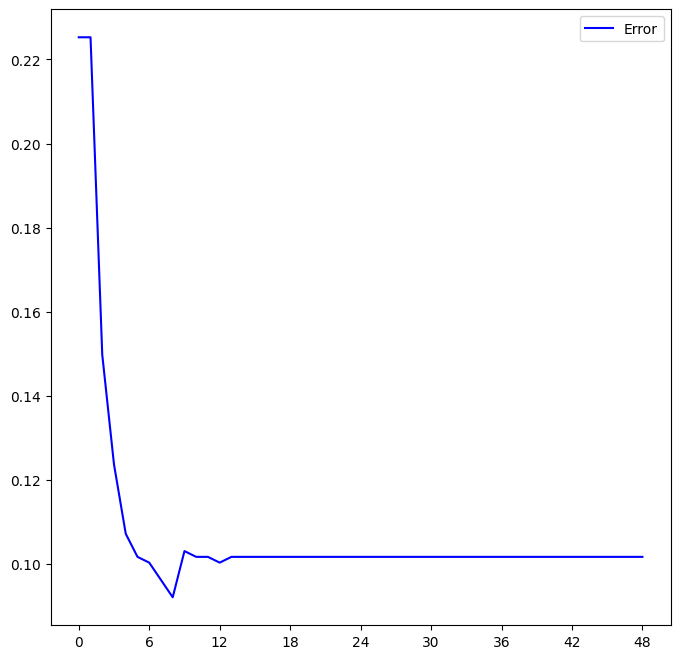

In [354]:
optimal_size = optimize_DTC_size(1, 50, X_train, Y_train, X_test, Y_test, plotting = True)

optimal_size

array([0.00324003])

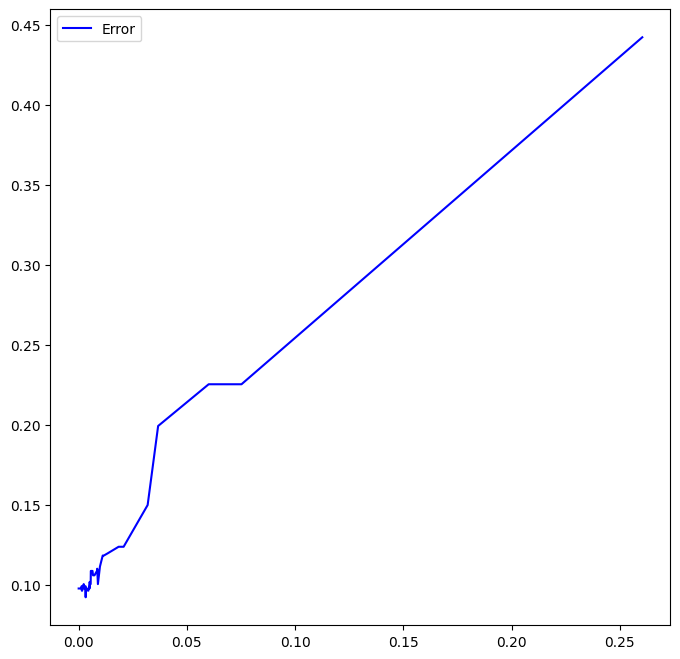

In [355]:
optimal_alpha = prune_optimized_DTC(optimal_size, X_train, Y_train, X_test, Y_test, plotting = True)

optimal_alpha

In [267]:
tuned_DTC = DTC(criterion='entropy',
                        max_depth=3,
                        random_state=0,
                        ccp_alpha=optimal_alpha[0])

tuned_DTC.fit(X_train, Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Now that the model is trained, evaluate it.

In [268]:
summary_table = {}

Number of Attrited Predictions: 280
Number of Existing Customer Predictions: 1838
Percent Attrited Predictions: 13.220018885741267
Percent Existing Customer Predictions: 86.77998111425873

Accuracy: 91.41%

Recall: 0.64

Precision: 0.8

F1-Score: 0.71


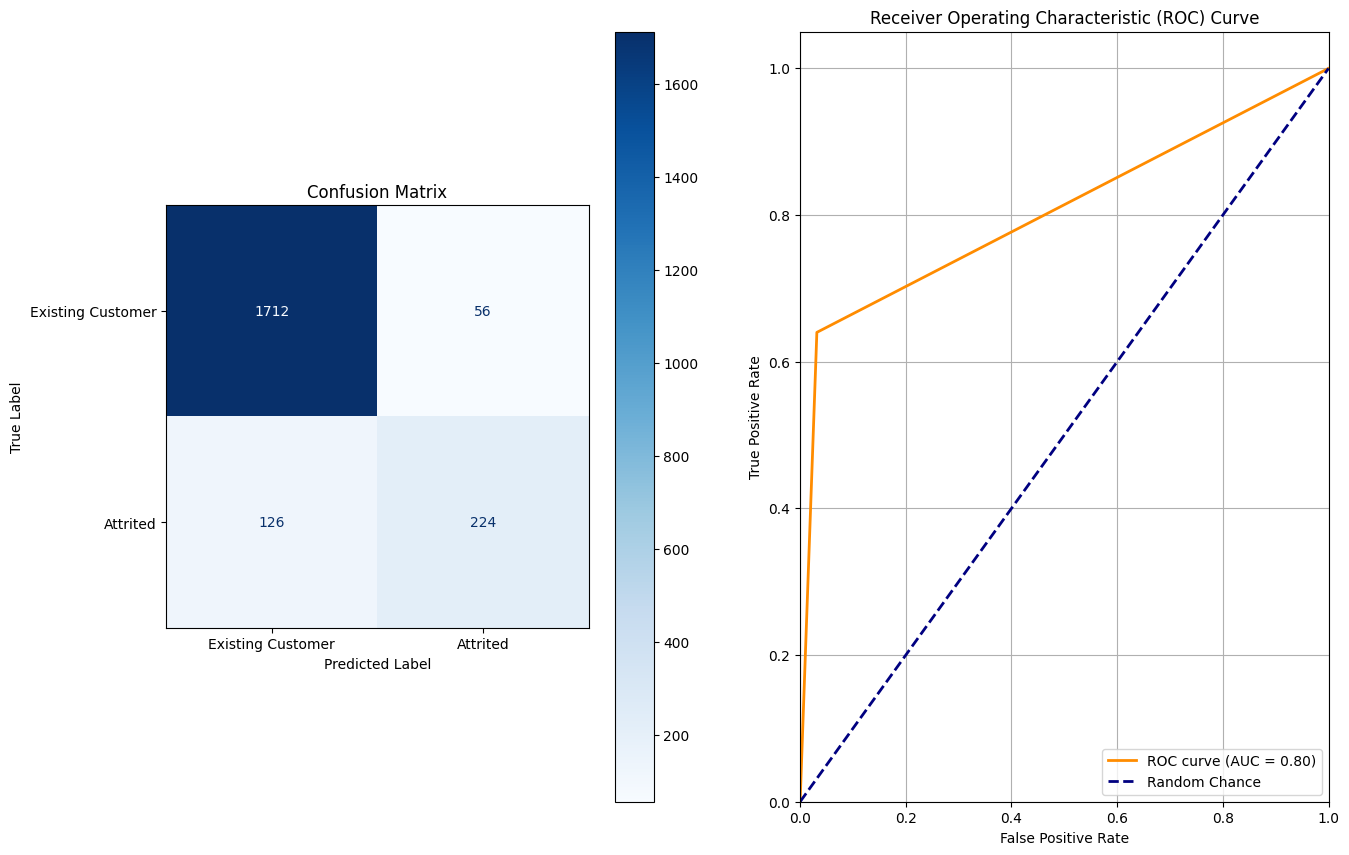

In [269]:
labels = ['Existing Customer', 'Attrited']

model = ModelEvaluator("Pruned DTC", tuned_DTC)

model_results = {model.name:[]}

model.eval_model(X_test, Y_test, labels)

model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

summary_table['Pruned_DTC_No_Reduction'] = model_results

## Gradient Boosted Regressor Training and Tuning

In [270]:
# Make a function that performs hyperparameter tuning on a GBR model
def tune_GBR(min_depth, max_depth, n_estimators, λ_range, X_train, Y_train, X_test, Y_test, plotting = False):
    depth_range = range(min_depth,max_depth)
    λ_range = λ_range
    optimal_λs = []
    min_test_errors = []

    for depth in depth_range:
        depth_test_error = []
        for λ in list(λ_range):

            boosted = GBR(n_estimators=n_estimators,
                                learning_rate=λ,
                                max_depth=depth,
                                random_state=0)
            
            boosted.fit(X_train, Y_train)

            Y_pred = boosted.predict(X_test)

            # Append the best train error
            depth_test_error.append(np.mean((Y_test - Y_pred)**2))

        if plotting:
            ax = subplots(figsize=(8,8))[1]

            ax.plot(λ_range,
                    np.array(depth_test_error),
                    'b',
                    label='Test Error')

            ax.set_xlabel('λ')
            ax.set_ylabel('Best Test Error')
            ax.set_title(f'Depth: {depth}')
            ax.legend();
    
        depth_test_error=np.array(depth_test_error)
        min_test_errors.append(np.min(depth_test_error))
        optimal_λs.append(λ_range[np.where(depth_test_error==np.min(depth_test_error))][0])

    min_test_errors = np.array(min_test_errors)
    optimal_λs = np.array(optimal_λs)

    return min_test_errors, optimal_λs

In [271]:
min_test_errors, optimal_λs = tune_GBR(4, 10, 500, np.linspace(0.0001, 0.25, 10), X_train, Y_train, X_test, Y_test)

In [272]:
min_test_errors = np.array(min_test_errors)
optimal_λs = np.array(optimal_λs).flatten()

depths = list(range(4,10))

max_depth = np.where(min_test_errors==np.min(min_test_errors))
optimal_λ = optimal_λs[np.where(min_test_errors==np.min(min_test_errors))]

print(min_test_errors, optimal_λs)
print(depths[max_depth[0][0]], optimal_λ)

[0.03154679 0.03048015 0.03015737 0.03131504 0.03455199 0.03843595] [0.05563333 0.02786667 0.05563333 0.05563333 0.0834     0.25      ]
6 [0.05563333]


In [273]:
tuned_GBR = GBR(n_estimators=500,
                learning_rate=0.05563333,
                max_depth=6,
                random_state=0)
            
tuned_GBR.fit(X_train, Y_train)

,loss,'squared_error'
,learning_rate,0.05563333
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


Number of Attrited Predictions: 322
Number of Existing Customer Predictions: 1796
Percent Attrited Predictions: 15.203021718602455
Percent Existing Customer Predictions: 84.79697828139756

Accuracy: 96.13%

Recall: 0.8428571428571429

Precision: 0.9161490683229814

F1-Score: 0.88


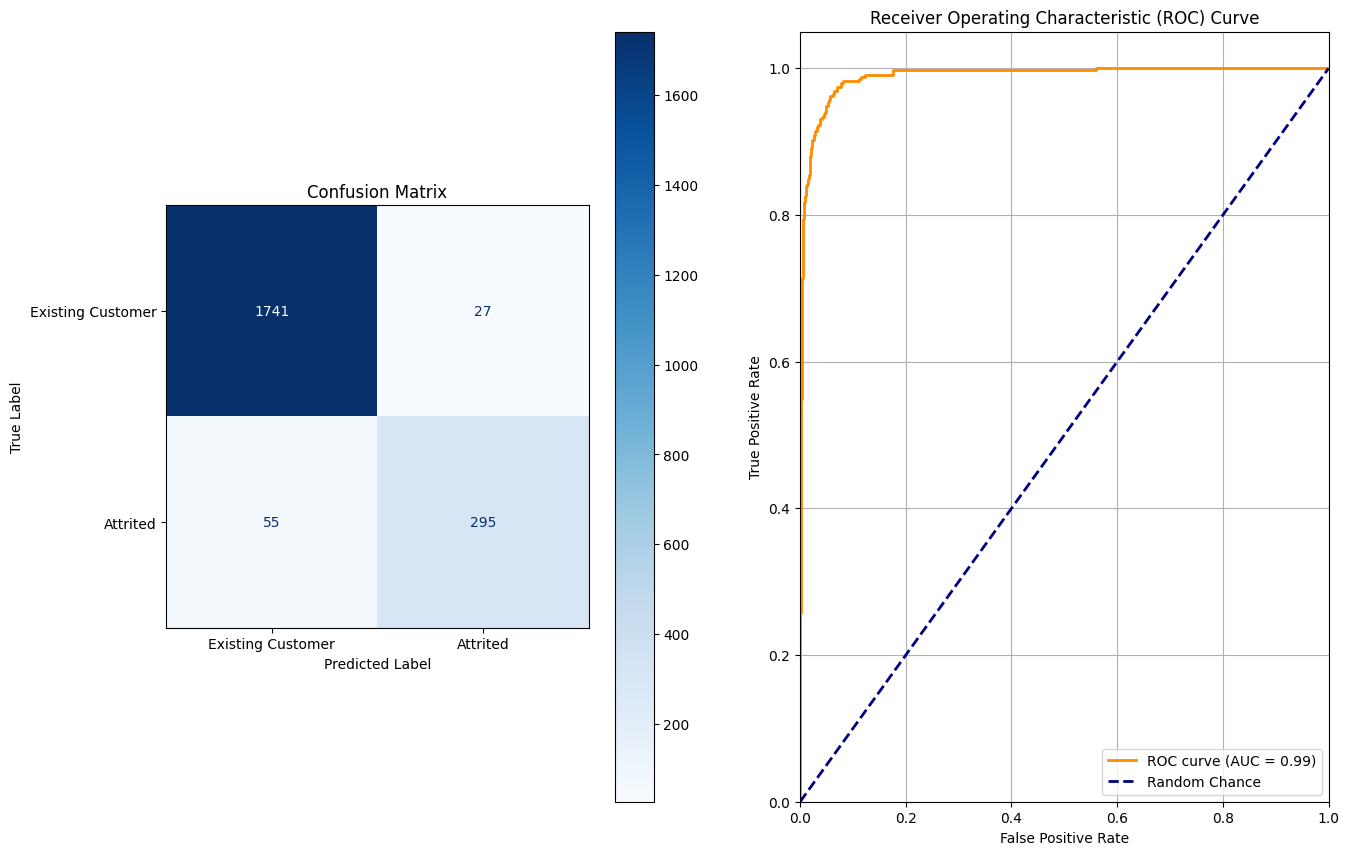

In [274]:
labels = ['Existing Customer', 'Attrited']

model = ModelEvaluator("Gradient Boosted Regressor", tuned_GBR)

model_results = {model.name:[]}

model.eval_model(X_test, Y_test, labels)

model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

summary_table['Gradient_Boosted_Regressor_No_Reduction'] = model_results

## Step 3: Feature Importance

1. Use SHAP, model-based importance, or coefficient analysis to identify key predictors.
2. After key predictors are identified, systematically reduce outliers across the key predictors and test.
    - After each reduction in outliers, train and test models to assess effect.

### Identify DTC Feature Importances

In [346]:
importances = tuned_DTC.feature_importances_
importances

array([0.42180315, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.01974995,
       0.        , 0.0036758 , 0.        , 0.        , 0.        ,
       0.        , 0.14887647, 0.40193098, 0.00396365, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [347]:
print(len(training_data.columns), len(importances))

25 25


In [348]:
feature_importance_df = pd.DataFrame({
    'Feature': training_data.columns.drop('Attrition_Flag'),
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

ValueError: All arrays must be of the same length

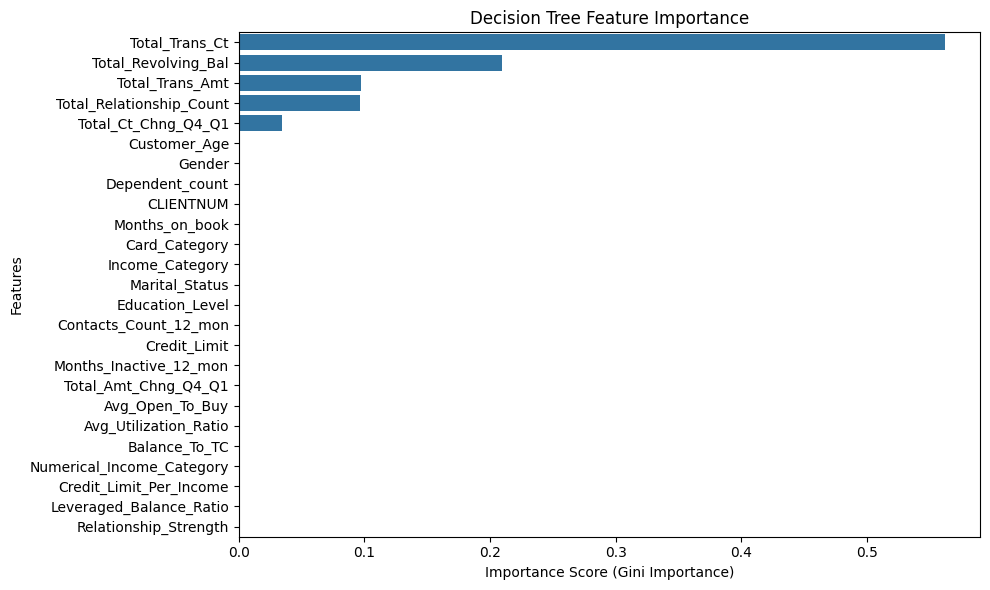

In [278]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Identify GBR Feature Importances

In [279]:
gbr_importances = tuned_GBR.feature_importances_

In [280]:
gbr_feature_importance_df = pd.DataFrame({
    'Feature': training_data.columns.drop('Attrition_Flag'),
    'Importance': gbr_importances
}).sort_values(by='Importance', ascending=False)

gbr_feature_importance_df.head(5)

,Feature,Importance
17,Total_Trans_Ct,0.273735
16,Total_Trans_Amt,0.164718
23,Leveraged_Balance_Ratio,0.103486
18,Total_Ct_Chng_Q4_Q1,0.095037
13,Total_Revolving_Bal,0.079004


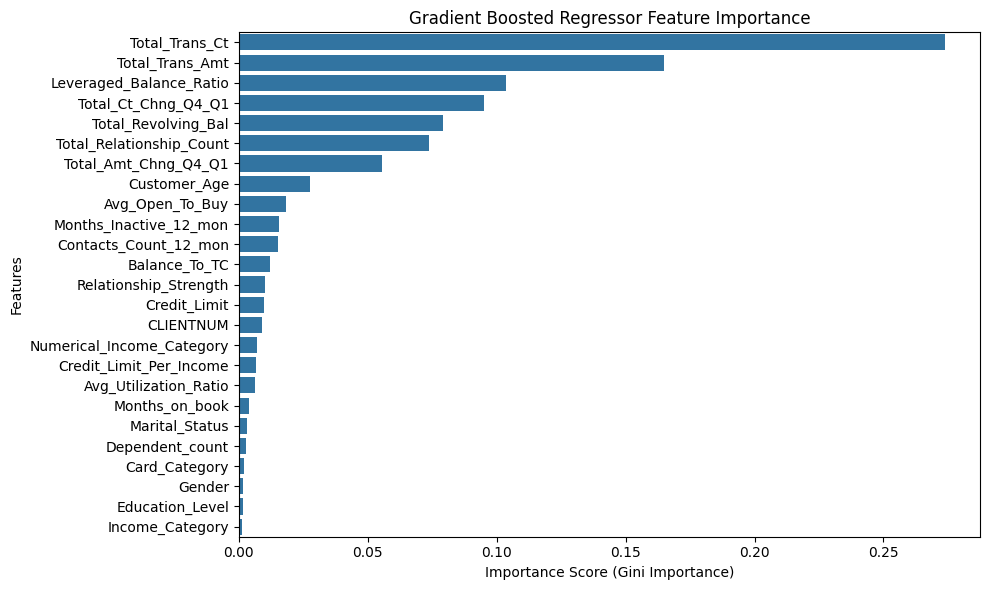

In [281]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=gbr_feature_importance_df)
plt.title('Gradient Boosted Regressor Feature Importance')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Step 4: Apply Feature Importance, Class Imbalance Correction, and Outlier Removal

The goal is to automate the optimization of the model for the respective reduction amount.

In [282]:
def remove_outliers(data, total_percentage):
    seed(42)
    reduction_percentage = total_percentage
    remove_indices = []

    outlier_sets = {}
    for key, val in outliers.items():
        outlier_sets[key] = set(val)

    unique_indices = set()

    for index_set in outlier_sets.values():
        unique_indices |= index_set

    unique_indices_list = sorted(list(unique_indices))

    for i in unique_indices_list:
        rand_num = randint(1,100)
        if rand_num <= reduction_percentage:
            remove_indices.append(i)

    remove = set(remove_indices)
    all_indices = set(data.index.values)

    reduced_data = data.iloc[list(all_indices - remove)]
    reduced_data.reset_index(inplace=True)
    return reduced_data

In [283]:
top_dtc_features = {}

In [284]:
def determine_dtc_importances(tuned_DTC, name):
    importances = tuned_DTC.feature_importances_
    feature_importance_df = pd.DataFrame({
    'Feature': training_data.columns.drop('Attrition_Flag'),
    'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    top_dtc_features[name] = list(feature_importance_df[feature_importance_df['Importance']>0]['Feature'].values)

### Decision Tree

Number of Attrited Predictions: 336
Number of Existing Customer Predictions: 931
Percent Attrited Predictions: 26.519337016574585
Percent Existing Customer Predictions: 73.48066298342542

Accuracy: 92.11%

Recall: 0.8410404624277457

Precision: 0.8660714285714286

F1-Score: 0.85


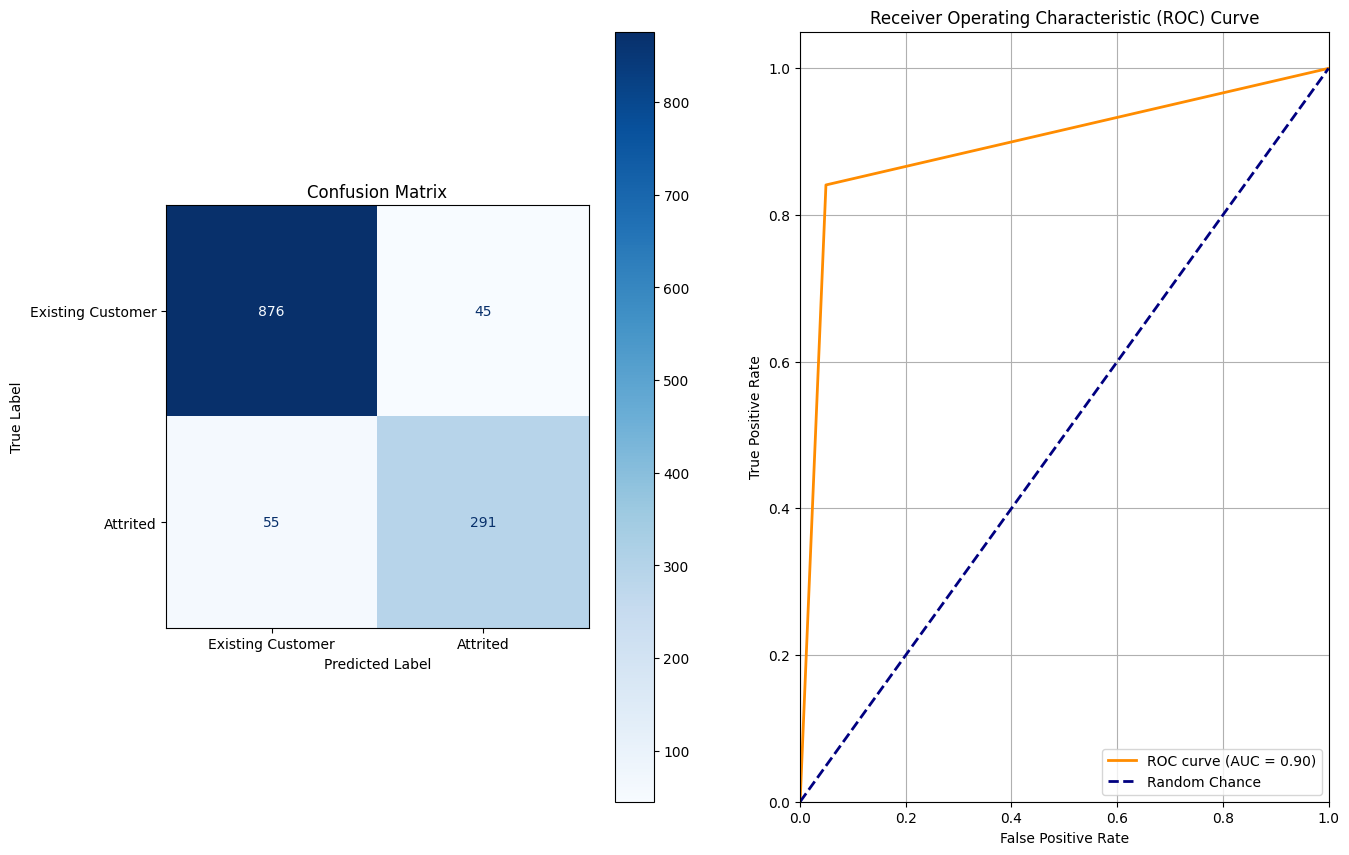

Number of Attrited Predictions: 342
Number of Existing Customer Predictions: 640
Percent Attrited Predictions: 34.82688391038696
Percent Existing Customer Predictions: 65.17311608961303

Accuracy: 91.75%

Recall: 0.9040247678018576

Precision: 0.8538011695906432

F1-Score: 0.88


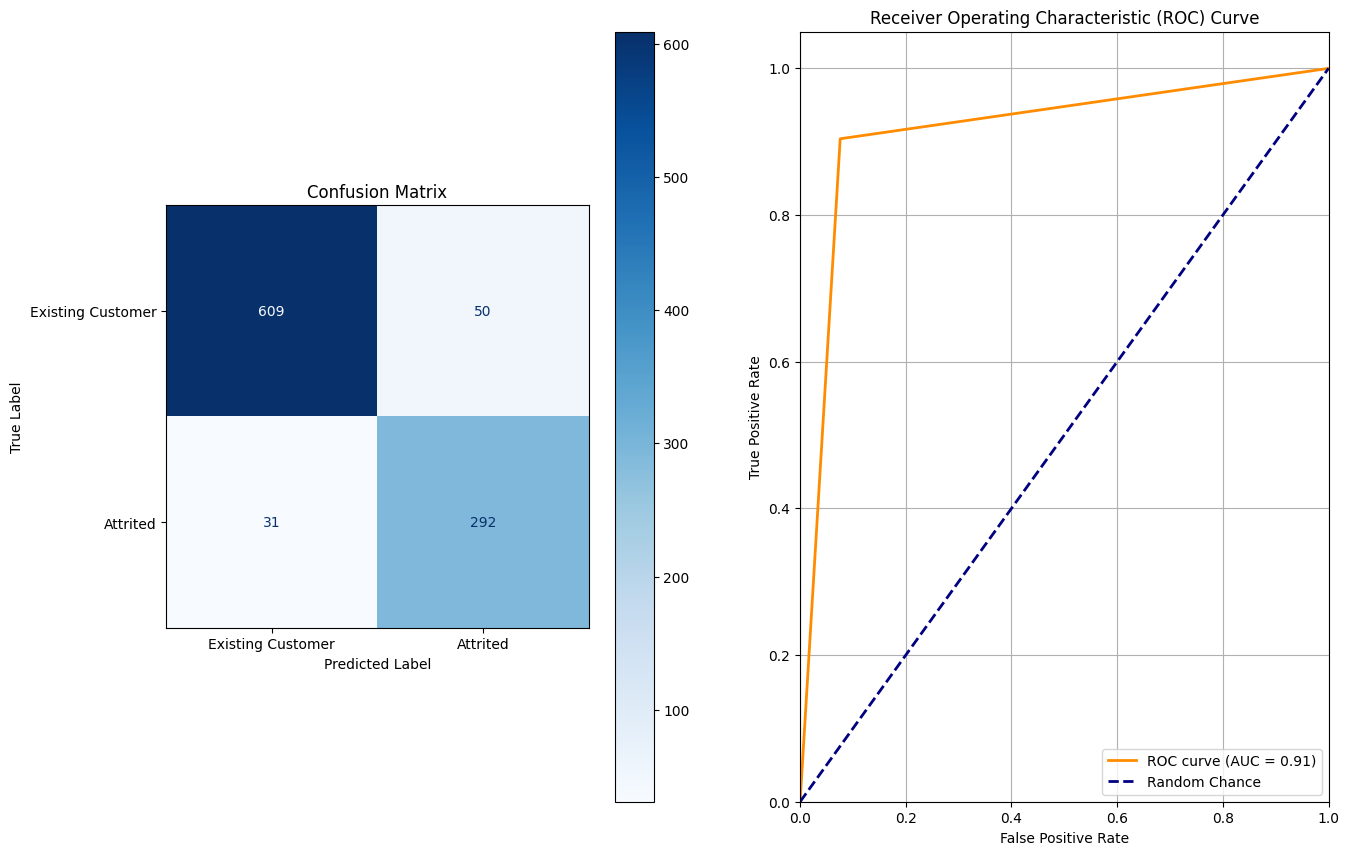

Number of Attrited Predictions: 336
Number of Existing Customer Predictions: 378
Percent Attrited Predictions: 47.05882352941176
Percent Existing Customer Predictions: 52.94117647058824

Accuracy: 89.22%

Recall: 0.8936170212765957

Precision: 0.875

F1-Score: 0.88


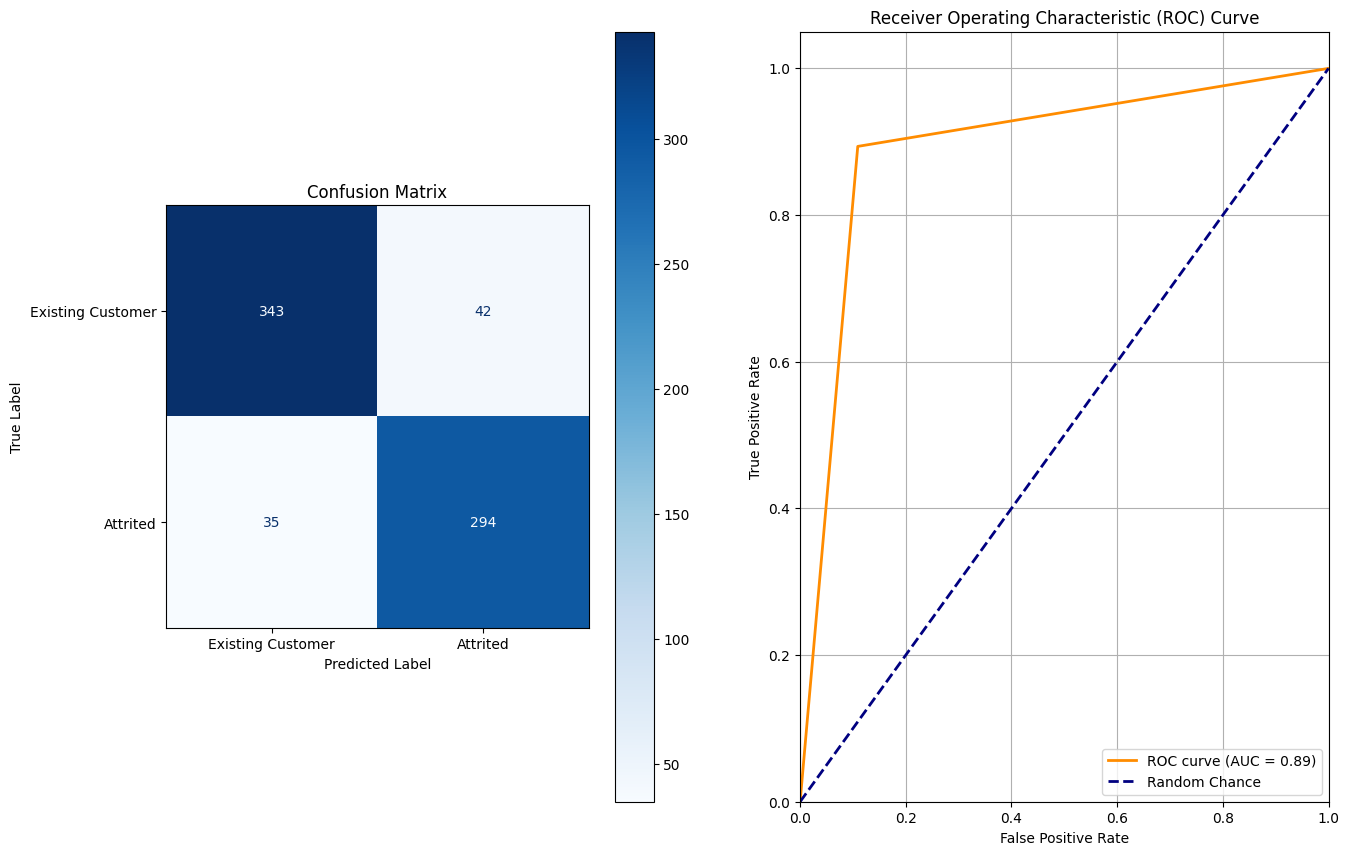

In [291]:
for i in range(50,85,15):

    dtc_data = reduce_data(data, i)

    dtc_data = dtc_data.drop(['index', 'CLIENTNUM'], axis = 1)

    training_data, test_data = split_data(dtc_data)

    model = MS(training_data.columns.drop('Attrition_Flag'), intercept=False)
    D = model.fit_transform(training_data) 
    feature_names = list(D.columns)
    X_train = np.asarray(D)
    Y_train = training_data['Attrition_Flag']

    model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
    D = model.fit_transform(test_data) 
    feature_names = list(D.columns)
    X_test = np.asarray(D)
    Y_test = test_data['Attrition_Flag']

    optimal_size = optimize_DTC_size(1, 50, X_train, Y_train, X_test, Y_test)
    optimal_alpha = prune_optimized_DTC(optimal_size, X_train, Y_train, X_test, Y_test)

    tuned_DTC = DTC(criterion='entropy',
                        max_depth=optimal_size,
                        random_state=0,
                        ccp_alpha=optimal_alpha[0])

    tuned_DTC.fit(X_train, Y_train)

    determine_dtc_importances(tuned_DTC, f'Pruned_DTC_{i}%_Class_Imbalance_Reduction')

    labels = ['Existing Customer', 'Attrited']

    model = ModelEvaluator("Decision Tree Classifier", tuned_DTC)

    model_results = {model.name:[]}

    model.eval_model(X_test, Y_test, labels)

    model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

    summary_table[f'{i}%_Class_Imbalance_Reduction'] = model_results


In [286]:
top_dtc_features

{'Pruned_DTC_50%_Class_Imbalance_Reduction': ['Total_Trans_Ct',
  'Total_Trans_Amt',
  'Leveraged_Balance_Ratio',
  'Total_Ct_Chng_Q4_Q1',
  'Total_Relationship_Count',
  'Total_Amt_Chng_Q4_Q1',
  'Balance_To_TC',
  'Customer_Age',
  'Months_Inactive_12_mon',
  'Total_Revolving_Bal',
  'Dependent_count',
  'Credit_Limit',
  'Relationship_Strength',
  'Avg_Open_To_Buy',
  'Contacts_Count_12_mon',
  'Months_on_book',
  'Numerical_Income_Category',
  'Credit_Limit_Per_Income',
  'Avg_Utilization_Ratio',
  'Income_Category',
  'Marital_Status',
  'Card_Category'],
 'Pruned_DTC_65%_Class_Imbalance_Reduction': ['Total_Trans_Ct',
  'Total_Trans_Amt',
  'Leveraged_Balance_Ratio',
  'Total_Relationship_Count',
  'Total_Ct_Chng_Q4_Q1',
  'Total_Amt_Chng_Q4_Q1',
  'Customer_Age',
  'Balance_To_TC',
  'Total_Revolving_Bal',
  'Avg_Open_To_Buy',
  'Months_Inactive_12_mon',
  'Contacts_Count_12_mon',
  'Credit_Limit',
  'Avg_Utilization_Ratio',
  'Marital_Status',
  'Dependent_count',
  'Relationshi

### Repeat the process with just outlier reduction

Number of Attrited Predictions: 328
Number of Existing Customer Predictions: 1754
Percent Attrited Predictions: 15.754082612872239
Percent Existing Customer Predictions: 84.24591738712776

Accuracy: 95.00%

Recall: 0.8353293413173652

Precision: 0.850609756097561

F1-Score: 0.84


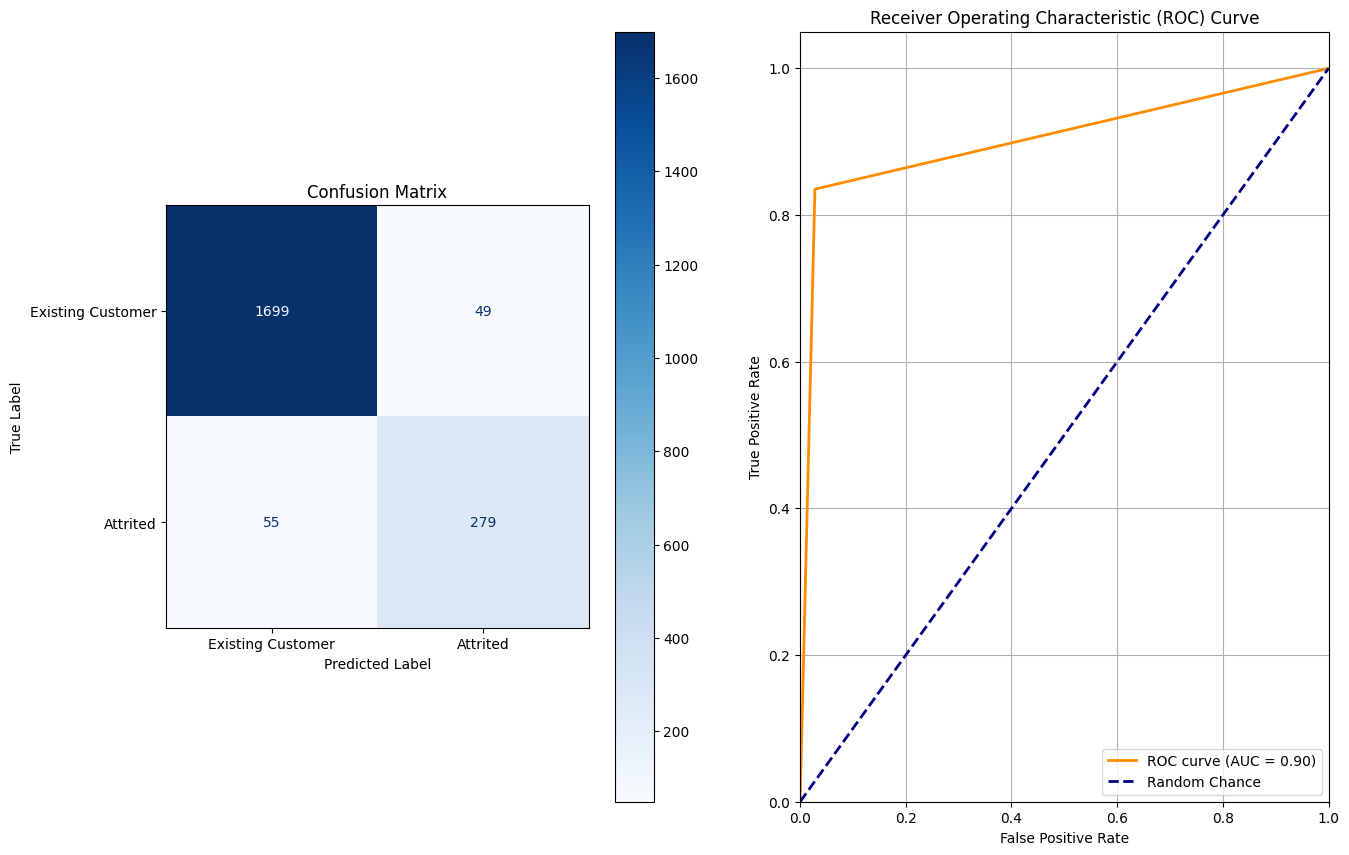

Number of Attrited Predictions: 324
Number of Existing Customer Predictions: 1720
Percent Attrited Predictions: 15.851272015655576
Percent Existing Customer Predictions: 84.14872798434442

Accuracy: 94.42%

Recall: 0.8343949044585988

Precision: 0.808641975308642

F1-Score: 0.82


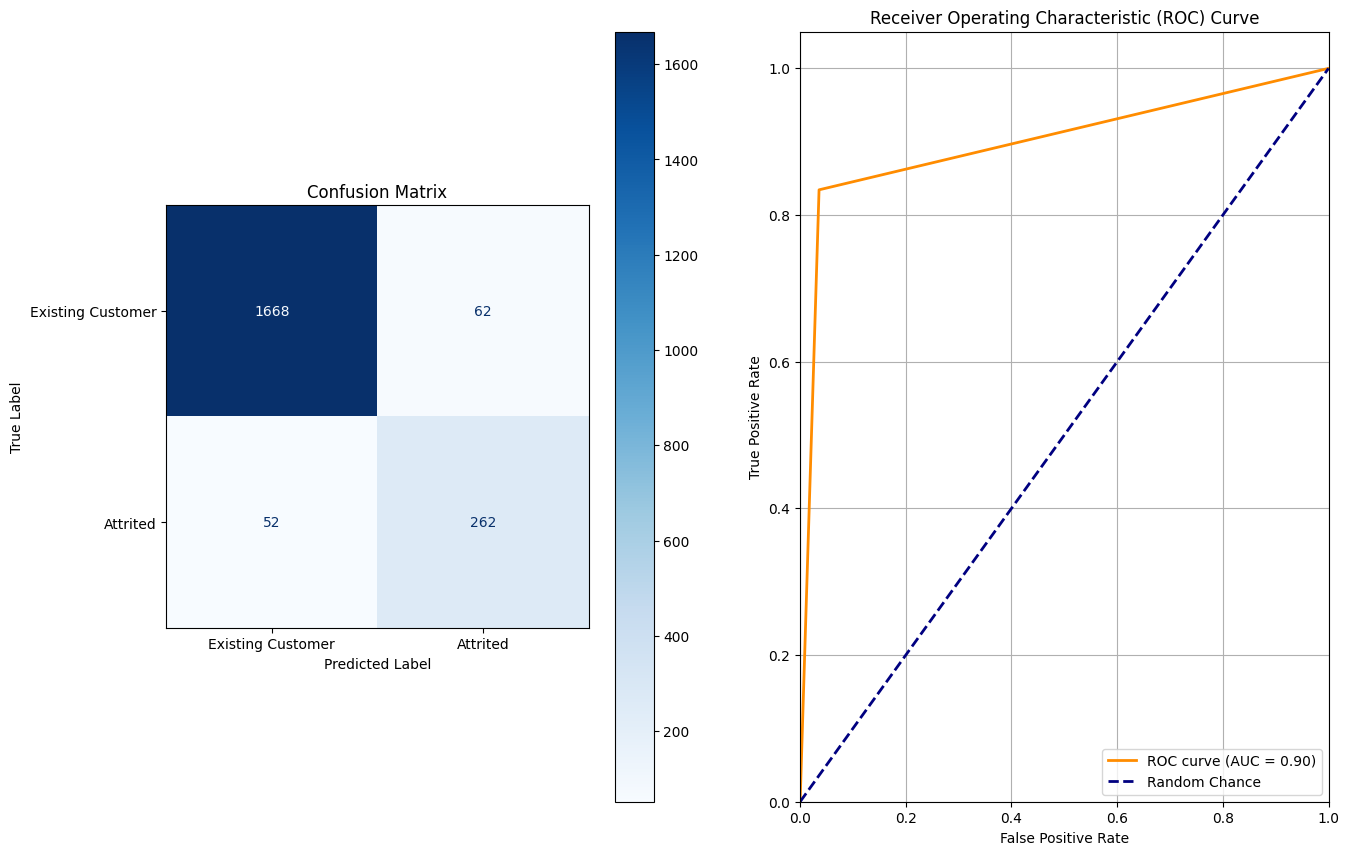

Number of Attrited Predictions: 298
Number of Existing Customer Predictions: 1699
Percent Attrited Predictions: 14.922383575363044
Percent Existing Customer Predictions: 85.07761642463696

Accuracy: 94.09%

Recall: 0.7960526315789473

Precision: 0.8120805369127517

F1-Score: 0.80


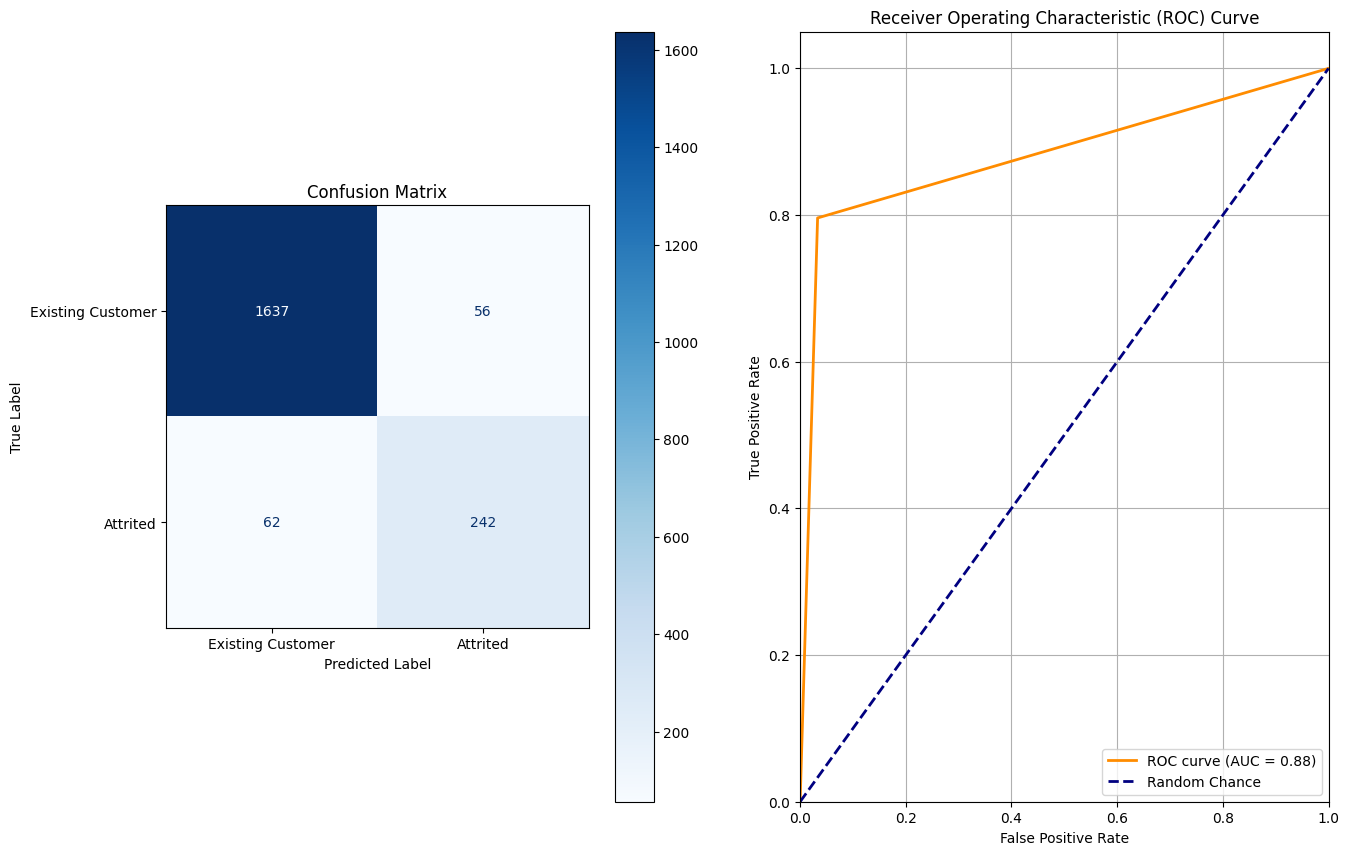

In [287]:
for i in range(5,20,5):

    dtc_data = remove_outliers(data, i)

    dtc_data = dtc_data.drop(['index', 'CLIENTNUM'], axis = 1)

    training_data, test_data = split_data(dtc_data)

    model = MS(training_data.columns.drop('Attrition_Flag'), intercept=False)
    D = model.fit_transform(training_data) 
    feature_names = list(D.columns)
    X_train = np.asarray(D)
    Y_train = training_data['Attrition_Flag']

    model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
    D = model.fit_transform(test_data) 
    feature_names = list(D.columns)
    X_test = np.asarray(D)
    Y_test = test_data['Attrition_Flag']

    optimal_size = optimize_DTC_size(1, 50, X_train, Y_train, X_test, Y_test)
    optimal_alpha = prune_optimized_DTC(optimal_size, X_train, Y_train, X_test, Y_test)

    tuned_DTC = DTC(criterion='entropy',
                        max_depth=optimal_size,
                        random_state=0,
                        ccp_alpha=optimal_alpha[0])

    tuned_DTC.fit(X_train, Y_train)

    determine_dtc_importances(tuned_DTC, f'Pruned_DTC_{i}%_Outlier_Reduction')

    labels = ['Existing Customer', 'Attrited']

    model = ModelEvaluator("Decision Tree Classifier", tuned_DTC)

    model_results = {model.name:[]}

    model.eval_model(X_test, Y_test, labels)

    model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

    summary_table[f'{i}%_Outlier_Reduction'] = model_results

### Create a combination of outlier reduction and class imbalance correction

Number of Attrited Predictions: 295
Number of Existing Customer Predictions: 947
Percent Attrited Predictions: 23.752012882447666
Percent Existing Customer Predictions: 76.24798711755234

Accuracy: 92.59%

Recall: 0.8142414860681114

Precision: 0.8915254237288136

F1-Score: 0.85


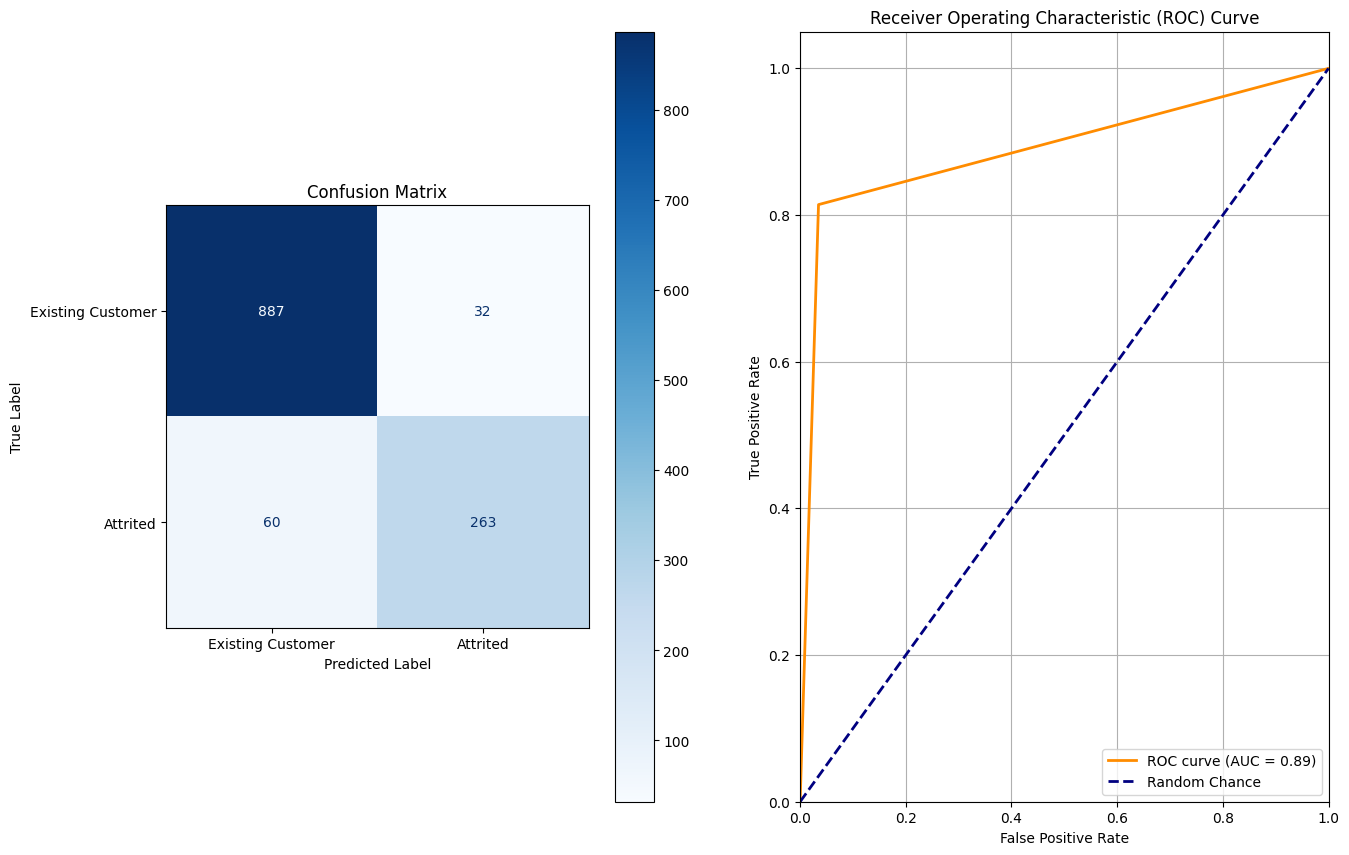

Number of Attrited Predictions: 343
Number of Existing Customer Predictions: 875
Percent Attrited Predictions: 28.160919540229884
Percent Existing Customer Predictions: 71.83908045977012

Accuracy: 90.64%

Recall: 0.8459214501510574

Precision: 0.8163265306122449

F1-Score: 0.83


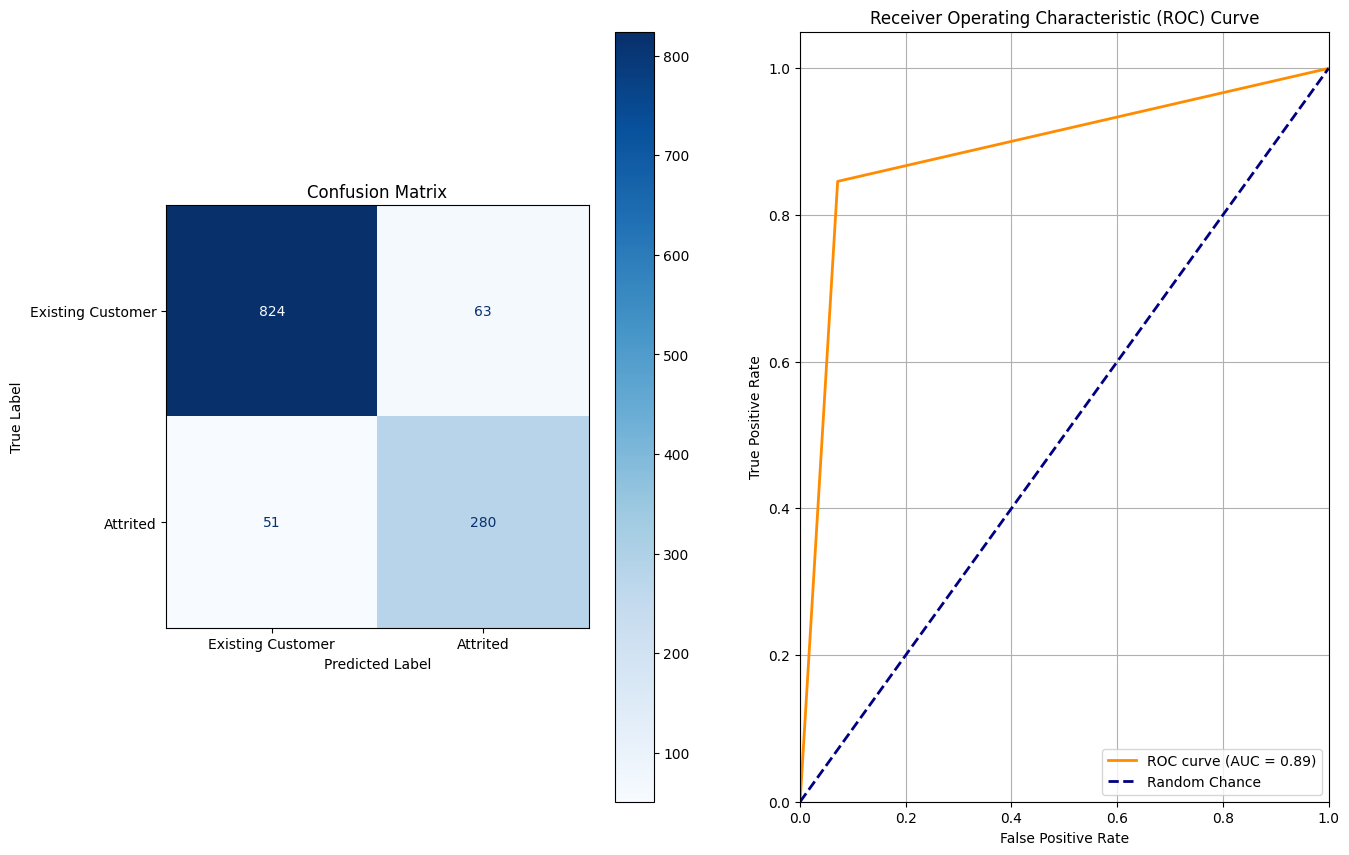

Number of Attrited Predictions: 304
Number of Existing Customer Predictions: 873
Percent Attrited Predictions: 25.828377230246392
Percent Existing Customer Predictions: 74.17162276975361

Accuracy: 92.35%

Recall: 0.834375

Precision: 0.8782894736842105

F1-Score: 0.86


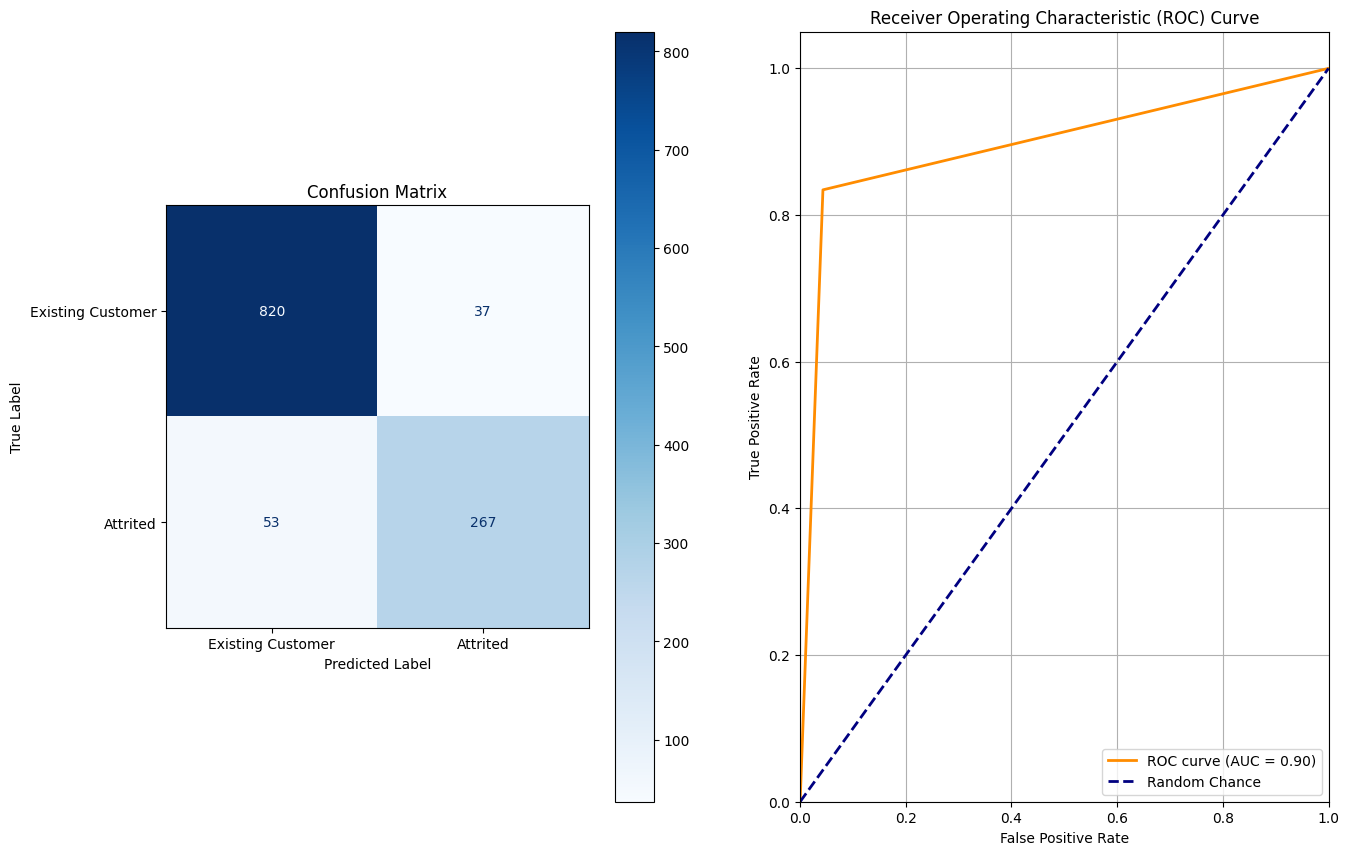

Number of Attrited Predictions: 300
Number of Existing Customer Predictions: 848
Percent Attrited Predictions: 26.132404181184672
Percent Existing Customer Predictions: 73.86759581881533

Accuracy: 92.94%

Recall: 0.8762886597938144

Precision: 0.85

F1-Score: 0.86


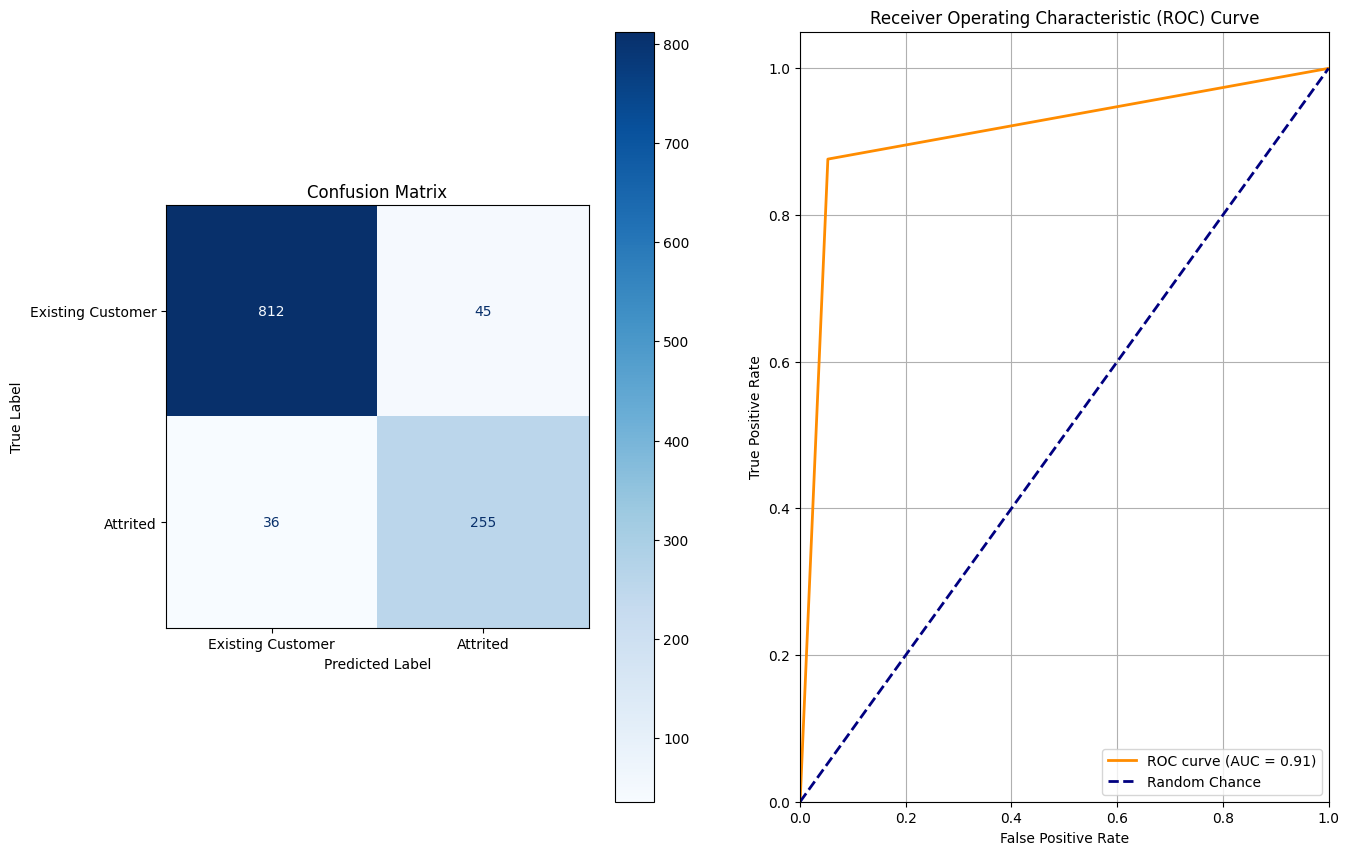

Number of Attrited Predictions: 309
Number of Existing Customer Predictions: 813
Percent Attrited Predictions: 27.540106951871657
Percent Existing Customer Predictions: 72.45989304812835

Accuracy: 92.07%

Recall: 0.8525641025641025

Precision: 0.86084142394822

F1-Score: 0.86


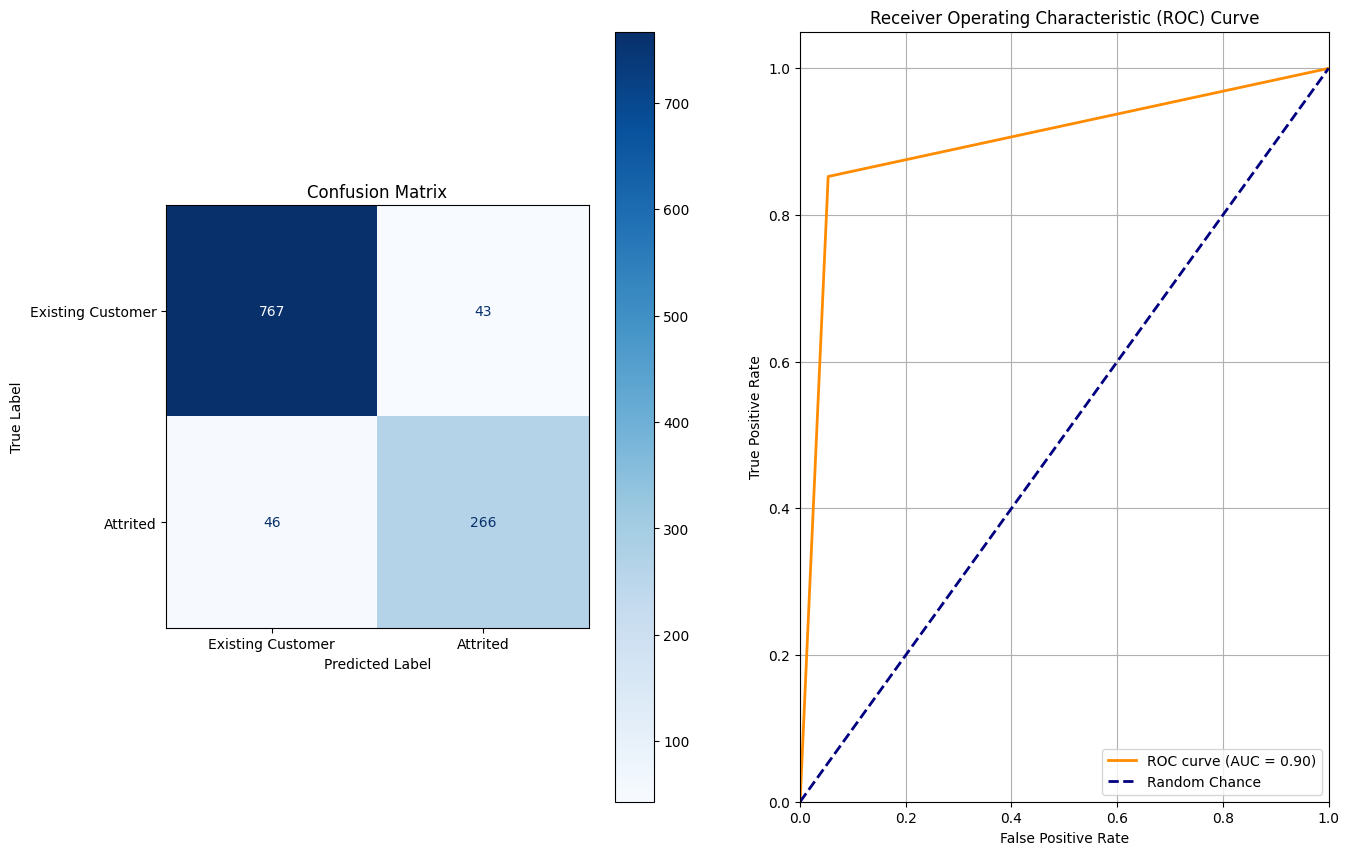

Number of Attrited Predictions: 329
Number of Existing Customer Predictions: 813
Percent Attrited Predictions: 28.809106830122595
Percent Existing Customer Predictions: 71.19089316987741

Accuracy: 91.24%

Recall: 0.8243626062322946

Precision: 0.8844984802431611

F1-Score: 0.85


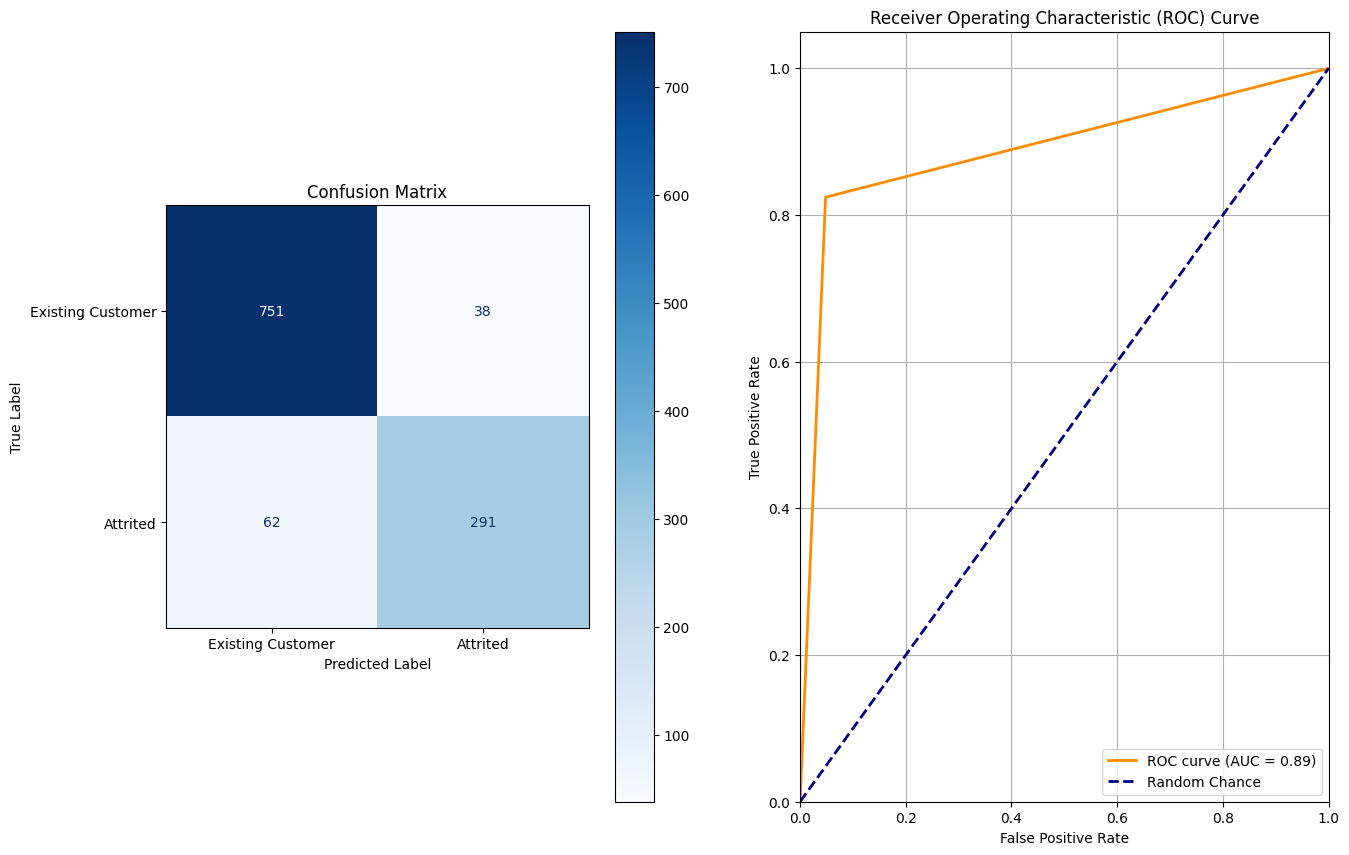

Number of Attrited Predictions: 314
Number of Existing Customer Predictions: 798
Percent Attrited Predictions: 28.23741007194245
Percent Existing Customer Predictions: 71.76258992805755

Accuracy: 92.45%

Recall: 0.844311377245509

Precision: 0.8980891719745223

F1-Score: 0.87


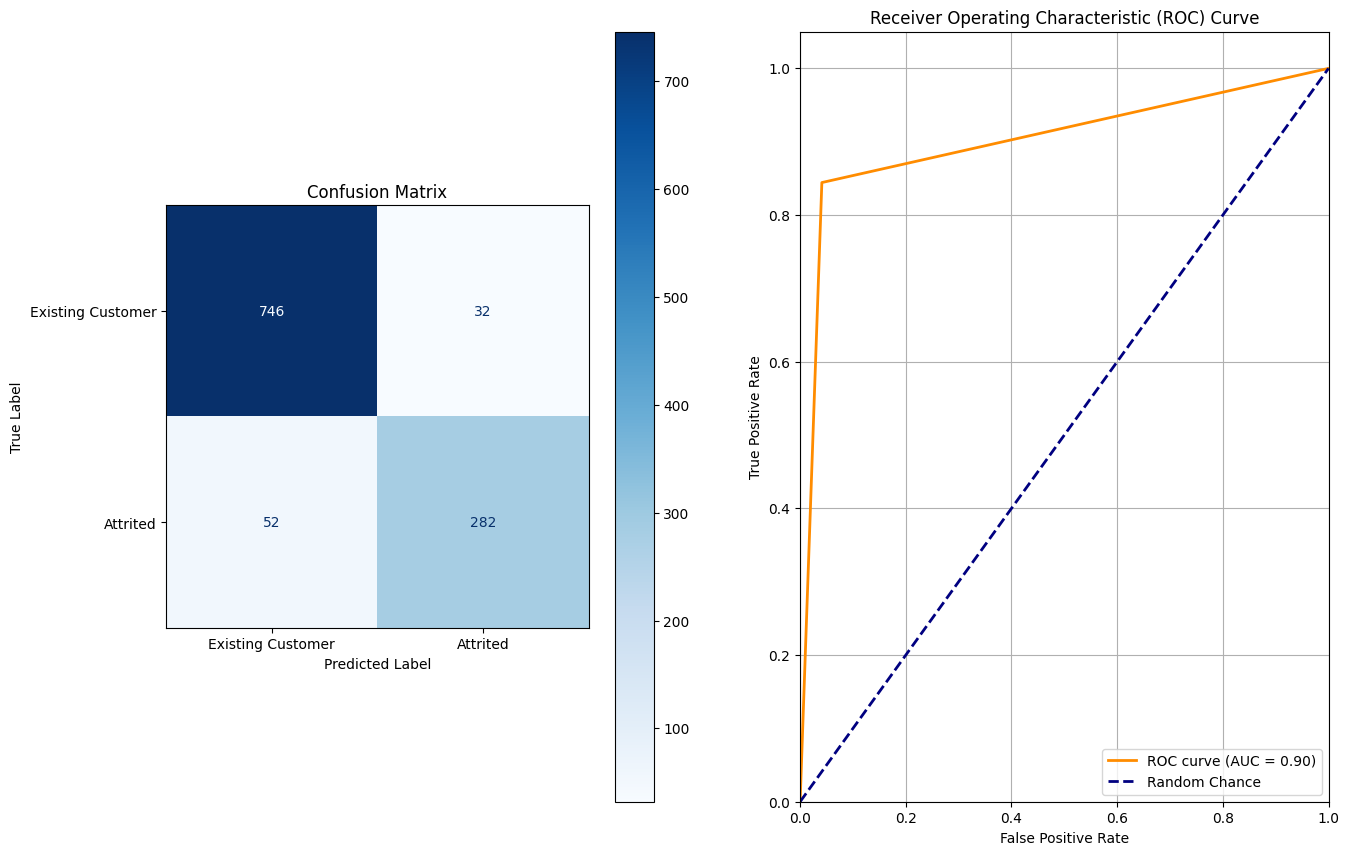

Number of Attrited Predictions: 314
Number of Existing Customer Predictions: 774
Percent Attrited Predictions: 28.860294117647058
Percent Existing Customer Predictions: 71.13970588235294

Accuracy: 90.44%

Recall: 0.8301886792452831

Precision: 0.8407643312101911

F1-Score: 0.84


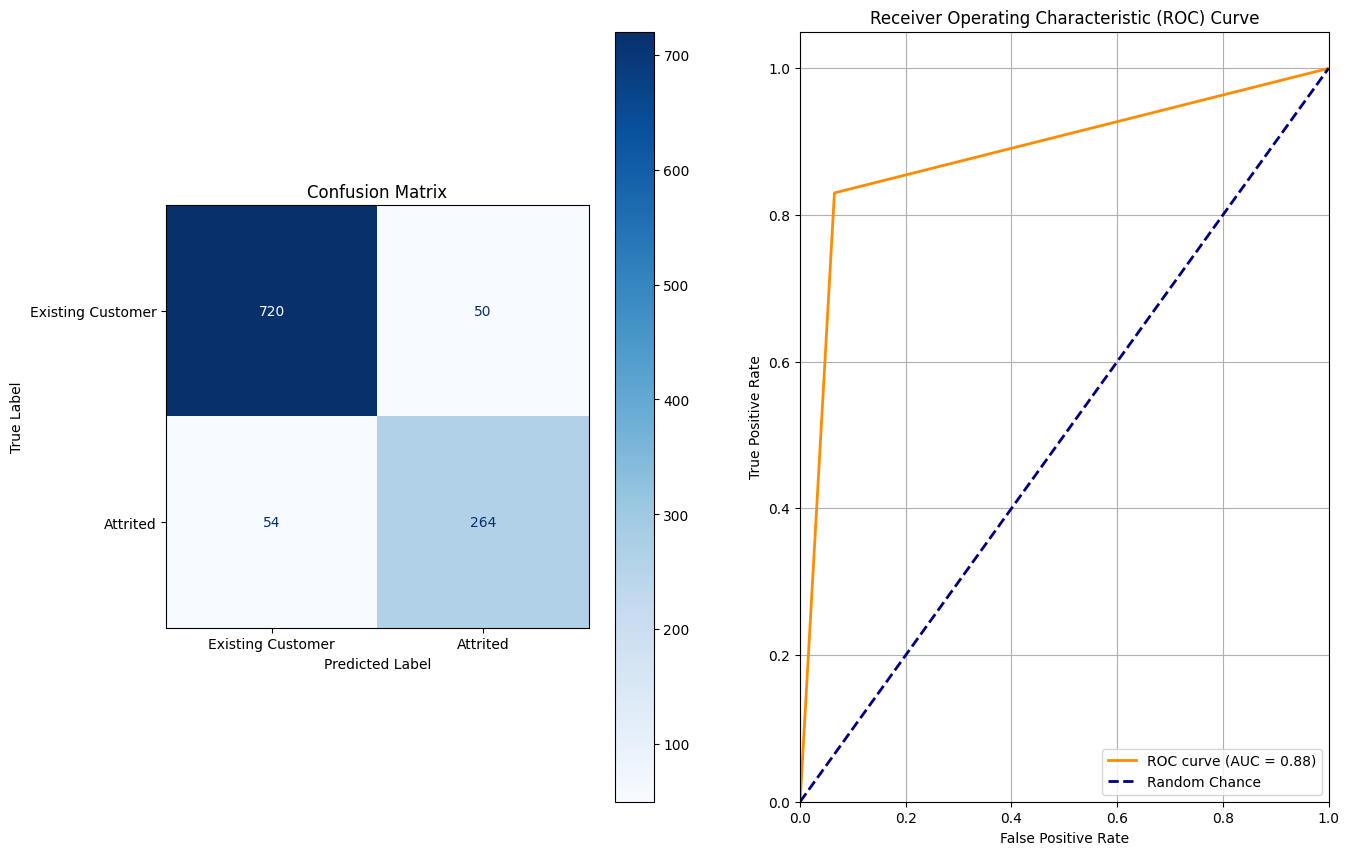

Number of Attrited Predictions: 333
Number of Existing Customer Predictions: 727
Percent Attrited Predictions: 31.41509433962264
Percent Existing Customer Predictions: 68.58490566037736

Accuracy: 88.87%

Recall: 0.8369905956112853

Precision: 0.8018018018018018

F1-Score: 0.82


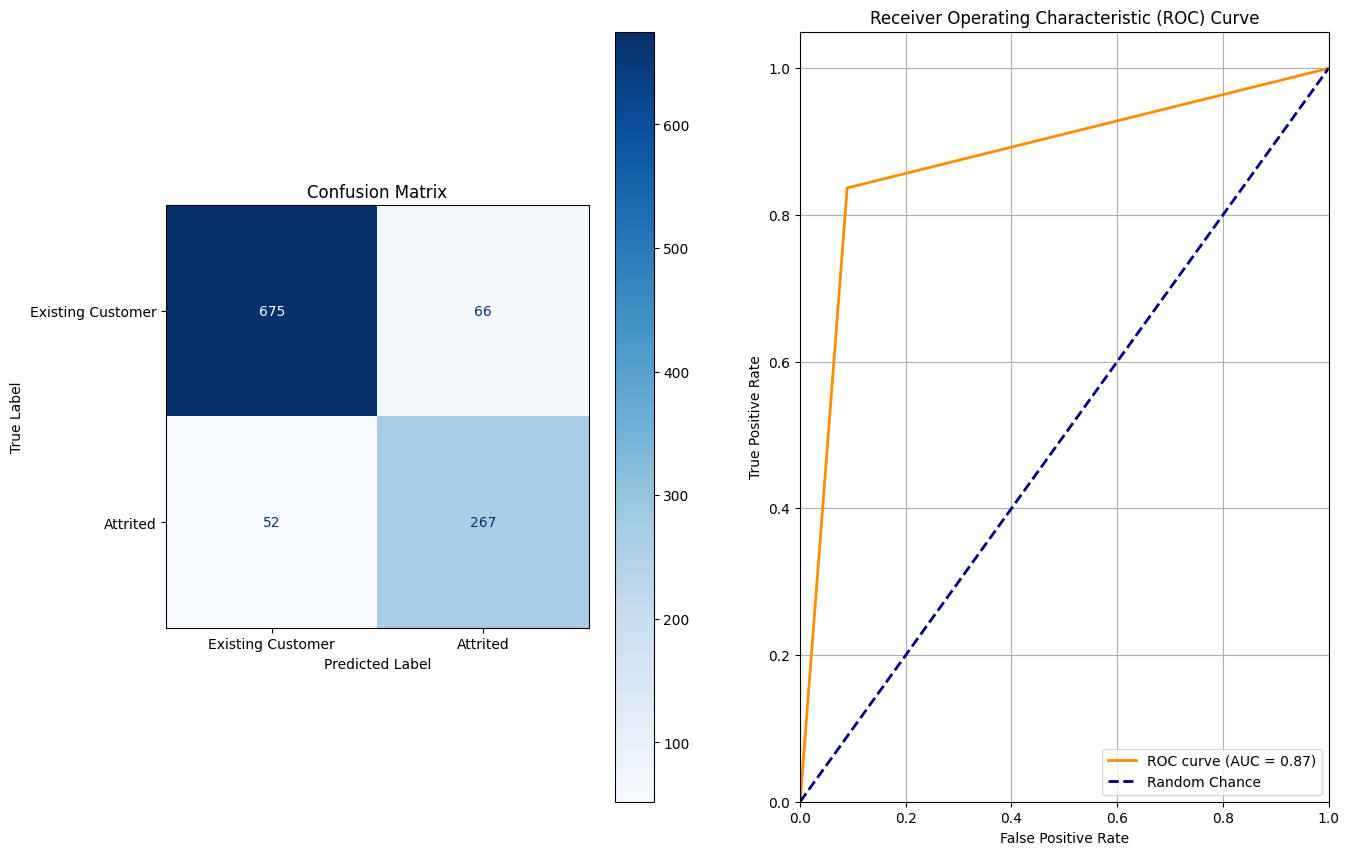

Number of Attrited Predictions: 279
Number of Existing Customer Predictions: 753
Percent Attrited Predictions: 27.03488372093023
Percent Existing Customer Predictions: 72.96511627906976

Accuracy: 91.76%

Recall: 0.8514492753623188

Precision: 0.8422939068100358

F1-Score: 0.85


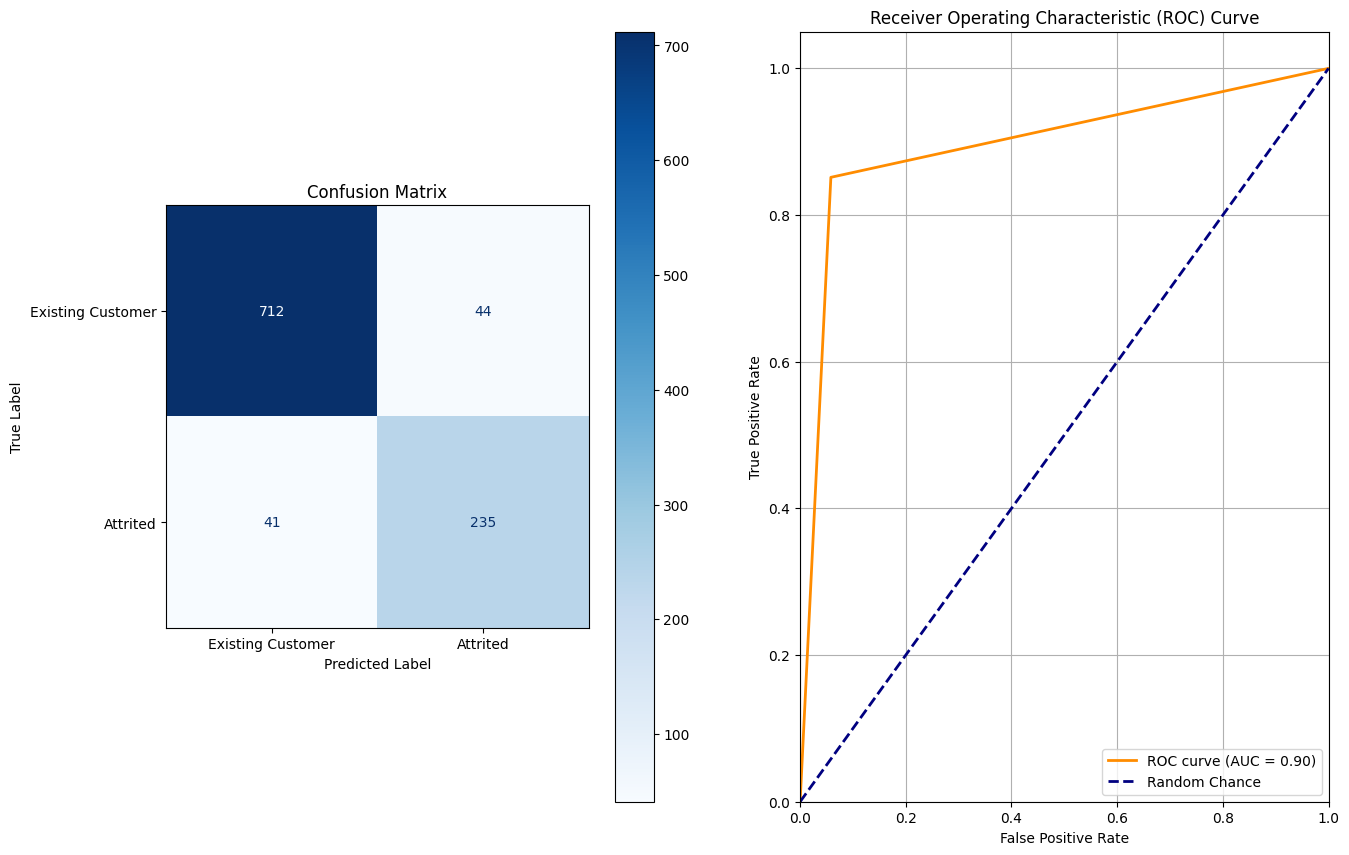

Number of Attrited Predictions: 321
Number of Existing Customer Predictions: 722
Percent Attrited Predictions: 30.77660594439118
Percent Existing Customer Predictions: 69.22339405560882

Accuracy: 90.99%

Recall: 0.8557993730407524

Precision: 0.8504672897196262

F1-Score: 0.85


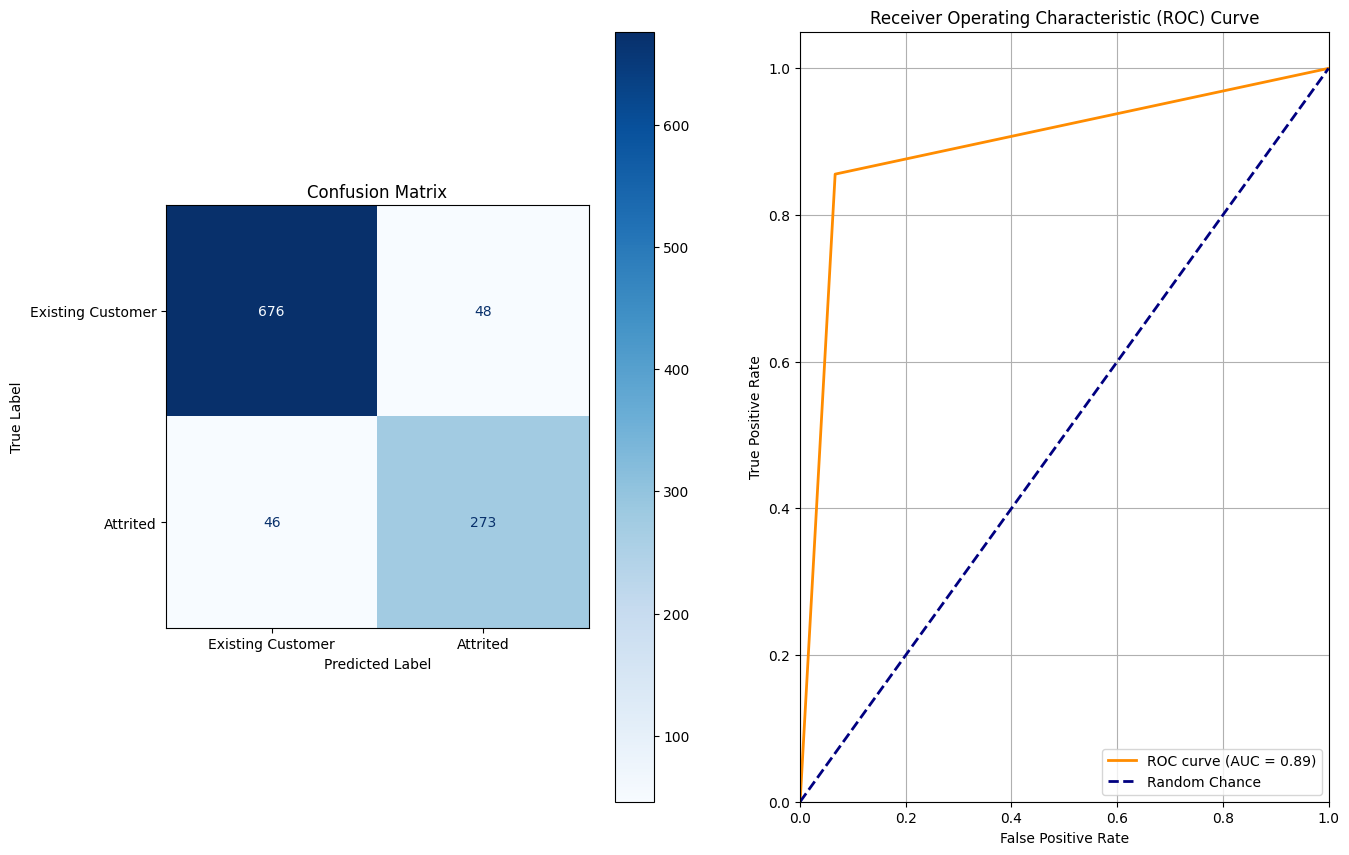

Number of Attrited Predictions: 311
Number of Existing Customer Predictions: 711
Percent Attrited Predictions: 30.430528375733857
Percent Existing Customer Predictions: 69.56947162426614

Accuracy: 90.41%

Recall: 0.8514851485148515

Precision: 0.8295819935691319

F1-Score: 0.84


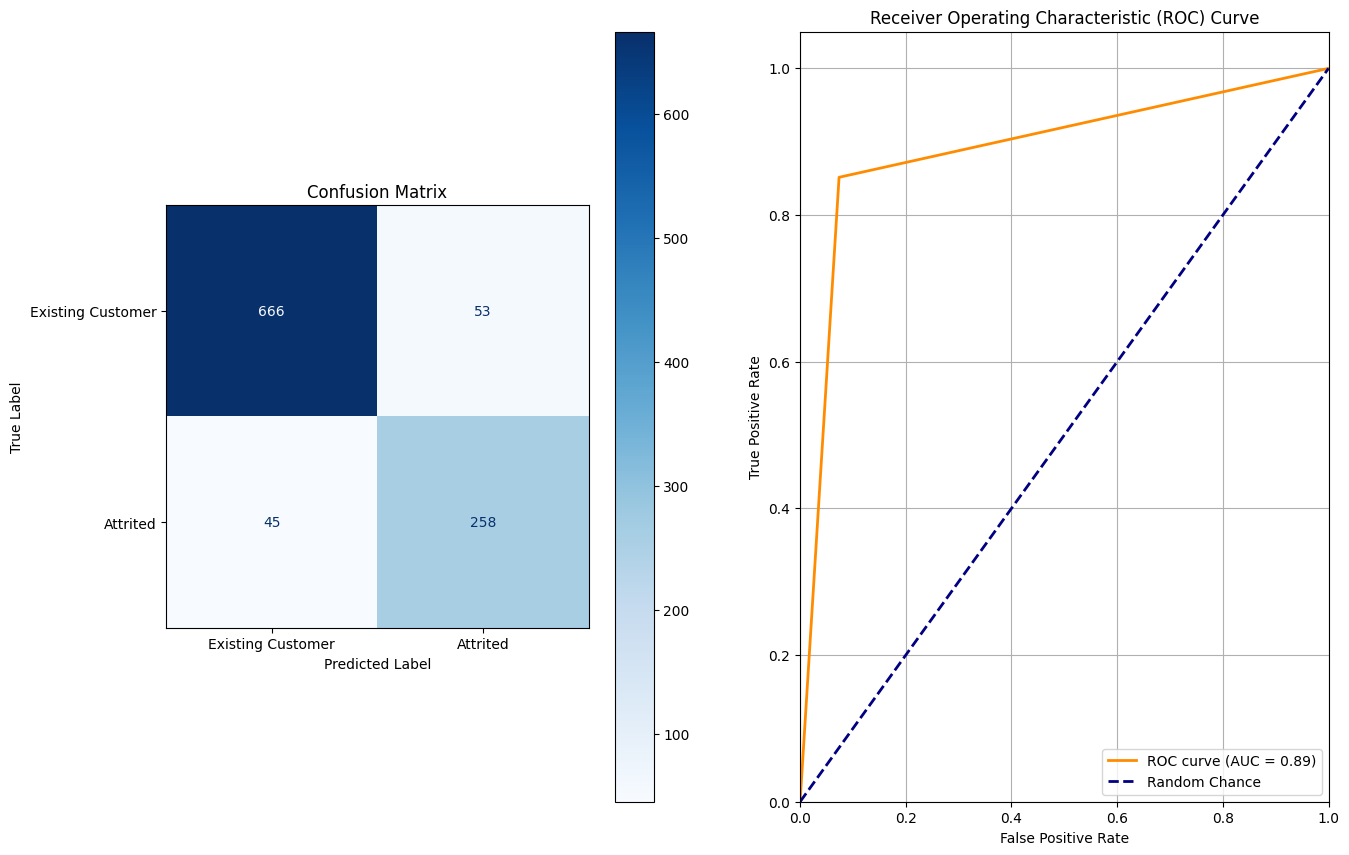

Number of Attrited Predictions: 325
Number of Existing Customer Predictions: 679
Percent Attrited Predictions: 32.37051792828685
Percent Existing Customer Predictions: 67.62948207171314

Accuracy: 92.63%

Recall: 0.8861538461538462

Precision: 0.8861538461538462

F1-Score: 0.89


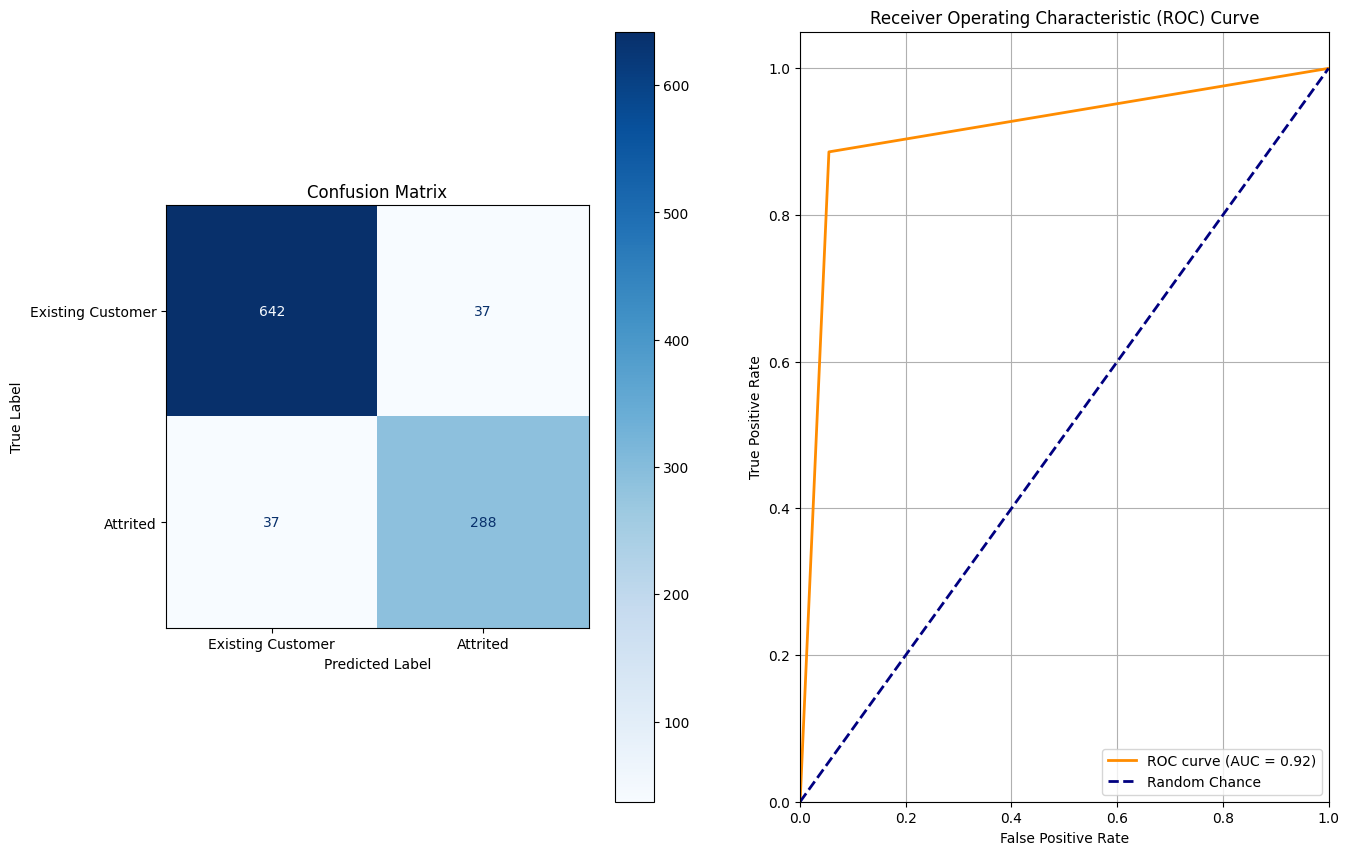

Number of Attrited Predictions: 315
Number of Existing Customer Predictions: 670
Percent Attrited Predictions: 31.979695431472084
Percent Existing Customer Predictions: 68.02030456852792

Accuracy: 90.66%

Recall: 0.8495297805642633

Precision: 0.8603174603174604

F1-Score: 0.85


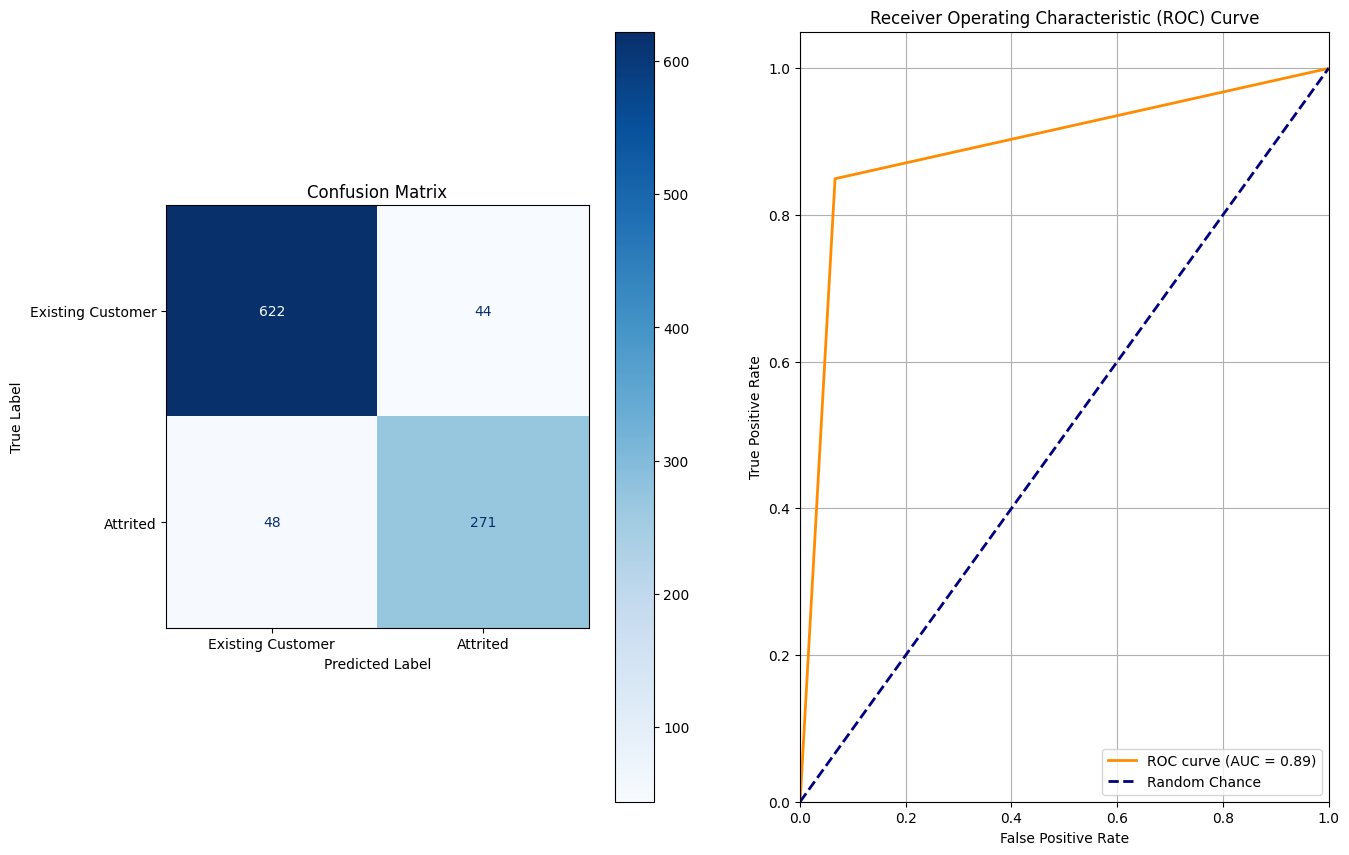

Number of Attrited Predictions: 329
Number of Existing Customer Predictions: 637
Percent Attrited Predictions: 34.05797101449276
Percent Existing Customer Predictions: 65.94202898550725

Accuracy: 90.37%

Recall: 0.8856209150326797

Precision: 0.8237082066869301

F1-Score: 0.85


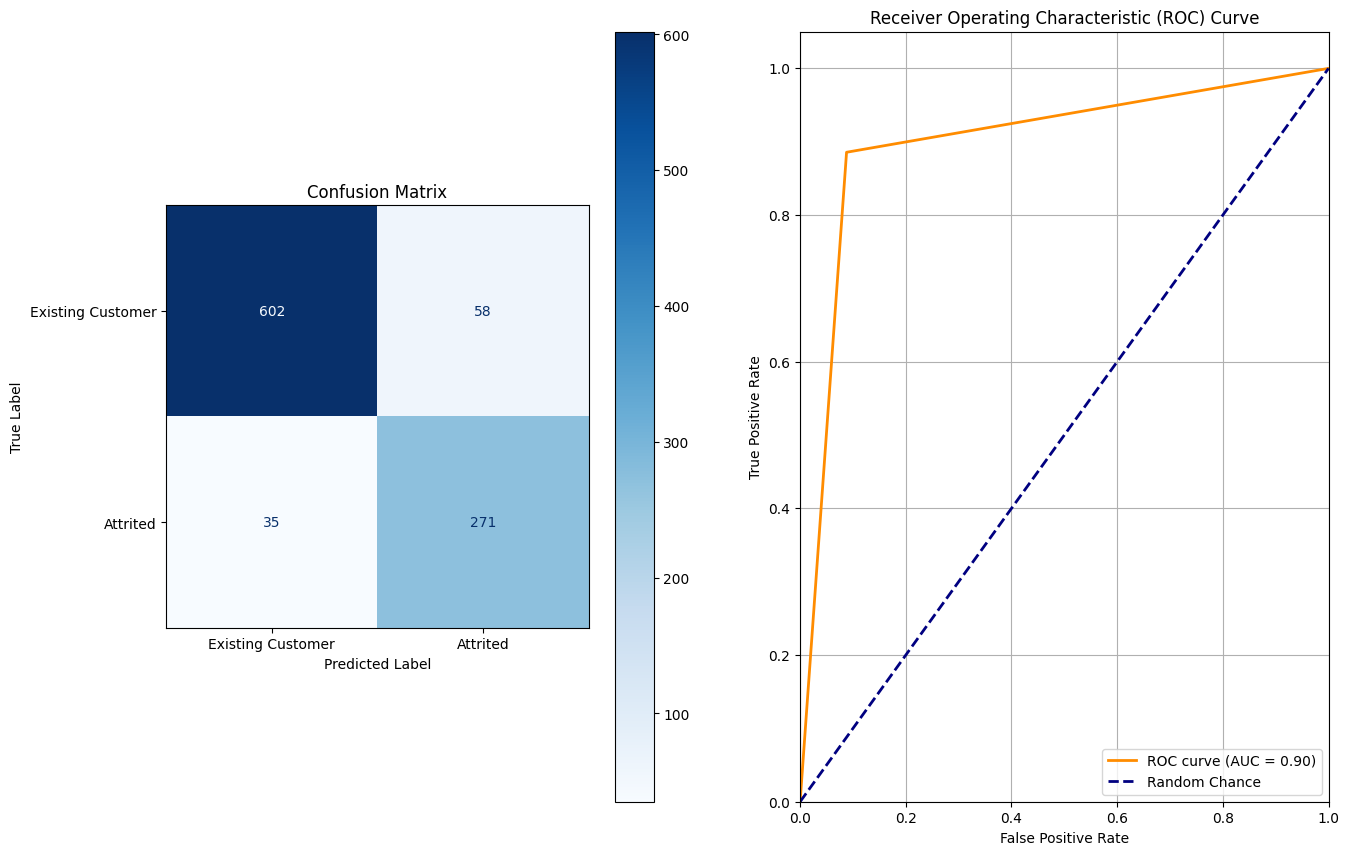

Number of Attrited Predictions: 339
Number of Existing Customer Predictions: 624
Percent Attrited Predictions: 35.202492211838006
Percent Existing Customer Predictions: 64.797507788162

Accuracy: 91.17%

Recall: 0.8802395209580839

Precision: 0.8672566371681416

F1-Score: 0.87


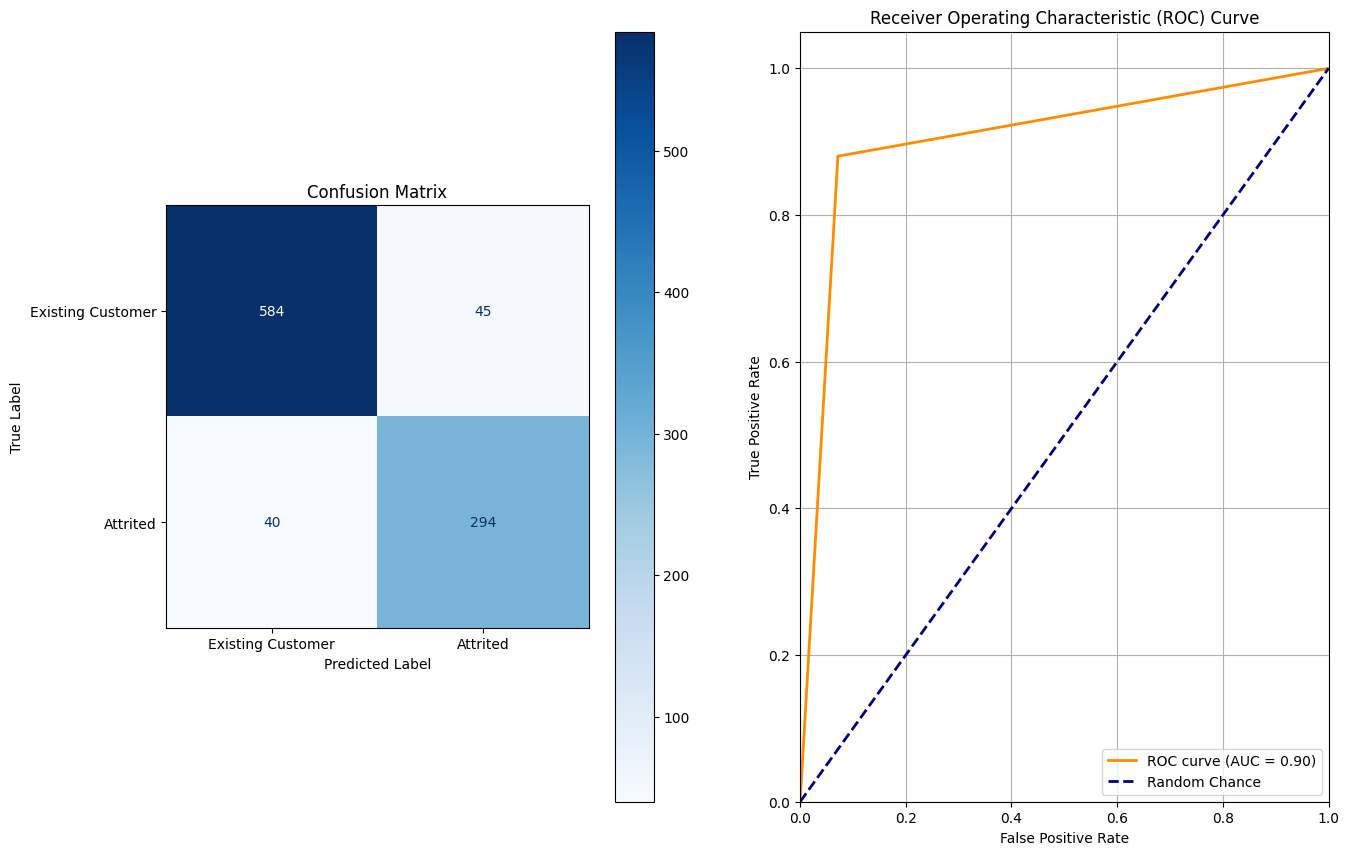

Number of Attrited Predictions: 351
Number of Existing Customer Predictions: 596
Percent Attrited Predictions: 37.06441393875396
Percent Existing Customer Predictions: 62.93558606124604

Accuracy: 91.02%

Recall: 0.8866279069767442

Precision: 0.8689458689458689

F1-Score: 0.88


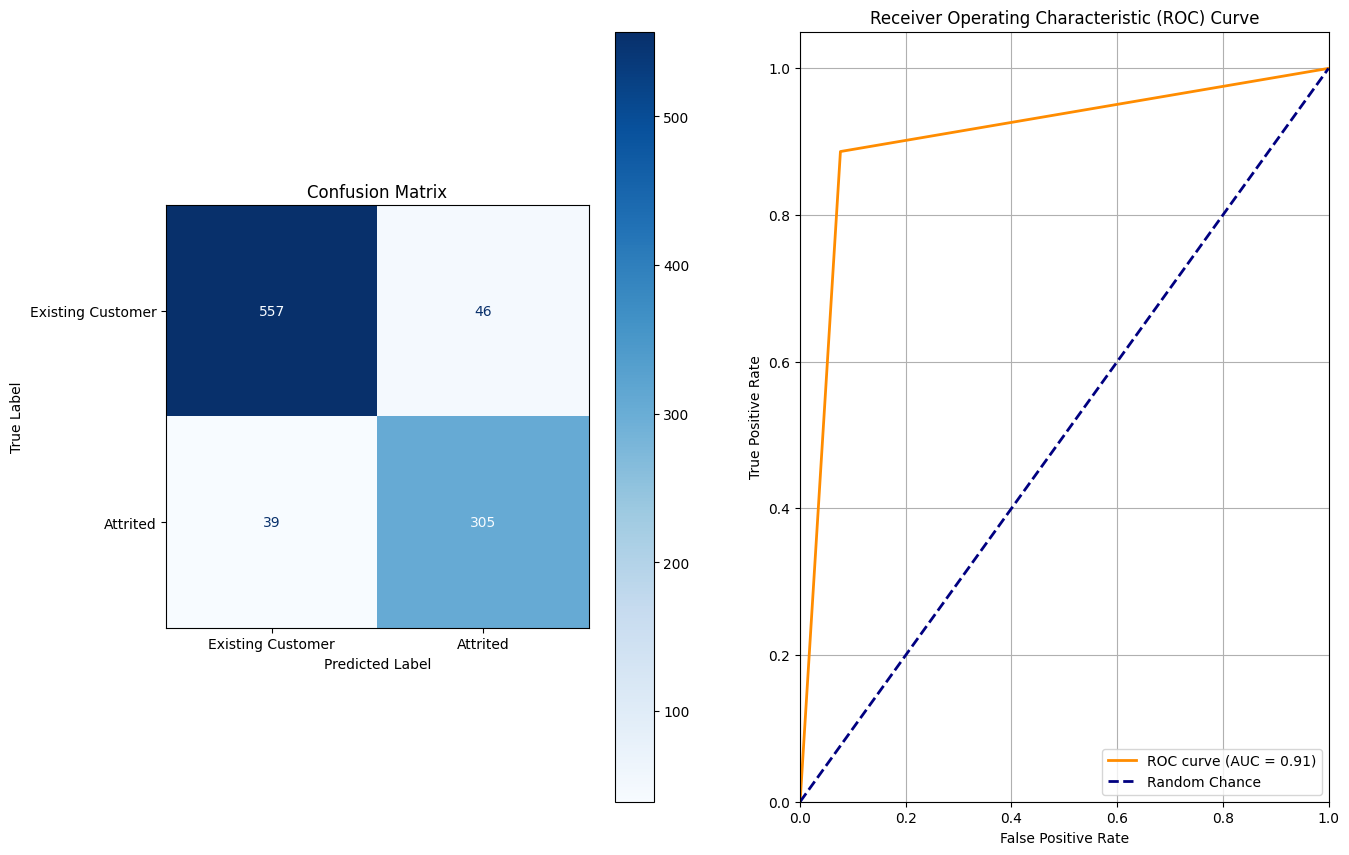

Number of Attrited Predictions: 337
Number of Existing Customer Predictions: 598
Percent Attrited Predictions: 36.0427807486631
Percent Existing Customer Predictions: 63.957219251336895

Accuracy: 91.87%

Recall: 0.9015384615384615

Precision: 0.8694362017804155

F1-Score: 0.89


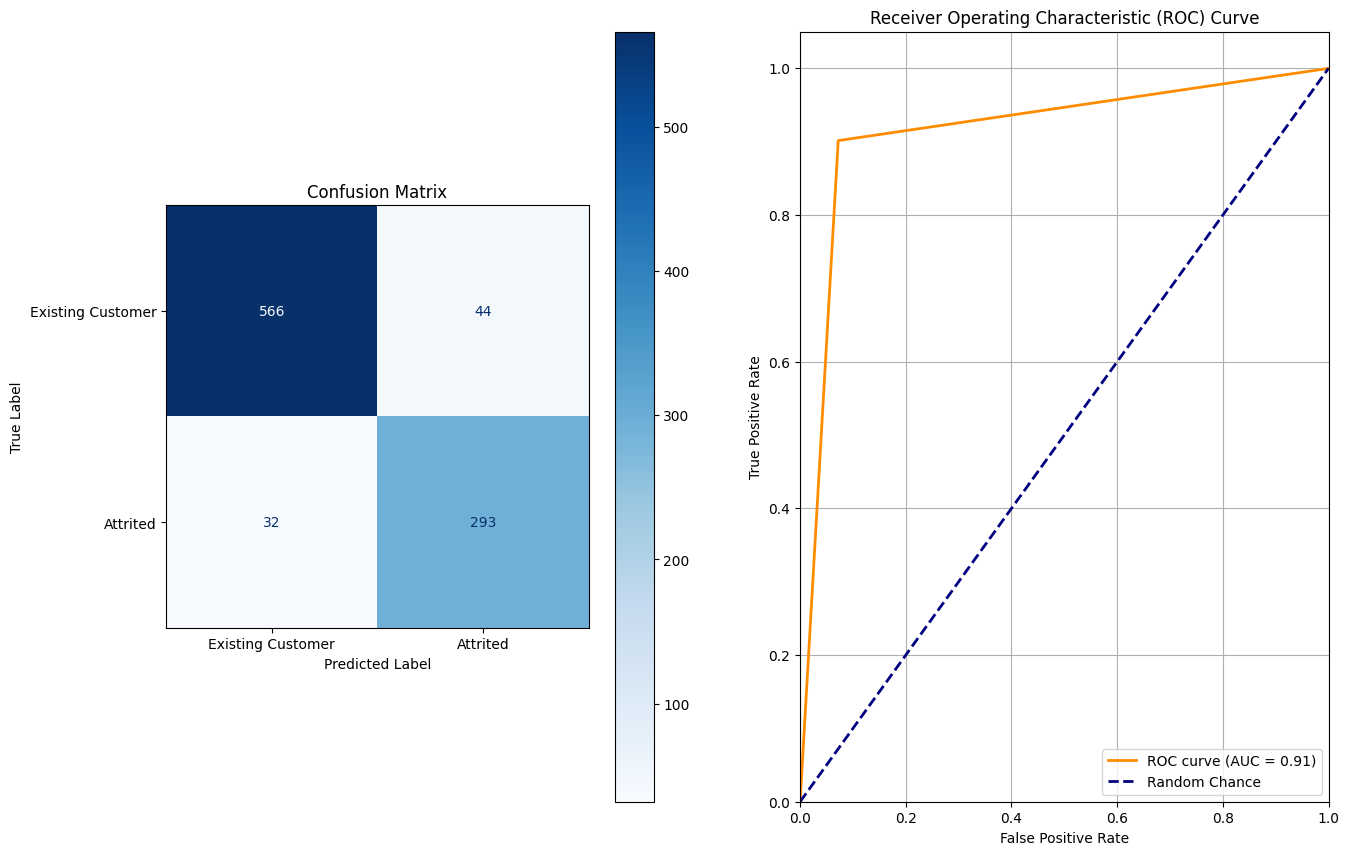

Number of Attrited Predictions: 324
Number of Existing Customer Predictions: 590
Percent Attrited Predictions: 35.44857768052516
Percent Existing Customer Predictions: 64.55142231947484

Accuracy: 90.59%

Recall: 0.8650306748466258

Precision: 0.8703703703703703

F1-Score: 0.87


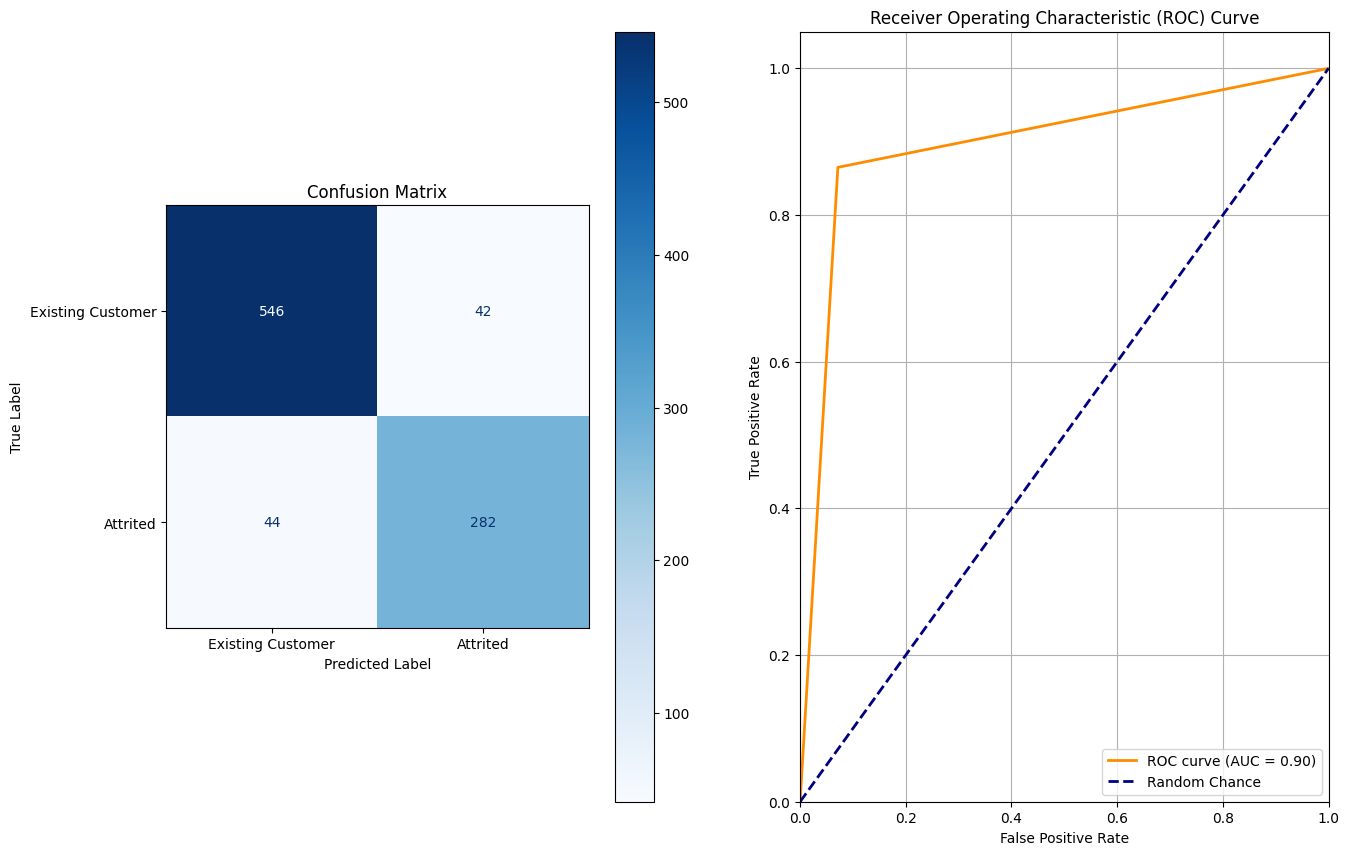

Number of Attrited Predictions: 302
Number of Existing Customer Predictions: 597
Percent Attrited Predictions: 33.59288097886541
Percent Existing Customer Predictions: 66.40711902113459

Accuracy: 91.66%

Recall: 0.8626198083067093

Precision: 0.8940397350993378

F1-Score: 0.88


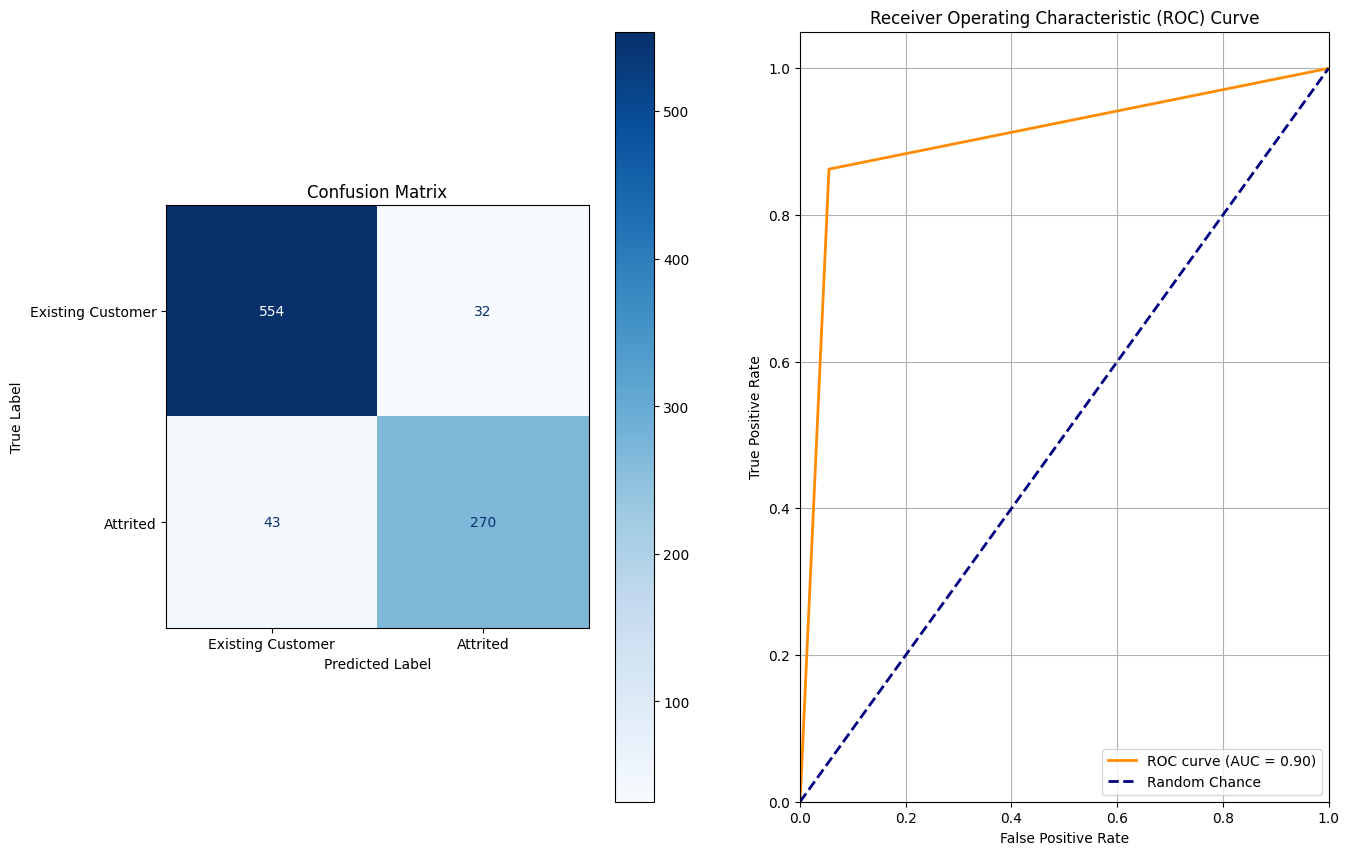

Number of Attrited Predictions: 342
Number of Existing Customer Predictions: 549
Percent Attrited Predictions: 38.38383838383838
Percent Existing Customer Predictions: 61.61616161616161

Accuracy: 90.12%

Recall: 0.8779761904761905

Precision: 0.8625730994152047

F1-Score: 0.87


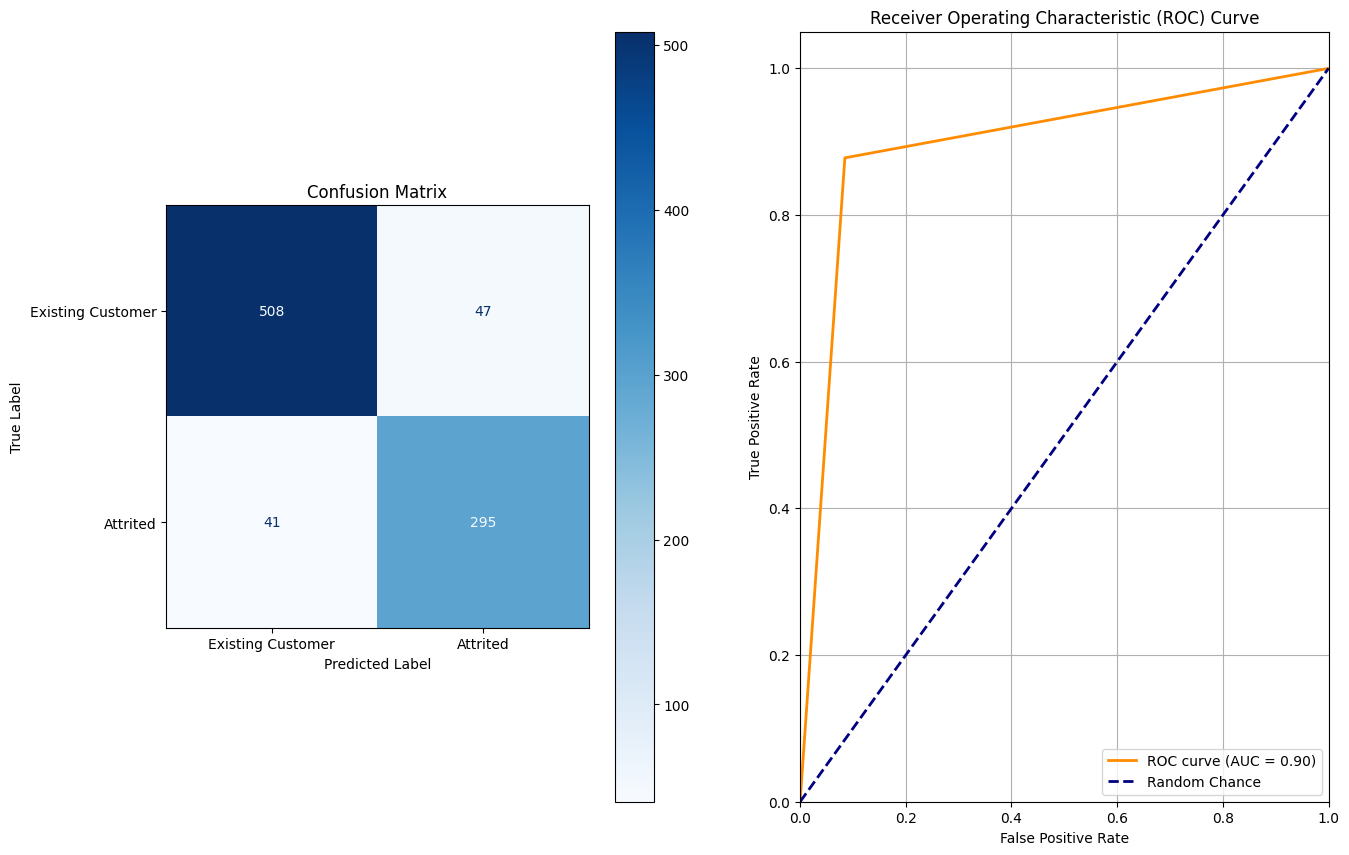

Number of Attrited Predictions: 315
Number of Existing Customer Predictions: 555
Percent Attrited Predictions: 36.206896551724135
Percent Existing Customer Predictions: 63.793103448275865

Accuracy: 92.07%

Recall: 0.8796296296296297

Precision: 0.9047619047619048

F1-Score: 0.89


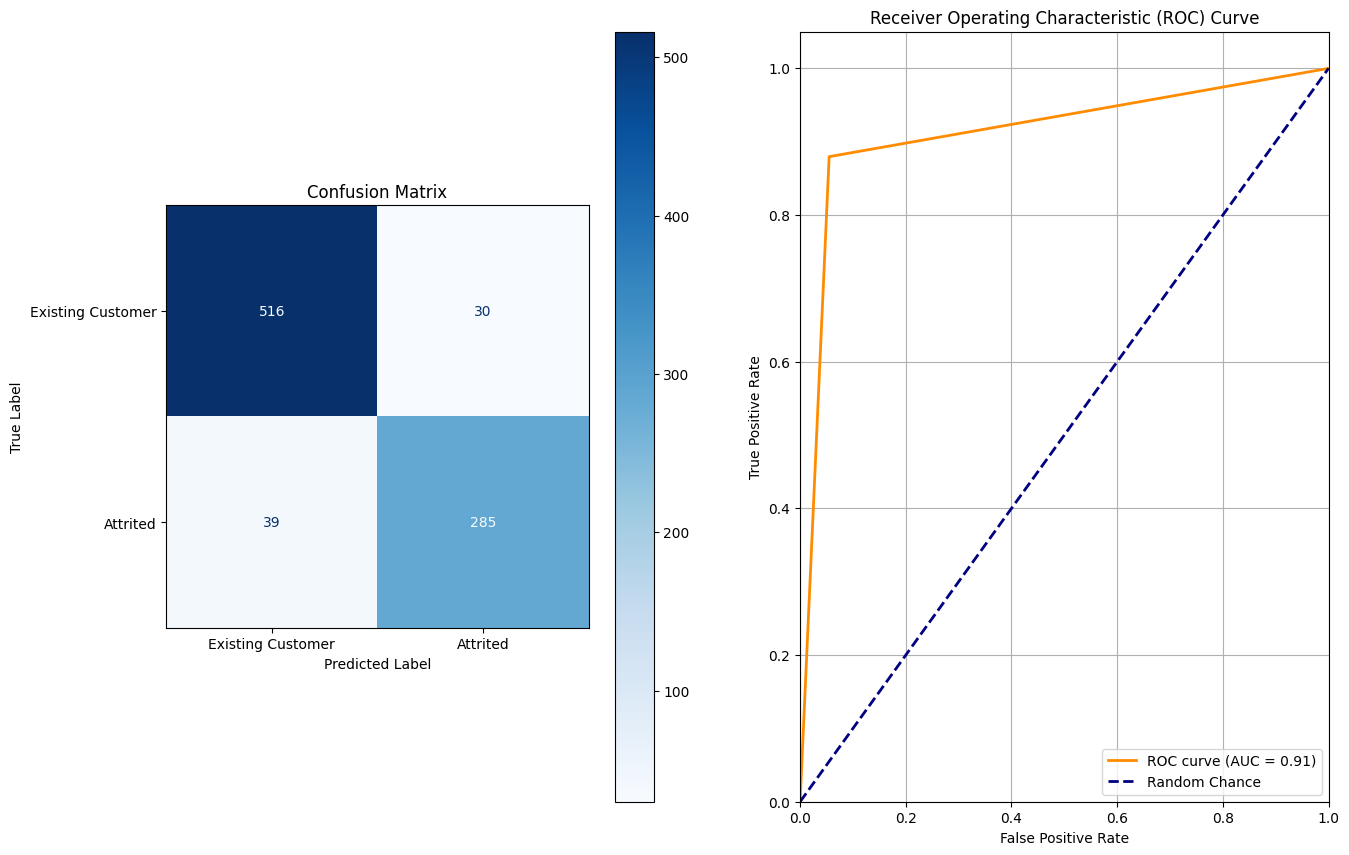

Number of Attrited Predictions: 326
Number of Existing Customer Predictions: 524
Percent Attrited Predictions: 38.35294117647059
Percent Existing Customer Predictions: 61.64705882352941

Accuracy: 90.82%

Recall: 0.8850931677018633

Precision: 0.8742331288343558

F1-Score: 0.88


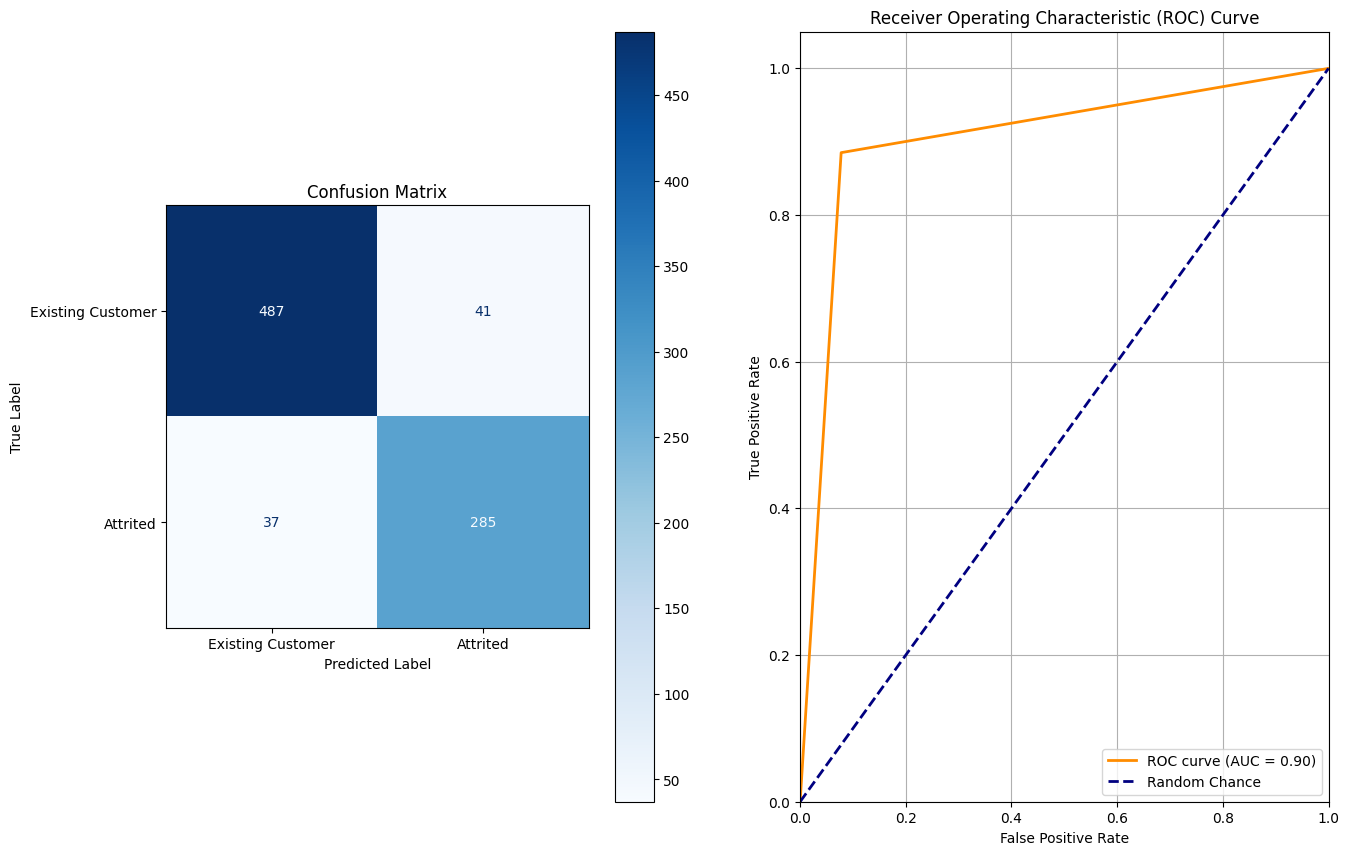

Number of Attrited Predictions: 305
Number of Existing Customer Predictions: 519
Percent Attrited Predictions: 37.01456310679612
Percent Existing Customer Predictions: 62.98543689320388

Accuracy: 92.72%

Recall: 0.9069767441860465

Precision: 0.8950819672131147

F1-Score: 0.90


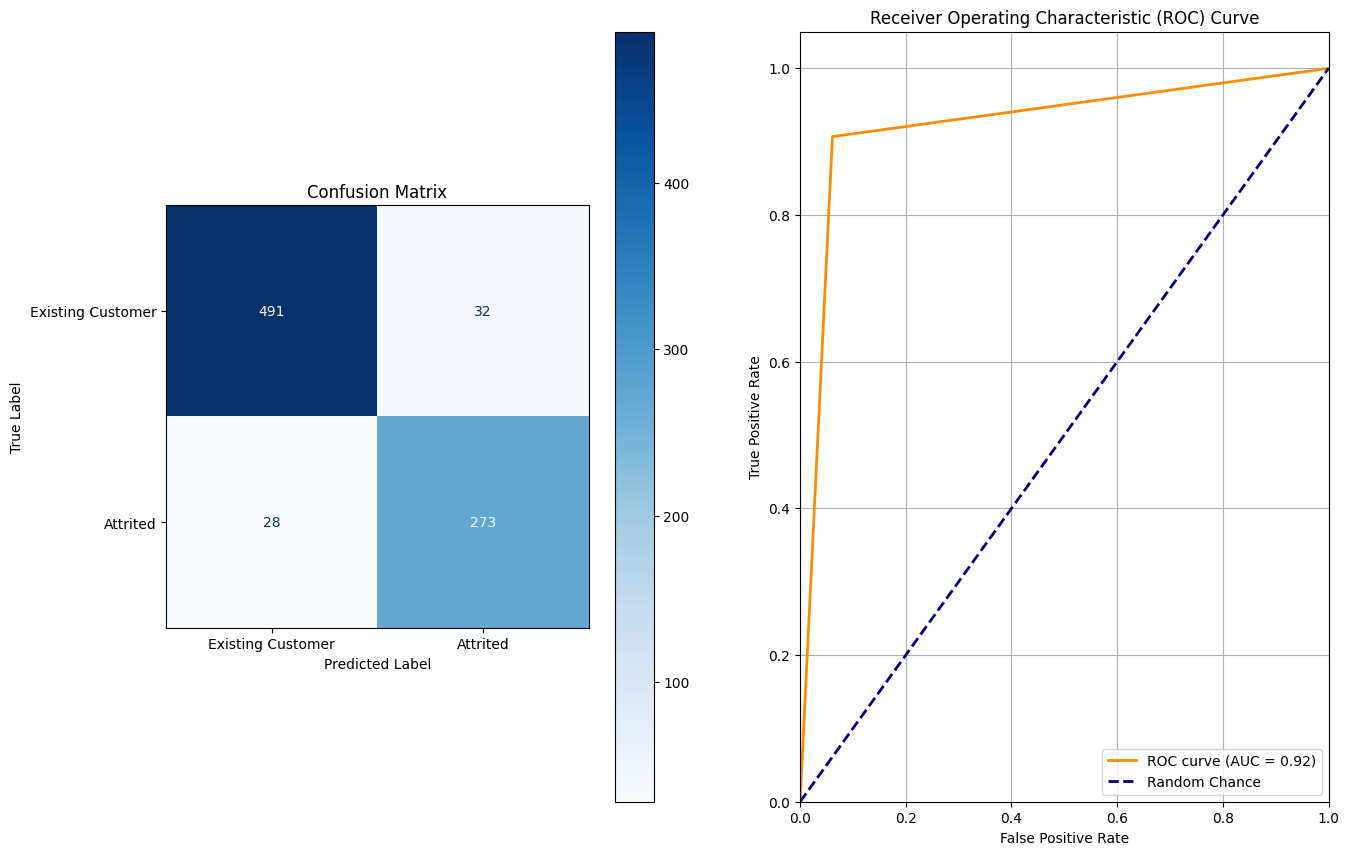

Number of Attrited Predictions: 305
Number of Existing Customer Predictions: 501
Percent Attrited Predictions: 37.84119106699752
Percent Existing Customer Predictions: 62.15880893300248

Accuracy: 90.69%

Recall: 0.8833333333333333

Precision: 0.8688524590163934

F1-Score: 0.88


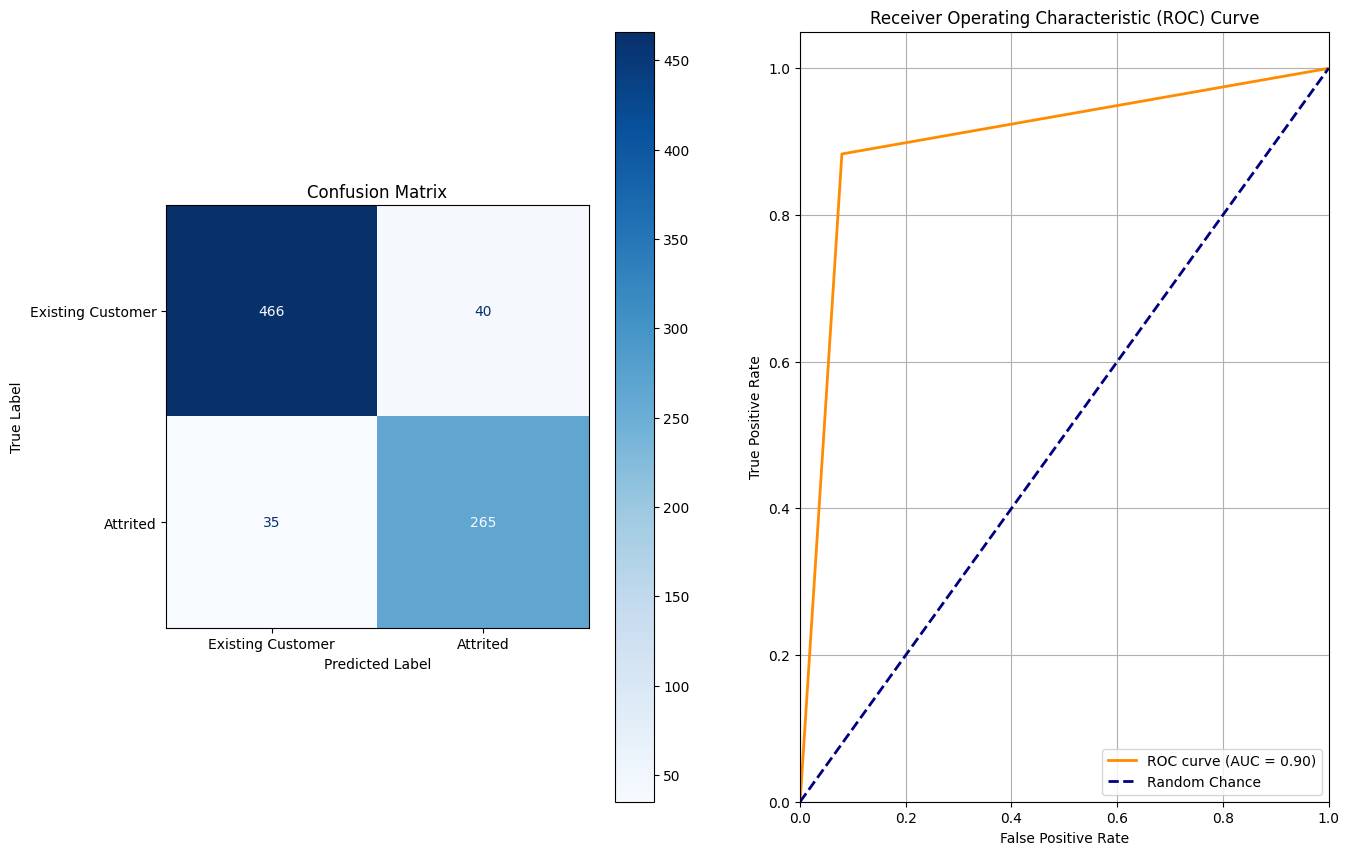

Number of Attrited Predictions: 327
Number of Existing Customer Predictions: 458
Percent Attrited Predictions: 41.65605095541402
Percent Existing Customer Predictions: 58.34394904458598

Accuracy: 90.45%

Recall: 0.8865030674846626

Precision: 0.8837920489296636

F1-Score: 0.89


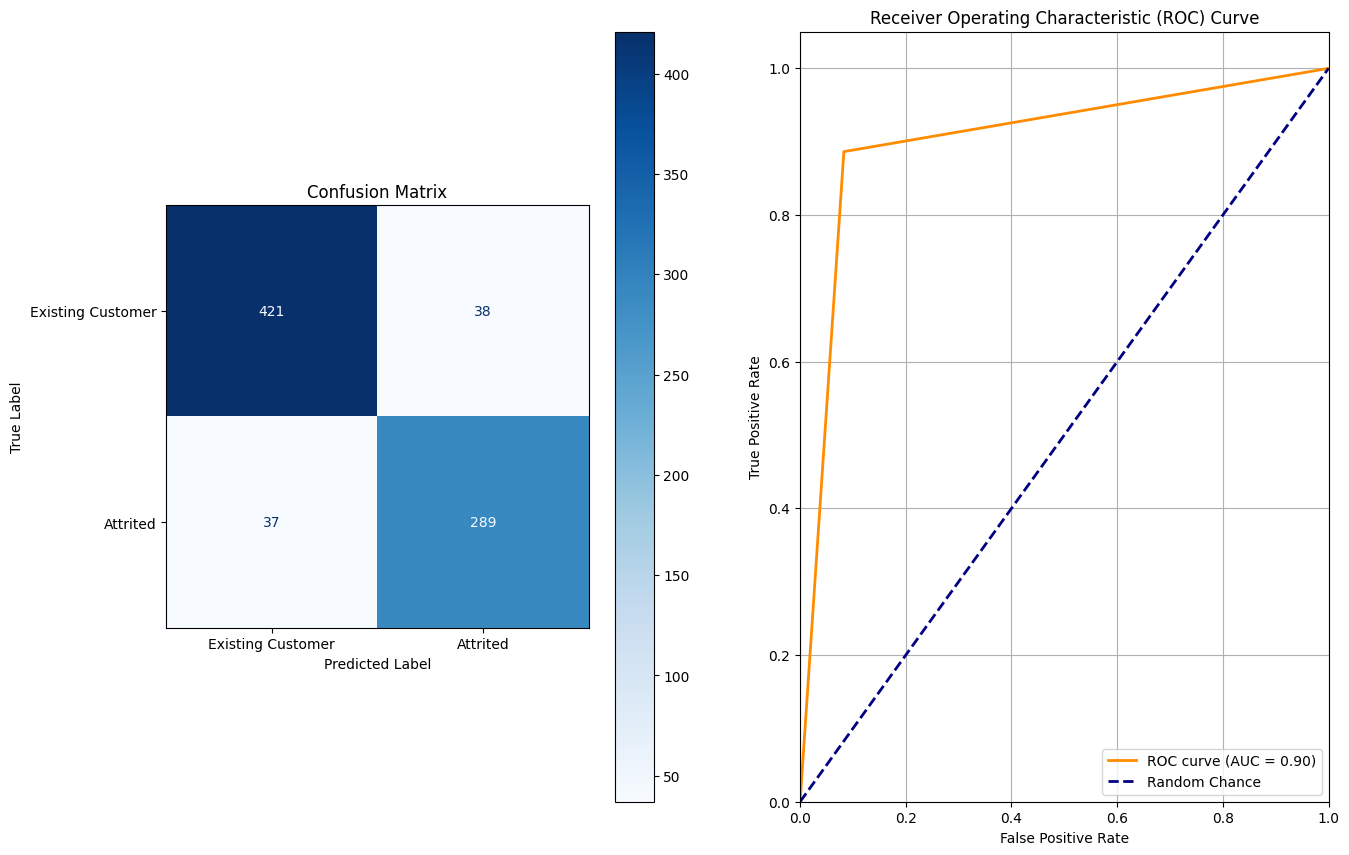

Number of Attrited Predictions: 322
Number of Existing Customer Predictions: 450
Percent Attrited Predictions: 41.70984455958549
Percent Existing Customer Predictions: 58.2901554404145

Accuracy: 89.12%

Recall: 0.8814102564102564

Precision: 0.8540372670807453

F1-Score: 0.87


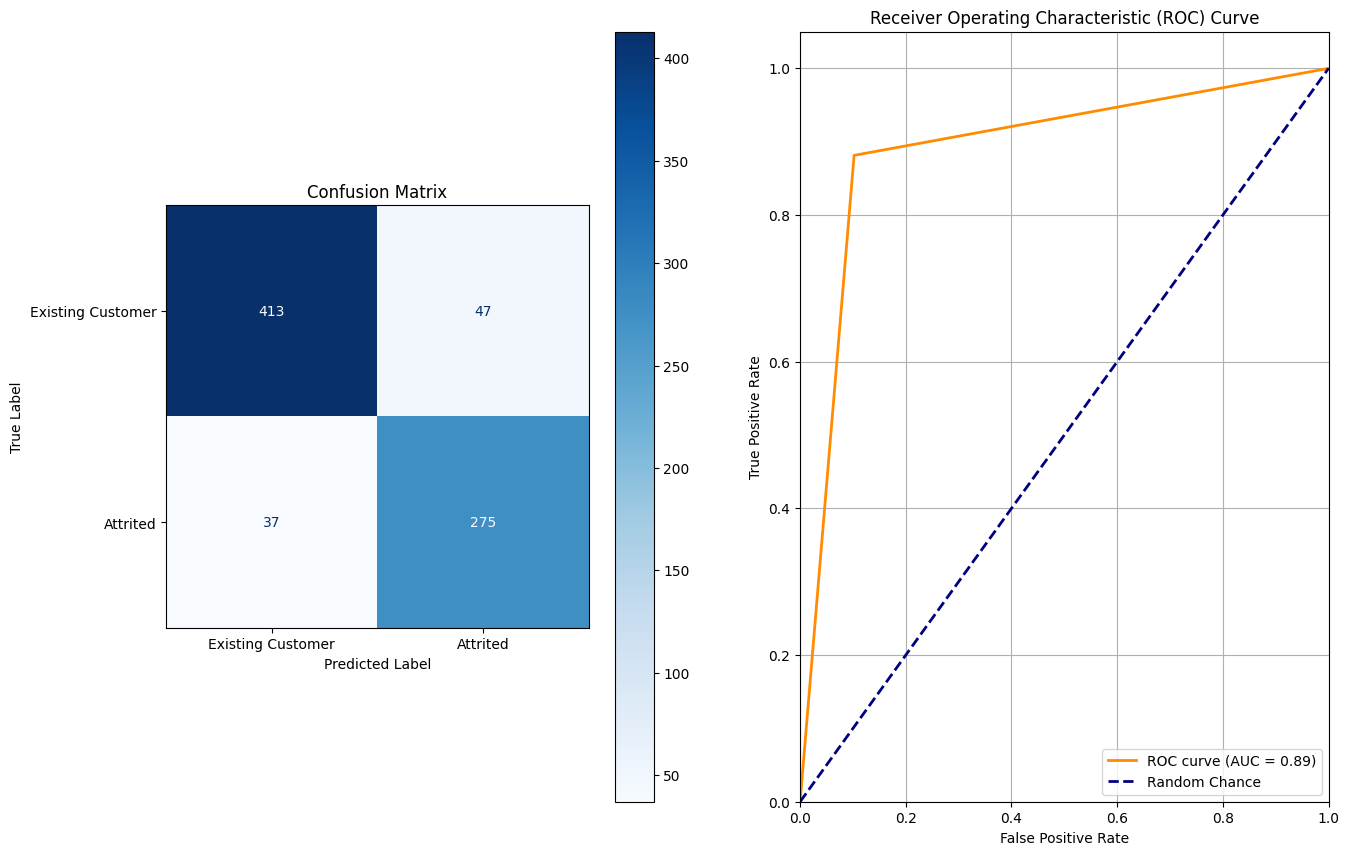

Number of Attrited Predictions: 336
Number of Existing Customer Predictions: 416
Percent Attrited Predictions: 44.680851063829785
Percent Existing Customer Predictions: 55.319148936170215

Accuracy: 90.69%

Recall: 0.9006024096385542

Precision: 0.8898809523809523

F1-Score: 0.90


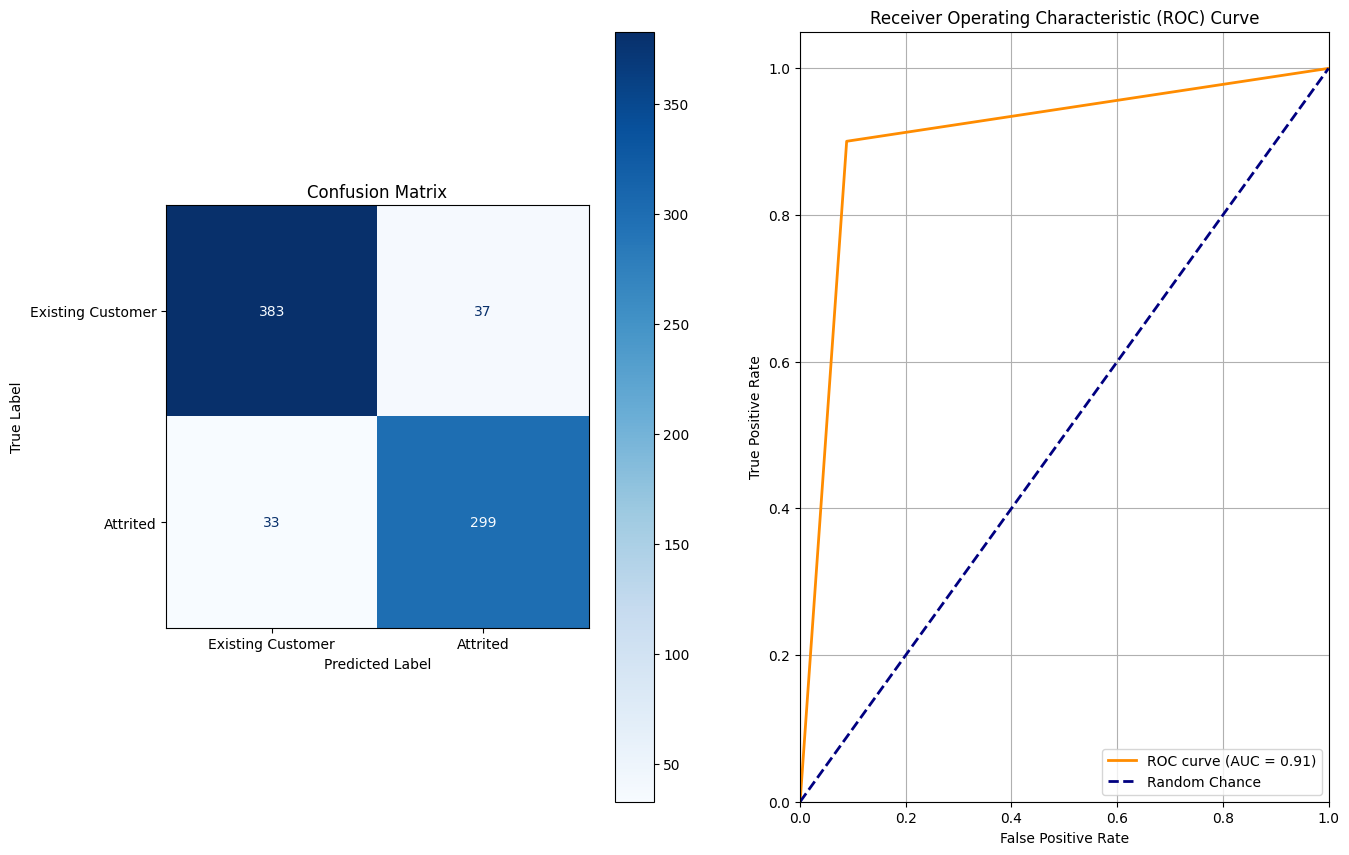

Number of Attrited Predictions: 317
Number of Existing Customer Predictions: 421
Percent Attrited Predictions: 42.953929539295395
Percent Existing Customer Predictions: 57.04607046070461

Accuracy: 91.33%

Recall: 0.8990536277602523

Precision: 0.8990536277602523

F1-Score: 0.90


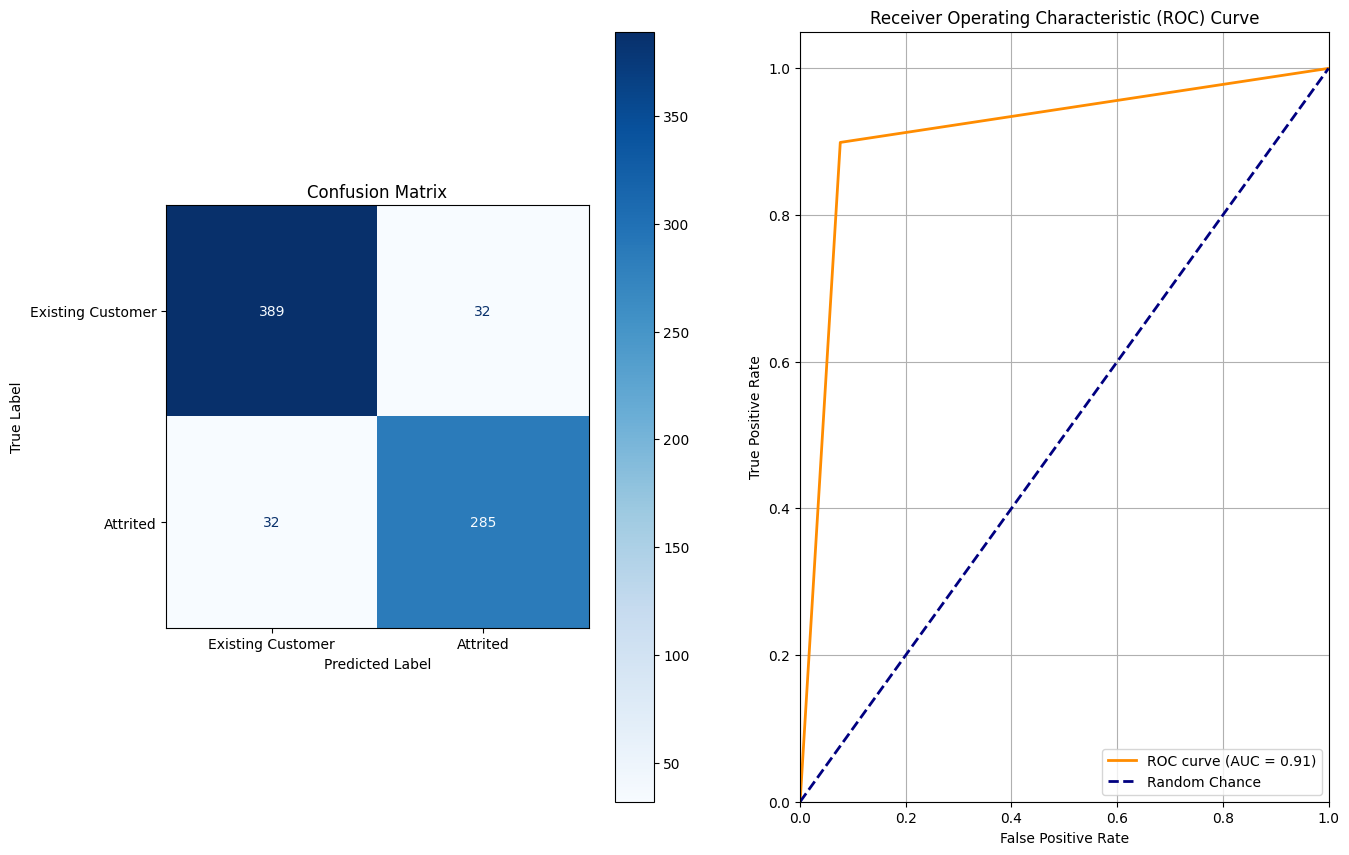

Number of Attrited Predictions: 327
Number of Existing Customer Predictions: 401
Percent Attrited Predictions: 44.917582417582416
Percent Existing Customer Predictions: 55.082417582417584

Accuracy: 90.25%

Recall: 0.8975155279503105

Precision: 0.8837920489296636

F1-Score: 0.89


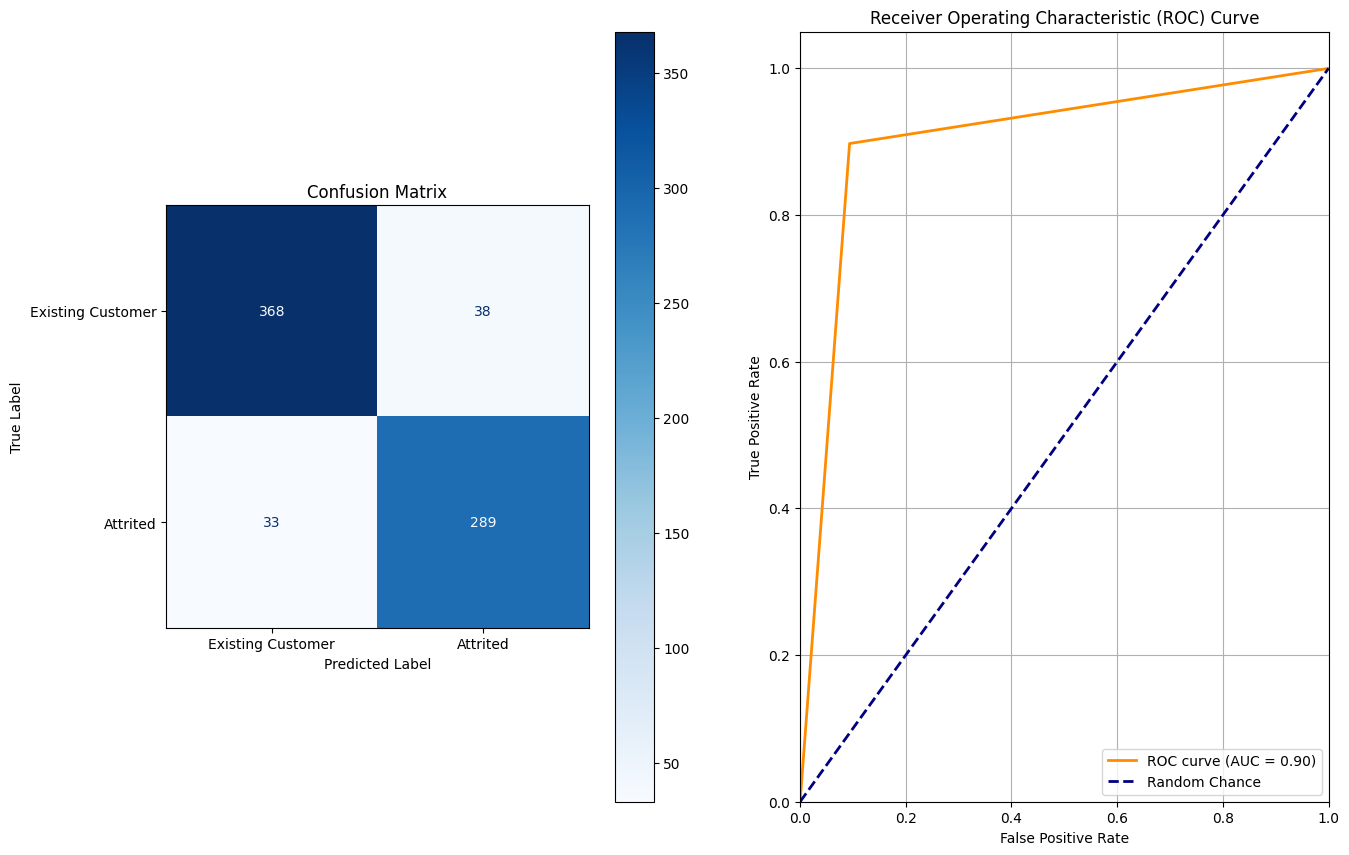

In [352]:
for j in range(50, 80, 5):
    for i in range(5,30,5):

        dtc_data = remove_outliers(data, i)

        dtc_data = reduce_data(dtc_data, j)

        dtc_data = dtc_data.drop(['index', 'CLIENTNUM', 'level_0'], axis = 1)

        training_data, test_data = split_data(dtc_data)

        model = MS(training_data.columns.drop('Attrition_Flag'), intercept=False)
        D = model.fit_transform(training_data) 
        feature_names = list(D.columns)
        X_train = np.asarray(D)
        Y_train = training_data['Attrition_Flag']

        model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
        D = model.fit_transform(test_data) 
        feature_names = list(D.columns)
        X_test = np.asarray(D)
        Y_test = test_data['Attrition_Flag']

        optimal_size = optimize_DTC_size(1, 50, X_train, Y_train, X_test, Y_test)
        optimal_alpha = prune_optimized_DTC(optimal_size, X_train, Y_train, X_test, Y_test)

        tuned_DTC = DTC(criterion='entropy',
                            max_depth=optimal_size,
                            random_state=0,
                            ccp_alpha=optimal_alpha[0])

        tuned_DTC.fit(X_train, Y_train)

        determine_dtc_importances(tuned_DTC, f'{i}%_Outlier_Reduction_{j}%_Class_Reduction')

        labels = ['Existing Customer', 'Attrited']

        model = ModelEvaluator("Decision Tree Classifier", tuned_DTC)

        model_results = {model.name:[]}

        model.eval_model(X_test, Y_test, labels)

        model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

        summary_table[f'{i}%_Outlier_Reduction_{j}%_Class_Reduction'] = model_results

## Complete this process with the GBR model

5 0.05333333333333334
Number of Attrited Predictions: 318
Number of Existing Customer Predictions: 924
Percent Attrited Predictions: 25.60386473429952
Percent Existing Customer Predictions: 74.39613526570048

Accuracy: 97.83%

Recall: 0.9504643962848297

Precision: 0.9654088050314465

F1-Score: 0.96


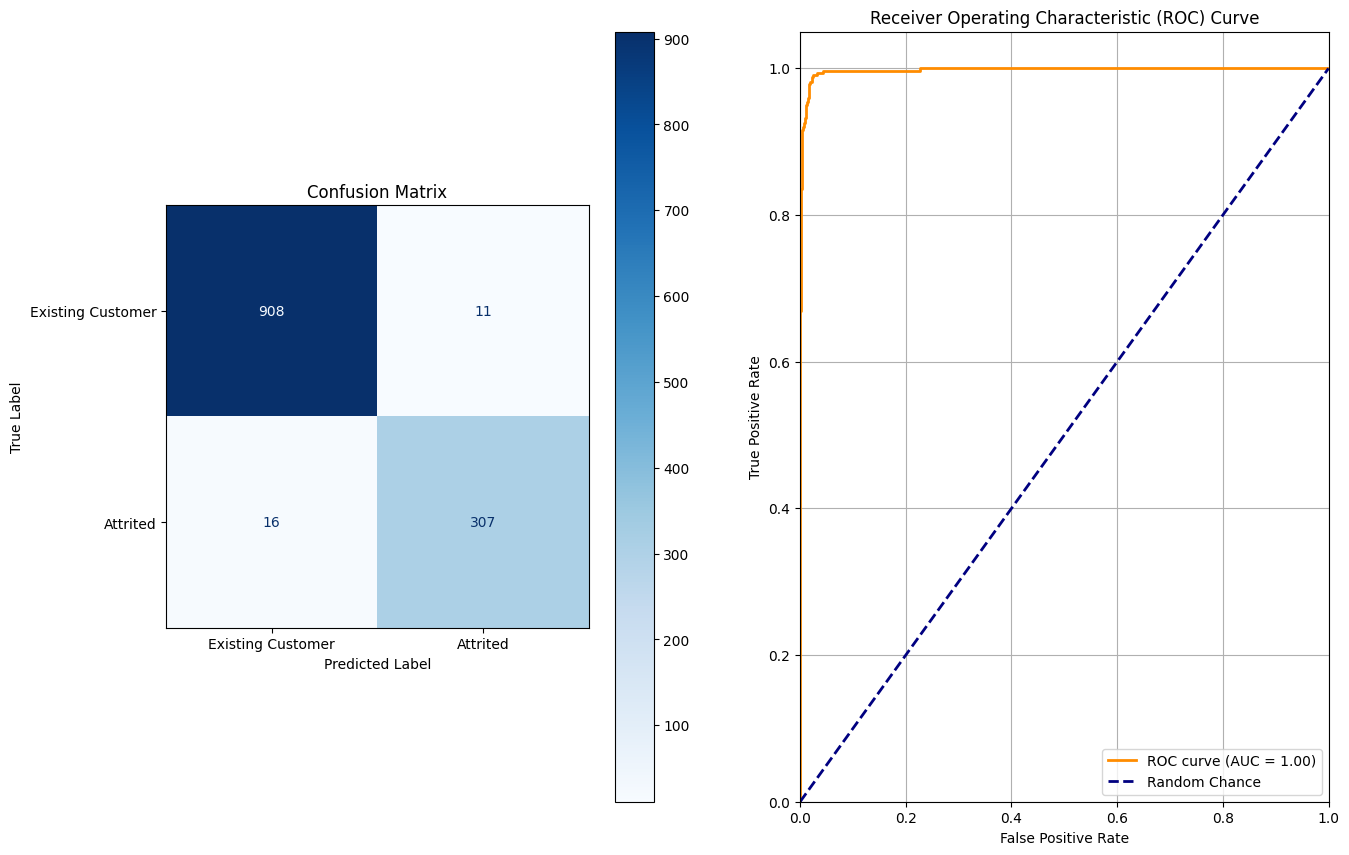

5 0.05333333333333334
Number of Attrited Predictions: 331
Number of Existing Customer Predictions: 887
Percent Attrited Predictions: 27.175697865353037
Percent Existing Customer Predictions: 72.82430213464697

Accuracy: 98.36%

Recall: 0.9697885196374623

Precision: 0.9697885196374623

F1-Score: 0.97


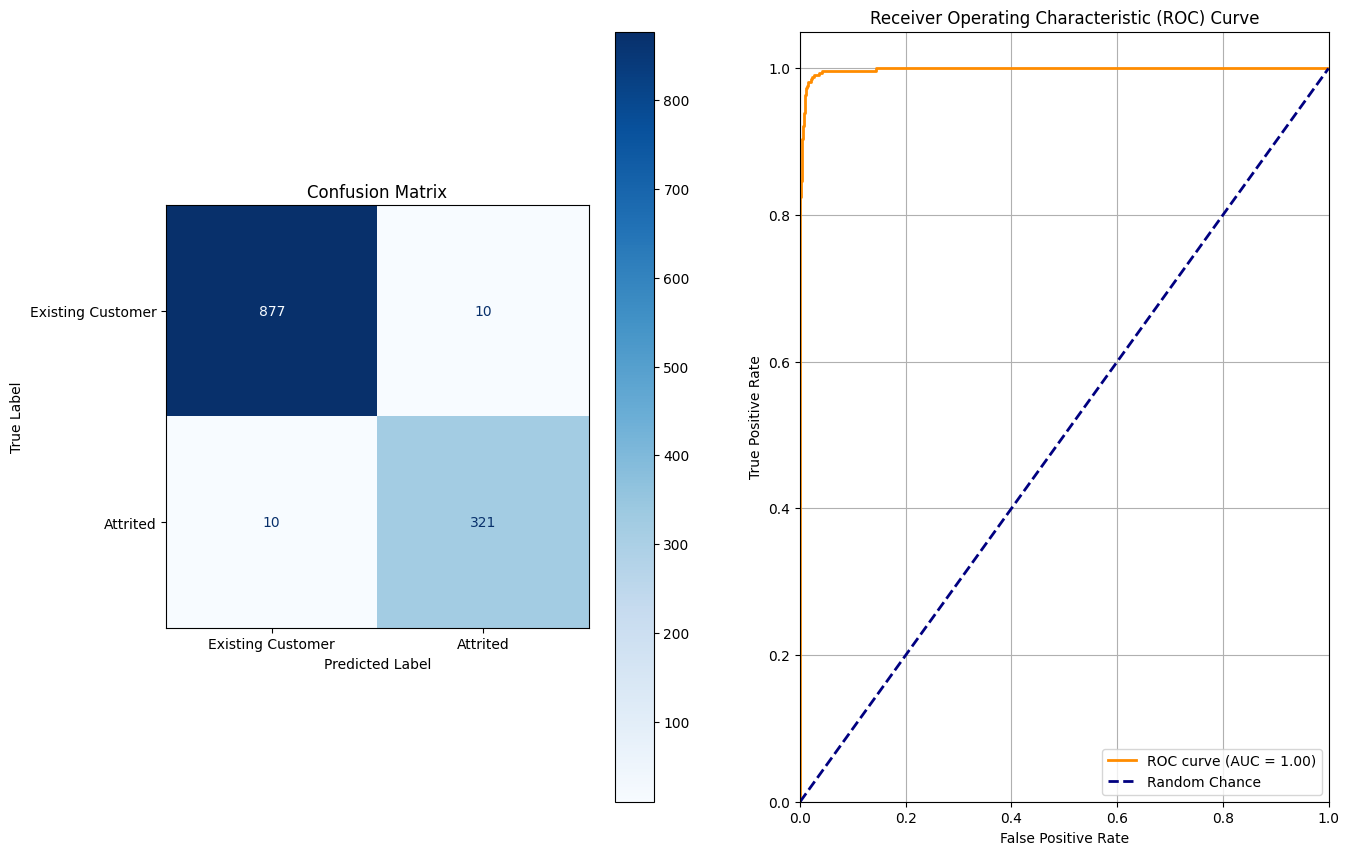

5 0.075
Number of Attrited Predictions: 314
Number of Existing Customer Predictions: 863
Percent Attrited Predictions: 26.677994902293968
Percent Existing Customer Predictions: 73.32200509770604

Accuracy: 98.30%

Recall: 0.959375

Precision: 0.9777070063694268

F1-Score: 0.97


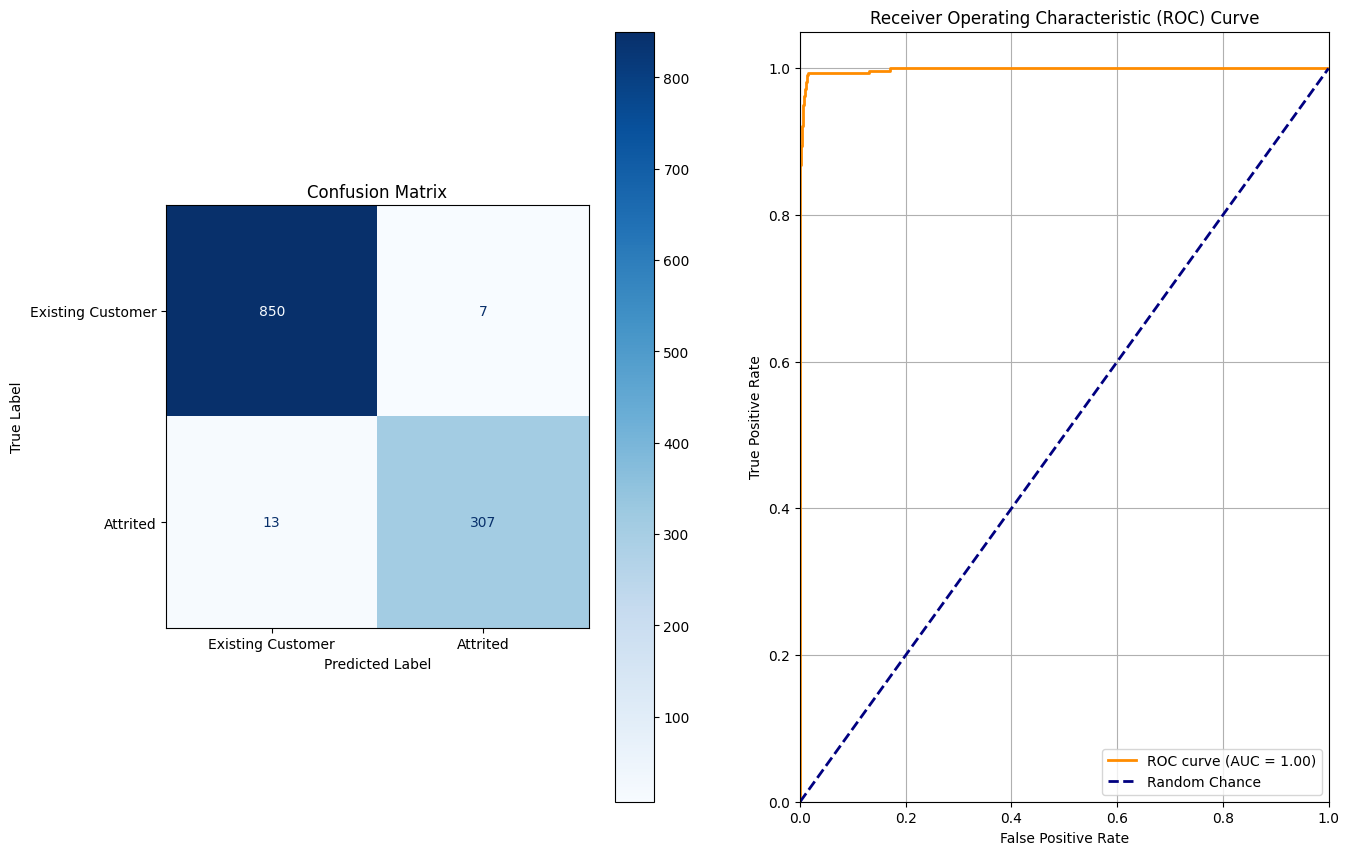

5 0.06777777777777778
Number of Attrited Predictions: 291
Number of Existing Customer Predictions: 857
Percent Attrited Predictions: 25.348432055749132
Percent Existing Customer Predictions: 74.65156794425087

Accuracy: 98.78%

Recall: 0.9759450171821306

Precision: 0.9759450171821306

F1-Score: 0.98


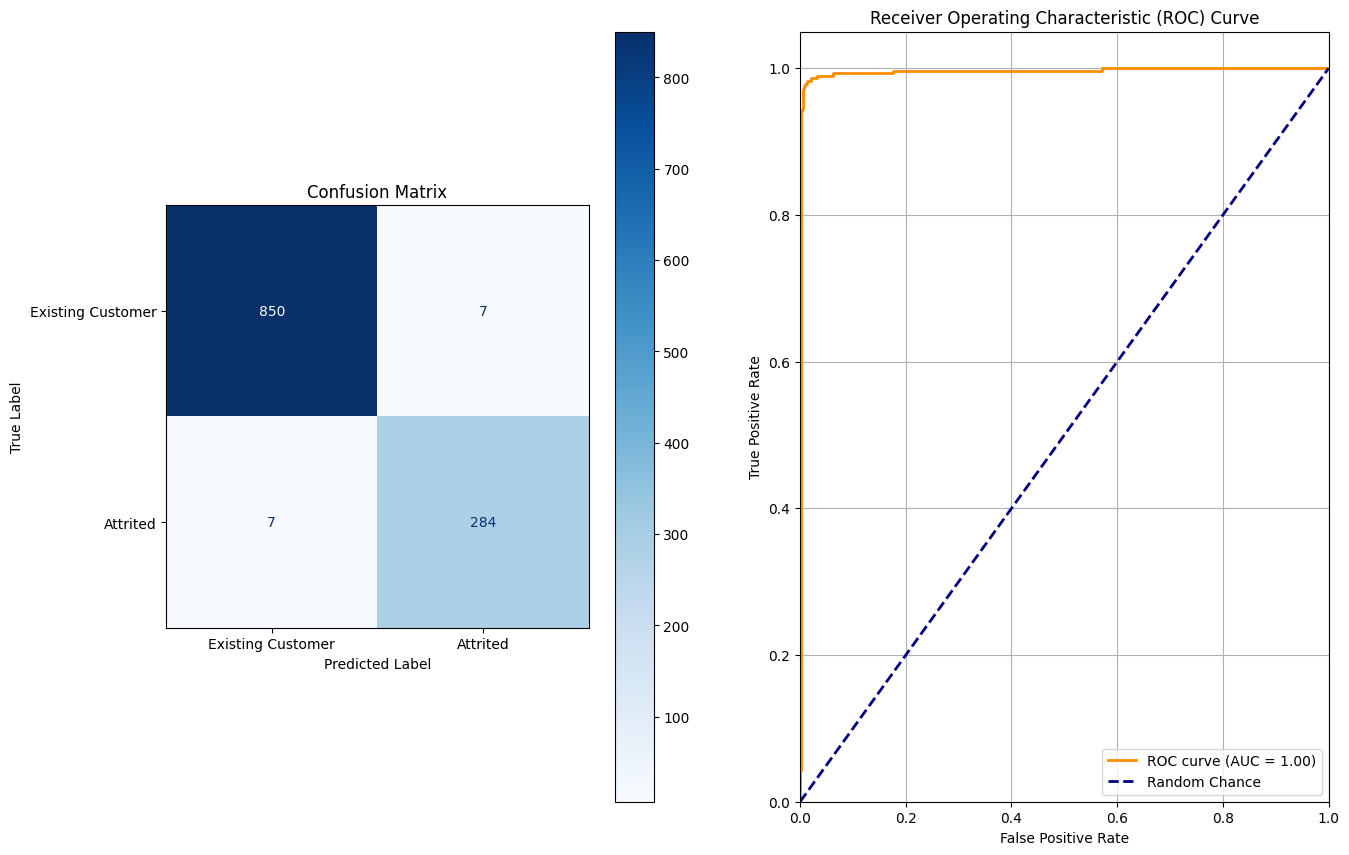

5 0.03166666666666667
Number of Attrited Predictions: 317
Number of Existing Customer Predictions: 805
Percent Attrited Predictions: 28.25311942959002
Percent Existing Customer Predictions: 71.74688057040999

Accuracy: 97.95%

Recall: 0.9711538461538461

Precision: 0.9558359621451105

F1-Score: 0.96


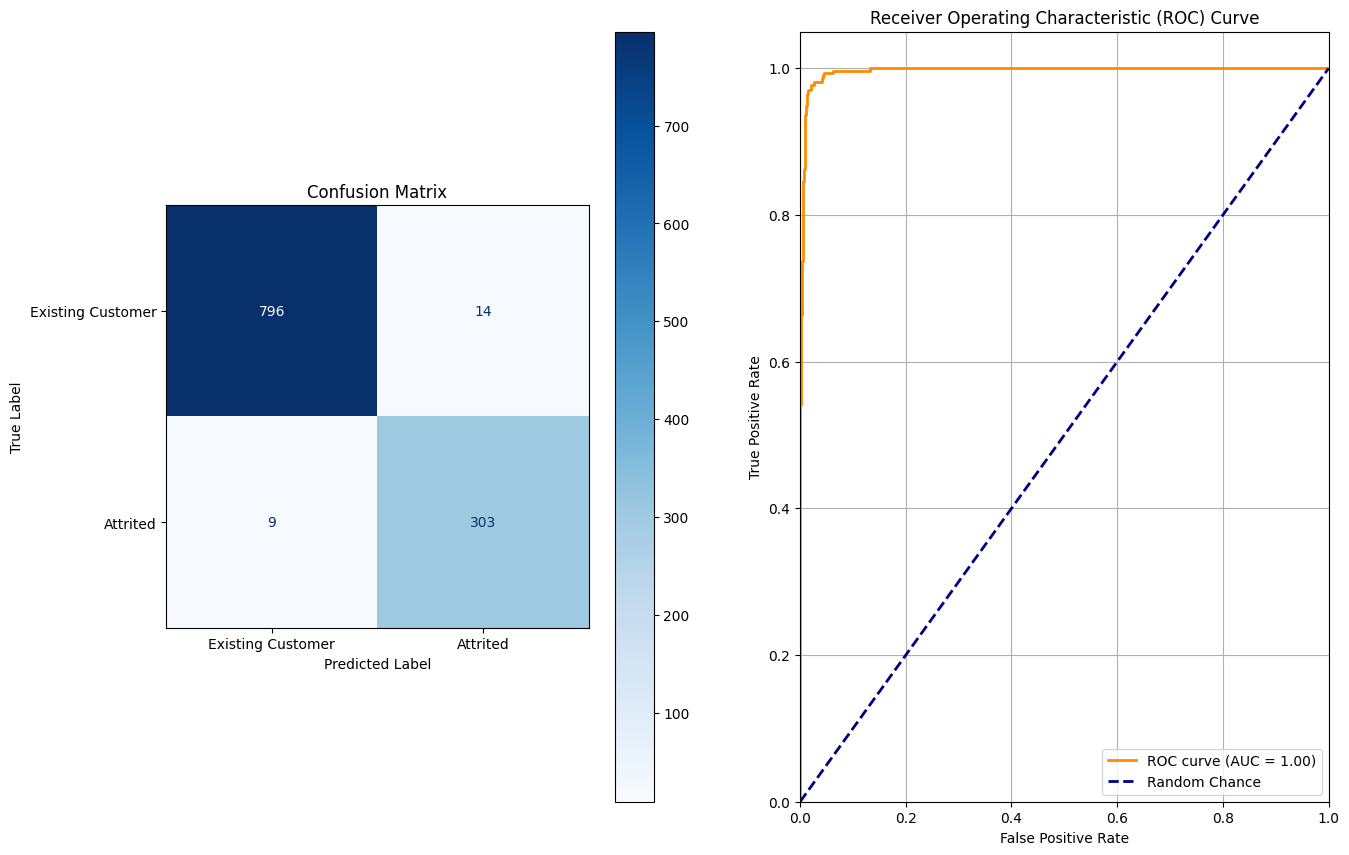

5 0.060555555555555564
Number of Attrited Predictions: 356
Number of Existing Customer Predictions: 786
Percent Attrited Predictions: 31.17338003502627
Percent Existing Customer Predictions: 68.82661996497373

Accuracy: 98.16%

Recall: 0.9745042492917847

Precision: 0.9662921348314607

F1-Score: 0.97


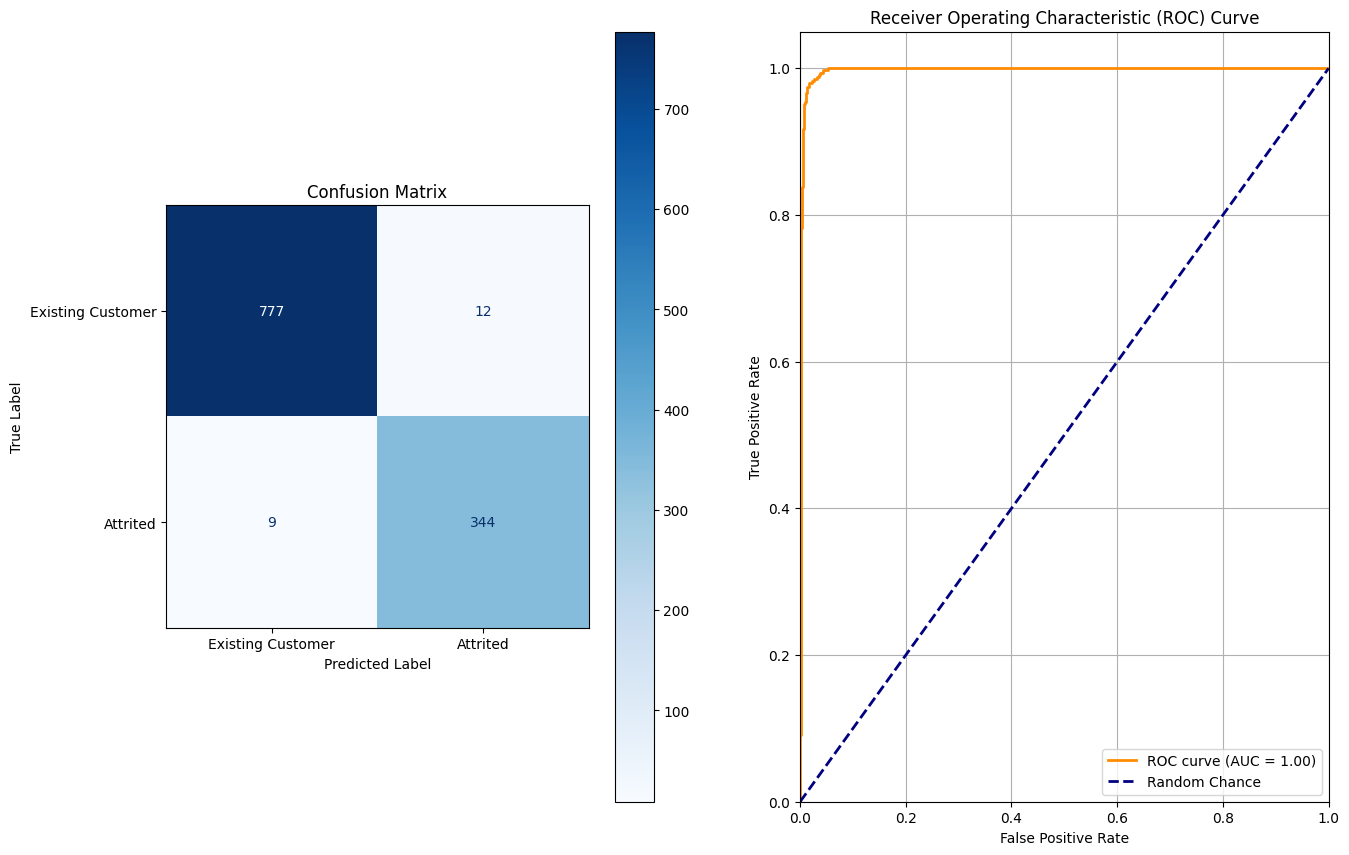

7 0.060555555555555564
Number of Attrited Predictions: 328
Number of Existing Customer Predictions: 784
Percent Attrited Predictions: 29.496402877697843
Percent Existing Customer Predictions: 70.50359712230215

Accuracy: 98.20%

Recall: 0.9610778443113772

Precision: 0.9786585365853658

F1-Score: 0.97


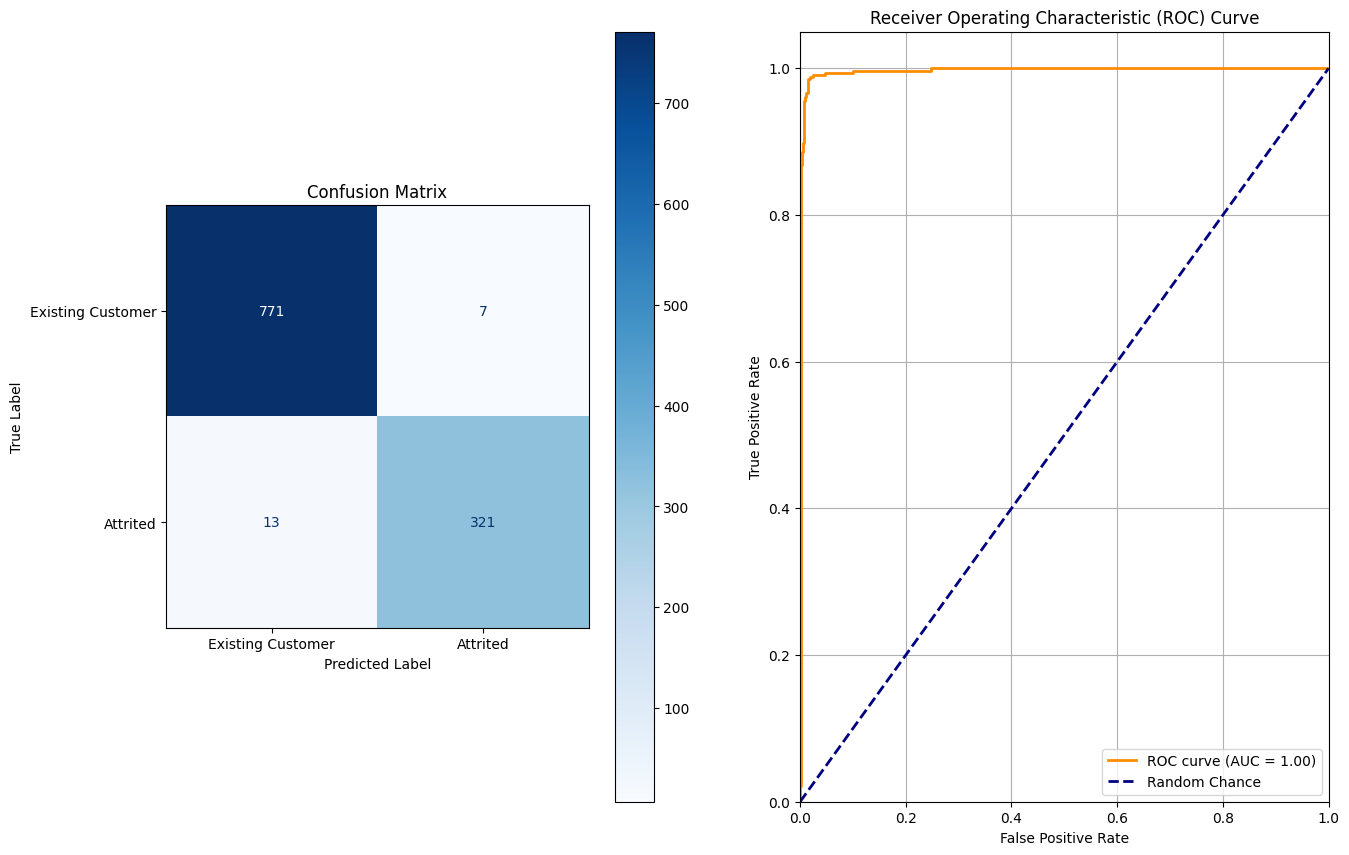

5 0.03888888888888889
Number of Attrited Predictions: 302
Number of Existing Customer Predictions: 786
Percent Attrited Predictions: 27.75735294117647
Percent Existing Customer Predictions: 72.24264705882352

Accuracy: 96.69%

Recall: 0.9182389937106918

Precision: 0.9668874172185431

F1-Score: 0.94


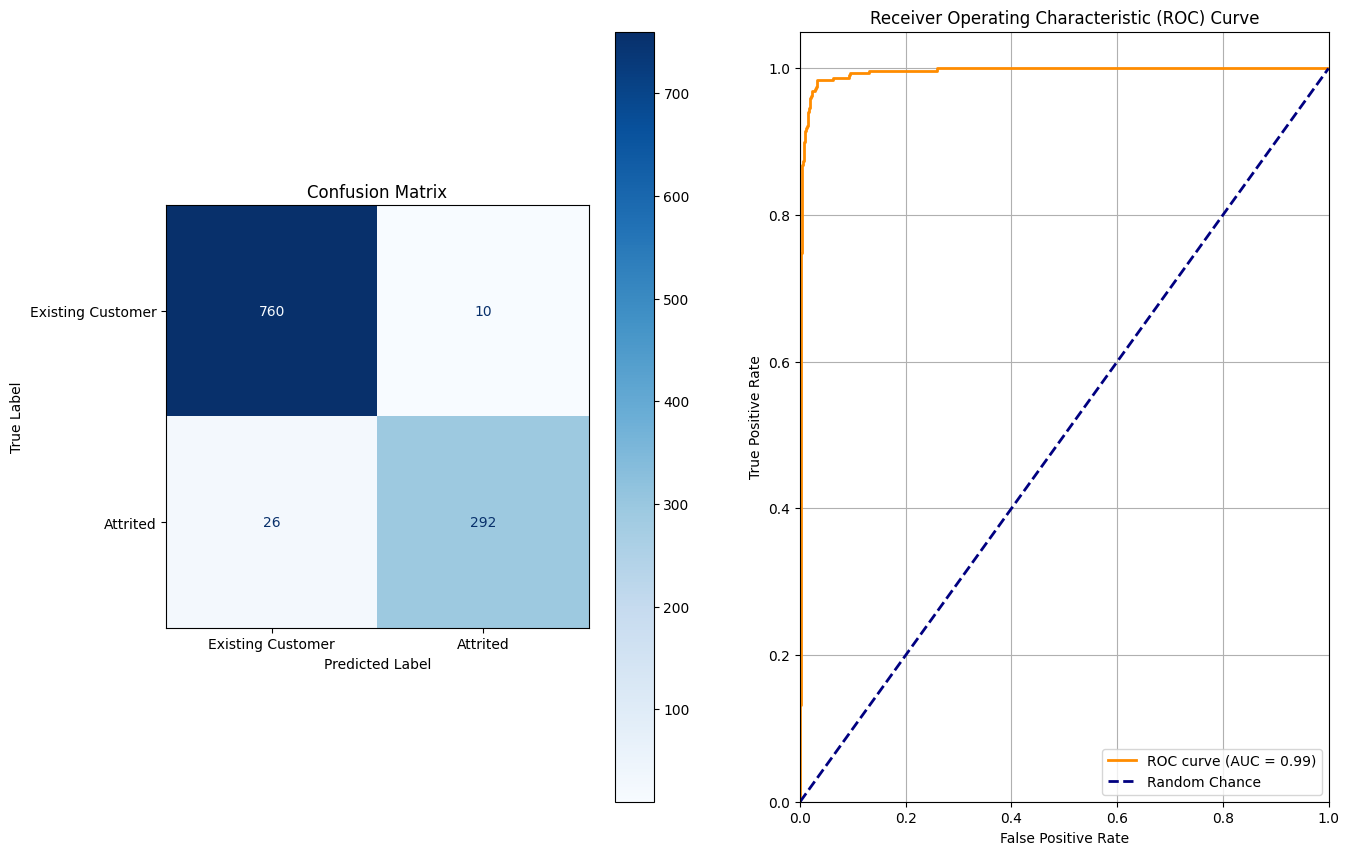

6 0.060555555555555564
Number of Attrited Predictions: 318
Number of Existing Customer Predictions: 742
Percent Attrited Predictions: 30.0
Percent Existing Customer Predictions: 70.0

Accuracy: 98.21%

Recall: 0.9686520376175548

Precision: 0.9716981132075472

F1-Score: 0.97


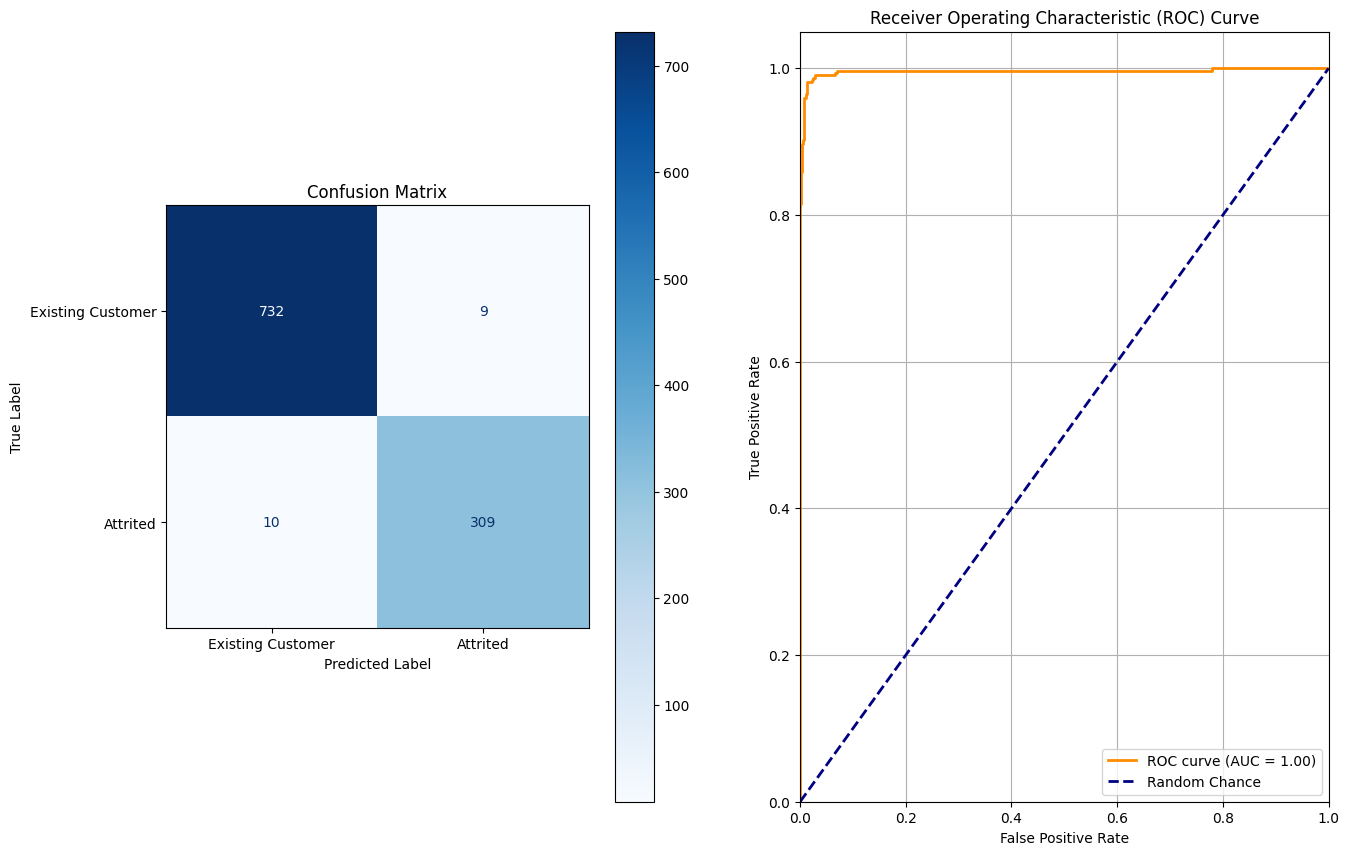

5 0.060555555555555564
Number of Attrited Predictions: 277
Number of Existing Customer Predictions: 755
Percent Attrited Predictions: 26.841085271317827
Percent Existing Customer Predictions: 73.15891472868216

Accuracy: 98.35%

Recall: 0.9710144927536232

Precision: 0.9675090252707581

F1-Score: 0.97


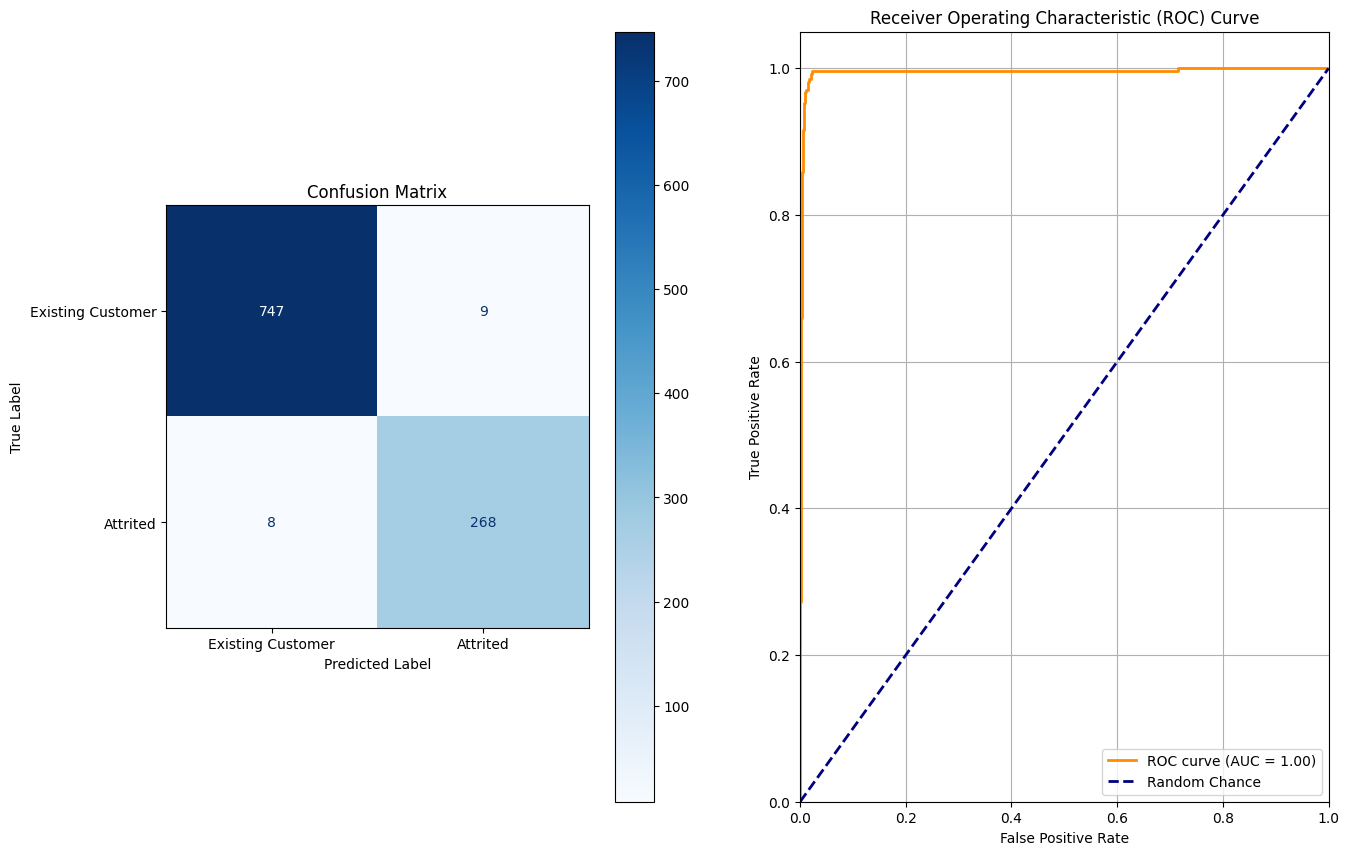

6 0.04611111111111112
Number of Attrited Predictions: 320
Number of Existing Customer Predictions: 723
Percent Attrited Predictions: 30.68072866730585
Percent Existing Customer Predictions: 69.31927133269416

Accuracy: 98.18%

Recall: 0.9717868338557993

Precision: 0.96875

F1-Score: 0.97


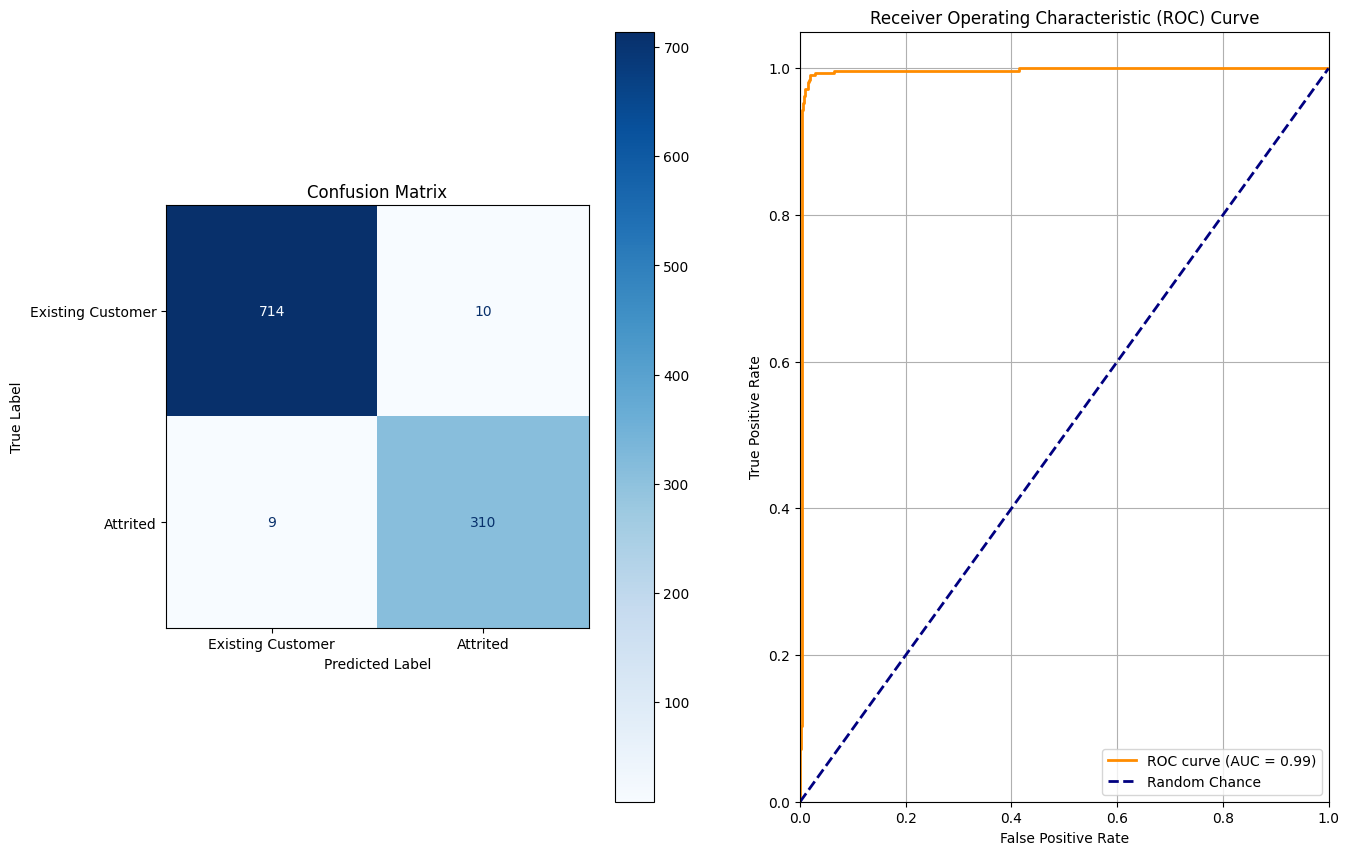

6 0.060555555555555564
Number of Attrited Predictions: 306
Number of Existing Customer Predictions: 716
Percent Attrited Predictions: 29.9412915851272
Percent Existing Customer Predictions: 70.0587084148728

Accuracy: 97.75%

Recall: 0.966996699669967

Precision: 0.9575163398692811

F1-Score: 0.96


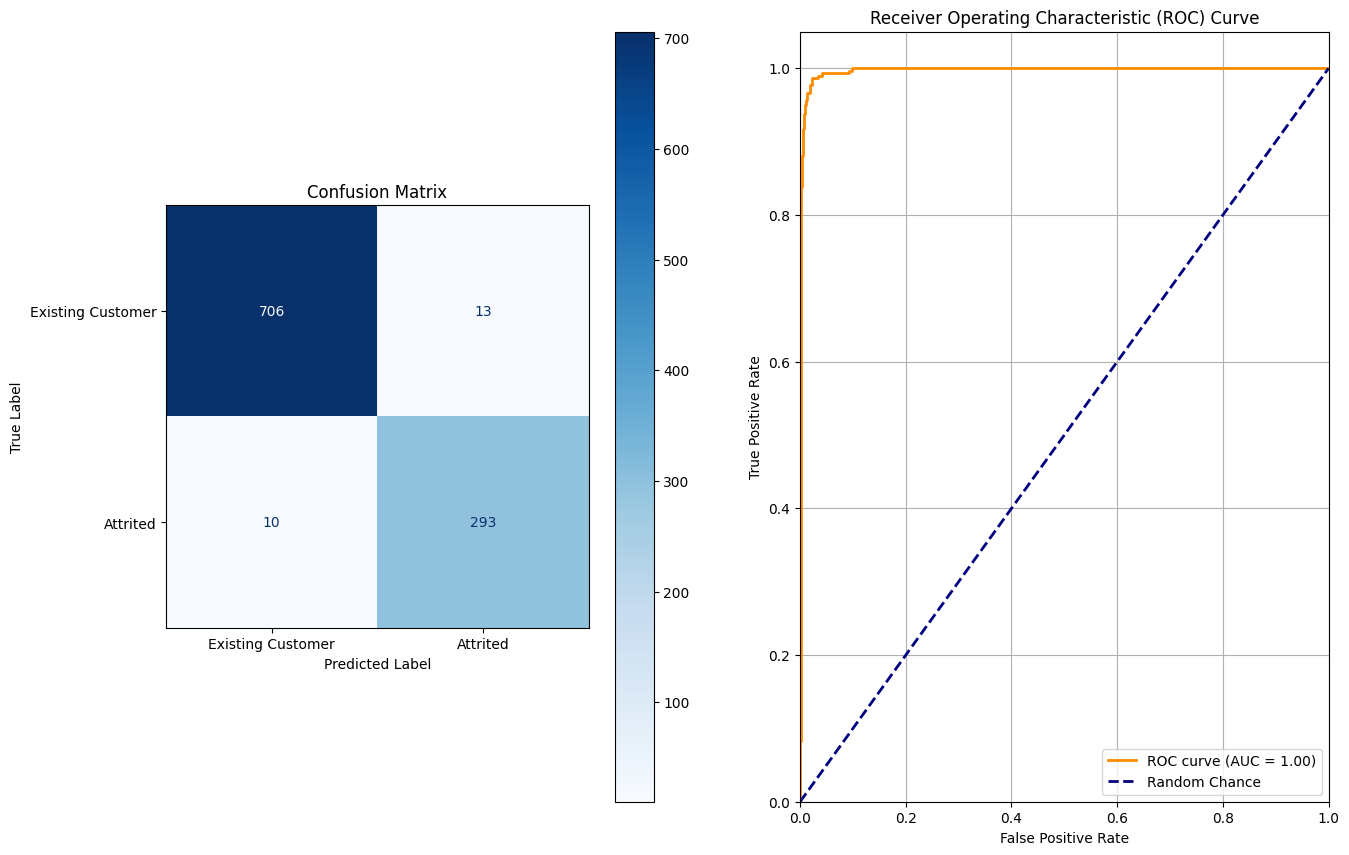

7 0.06777777777777778
Number of Attrited Predictions: 322
Number of Existing Customer Predictions: 682
Percent Attrited Predictions: 32.07171314741036
Percent Existing Customer Predictions: 67.92828685258964

Accuracy: 97.91%

Recall: 0.963076923076923

Precision: 0.9720496894409938

F1-Score: 0.97


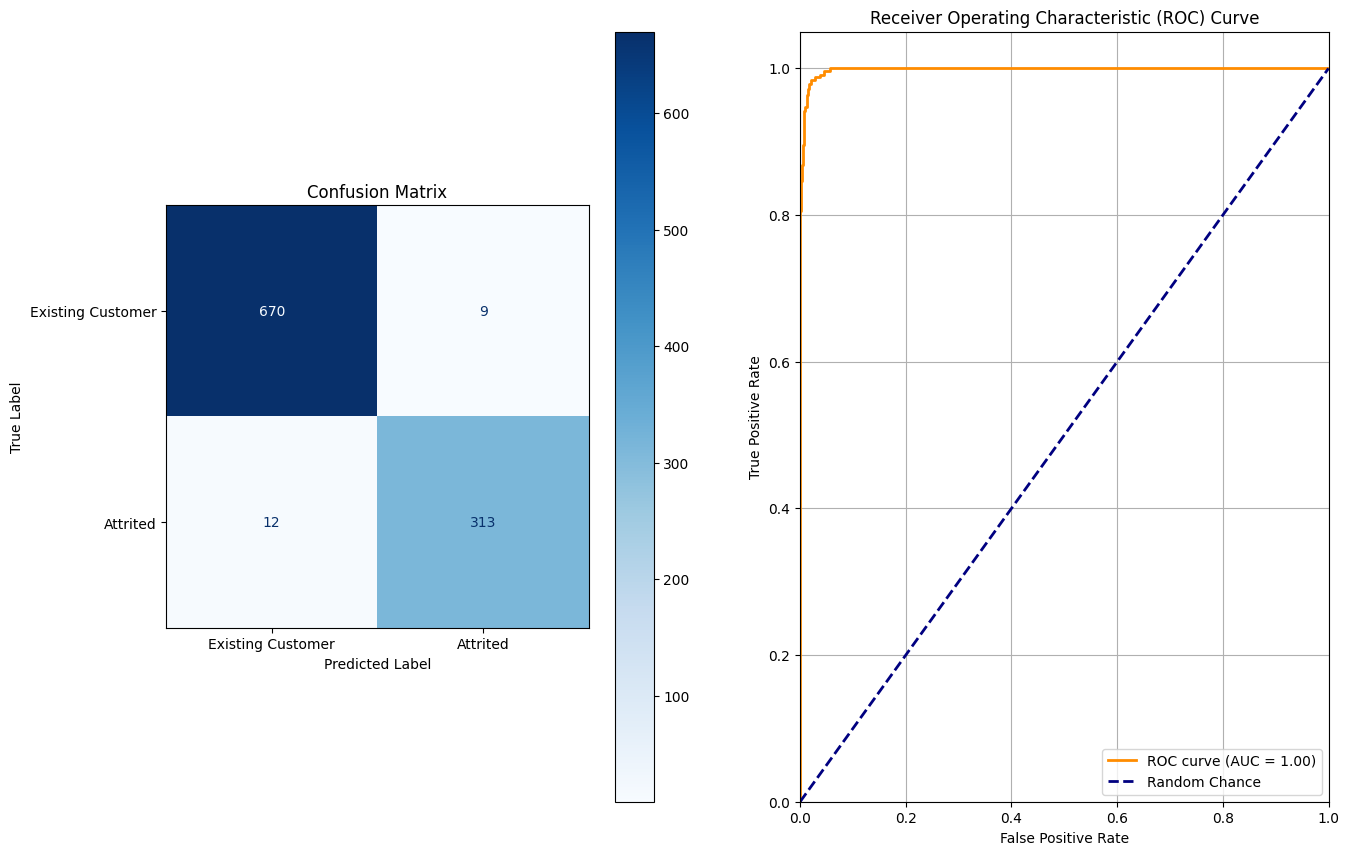

5 0.04611111111111112
Number of Attrited Predictions: 318
Number of Existing Customer Predictions: 667
Percent Attrited Predictions: 32.28426395939086
Percent Existing Customer Predictions: 67.71573604060914

Accuracy: 98.88%

Recall: 0.9811912225705329

Precision: 0.9842767295597484

F1-Score: 0.98


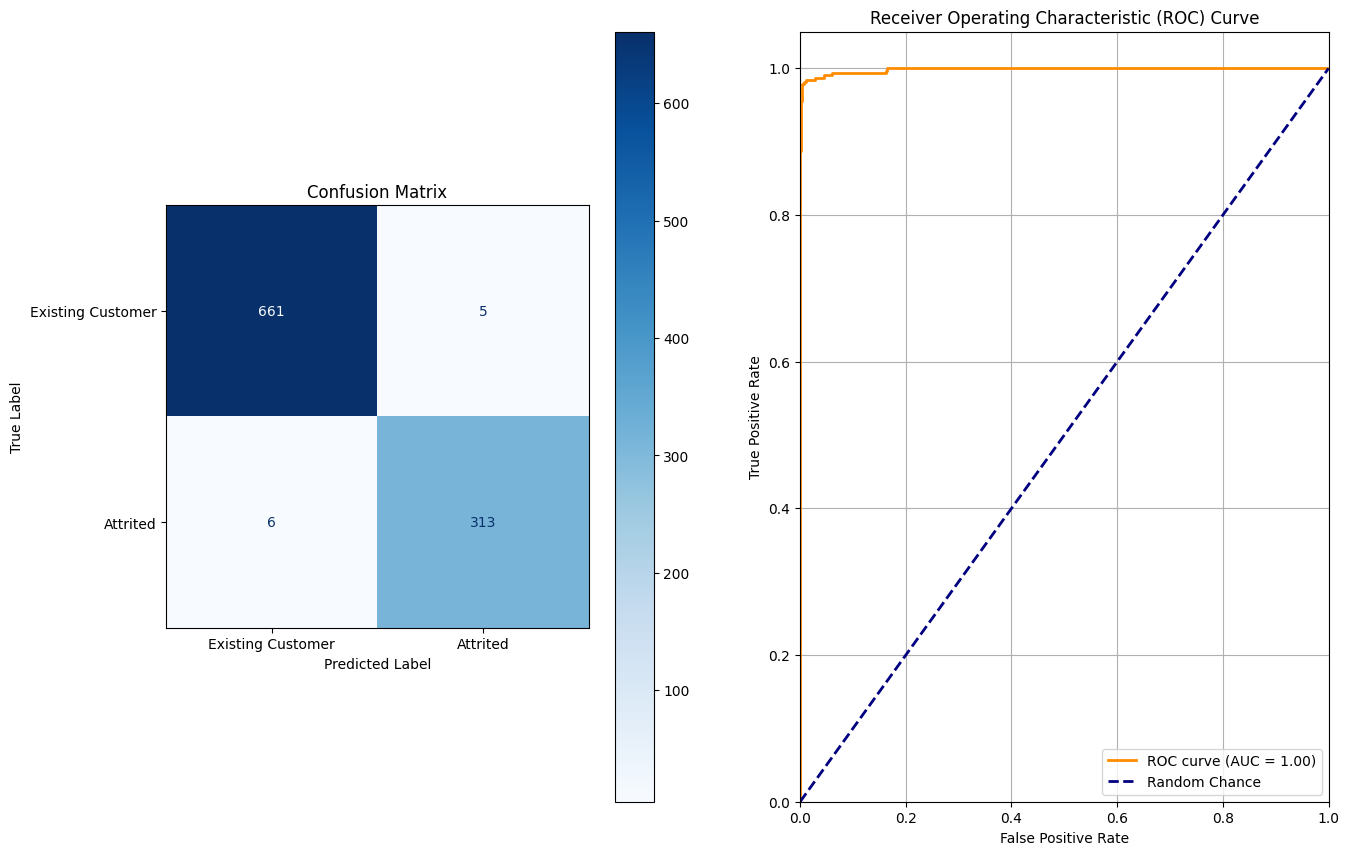

5 0.04611111111111112
Number of Attrited Predictions: 308
Number of Existing Customer Predictions: 658
Percent Attrited Predictions: 31.88405797101449
Percent Existing Customer Predictions: 68.11594202898551

Accuracy: 97.93%

Recall: 0.9705882352941176

Precision: 0.9642857142857143

F1-Score: 0.97


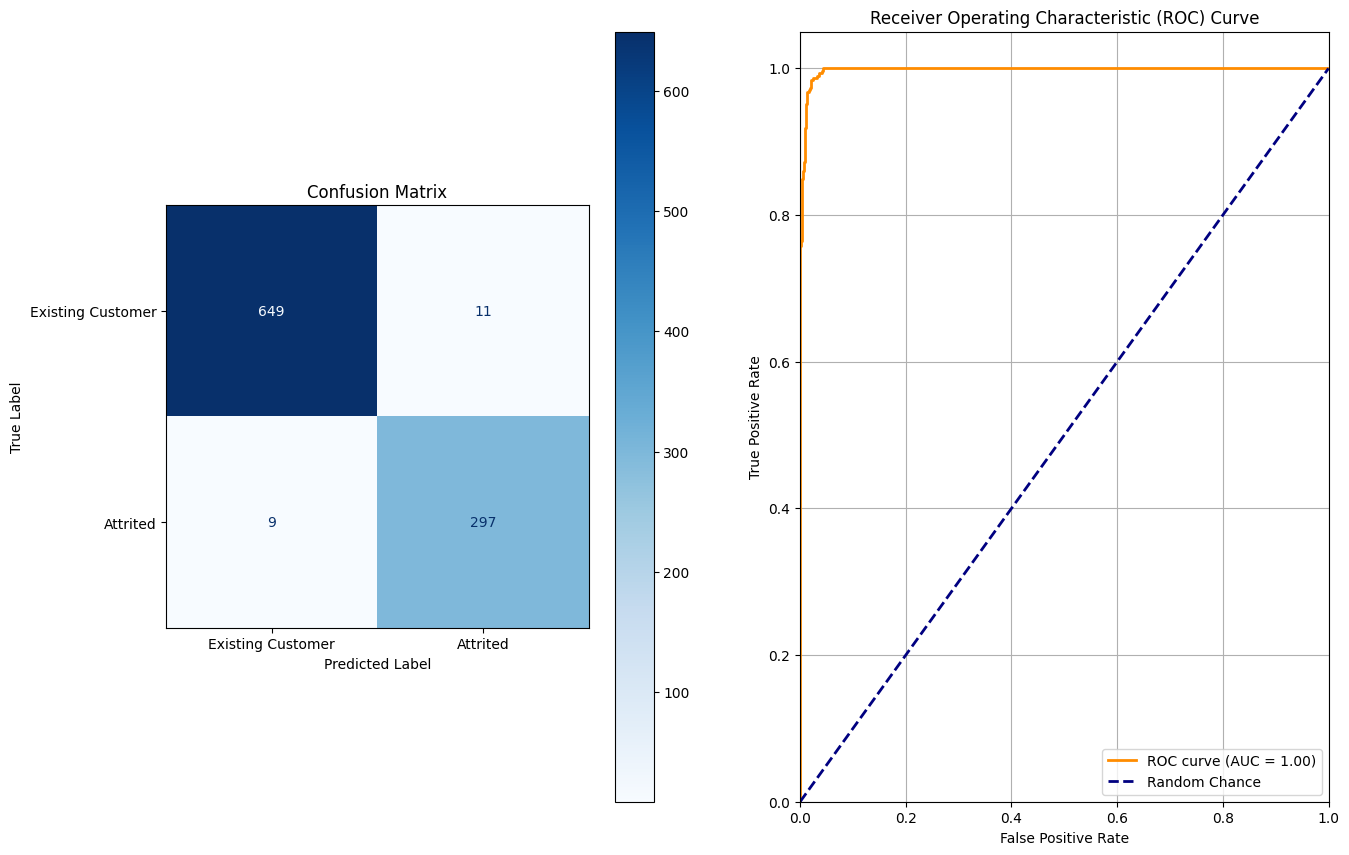

5 0.06777777777777778
Number of Attrited Predictions: 333
Number of Existing Customer Predictions: 630
Percent Attrited Predictions: 34.57943925233645
Percent Existing Customer Predictions: 65.42056074766354

Accuracy: 98.03%

Recall: 0.9700598802395209

Precision: 0.972972972972973

F1-Score: 0.97


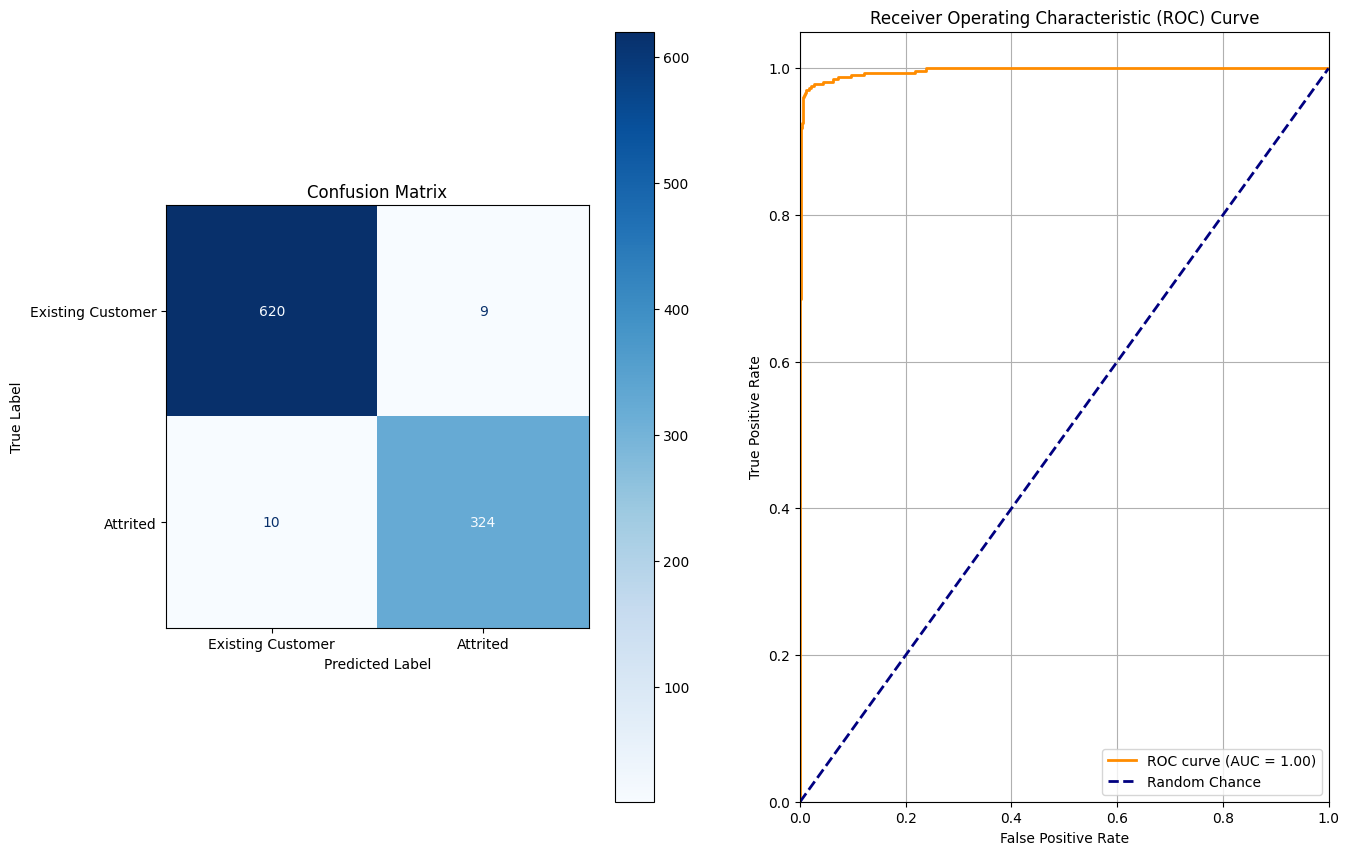

4 0.075
Number of Attrited Predictions: 342
Number of Existing Customer Predictions: 605
Percent Attrited Predictions: 36.114044350580784
Percent Existing Customer Predictions: 63.88595564941922

Accuracy: 97.47%

Recall: 0.9622093023255814

Precision: 0.9678362573099415

F1-Score: 0.97


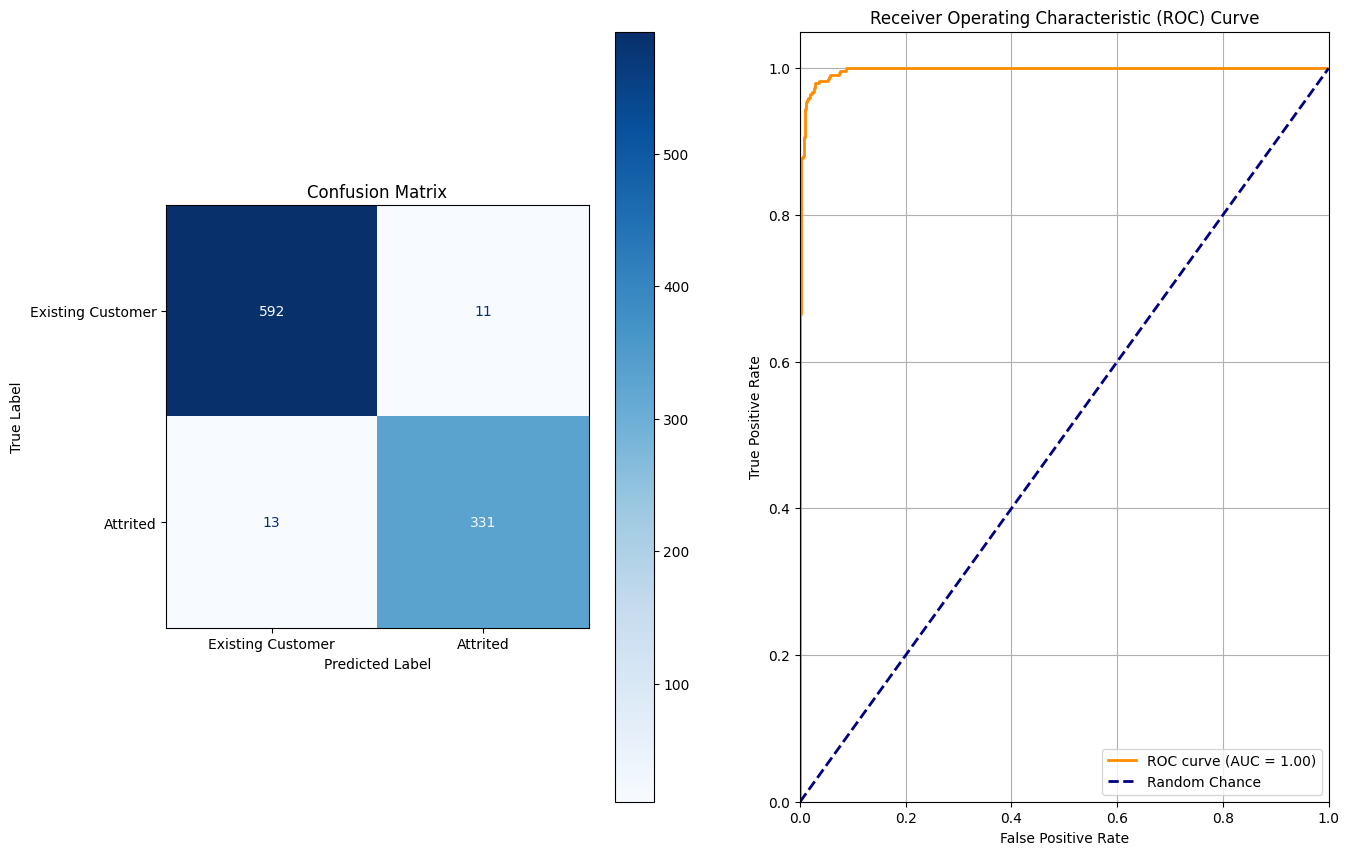

5 0.075
Number of Attrited Predictions: 319
Number of Existing Customer Predictions: 616
Percent Attrited Predictions: 34.11764705882353
Percent Existing Customer Predictions: 65.88235294117646

Accuracy: 97.65%

Recall: 0.9569230769230769

Precision: 0.9749216300940439

F1-Score: 0.97


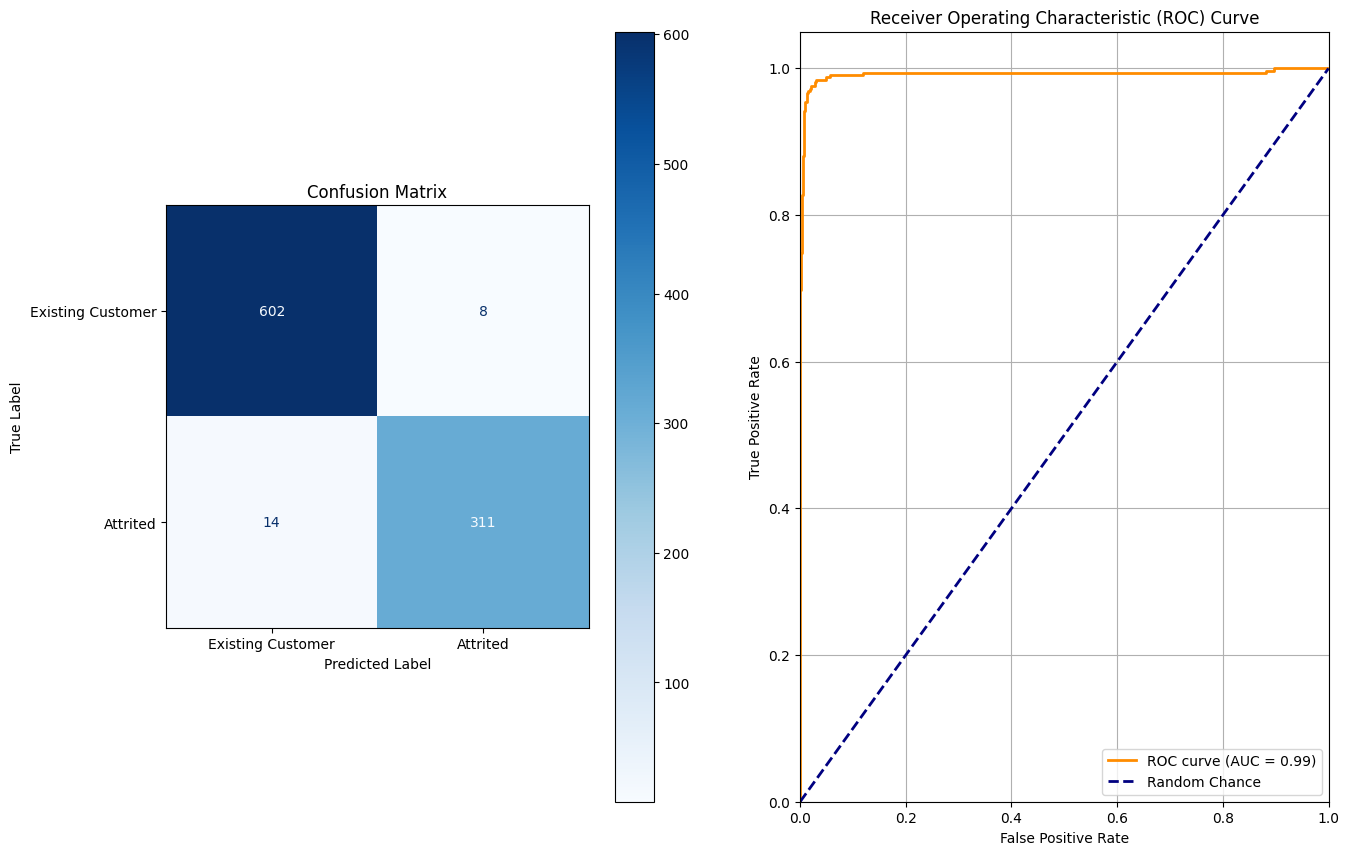

4 0.060555555555555564
Number of Attrited Predictions: 316
Number of Existing Customer Predictions: 598
Percent Attrited Predictions: 34.57330415754923
Percent Existing Customer Predictions: 65.42669584245077

Accuracy: 97.37%

Recall: 0.9478527607361963

Precision: 0.9778481012658228

F1-Score: 0.96


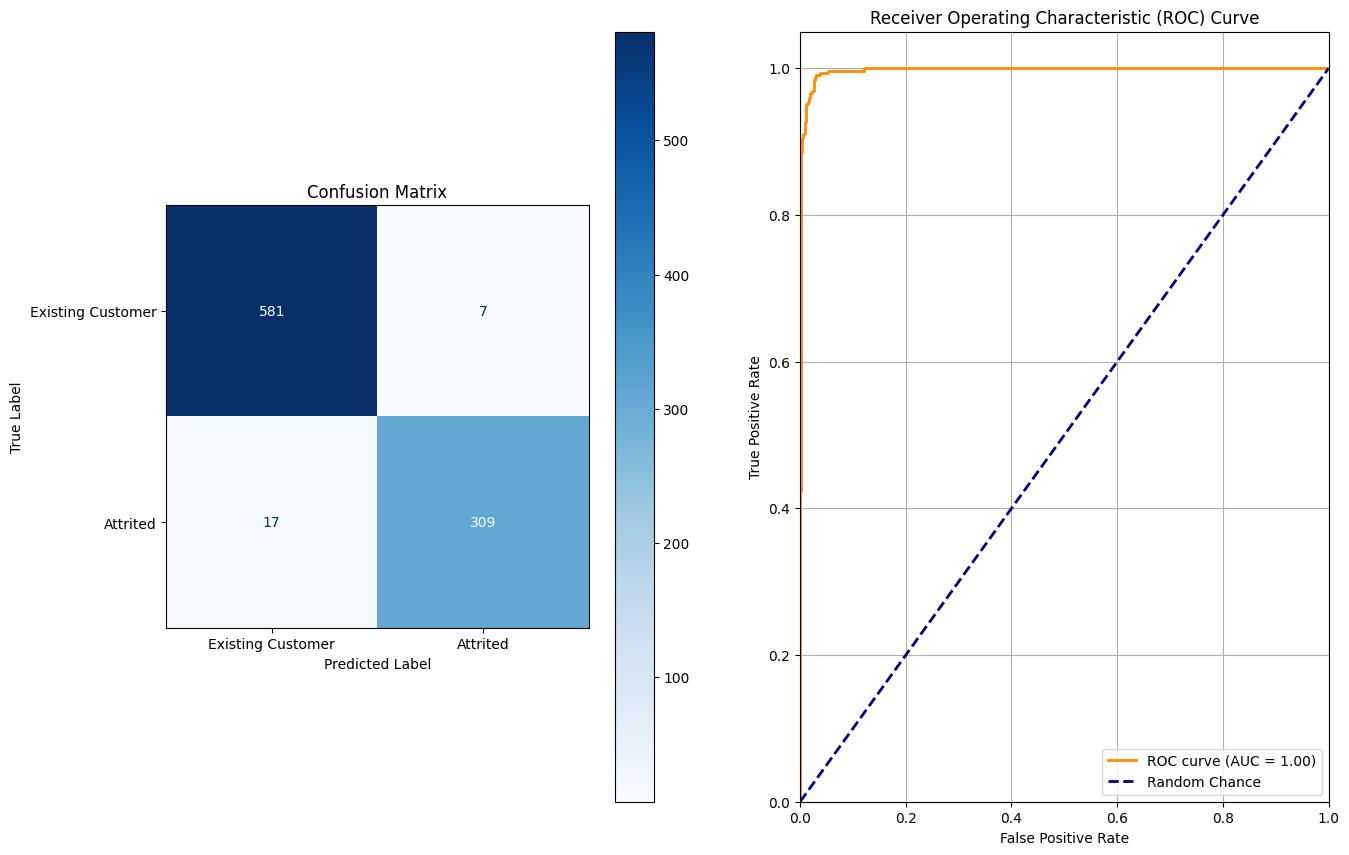

5 0.060555555555555564
Number of Attrited Predictions: 316
Number of Existing Customer Predictions: 583
Percent Attrited Predictions: 35.15016685205784
Percent Existing Customer Predictions: 64.84983314794216

Accuracy: 98.55%

Recall: 0.9840255591054313

Precision: 0.9746835443037974

F1-Score: 0.98


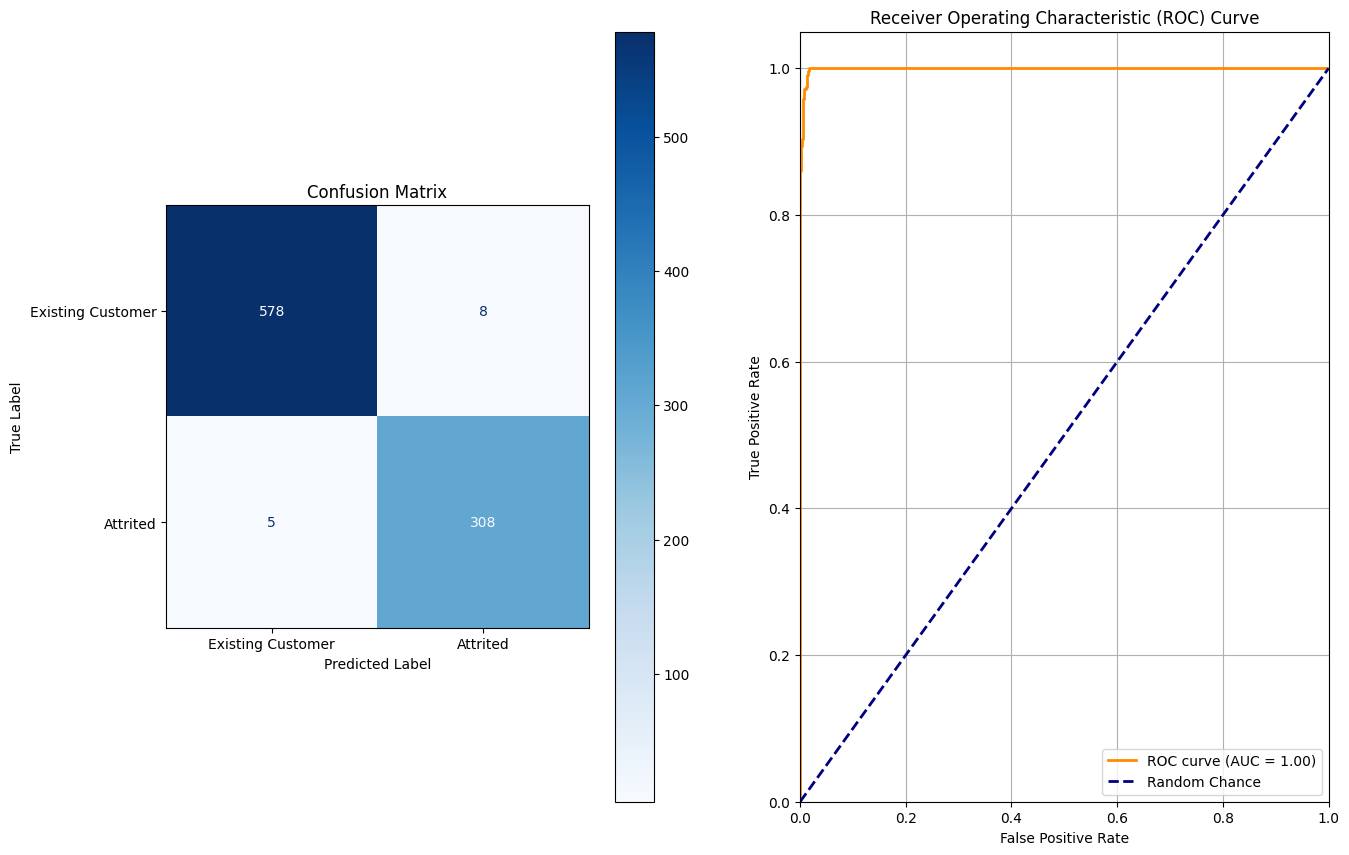

6 0.03888888888888889
Number of Attrited Predictions: 337
Number of Existing Customer Predictions: 554
Percent Attrited Predictions: 37.82267115600449
Percent Existing Customer Predictions: 62.177328843995504

Accuracy: 98.09%

Recall: 0.9761904761904762

Precision: 0.973293768545994

F1-Score: 0.97


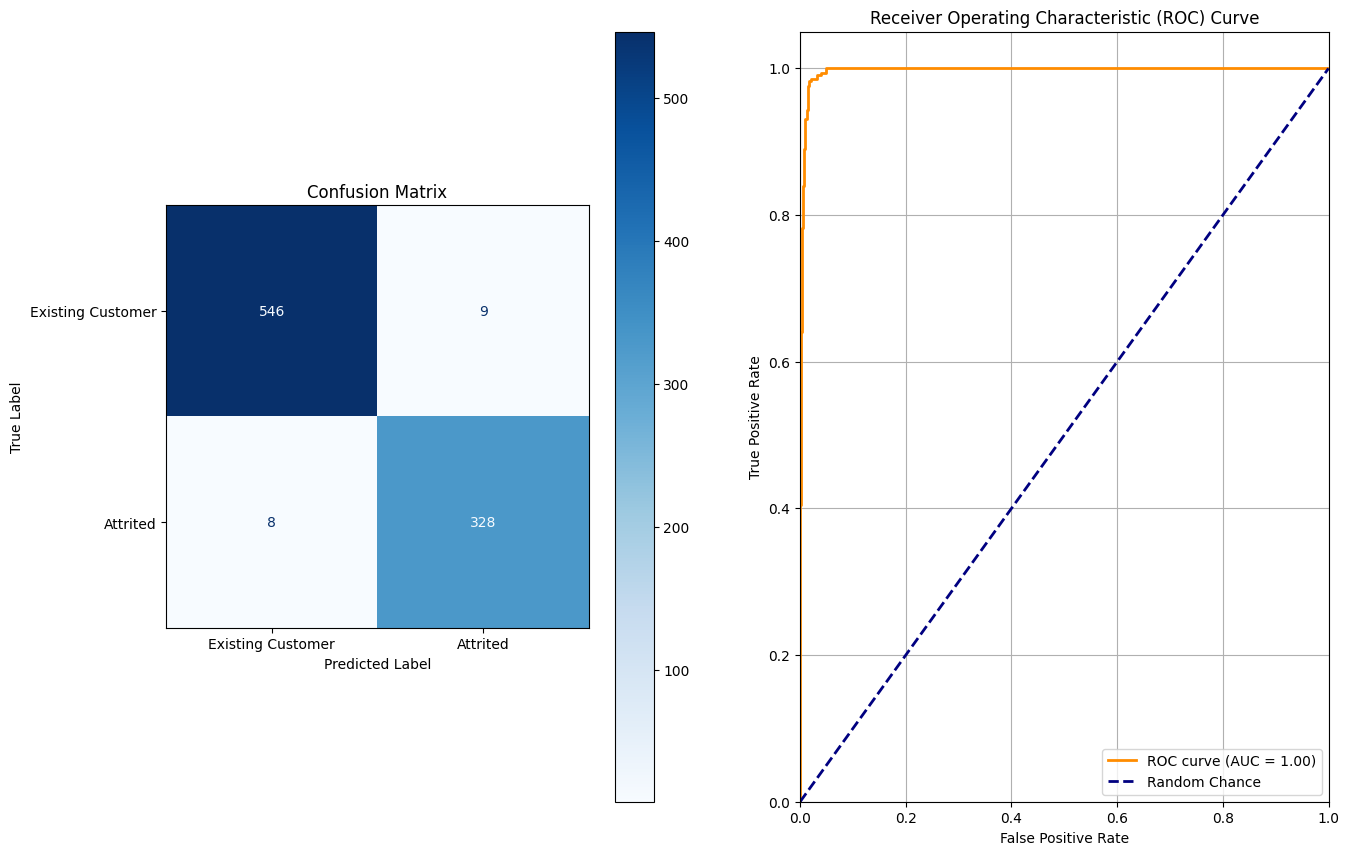

5 0.060555555555555564
Number of Attrited Predictions: 322
Number of Existing Customer Predictions: 548
Percent Attrited Predictions: 37.01149425287356
Percent Existing Customer Predictions: 62.98850574712643

Accuracy: 99.08%

Recall: 0.9845679012345679

Precision: 0.9906832298136646

F1-Score: 0.99


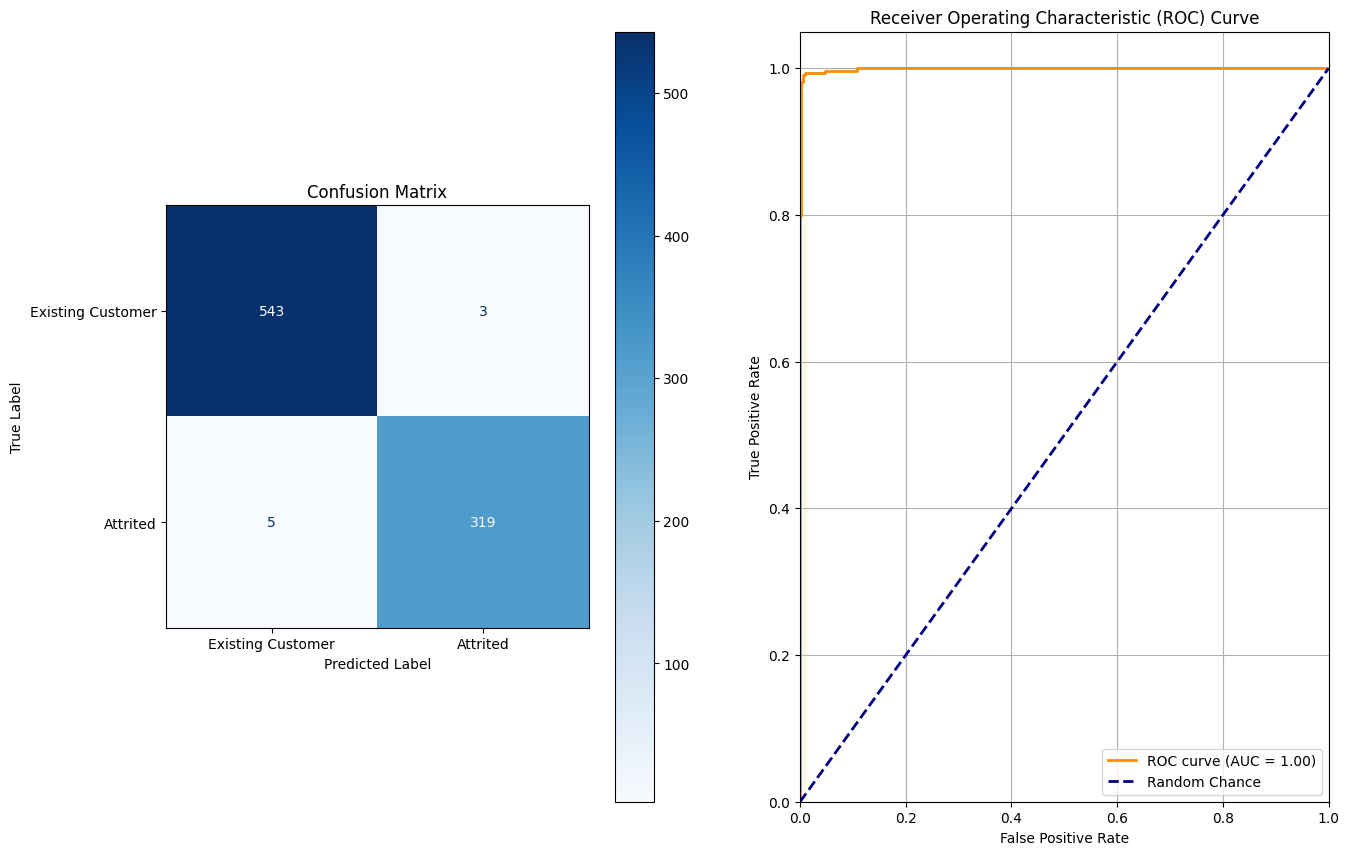

6 0.06777777777777778
Number of Attrited Predictions: 313
Number of Existing Customer Predictions: 537
Percent Attrited Predictions: 36.8235294117647
Percent Existing Customer Predictions: 63.17647058823529

Accuracy: 98.24%

Recall: 0.9627329192546584

Precision: 0.9904153354632588

F1-Score: 0.98


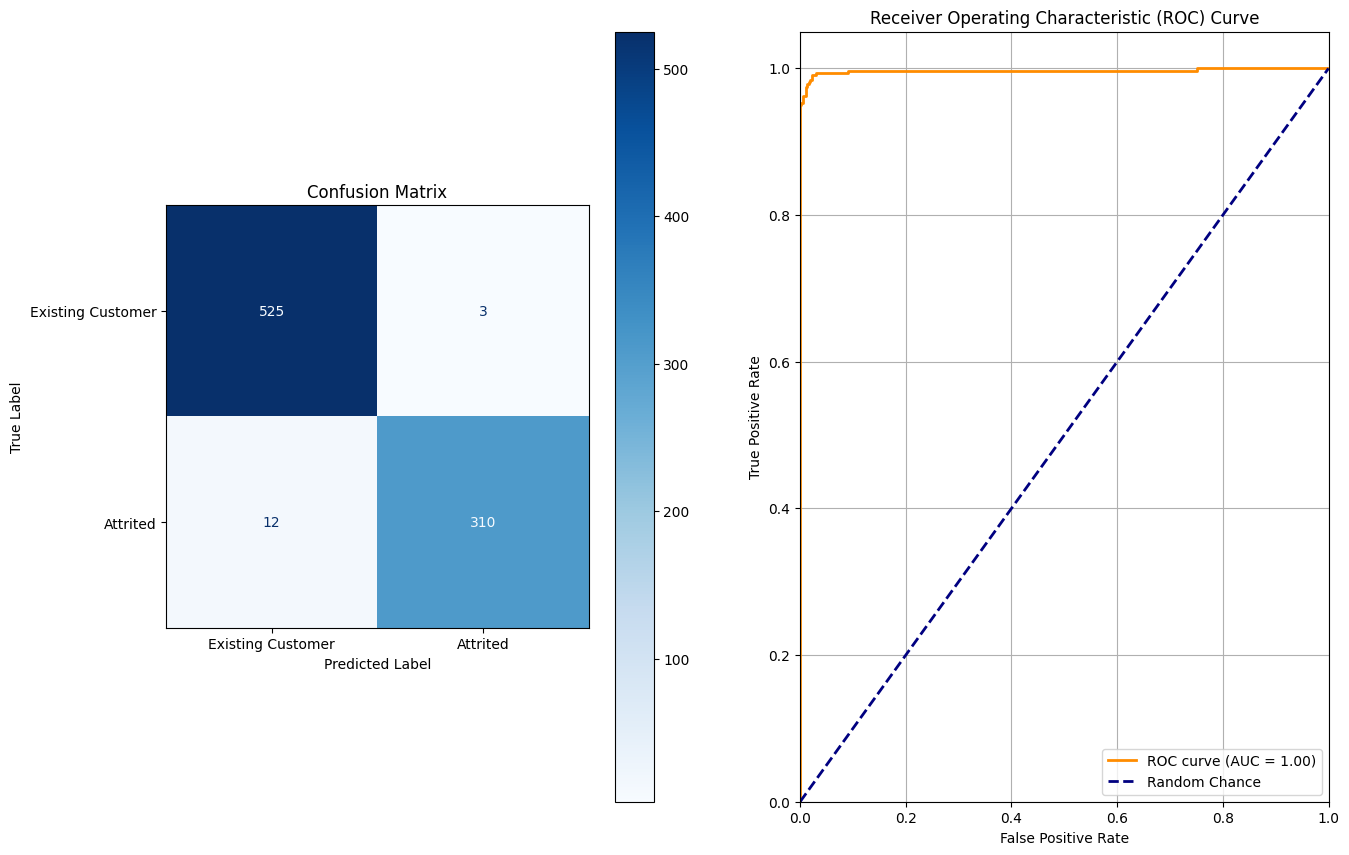

5 0.03888888888888889
Number of Attrited Predictions: 302
Number of Existing Customer Predictions: 522
Percent Attrited Predictions: 36.650485436893206
Percent Existing Customer Predictions: 63.3495145631068

Accuracy: 98.18%

Recall: 0.9767441860465116

Precision: 0.9735099337748344

F1-Score: 0.98


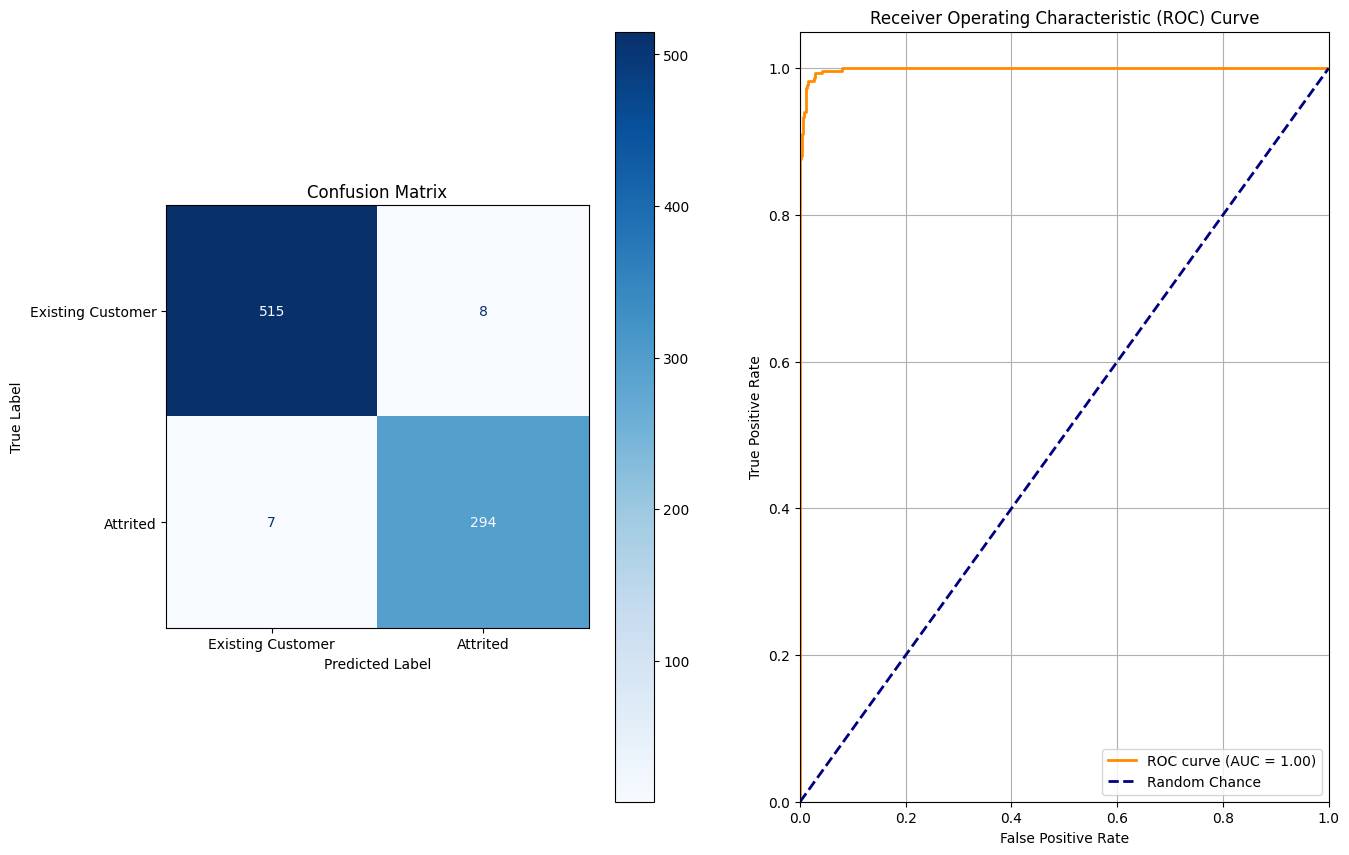

4 0.075
Number of Attrited Predictions: 300
Number of Existing Customer Predictions: 506
Percent Attrited Predictions: 37.220843672456574
Percent Existing Customer Predictions: 62.779156327543426

Accuracy: 98.01%

Recall: 0.9733333333333334

Precision: 0.9733333333333334

F1-Score: 0.97


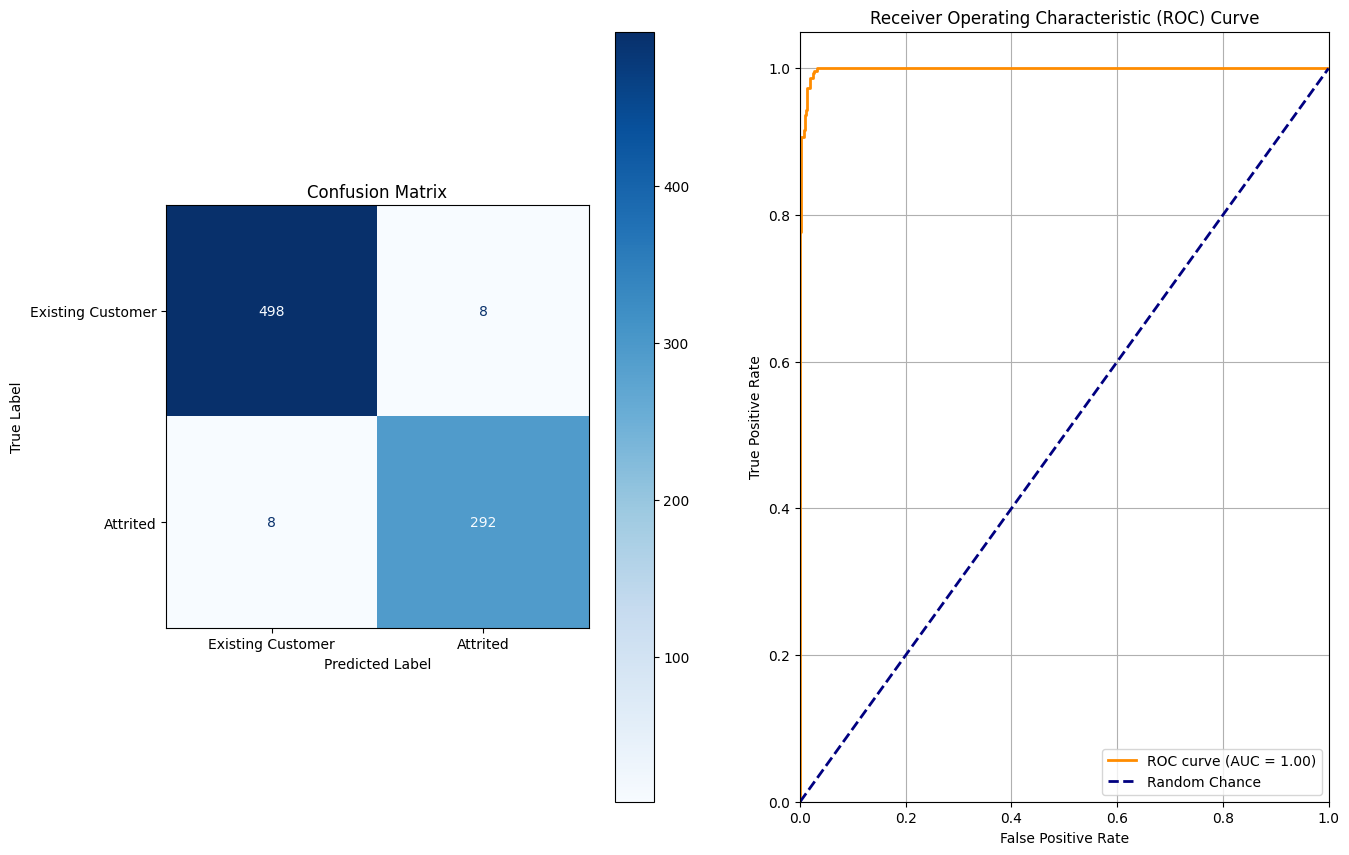

5 0.04611111111111112
Number of Attrited Predictions: 328
Number of Existing Customer Predictions: 457
Percent Attrited Predictions: 41.783439490445865
Percent Existing Customer Predictions: 58.216560509554135

Accuracy: 97.45%

Recall: 0.9723926380368099

Precision: 0.9664634146341463

F1-Score: 0.97


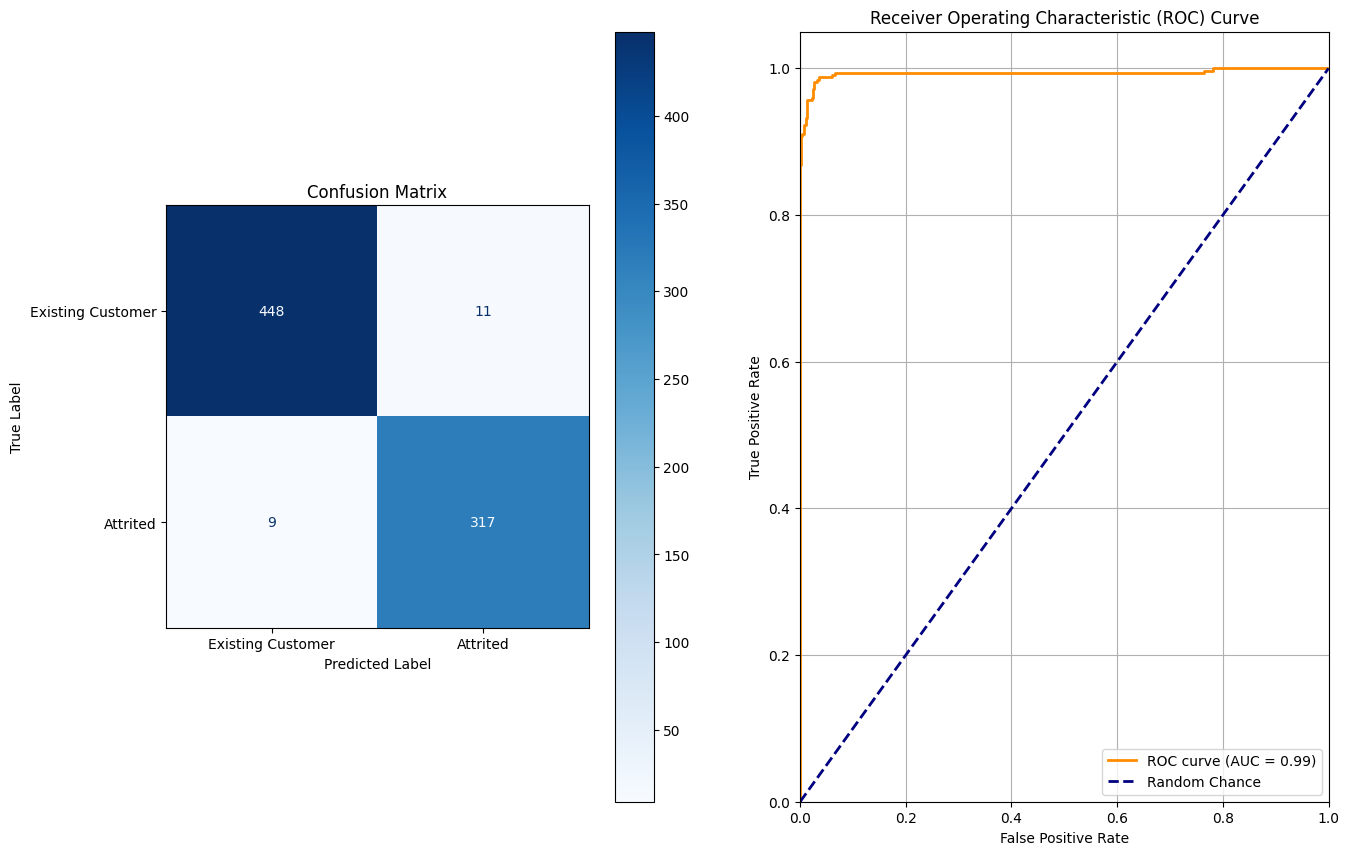

5 0.06777777777777778
Number of Attrited Predictions: 316
Number of Existing Customer Predictions: 456
Percent Attrited Predictions: 40.932642487046635
Percent Existing Customer Predictions: 59.067357512953365

Accuracy: 98.45%

Recall: 0.9871794871794872

Precision: 0.9746835443037974

F1-Score: 0.98


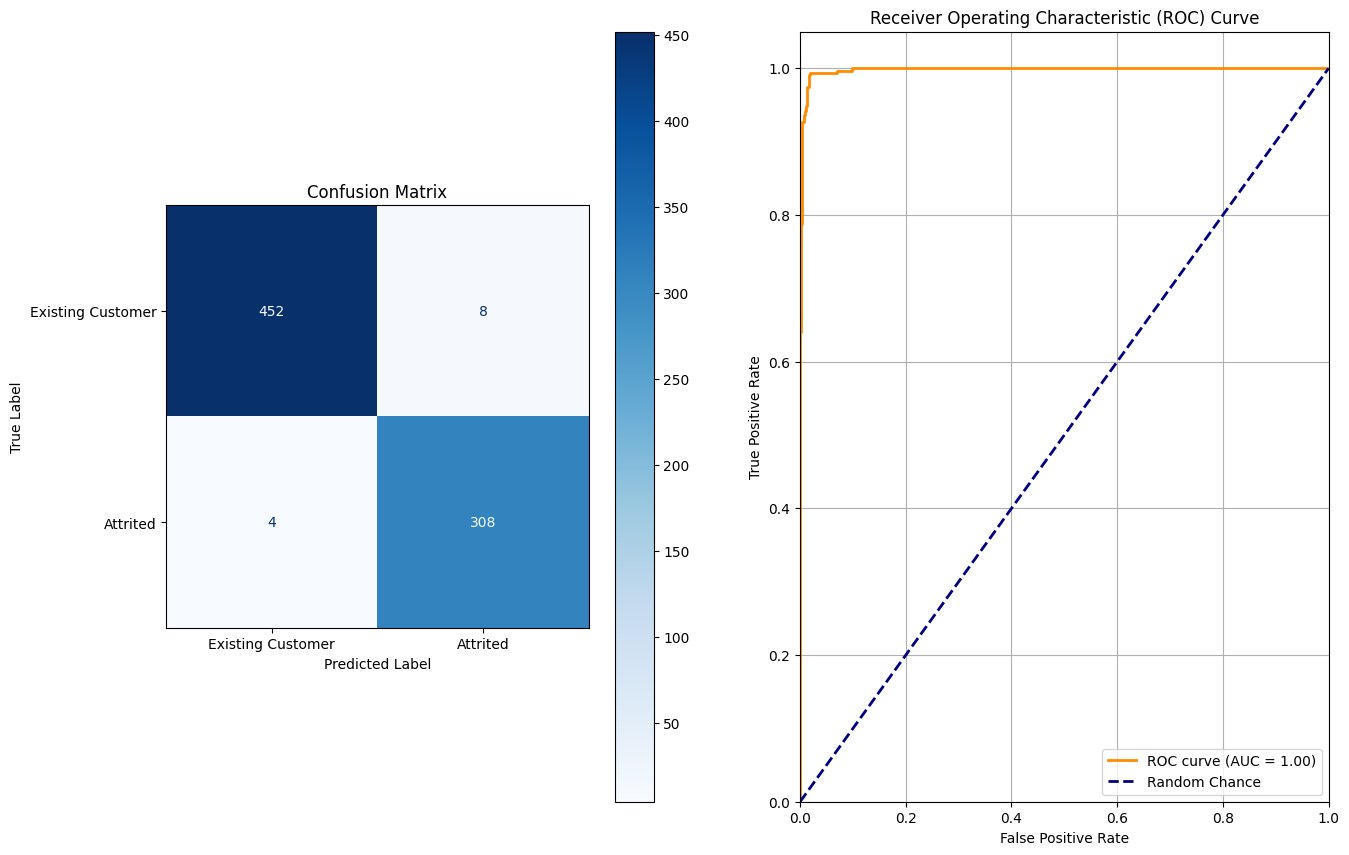

7 0.03888888888888889
Number of Attrited Predictions: 331
Number of Existing Customer Predictions: 421
Percent Attrited Predictions: 44.015957446808514
Percent Existing Customer Predictions: 55.98404255319149

Accuracy: 98.01%

Recall: 0.9759036144578314

Precision: 0.9788519637462235

F1-Score: 0.98


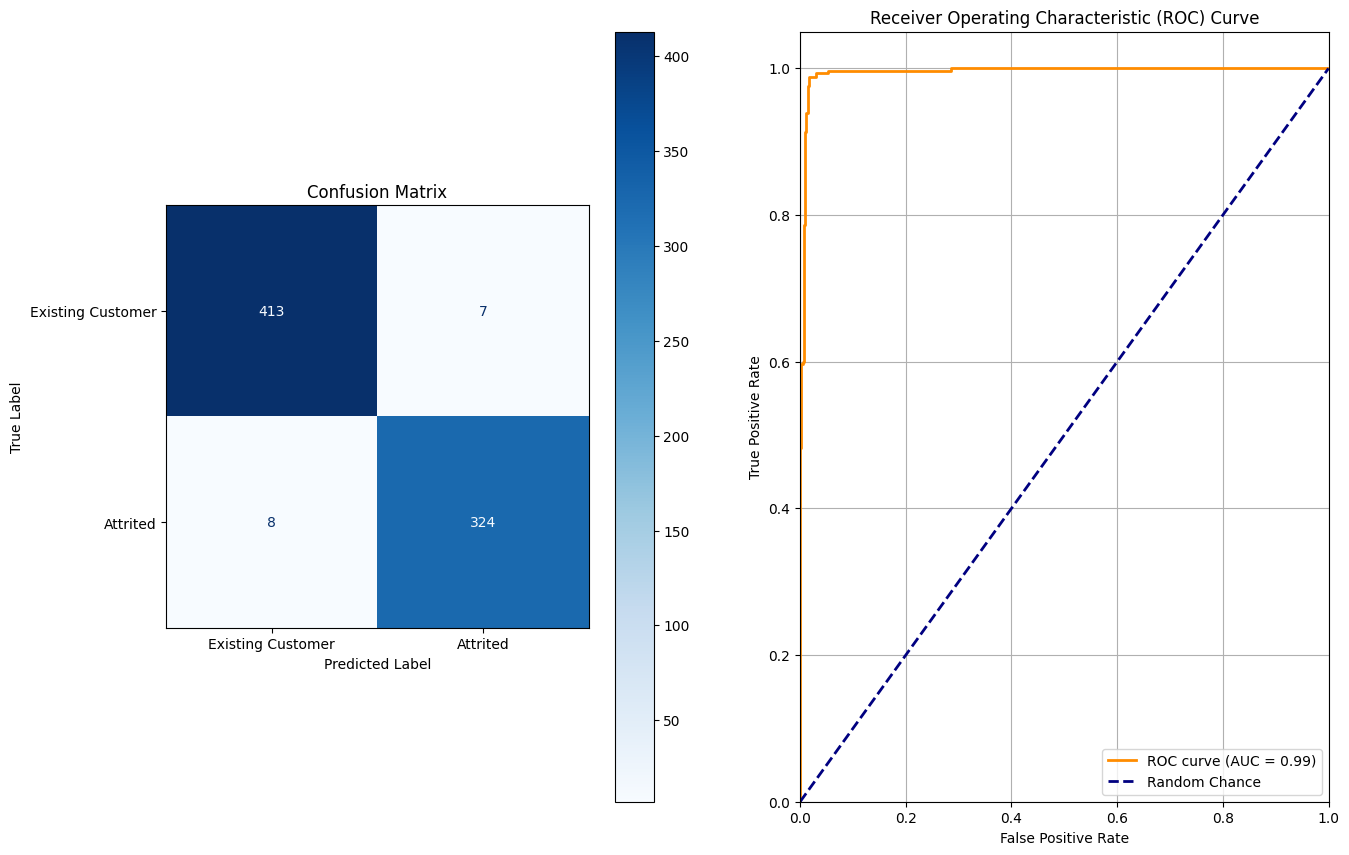

5 0.04611111111111112
Number of Attrited Predictions: 317
Number of Existing Customer Predictions: 421
Percent Attrited Predictions: 42.953929539295395
Percent Existing Customer Predictions: 57.04607046070461

Accuracy: 97.02%

Recall: 0.9652996845425867

Precision: 0.9652996845425867

F1-Score: 0.97


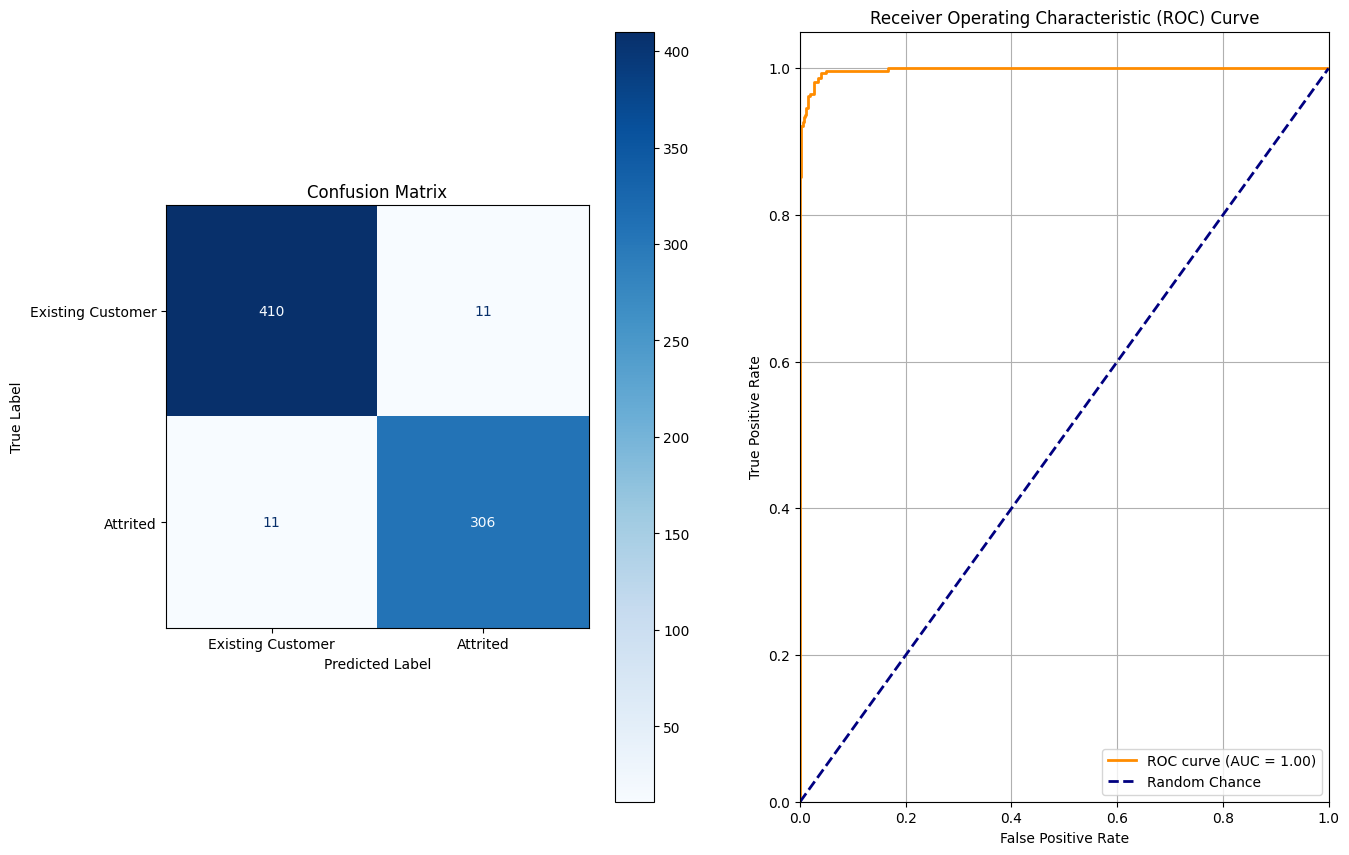

5 0.060555555555555564
Number of Attrited Predictions: 321
Number of Existing Customer Predictions: 407
Percent Attrited Predictions: 44.09340659340659
Percent Existing Customer Predictions: 55.90659340659341

Accuracy: 98.21%

Recall: 0.9782608695652174

Precision: 0.9813084112149533

F1-Score: 0.98


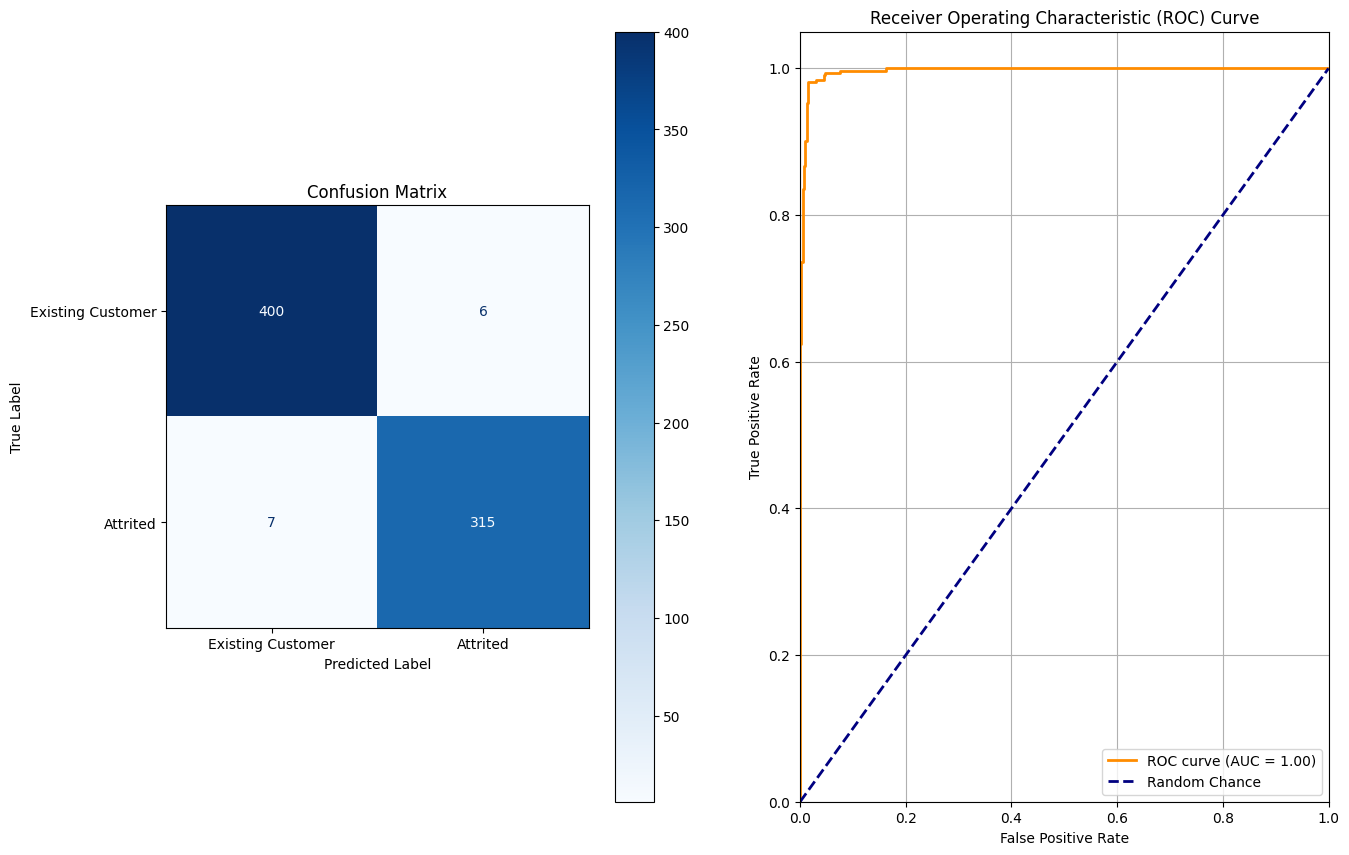

In [289]:
for j in range(50, 80, 5):
    for i in range(5,30,5):

        gbr_data = remove_outliers(data, i)

        gbr_data = reduce_data(gbr_data, j)

        gbr_data = gbr_data.drop(['index', 'CLIENTNUM'], axis = 1)

        training_data, test_data = split_data(gbr_data)

        model = MS(training_data.columns.drop('Attrition_Flag'), intercept=False)
        D = model.fit_transform(training_data) 
        feature_names = list(D.columns)
        X_train = np.asarray(D)
        Y_train = training_data['Attrition_Flag']

        model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
        D = model.fit_transform(test_data) 
        feature_names = list(D.columns)
        X_test = np.asarray(D)
        Y_test = test_data['Attrition_Flag']

        min_depth = 4
        max_depth = 9
        n_estimators = 250

        min_test_errors, optimal_λs = tune_GBR(min_depth, max_depth, n_estimators, np.linspace(0.01, 0.075, 10), X_train, Y_train, X_test, Y_test)

        min_test_errors = np.array(min_test_errors)
        optimal_λs = np.array(optimal_λs).flatten()

        depths = list(range(min_depth,max_depth))

        max_depth = np.where(min_test_errors==np.min(min_test_errors))
        optimal_λ = optimal_λs[np.where(min_test_errors==np.min(min_test_errors))][0]

        tuned_GBR = GBR(n_estimators=n_estimators,
                    learning_rate=optimal_λ,
                    max_depth=depths[max_depth[0][0]],
                    random_state=0)


        tuned_GBR.fit(X_train, Y_train)

        labels = ['Existing Customer', 'Attrited']

        model = ModelEvaluator("Gradient Boosted Regression", tuned_GBR)

        model_results = {model.name:[]}

        model.eval_model(X_test, Y_test, labels)

        model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

        summary_table[f'{i}%_Outlier_Reduction_{j}%_Class_Reduction'] = model_results

### Output summary table to csv in the following format

Feature Configuration, Model Type, Accuracy, Recall, Precision, F1-Score 

In [356]:
lines = ['Feature Configuration, Model, Accuracy, Recall, Precision, F1-Score\n']
for key, val in summary_table.items():
    line = f"{key}, "
    for key, val in val.items():
        try:
            val[1] = f'{val[1]*100:.2f}%'
            val[2] = f'{val[2]*100:.2f}%'

            line = line + f"{key}, "

            for i, v in enumerate(val):
                if i == len(val)-1:
                    line = line + f"{v}\n"
                else:
                    line = line + f"{v}, "
            lines.append(line)
        except:

            line = line + f"{key}, "

            for i, v in enumerate(val):
                if i == len(val)-1:
                    line = line + f"{v}\n"
                else:
                    line = line + f"{v}, "
            lines.append(line)

with open('summary.csv', 'w+') as f:
    f.writelines(lines)
    f.close()

In [296]:
model_results

{'Decision Tree Classifier': ['96.57%', '96.27%', '95.98%', '0.96']}

10%_Outlier_Reduction_70%_Class_Reduction

Depth: 5 Lambda: 0.060555555555555564

Number of Attrited Predictions: 322
Number of Existing Customer Predictions: 548
Percent Attrited Predictions: 37.01149425287356
Percent Existing Customer Predictions: 62.98850574712643

Accuracy: 99.08%

Recall: 0.9845679012345679

Precision: 0.9906832298136646

F1-Score: 0.99

In [338]:
gbr_data = remove_outliers(data, 10)

gbr_data = reduce_data(gbr_data, 70)

gbr_data = gbr_data.drop(['index', 'CLIENTNUM', 'level_0'], axis = 1)

training_data, test_data = split_data(gbr_data)

model = MS(training_data.columns.drop('Attrition_Flag'), intercept=False)
D = model.fit_transform(training_data) 
feature_names = list(D.columns)
X_train = np.asarray(D)
Y_train = training_data['Attrition_Flag']

model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
D = model.fit_transform(test_data) 
feature_names = list(D.columns)
X_test = np.asarray(D)
Y_test = test_data['Attrition_Flag']

best_gbr = GBR(n_estimators=250,
                    learning_rate=0.060555555555555564,
                    max_depth=5,
                    random_state=0)


best_gbr.fit(X_train, Y_train)

,loss,'squared_error'
,learning_rate,0.060555555555555564
,n_estimators,250
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


Number of Attrited Predictions: 323
Number of Existing Customer Predictions: 547
Percent Attrited Predictions: 37.12643678160919
Percent Existing Customer Predictions: 62.87356321839081

Accuracy: 99.20%

Recall: 0.9876543209876543

Precision: 0.9907120743034056

F1-Score: 0.99


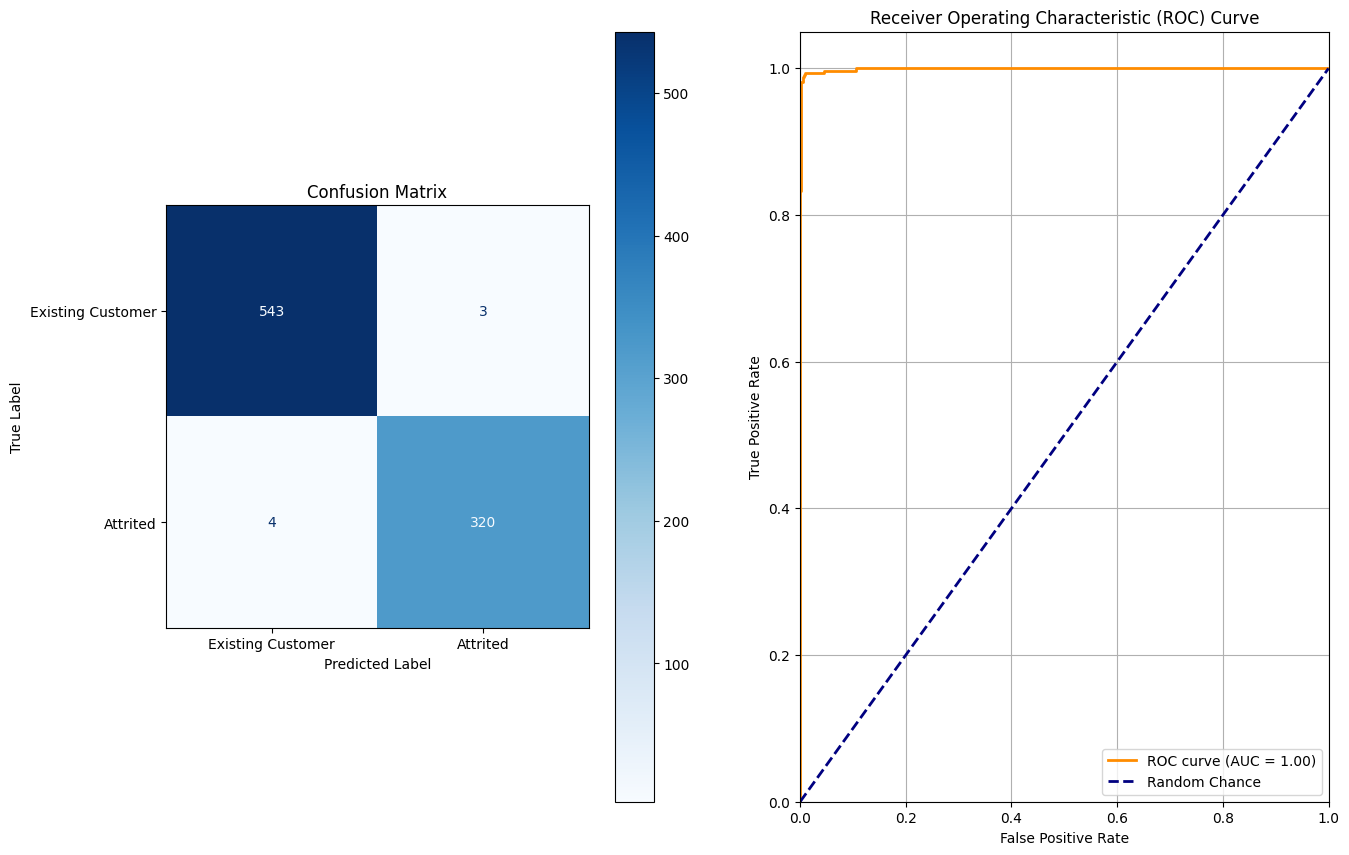

In [303]:
labels = ['Existing Customer', 'Attrited']

model = ModelEvaluator("Best Gradient Boosted Regression", best_gbr)

model_results = {model.name:[]}

model.eval_model(X_test, Y_test, labels)

model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

summary_table[f'BEST GBR: 10%_Outlier_Reduction_70%_Class_Reduction'] = model_results

Number of Attrited Predictions: 364
Number of Existing Customer Predictions: 878
Percent Attrited Predictions: 29.307568438003223
Percent Existing Customer Predictions: 70.69243156199678

Accuracy: 96.22%

Recall: 0.9907120743034056

Precision: 0.8791208791208791

F1-Score: 0.93


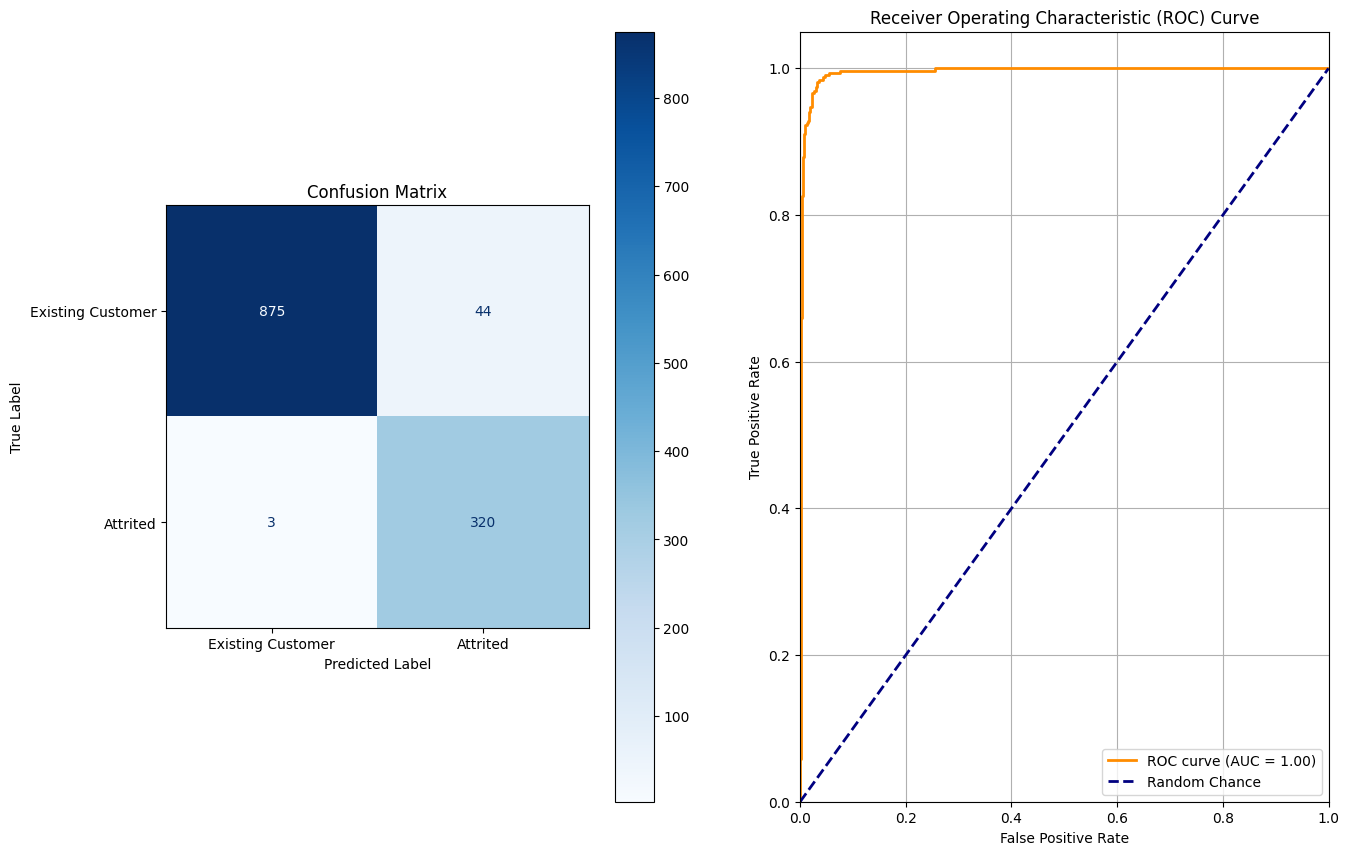

Number of Attrited Predictions: 349
Number of Existing Customer Predictions: 869
Percent Attrited Predictions: 28.653530377668307
Percent Existing Customer Predictions: 71.34646962233168

Accuracy: 97.87%

Recall: 0.9879154078549849

Precision: 0.9369627507163324

F1-Score: 0.96


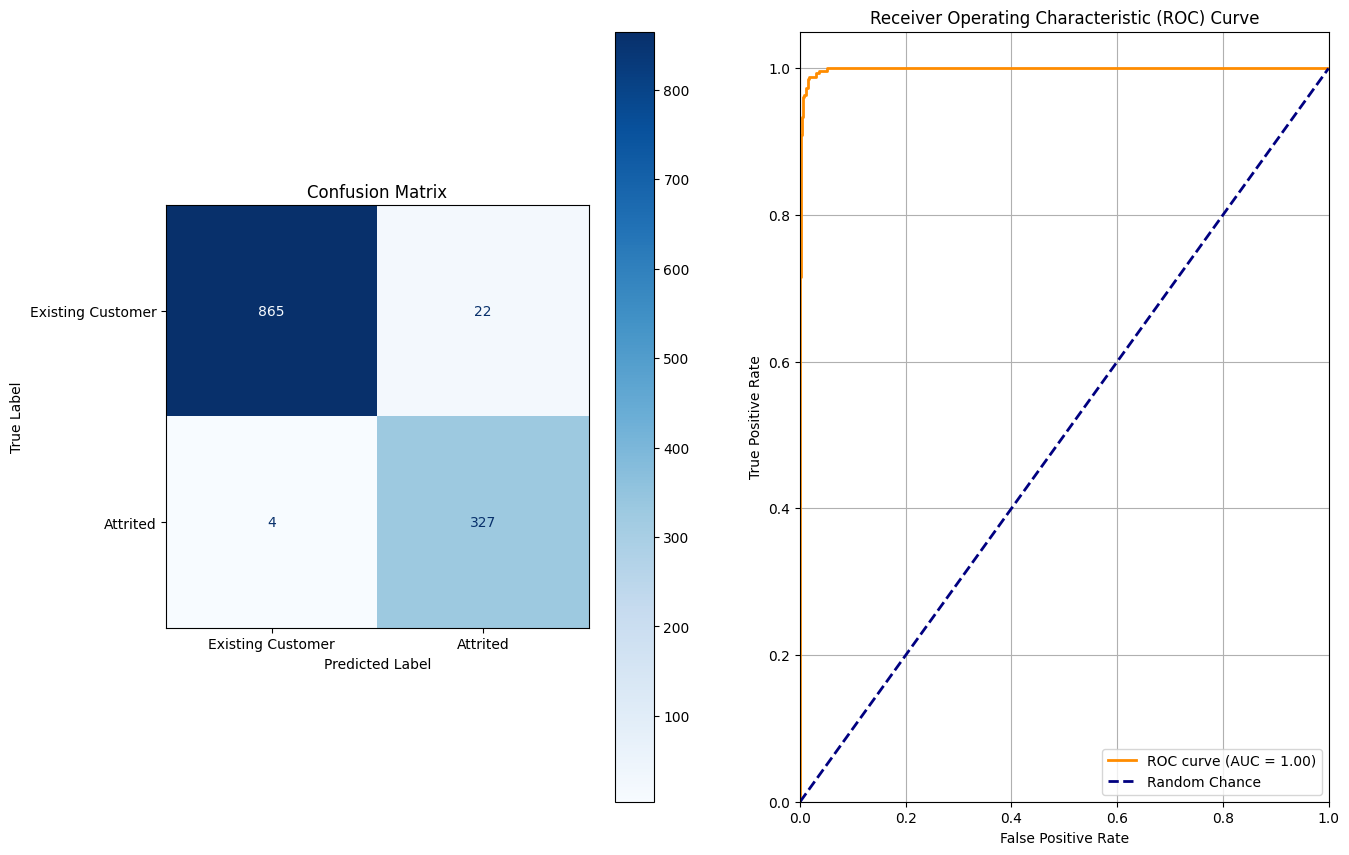

Number of Attrited Predictions: 344
Number of Existing Customer Predictions: 833
Percent Attrited Predictions: 29.226847918436704
Percent Existing Customer Predictions: 70.7731520815633

Accuracy: 97.45%

Recall: 0.990625

Precision: 0.9215116279069767

F1-Score: 0.95


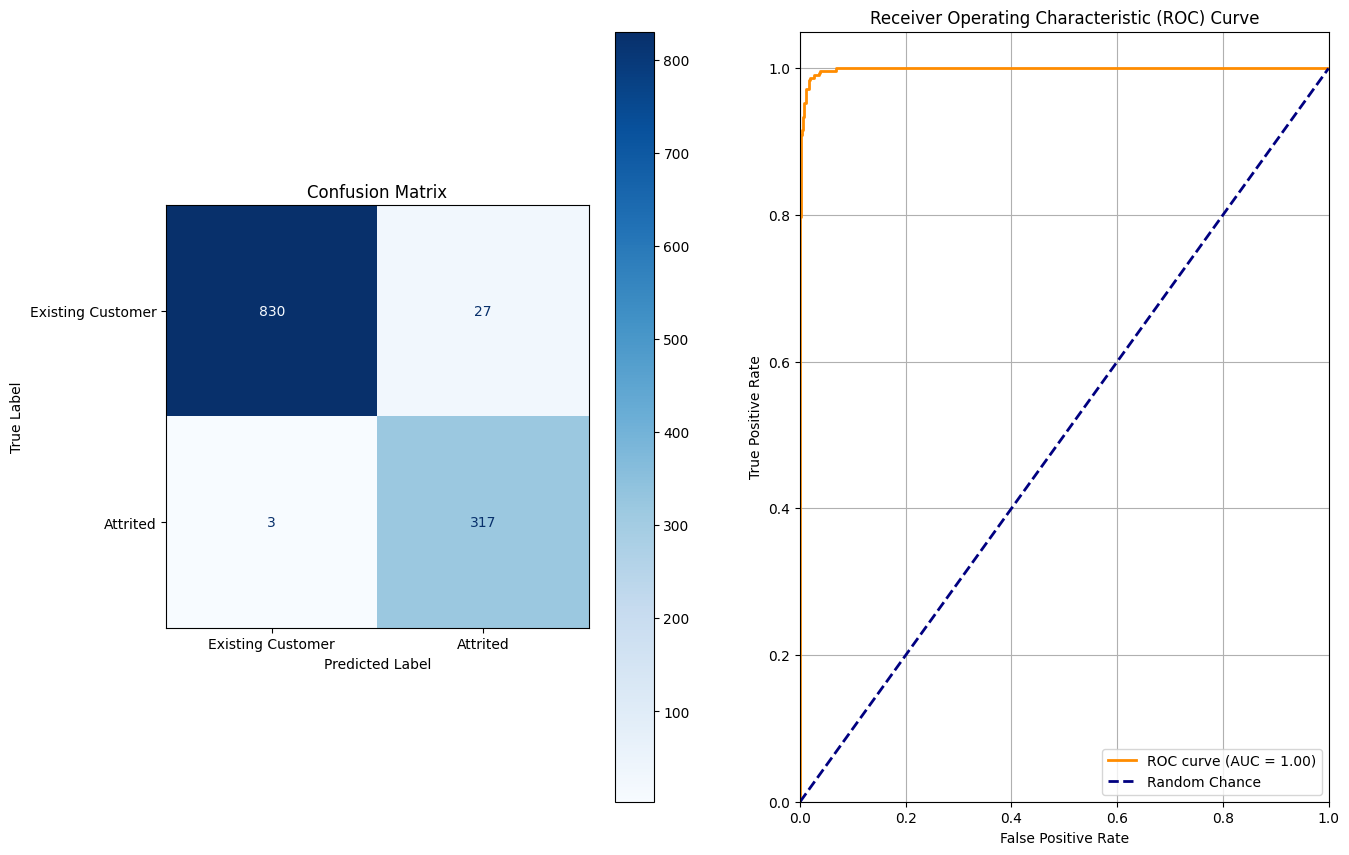

Number of Attrited Predictions: 313
Number of Existing Customer Predictions: 835
Percent Attrited Predictions: 27.264808362369337
Percent Existing Customer Predictions: 72.73519163763066

Accuracy: 97.04%

Recall: 0.979381443298969

Precision: 0.9105431309904153

F1-Score: 0.94


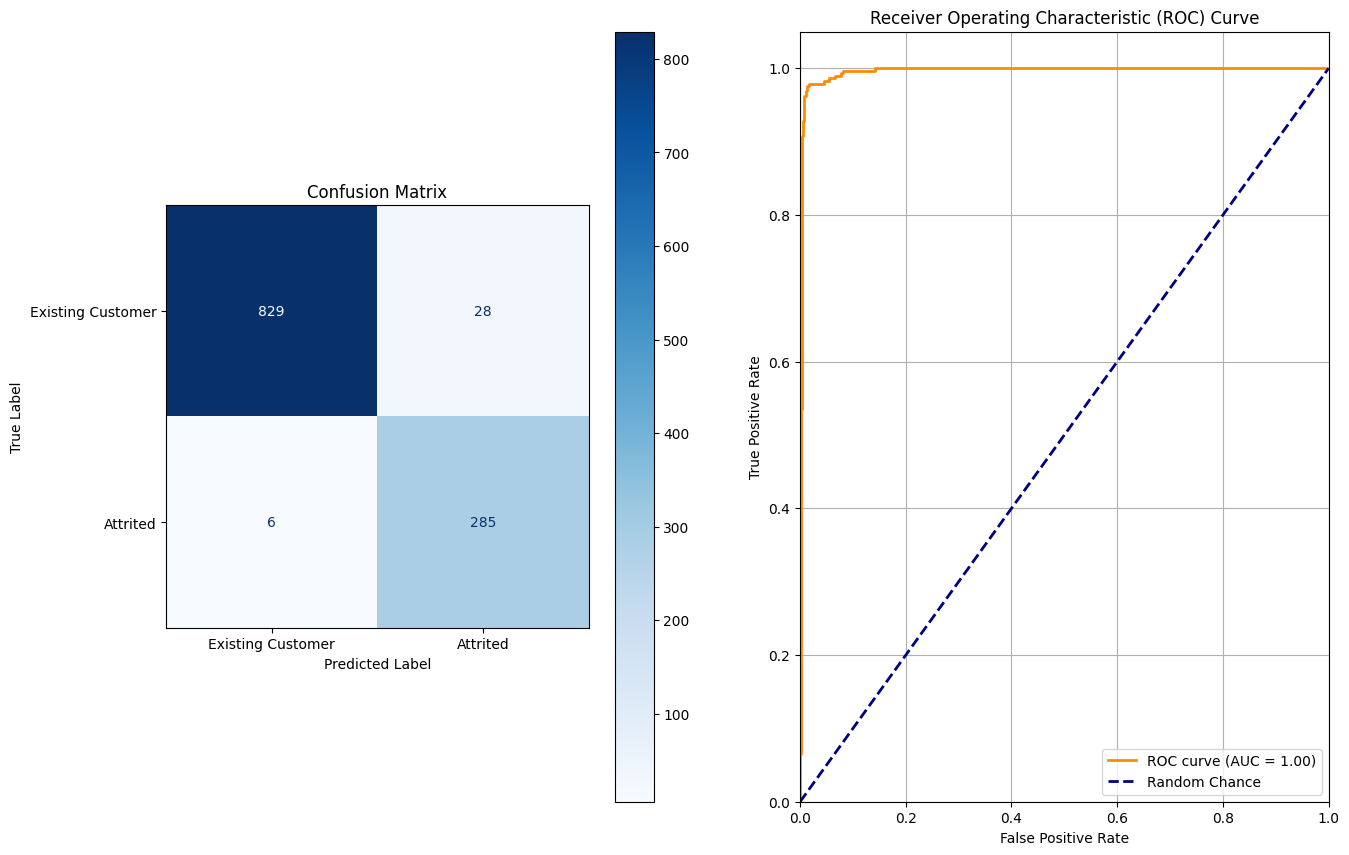

Number of Attrited Predictions: 337
Number of Existing Customer Predictions: 785
Percent Attrited Predictions: 30.035650623885918
Percent Existing Customer Predictions: 69.96434937611407

Accuracy: 97.06%

Recall: 0.9871794871794872

Precision: 0.913946587537092

F1-Score: 0.95


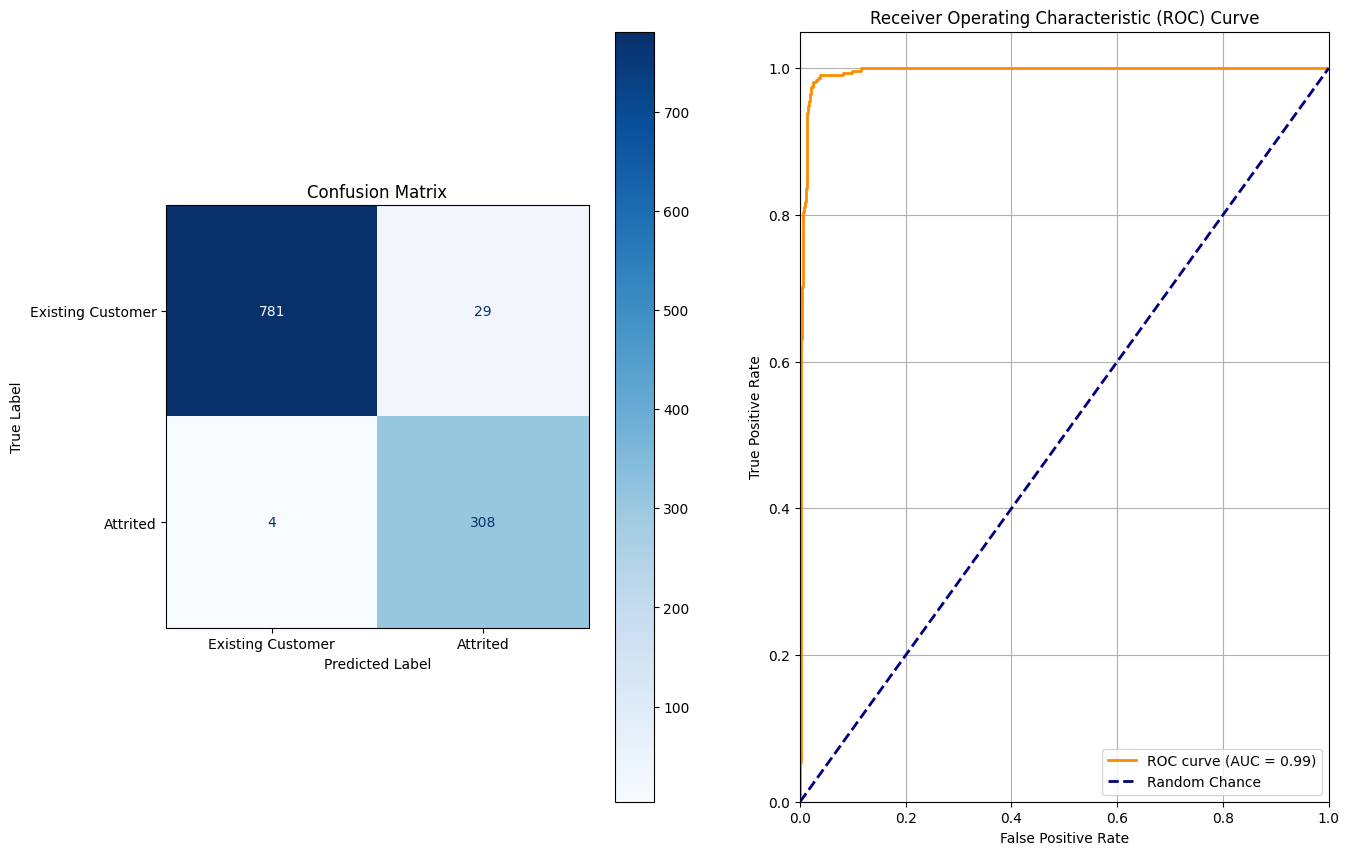

Number of Attrited Predictions: 381
Number of Existing Customer Predictions: 761
Percent Attrited Predictions: 33.36252189141856
Percent Existing Customer Predictions: 66.63747810858143

Accuracy: 96.85%

Recall: 0.9886685552407932

Precision: 0.916010498687664

F1-Score: 0.95


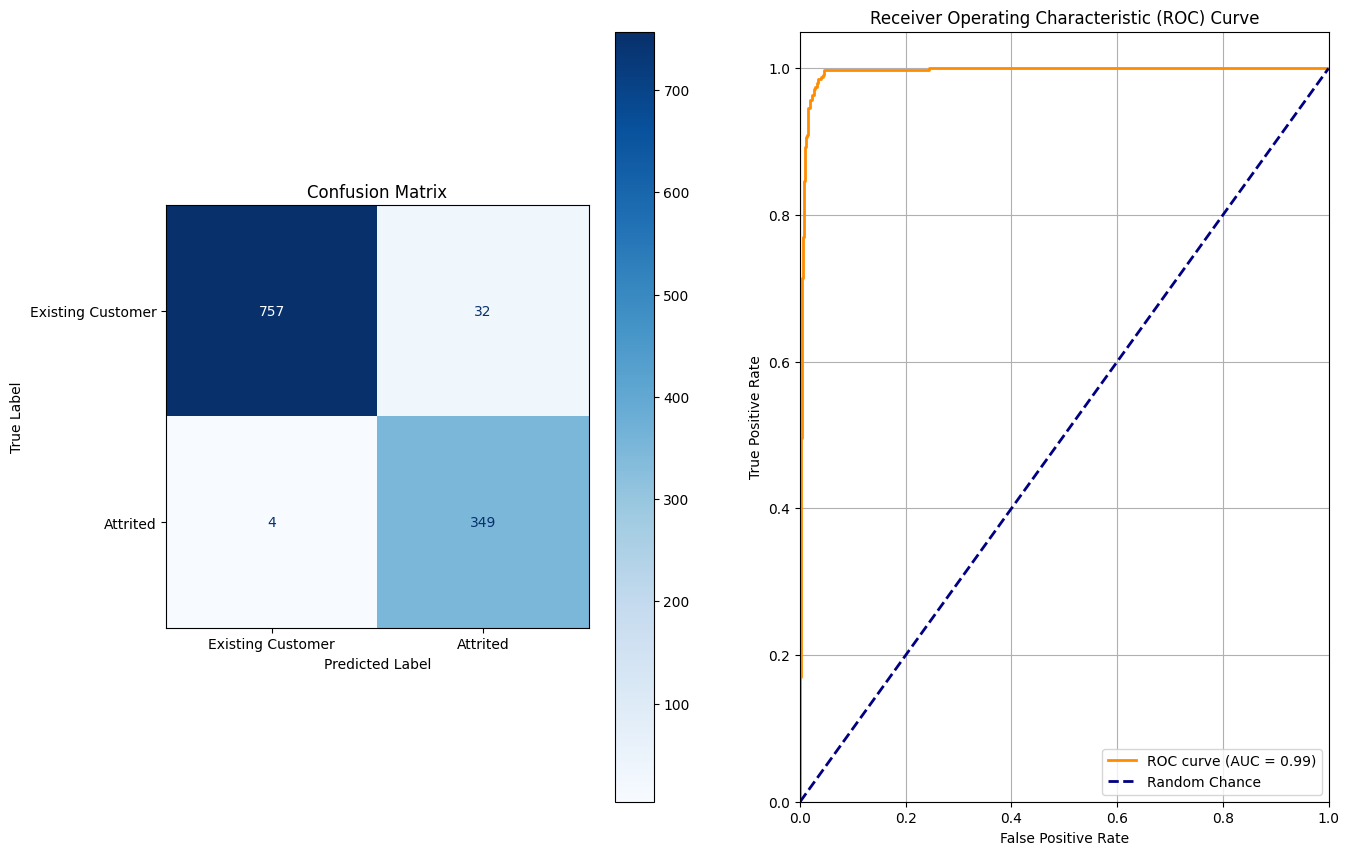

Number of Attrited Predictions: 344
Number of Existing Customer Predictions: 768
Percent Attrited Predictions: 30.935251798561154
Percent Existing Customer Predictions: 69.06474820143885

Accuracy: 98.74%

Recall: 0.9940119760479041

Precision: 0.9651162790697675

F1-Score: 0.98


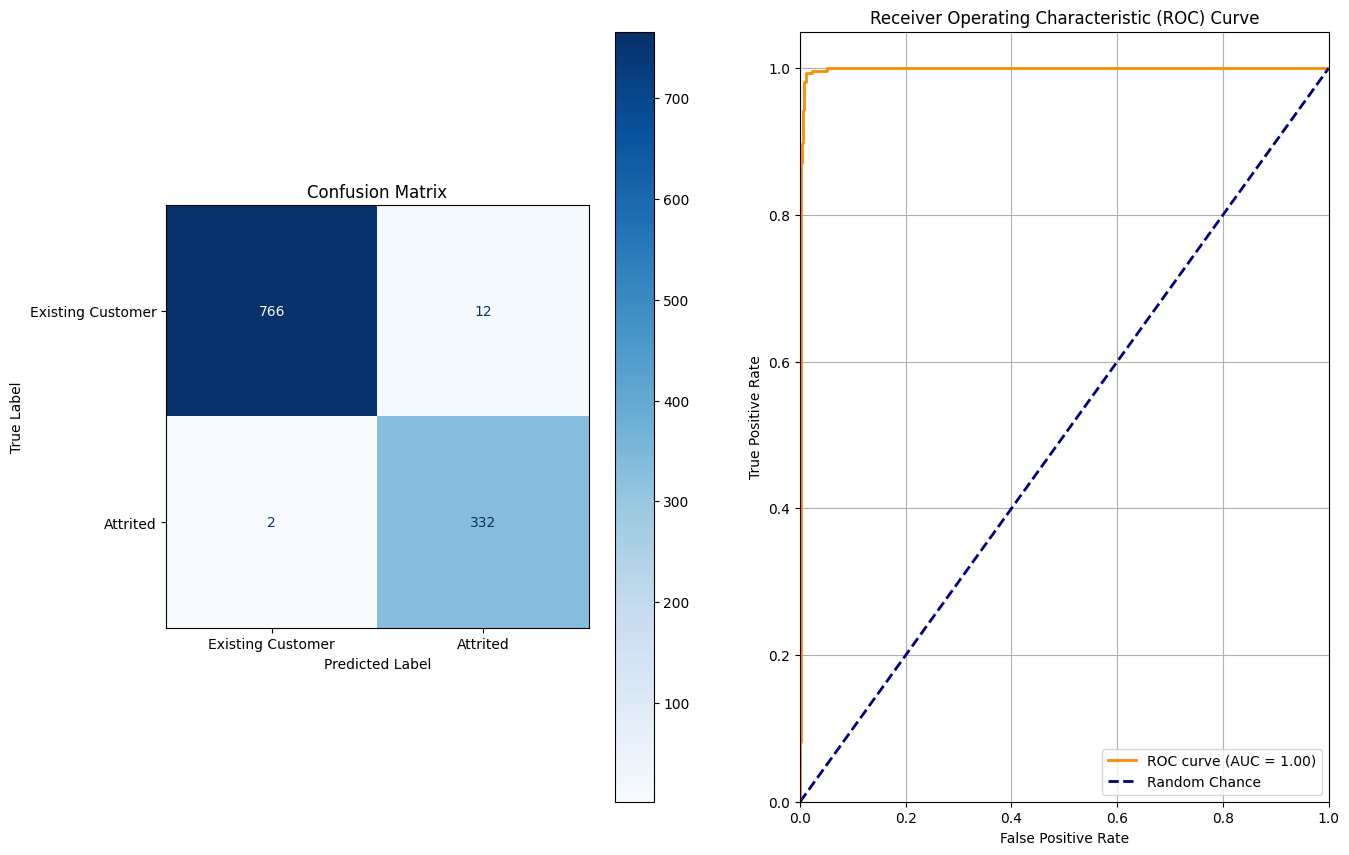

Number of Attrited Predictions: 335
Number of Existing Customer Predictions: 753
Percent Attrited Predictions: 30.79044117647059
Percent Existing Customer Predictions: 69.20955882352942

Accuracy: 97.70%

Recall: 0.9874213836477987

Precision: 0.9373134328358209

F1-Score: 0.96


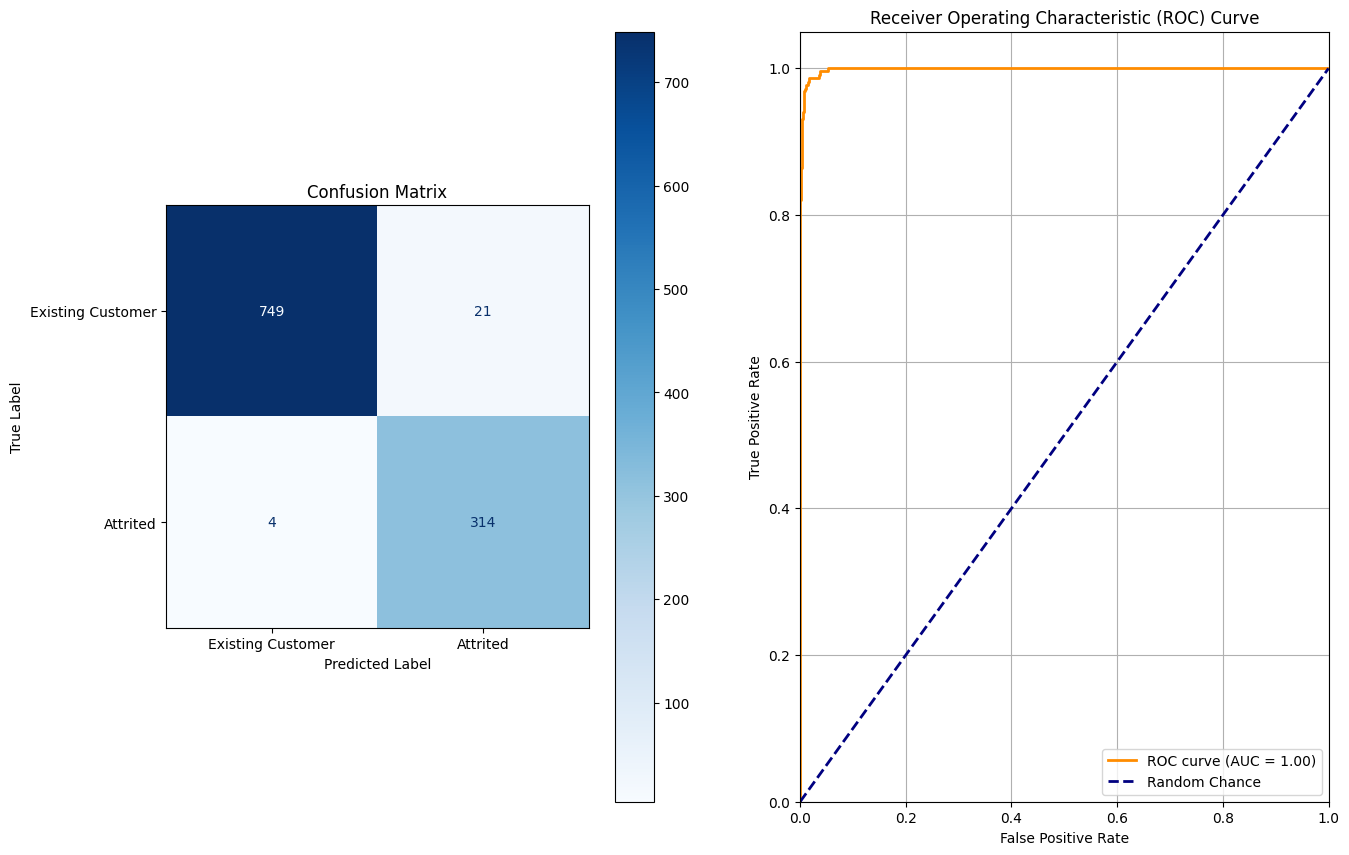

Number of Attrited Predictions: 350
Number of Existing Customer Predictions: 710
Percent Attrited Predictions: 33.0188679245283
Percent Existing Customer Predictions: 66.98113207547169

Accuracy: 96.89%

Recall: 0.9968652037617555

Precision: 0.9085714285714286

F1-Score: 0.95


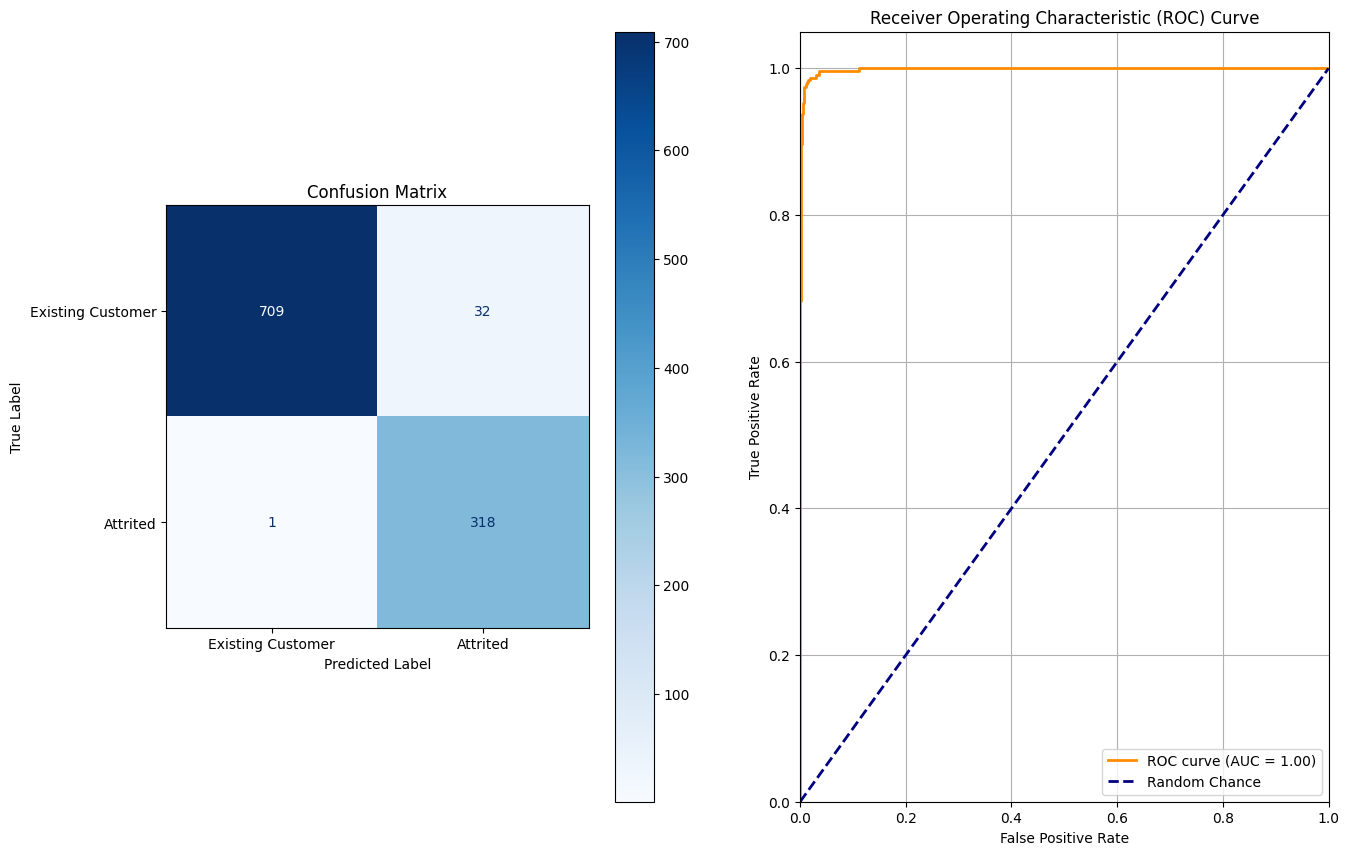

Number of Attrited Predictions: 295
Number of Existing Customer Predictions: 737
Percent Attrited Predictions: 28.58527131782946
Percent Existing Customer Predictions: 71.41472868217055

Accuracy: 97.58%

Recall: 0.9891304347826086

Precision: 0.9254237288135593

F1-Score: 0.96


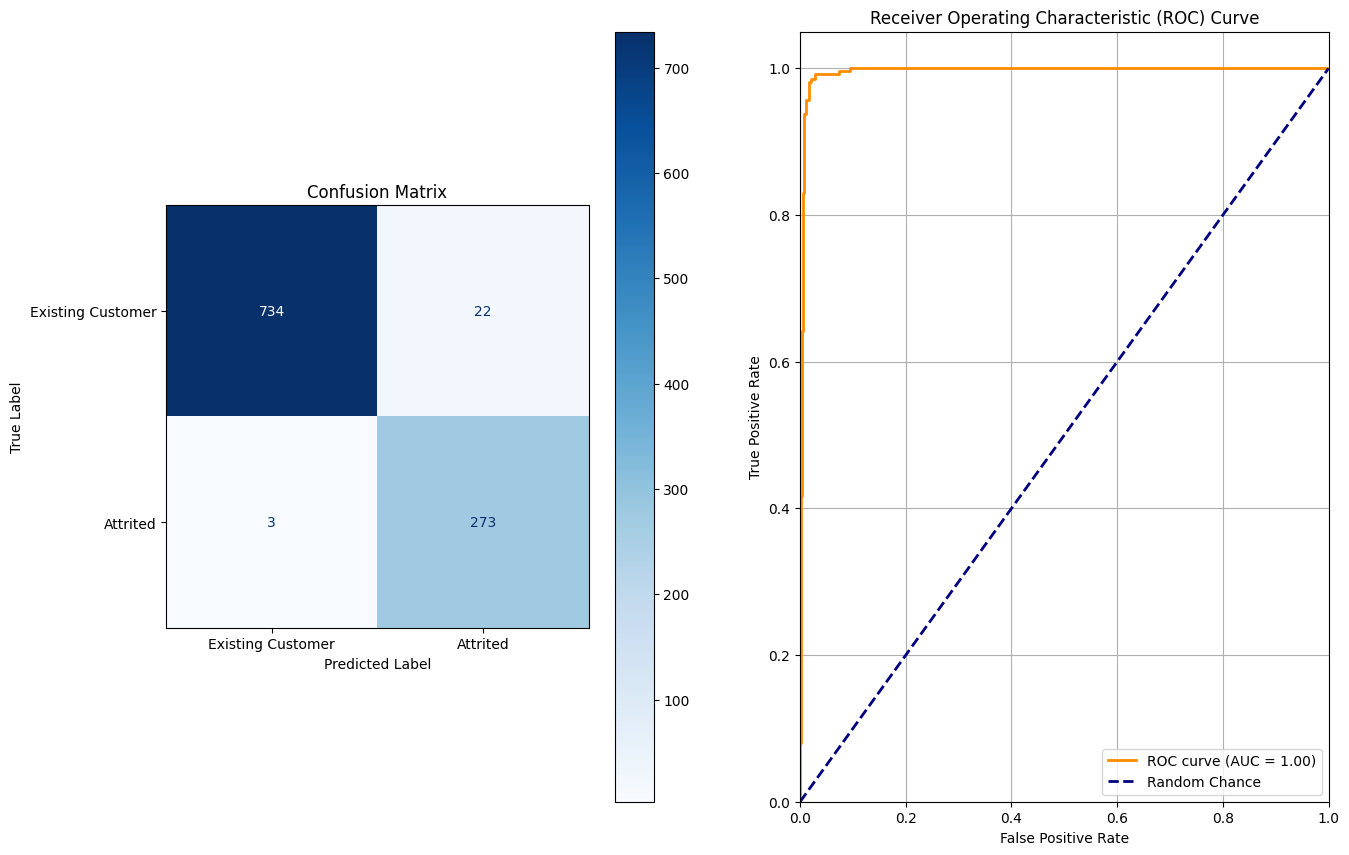

Number of Attrited Predictions: 344
Number of Existing Customer Predictions: 699
Percent Attrited Predictions: 32.98178331735379
Percent Existing Customer Predictions: 67.01821668264621

Accuracy: 97.03%

Recall: 0.9905956112852664

Precision: 0.9186046511627907

F1-Score: 0.95


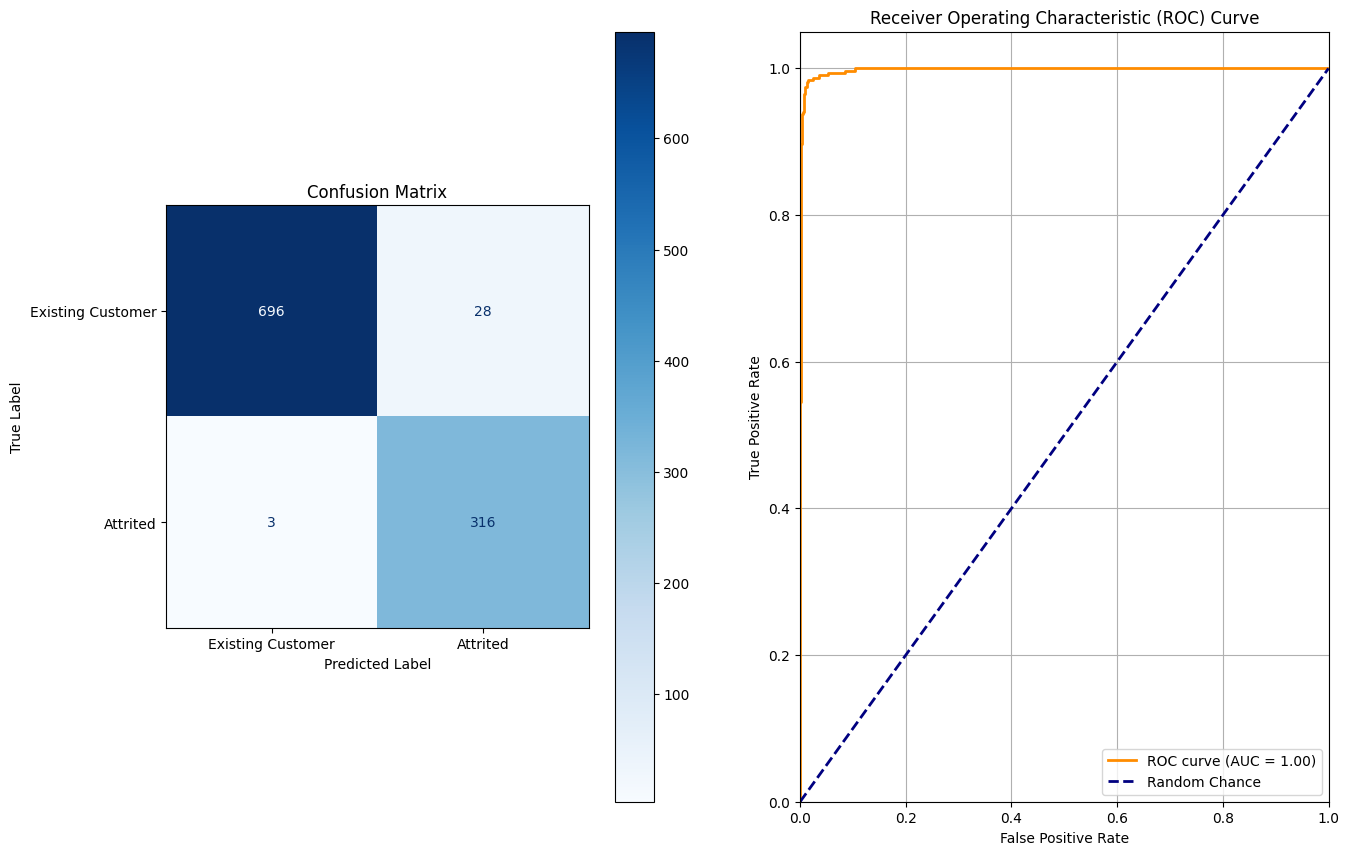

Number of Attrited Predictions: 313
Number of Existing Customer Predictions: 709
Percent Attrited Predictions: 30.626223091976517
Percent Existing Customer Predictions: 69.37377690802349

Accuracy: 98.24%

Recall: 0.9867986798679867

Precision: 0.9552715654952076

F1-Score: 0.97


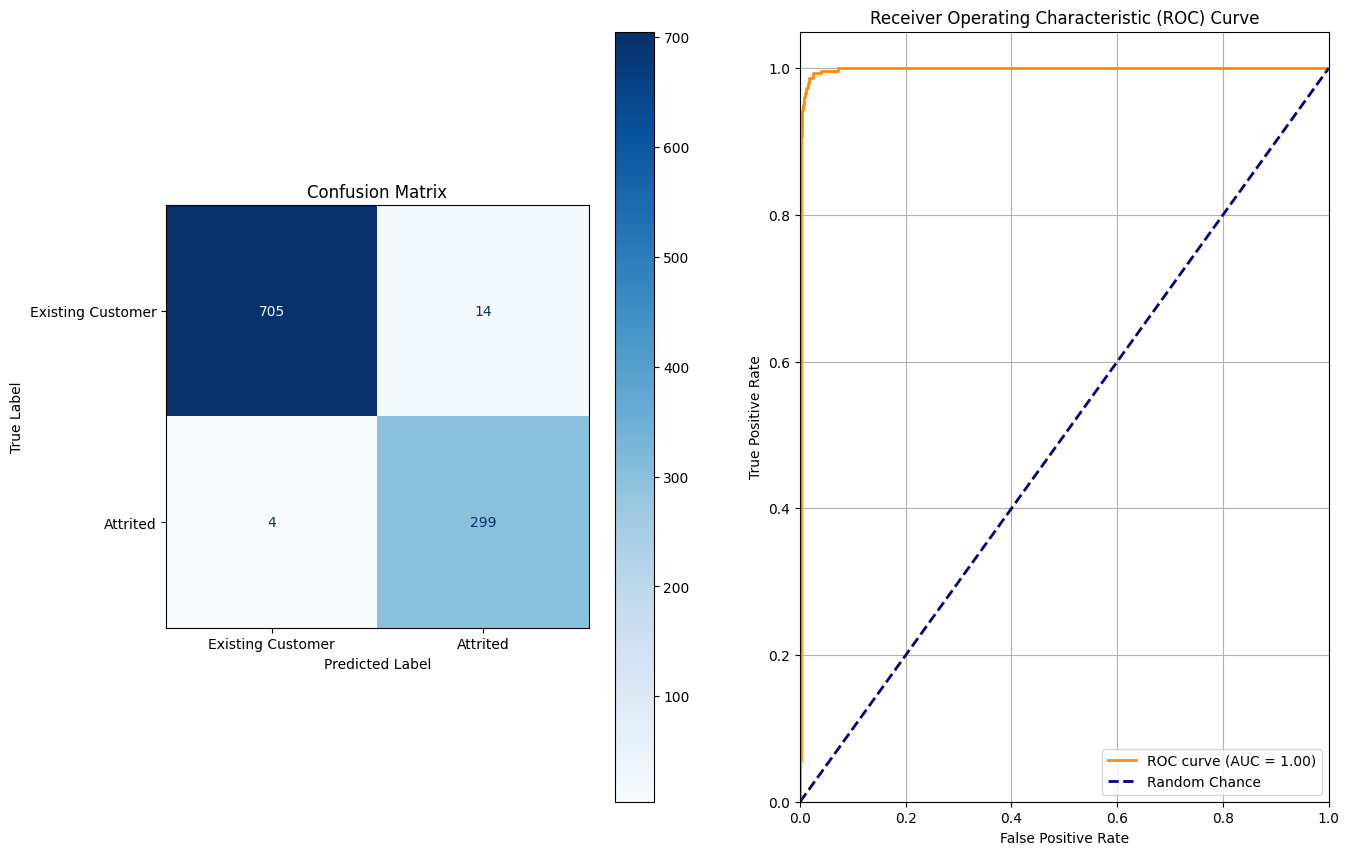

Number of Attrited Predictions: 336
Number of Existing Customer Predictions: 668
Percent Attrited Predictions: 33.46613545816733
Percent Existing Customer Predictions: 66.53386454183267

Accuracy: 98.51%

Recall: 0.9938461538461538

Precision: 0.9613095238095238

F1-Score: 0.98


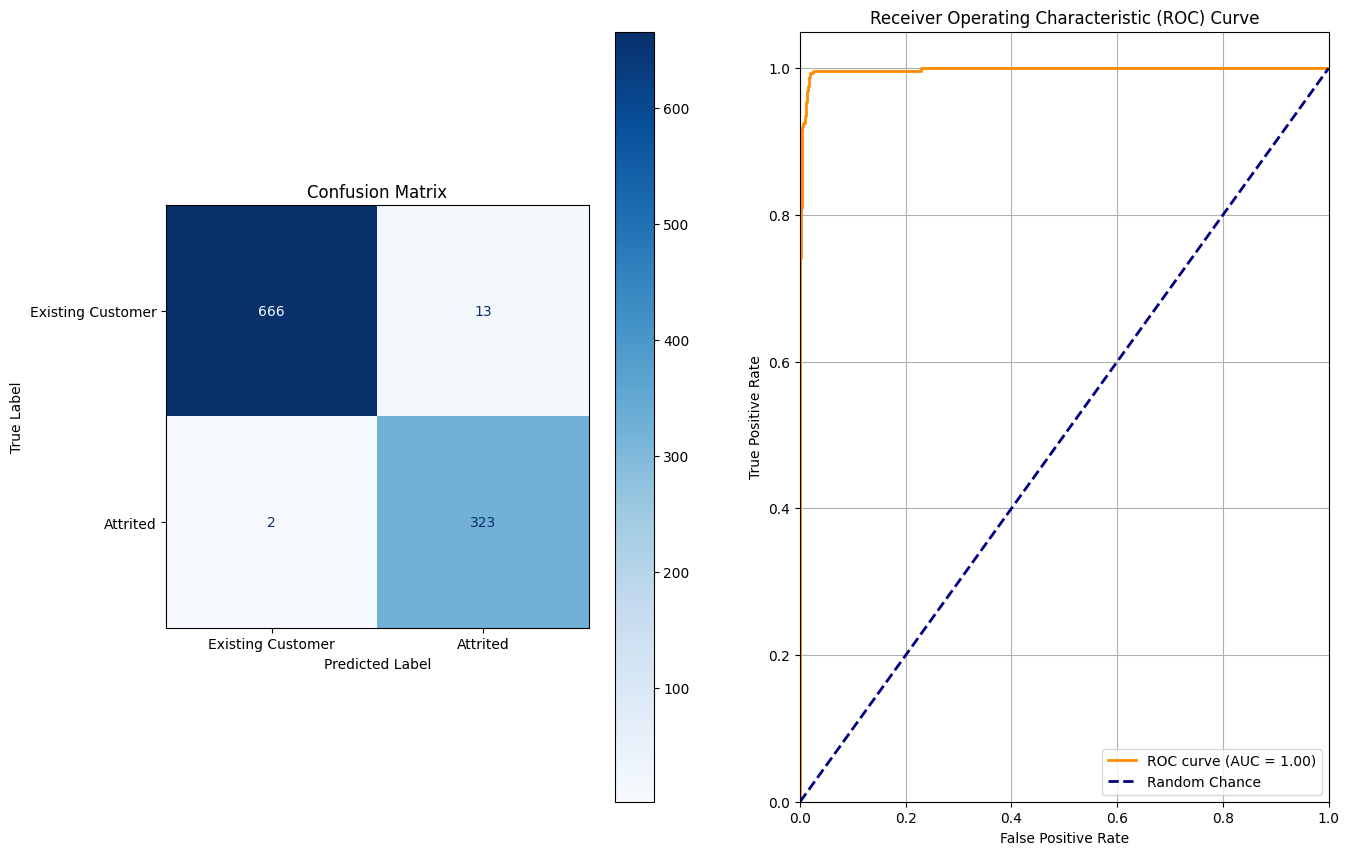

Number of Attrited Predictions: 333
Number of Existing Customer Predictions: 652
Percent Attrited Predictions: 33.807106598984774
Percent Existing Customer Predictions: 66.19289340101523

Accuracy: 97.77%

Recall: 0.987460815047022

Precision: 0.9459459459459459

F1-Score: 0.97


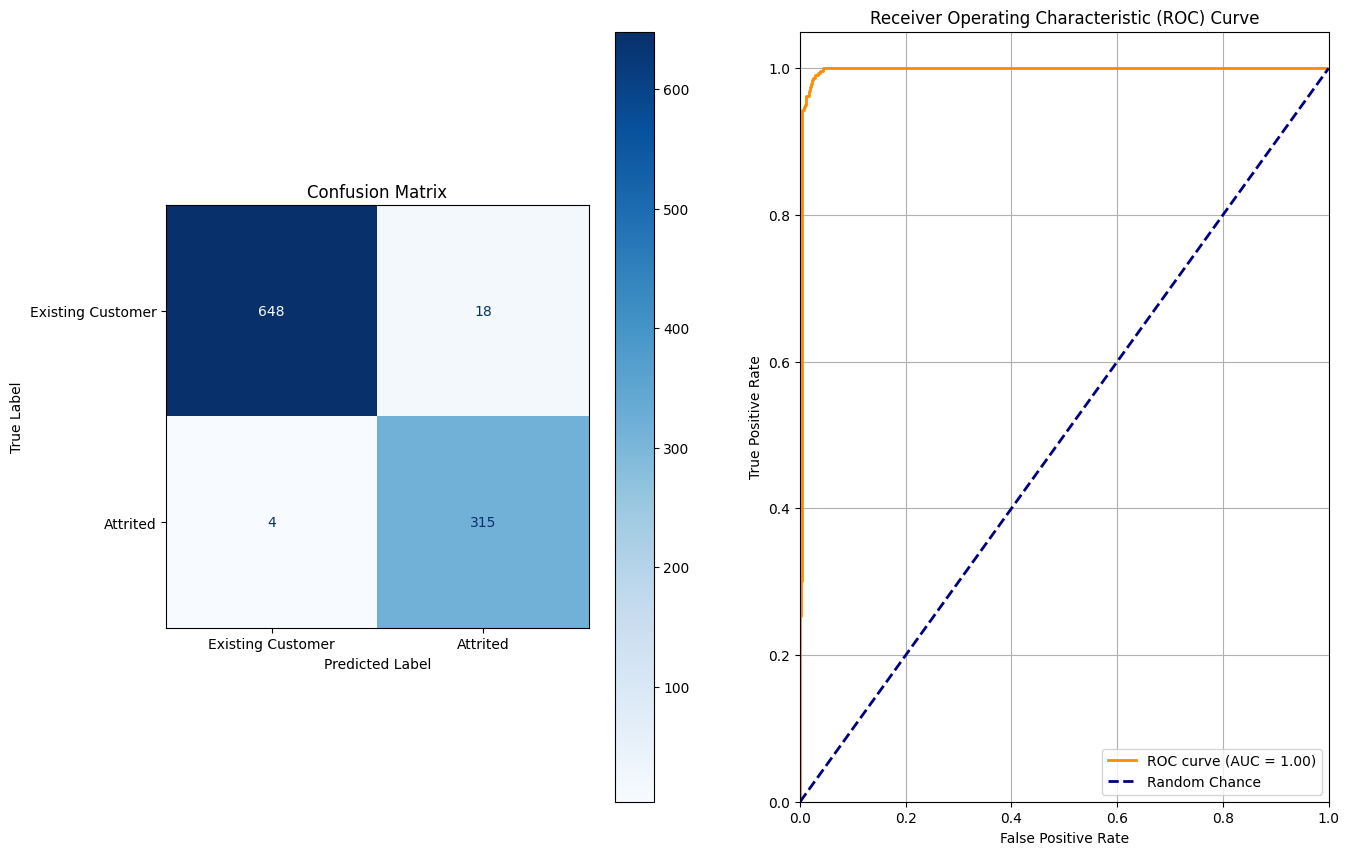

Number of Attrited Predictions: 322
Number of Existing Customer Predictions: 644
Percent Attrited Predictions: 33.33333333333333
Percent Existing Customer Predictions: 66.66666666666666

Accuracy: 97.72%

Recall: 0.9901960784313726

Precision: 0.9409937888198758

F1-Score: 0.96


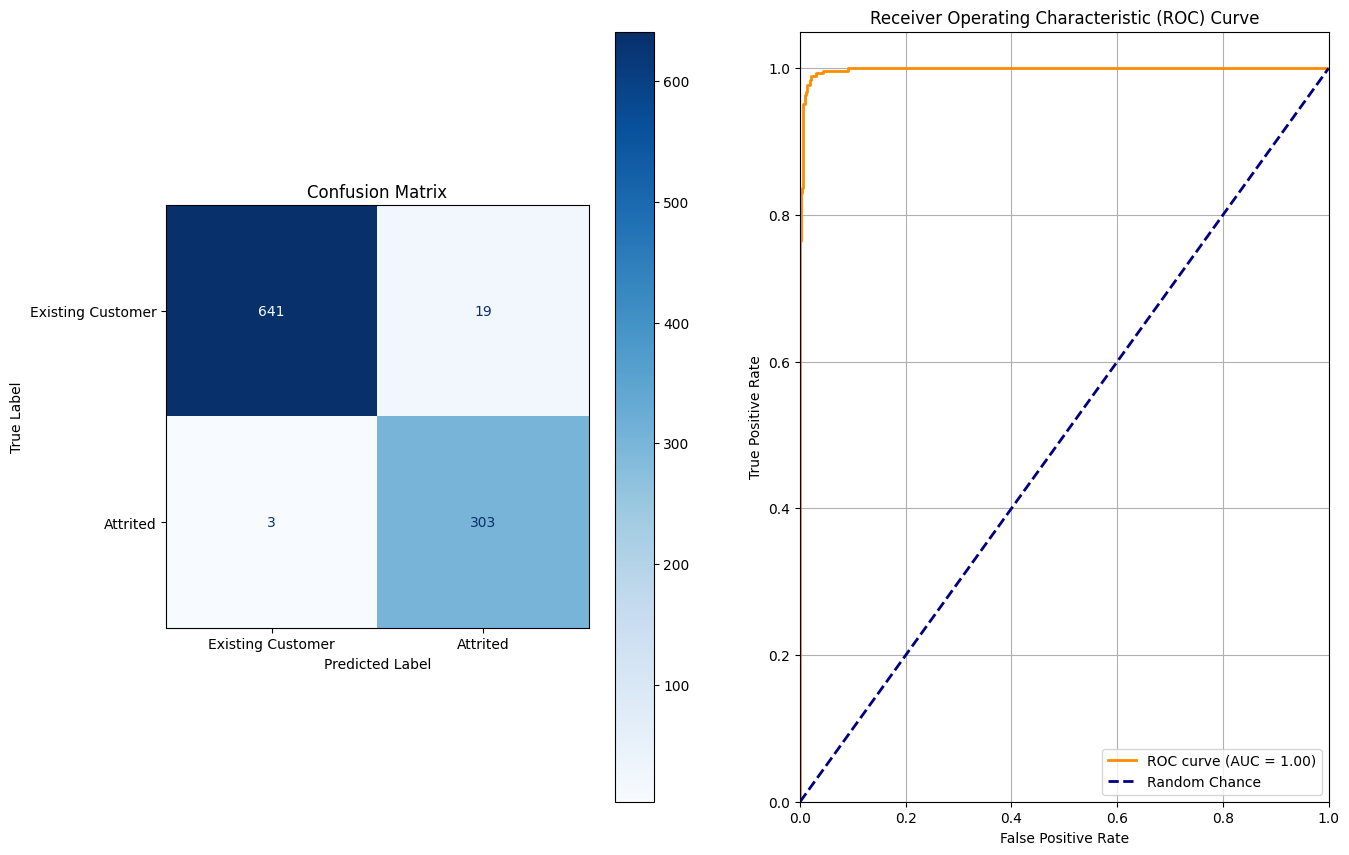

Number of Attrited Predictions: 356
Number of Existing Customer Predictions: 607
Percent Attrited Predictions: 36.967808930425754
Percent Existing Customer Predictions: 63.03219106957425

Accuracy: 96.88%

Recall: 0.9880239520958084

Precision: 0.9269662921348315

F1-Score: 0.96


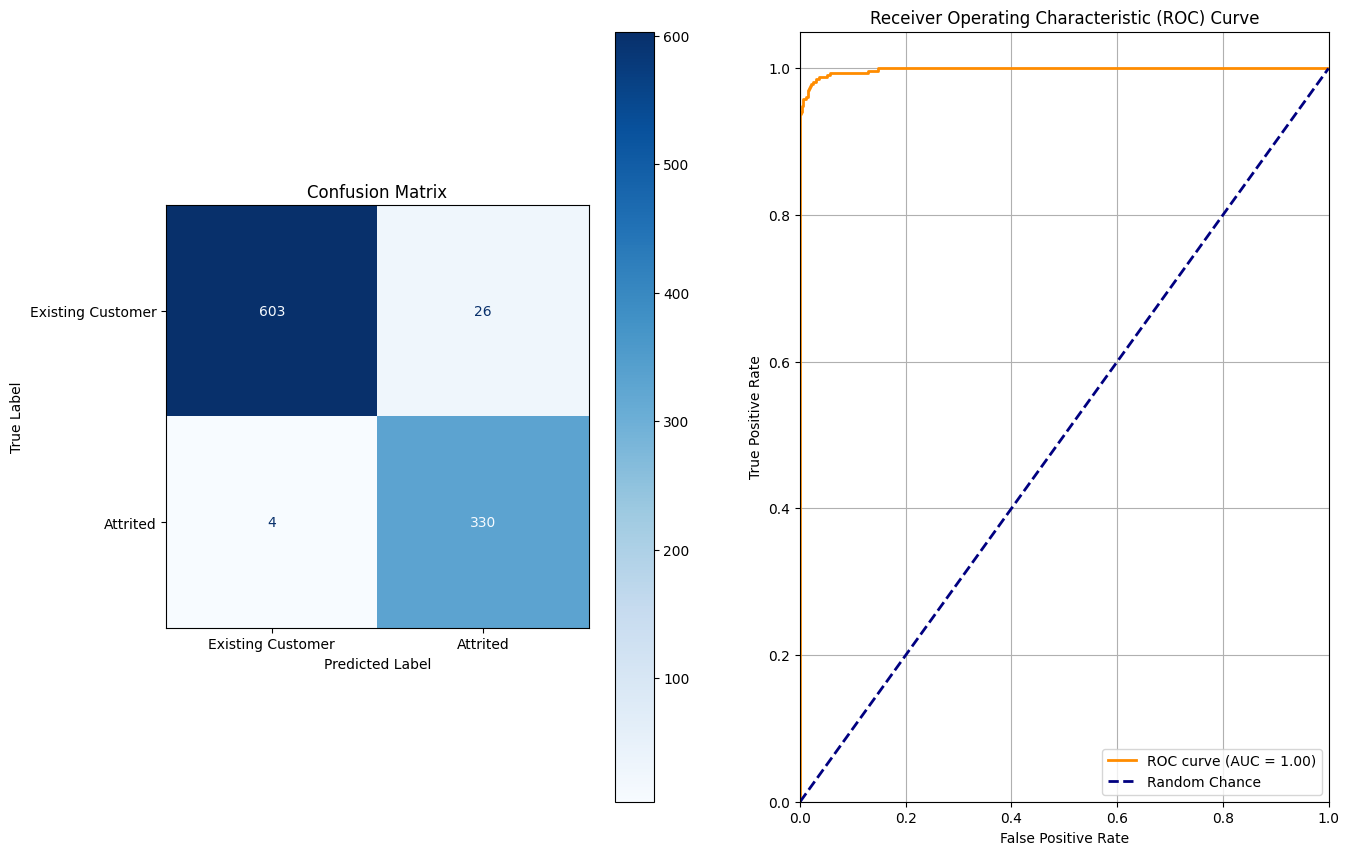

Number of Attrited Predictions: 348
Number of Existing Customer Predictions: 599
Percent Attrited Predictions: 36.74762407602957
Percent Existing Customer Predictions: 63.252375923970426

Accuracy: 98.73%

Recall: 0.9883720930232558

Precision: 0.9770114942528736

F1-Score: 0.98


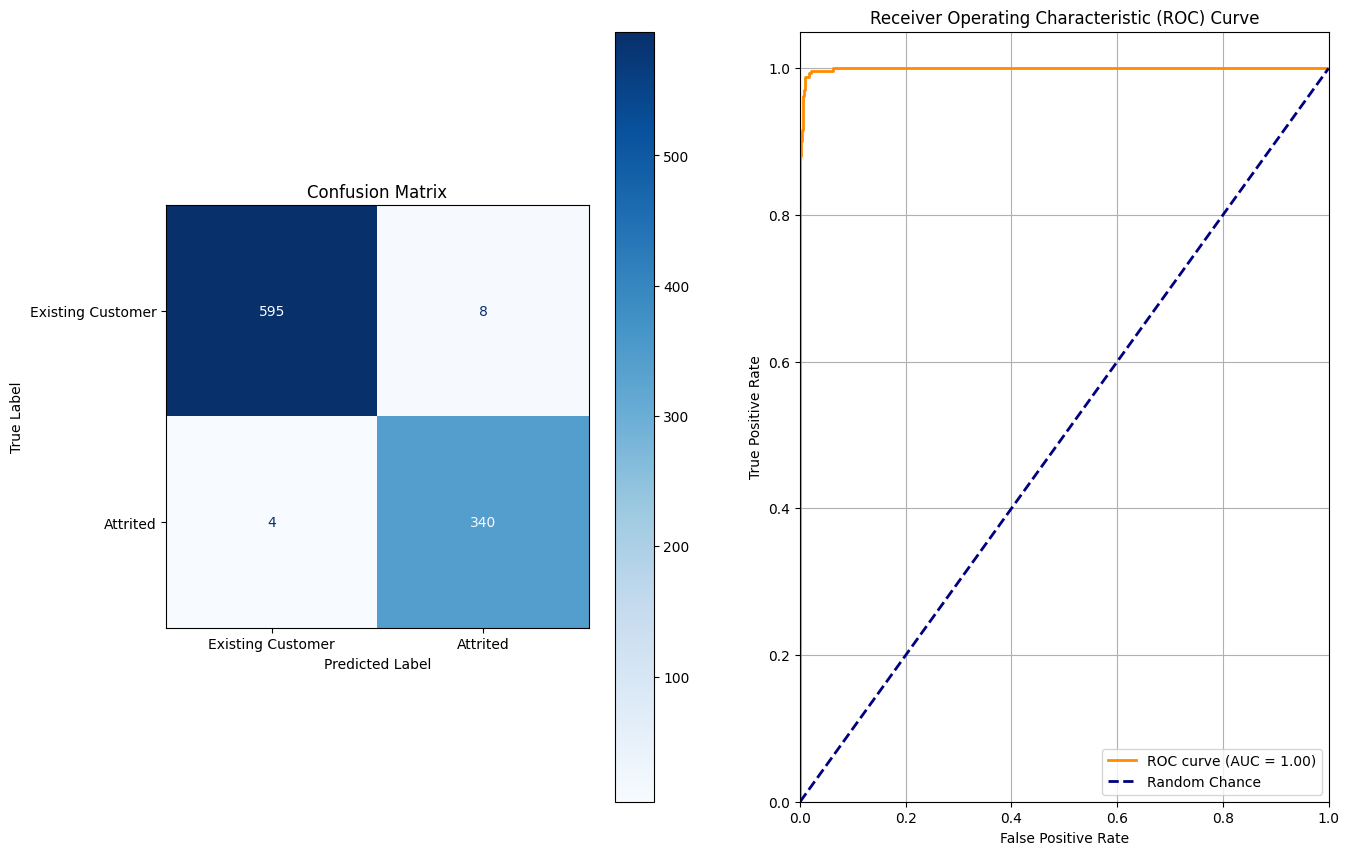

Number of Attrited Predictions: 342
Number of Existing Customer Predictions: 593
Percent Attrited Predictions: 36.57754010695187
Percent Existing Customer Predictions: 63.422459893048135

Accuracy: 97.11%

Recall: 0.9846153846153847

Precision: 0.935672514619883

F1-Score: 0.96


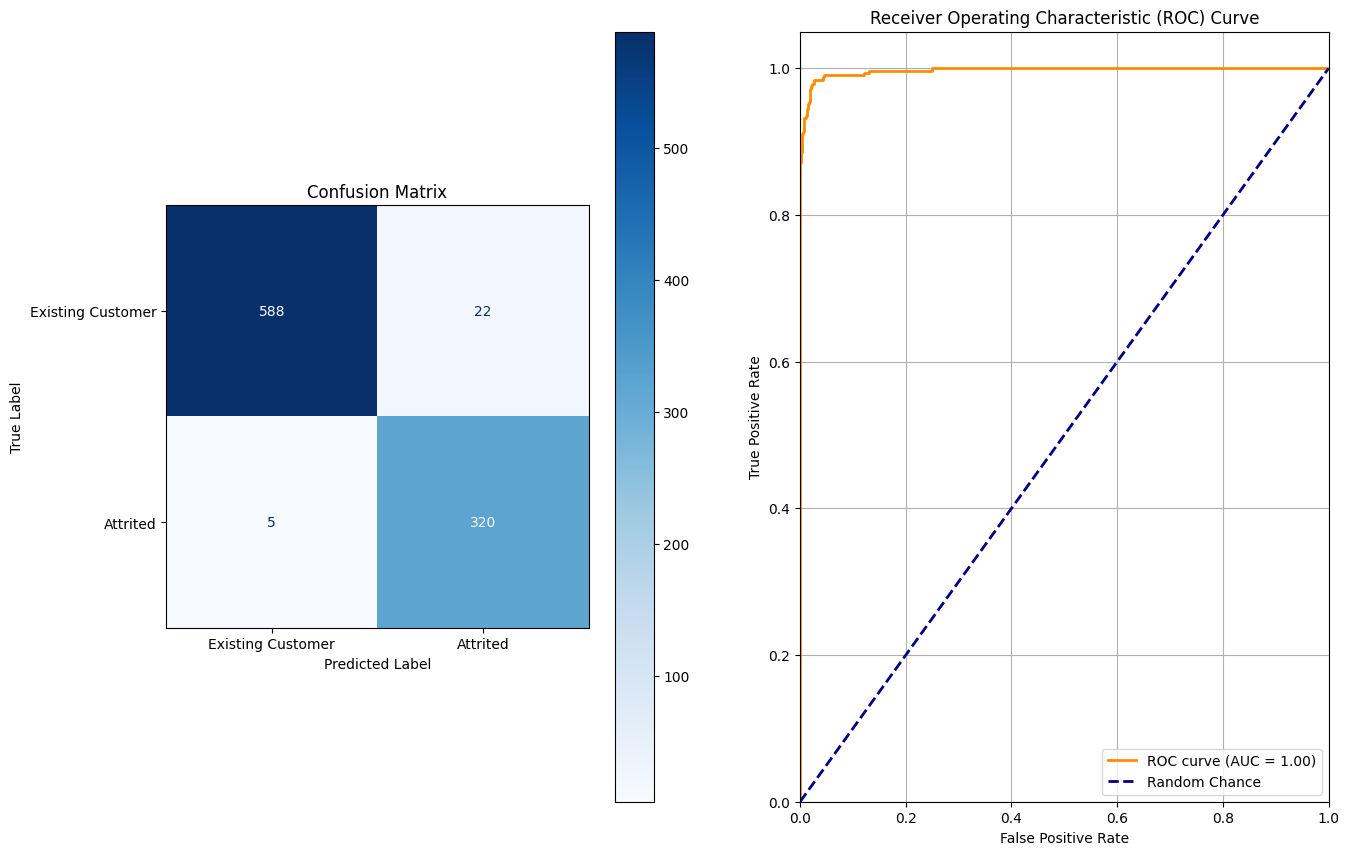

Number of Attrited Predictions: 336
Number of Existing Customer Predictions: 578
Percent Attrited Predictions: 36.76148796498906
Percent Existing Customer Predictions: 63.23851203501094

Accuracy: 98.25%

Recall: 0.99079754601227

Precision: 0.9613095238095238

F1-Score: 0.98


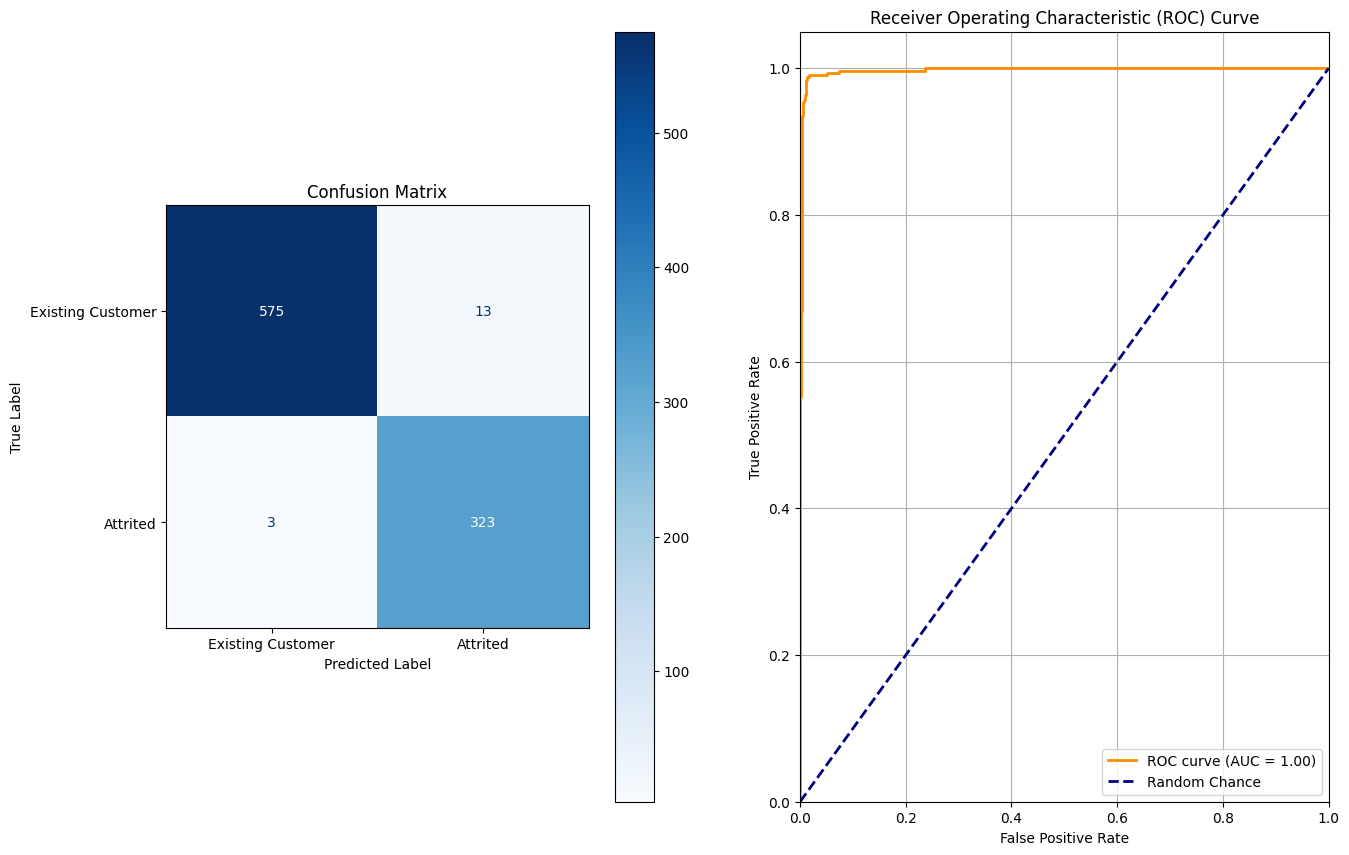

Number of Attrited Predictions: 321
Number of Existing Customer Predictions: 578
Percent Attrited Predictions: 35.706340378198
Percent Existing Customer Predictions: 64.29365962180201

Accuracy: 98.22%

Recall: 0.987220447284345

Precision: 0.9626168224299065

F1-Score: 0.97


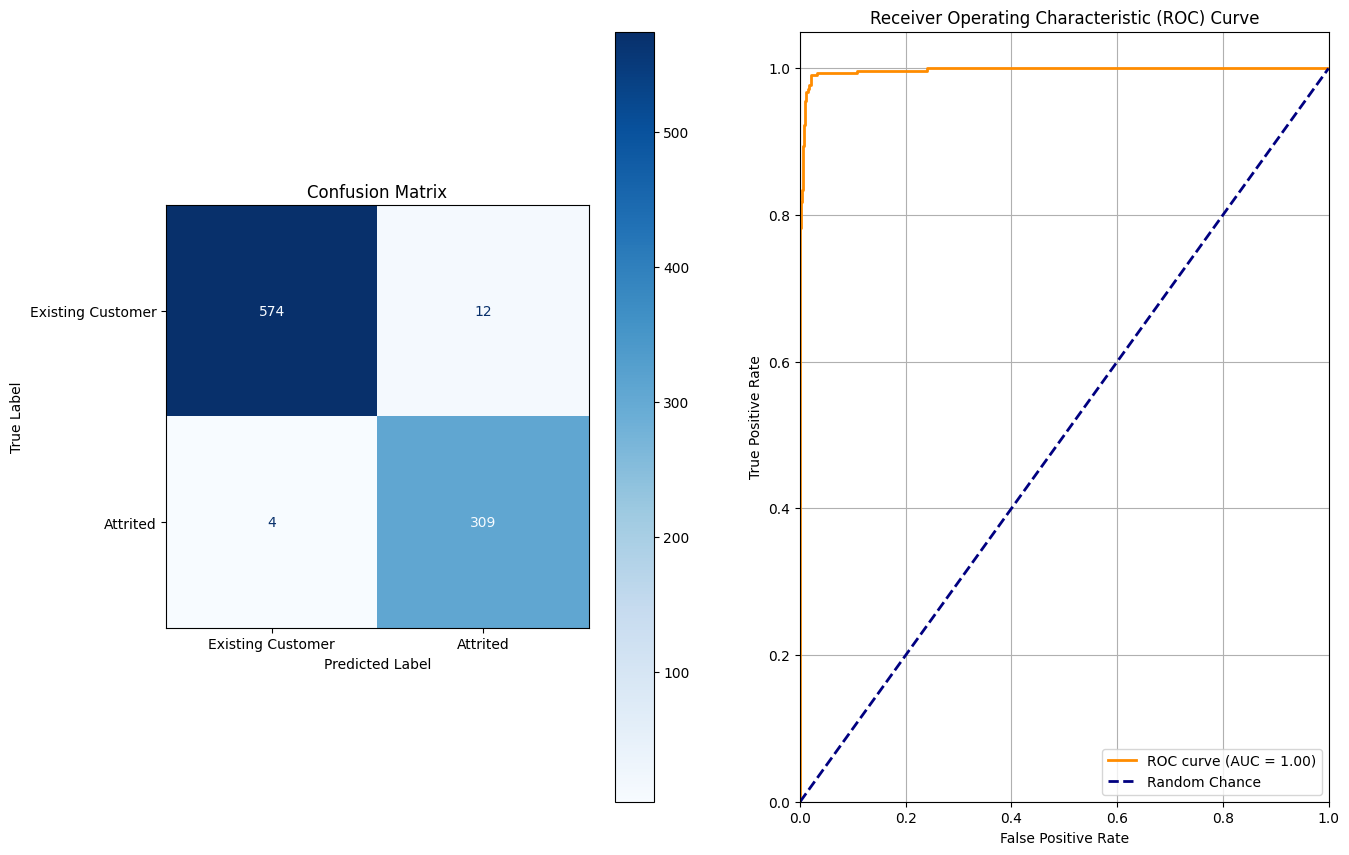

Number of Attrited Predictions: 353
Number of Existing Customer Predictions: 538
Percent Attrited Predictions: 39.61840628507295
Percent Existing Customer Predictions: 60.38159371492705

Accuracy: 97.87%

Recall: 0.9970238095238095

Precision: 0.9490084985835694

F1-Score: 0.97


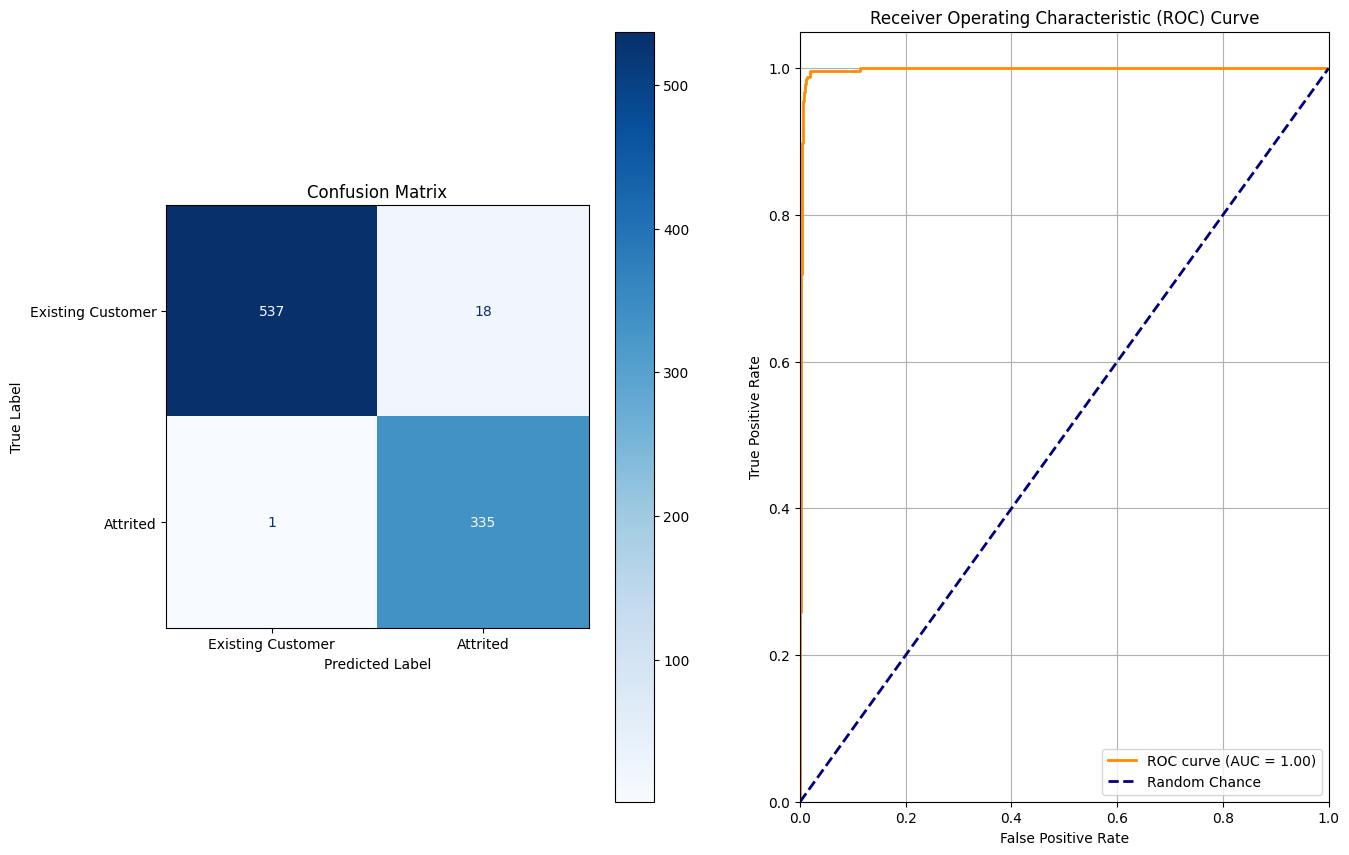

Number of Attrited Predictions: 328
Number of Existing Customer Predictions: 542
Percent Attrited Predictions: 37.701149425287355
Percent Existing Customer Predictions: 62.29885057471264

Accuracy: 95.63%

Recall: 0.9475308641975309

Precision: 0.9359756097560976

F1-Score: 0.94


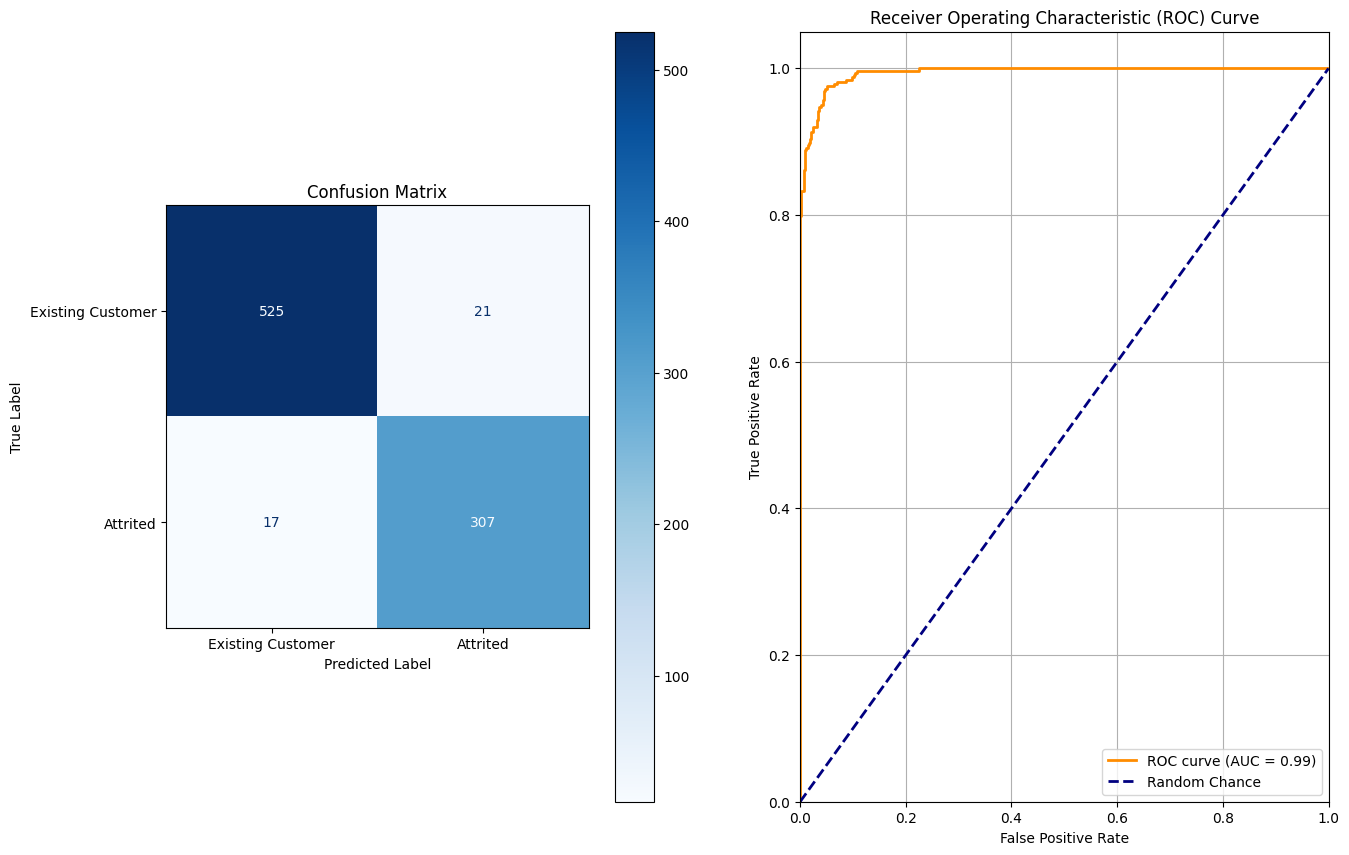

Number of Attrited Predictions: 327
Number of Existing Customer Predictions: 523
Percent Attrited Predictions: 38.470588235294116
Percent Existing Customer Predictions: 61.52941176470588

Accuracy: 98.24%

Recall: 0.984472049689441

Precision: 0.9694189602446484

F1-Score: 0.98


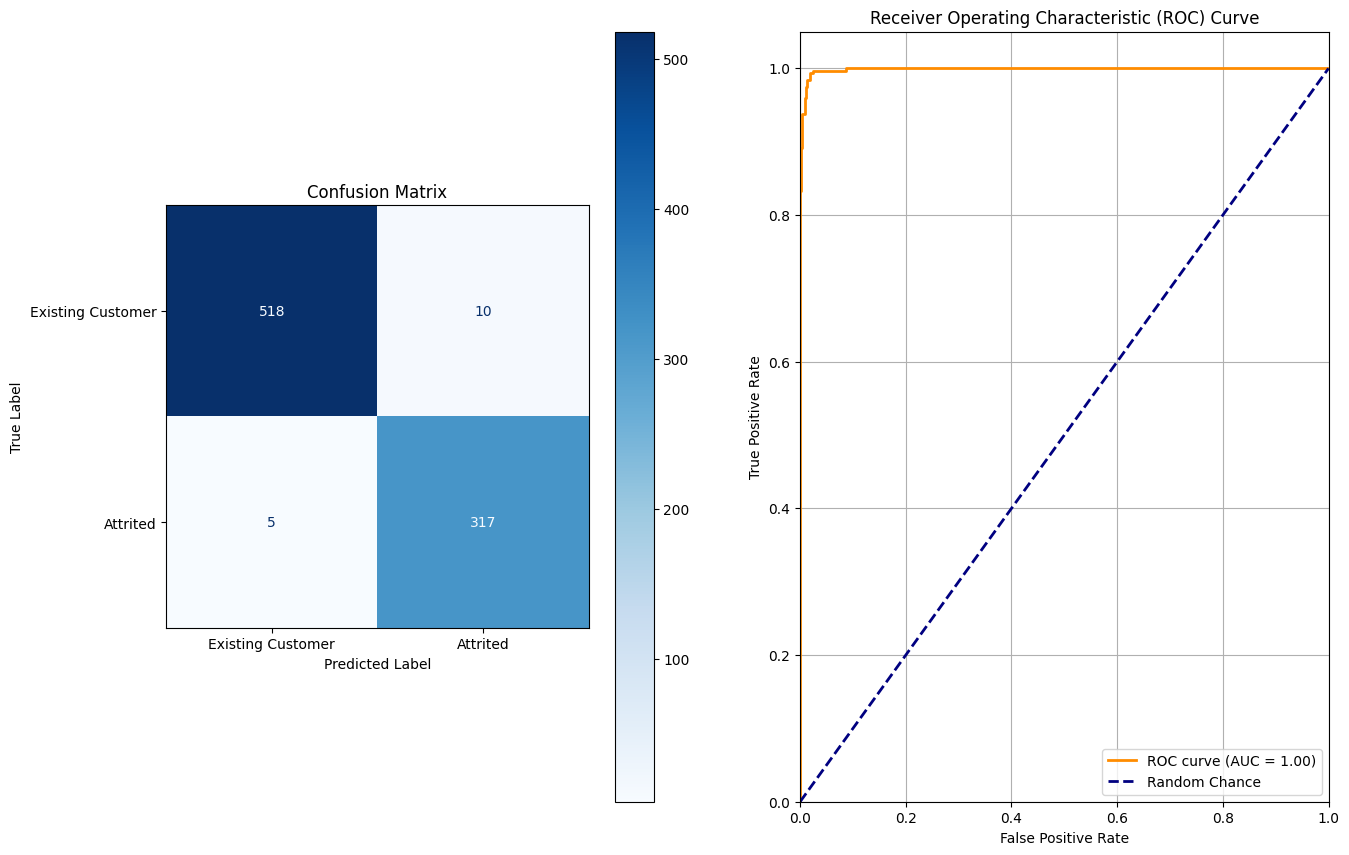

Number of Attrited Predictions: 317
Number of Existing Customer Predictions: 507
Percent Attrited Predictions: 38.470873786407765
Percent Existing Customer Predictions: 61.529126213592235

Accuracy: 96.84%

Recall: 0.9833887043189369

Precision: 0.9337539432176656

F1-Score: 0.96


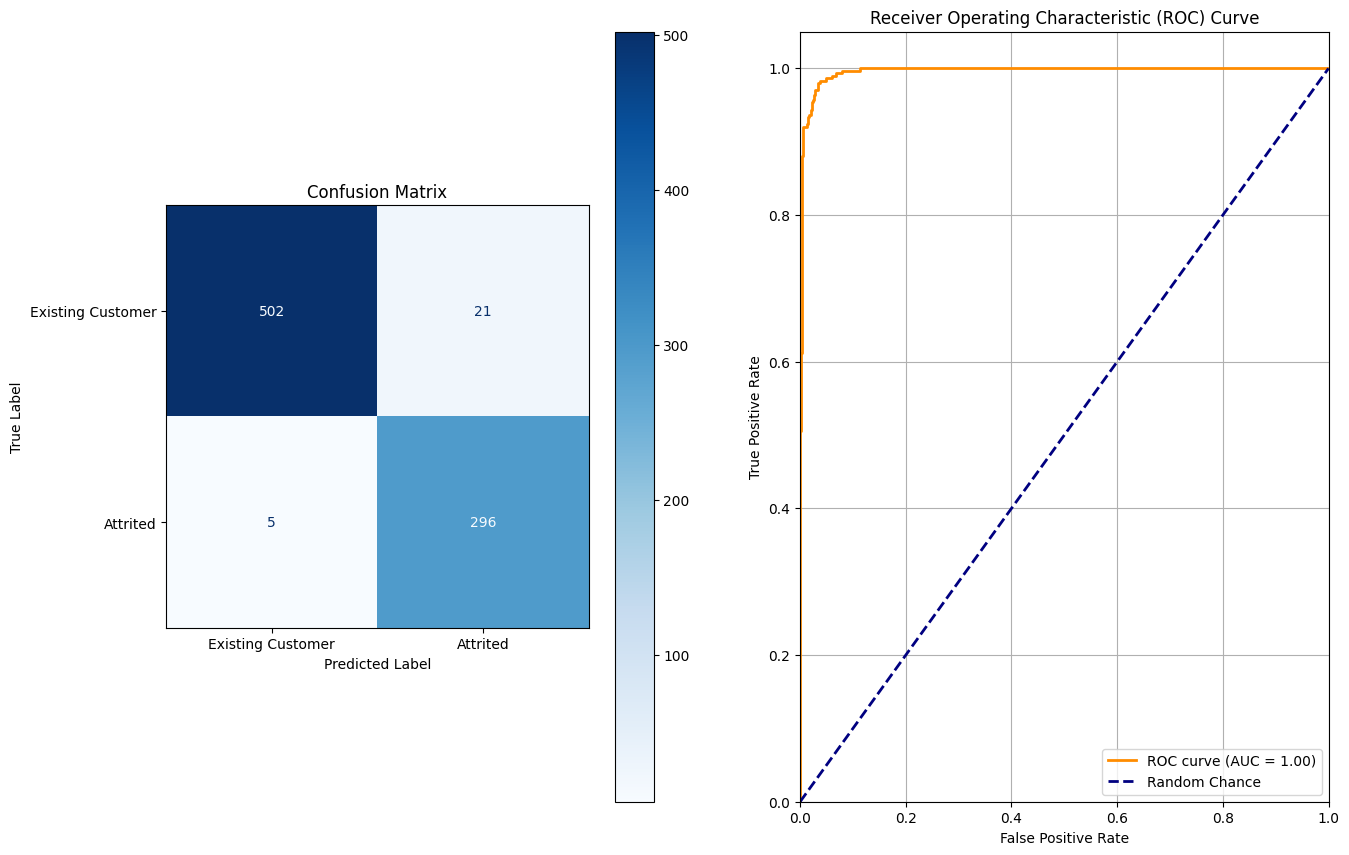

Number of Attrited Predictions: 307
Number of Existing Customer Predictions: 499
Percent Attrited Predictions: 38.0893300248139
Percent Existing Customer Predictions: 61.9106699751861

Accuracy: 98.39%

Recall: 0.99

Precision: 0.9674267100977199

F1-Score: 0.98


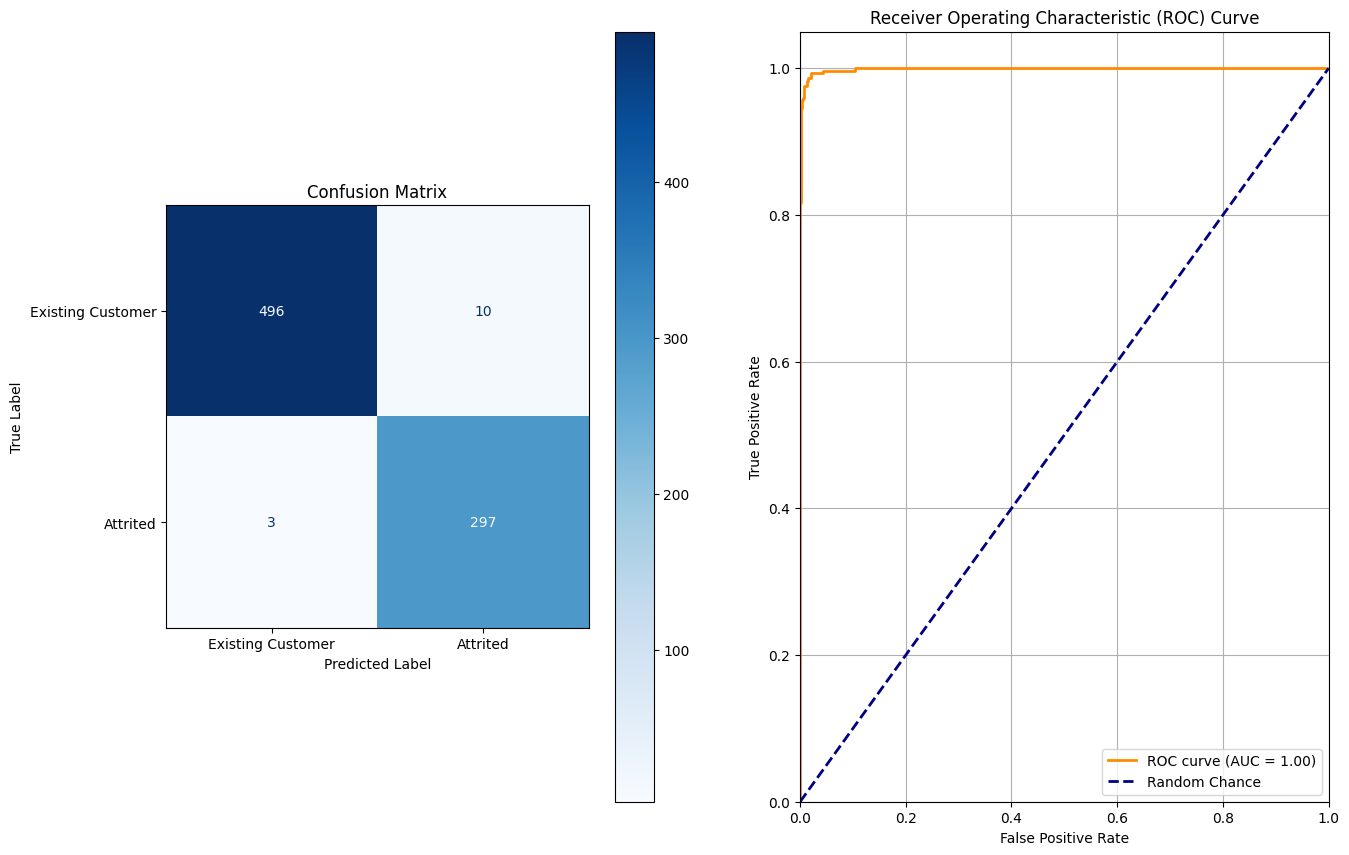

Number of Attrited Predictions: 337
Number of Existing Customer Predictions: 448
Percent Attrited Predictions: 42.92993630573248
Percent Existing Customer Predictions: 57.07006369426752

Accuracy: 97.58%

Recall: 0.9877300613496932

Precision: 0.9554896142433235

F1-Score: 0.97


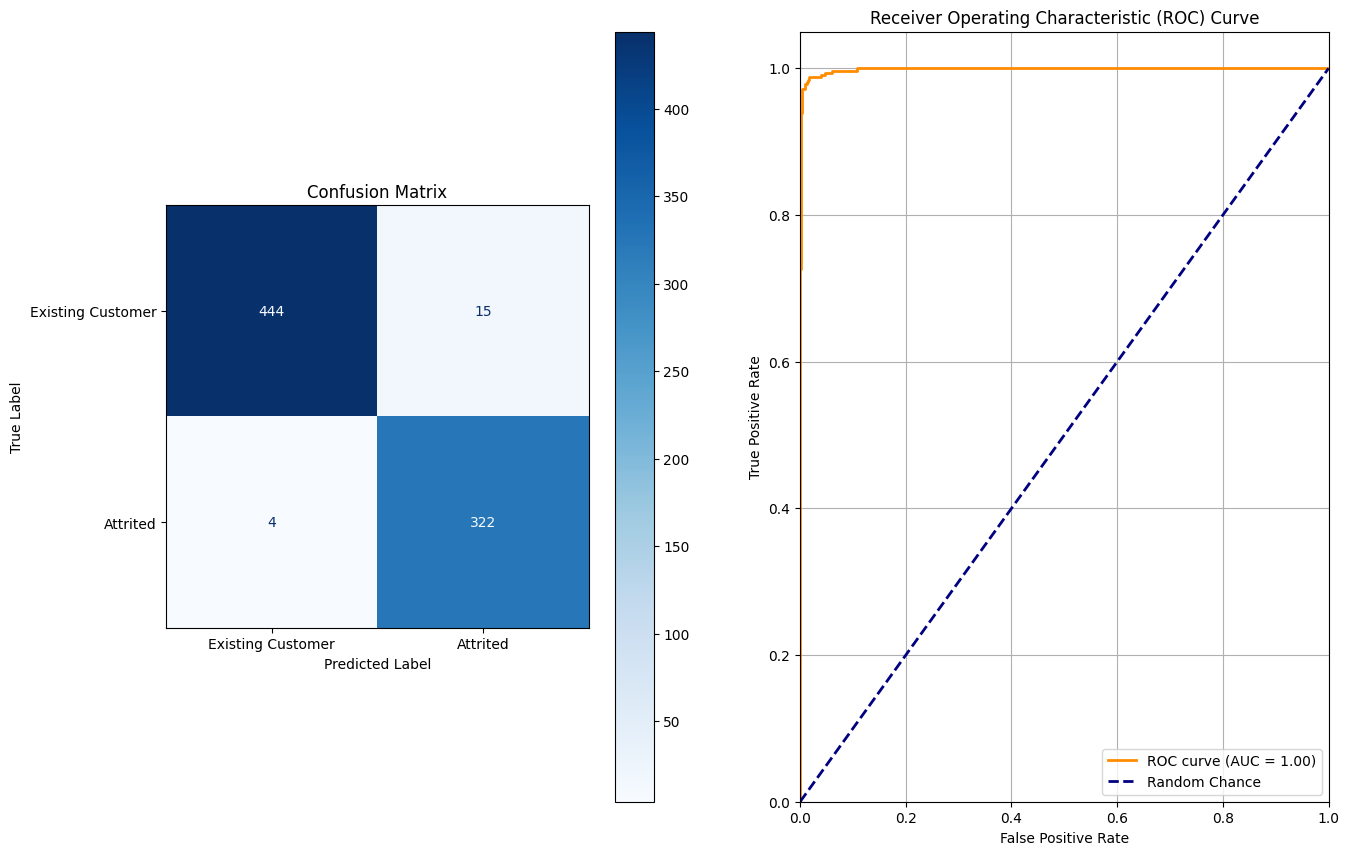

Number of Attrited Predictions: 308
Number of Existing Customer Predictions: 464
Percent Attrited Predictions: 39.89637305699482
Percent Existing Customer Predictions: 60.10362694300518

Accuracy: 99.22%

Recall: 0.9839743589743589

Precision: 0.9967532467532467

F1-Score: 0.99


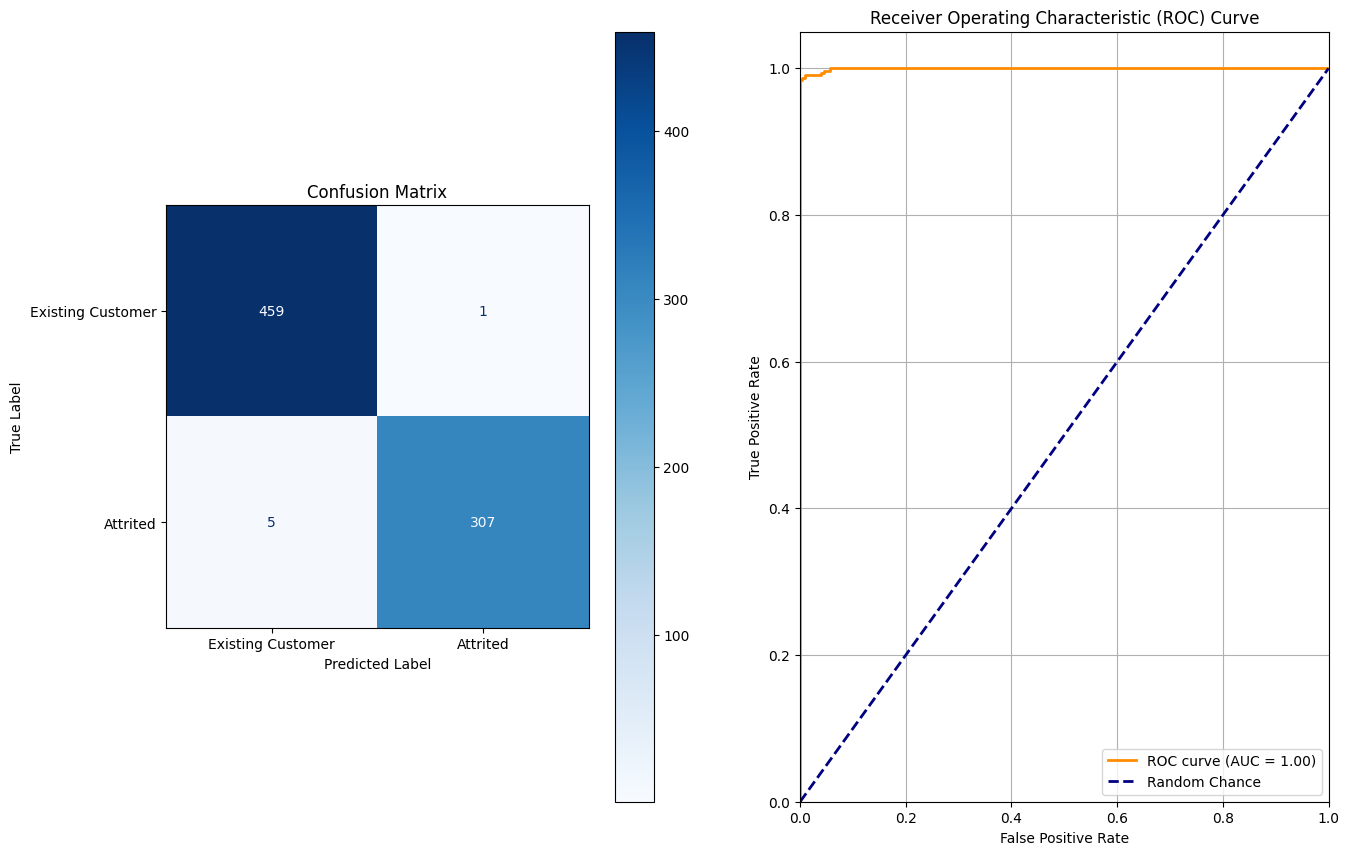

Number of Attrited Predictions: 339
Number of Existing Customer Predictions: 413
Percent Attrited Predictions: 45.07978723404255
Percent Existing Customer Predictions: 54.920212765957444

Accuracy: 98.54%

Recall: 0.9939759036144579

Precision: 0.9734513274336283

F1-Score: 0.98


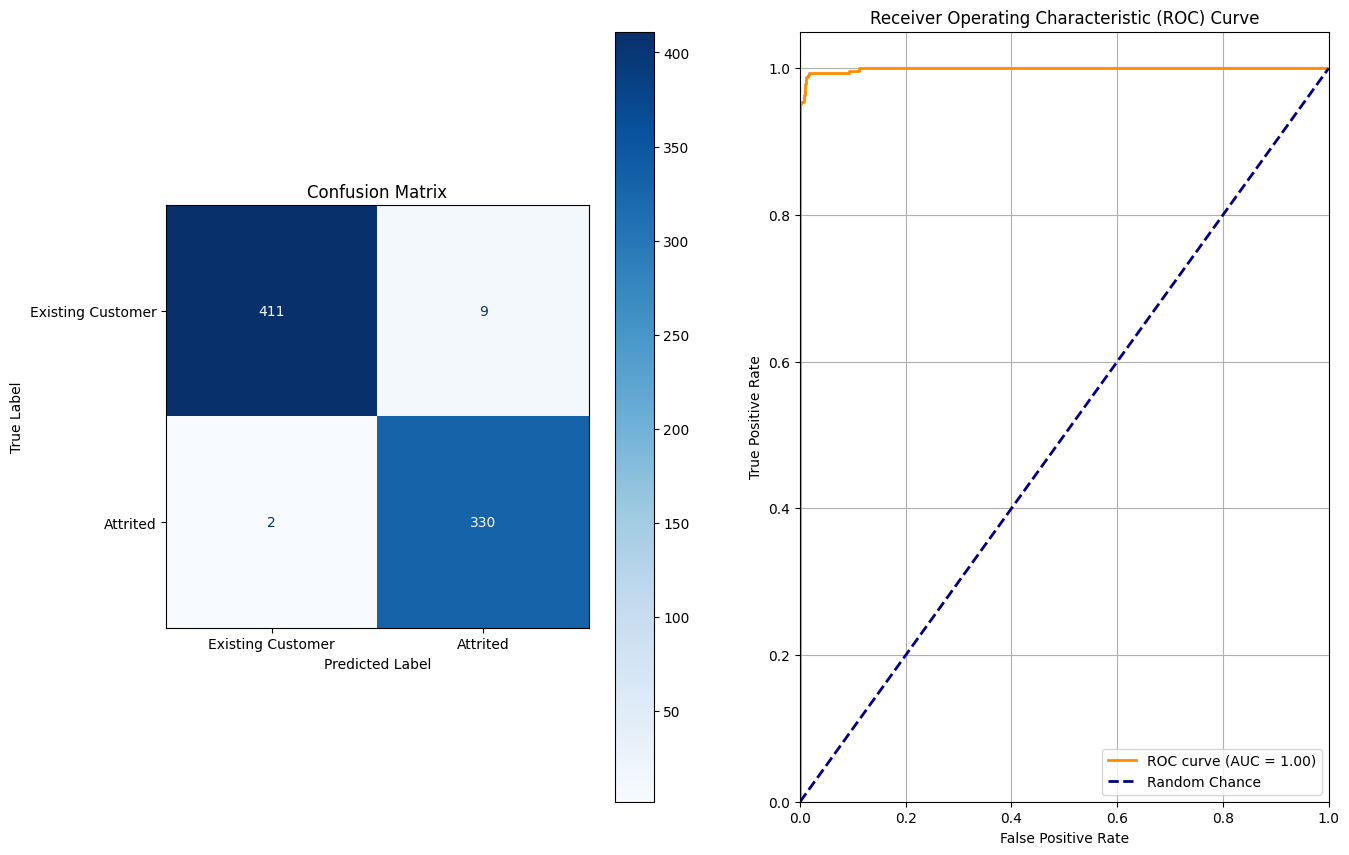

Number of Attrited Predictions: 329
Number of Existing Customer Predictions: 409
Percent Attrited Predictions: 44.579945799457995
Percent Existing Customer Predictions: 55.420054200542005

Accuracy: 97.56%

Recall: 0.9905362776025236

Precision: 0.9544072948328267

F1-Score: 0.97


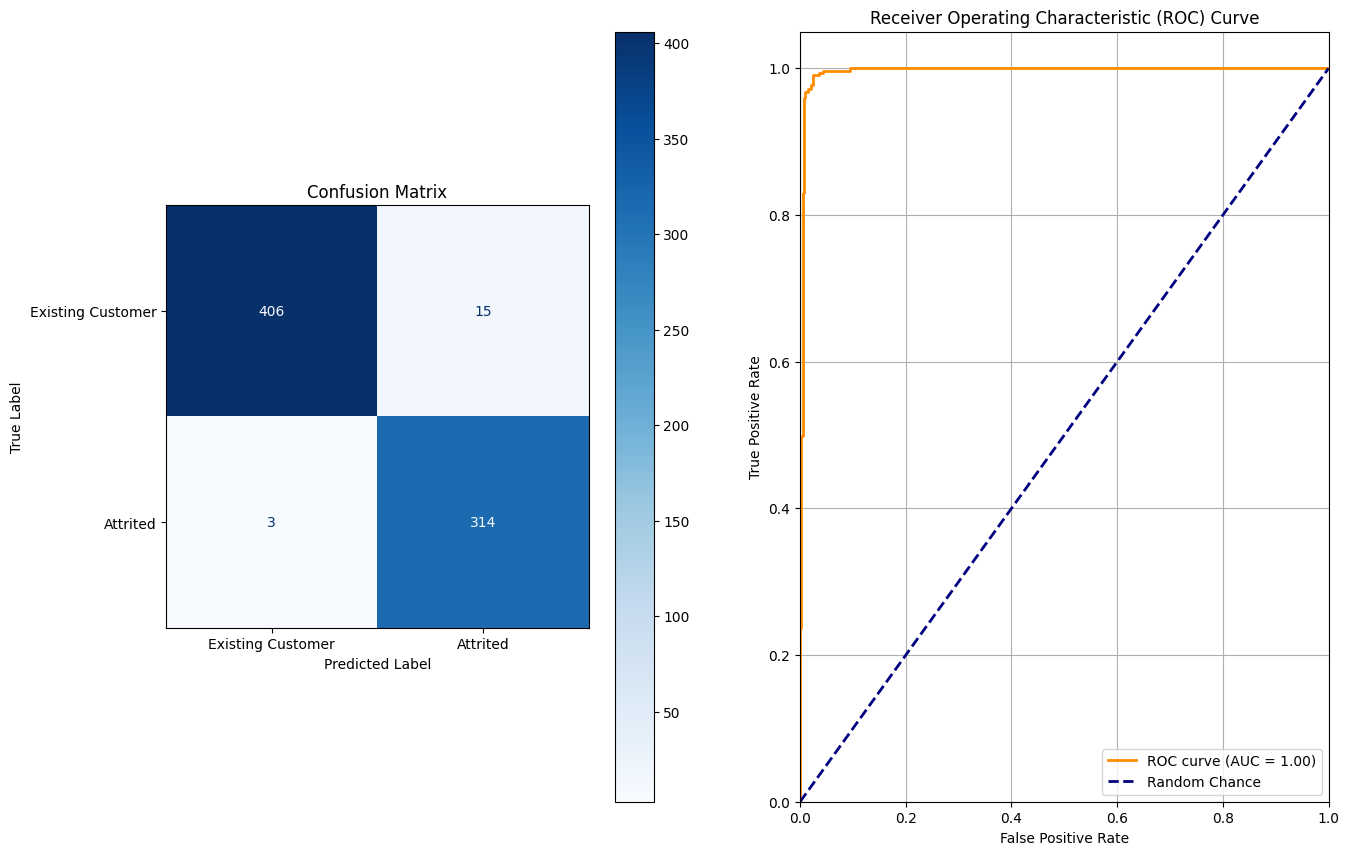

Number of Attrited Predictions: 334
Number of Existing Customer Predictions: 394
Percent Attrited Predictions: 45.879120879120876
Percent Existing Customer Predictions: 54.12087912087912

Accuracy: 97.80%

Recall: 0.9937888198757764

Precision: 0.9580838323353293

F1-Score: 0.98


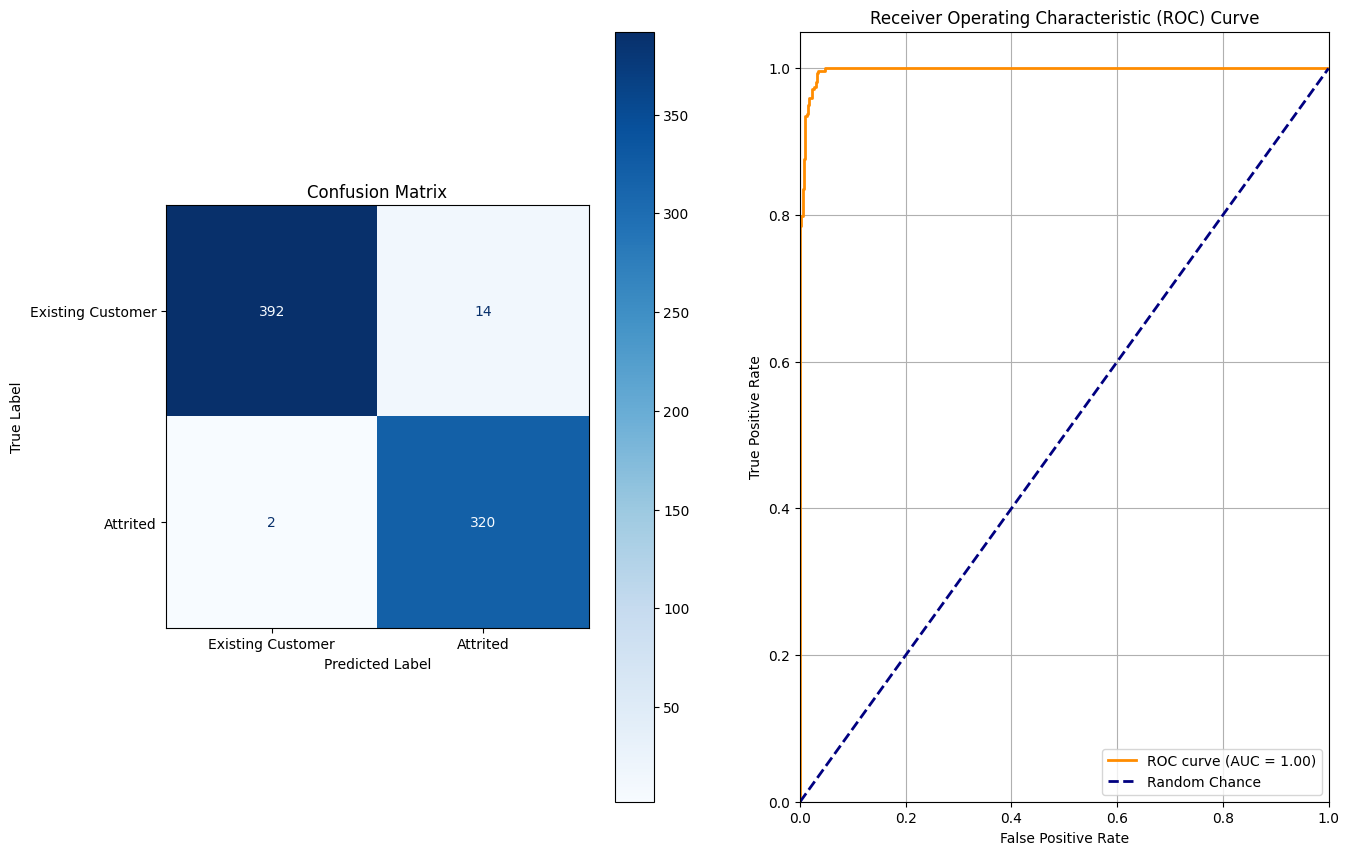

In [341]:
best_gbr_testing = {}

for j in range(50, 80, 5):
    for i in range(5,30,5):

        gbr_data = remove_outliers(data, i)

        gbr_data = reduce_data(gbr_data, j)

        gbr_data = gbr_data.drop(['index', 'CLIENTNUM', 'level_0'], axis = 1)

        training_data, test_data = split_data(gbr_data)

        model = MS(test_data.columns.drop('Attrition_Flag'), intercept=False)
        D = model.fit_transform(test_data) 
        feature_names = list(D.columns)
        X_test = np.asarray(D)
        Y_test = test_data['Attrition_Flag']

        labels = ['Existing Customer', 'Attrited']

        model = ModelEvaluator("Gradient Boosted Regression", best_gbr)

        model_results = {model.name:[]}

        model.eval_model(X_test, Y_test, labels)

        model_results[model.name] = model_results[model.name]+[model.accuracy,model.recall,model.precision,model.f1_score]

        best_gbr_testing[f'{i}%_Outlier_Reduction_{j}%_Class_Reduction'] = [model.accuracy,model.recall,model.precision,model.f1_score]

In [342]:
lines = ['Feature Configuration, Model, Accuracy, Recall, Precision, F1-Score\n']
for key, value in best_gbr_testing.items():
    line = f"{key}, Best Gradient Boosted Regression, "

    for i, val in enumerate(value):
        if i == 1 or i == 2:
            val = f'{val*100:.2f}%'

        if i == len(val)-1:
            line = line + f"{val}\n"
        else:
            line = line + f"{val}, "

    lines.append(line)
  

with open('best_gbr_data.csv', 'w+') as f:
    f.writelines(lines)
    f.close()

## Identify feature importance

[0.02349445 0.0007648  0.00133987 0.000817   0.00278125 0.00086848
 0.00100475 0.00330625 0.05386323 0.00777642 0.01075448 0.00871561
 0.07146963 0.01446625 0.05600601 0.17858396 0.42122177 0.05554058
 0.00289632 0.01007607 0.00347474 0.00555508 0.05503353 0.01018949]
Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Balance_To_TC', 'Numerical_Income_Category', 'Credit_Limit_Per_Income',
       'Leveraged_Balance_Ratio', 'Relationship_Strength'],
      dtype='object')


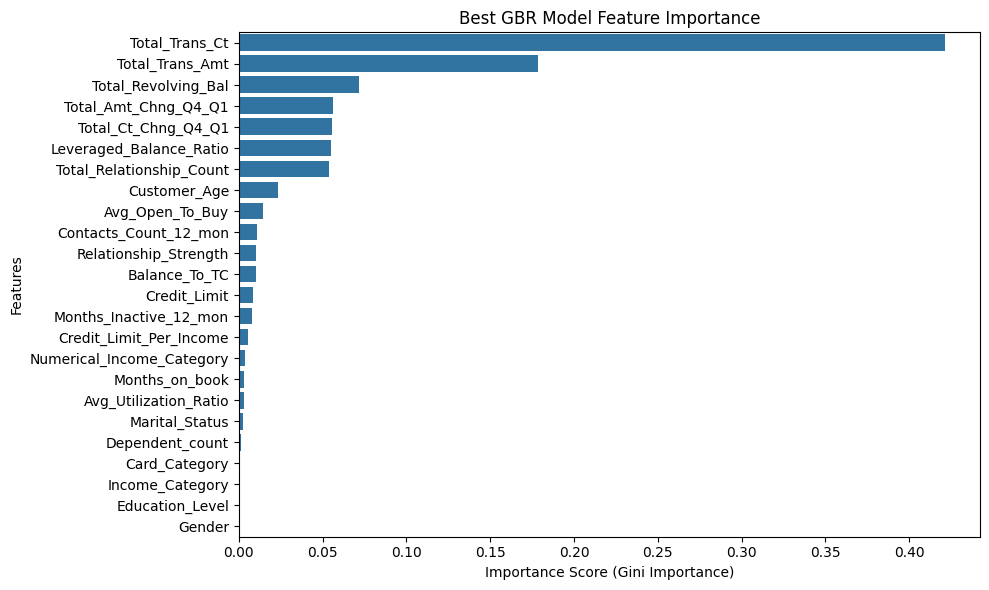

In [357]:
importances = best_gbr.feature_importances_
print(importances)
print(training_data.columns)

gbr_data = remove_outliers(data, 10)

gbr_data = reduce_data(gbr_data, 70)

gbr_data = gbr_data.drop(['level_0', 'index', 'CLIENTNUM'], axis = 1)

training_data, test_data = split_data(gbr_data)

feature_importance_df = pd.DataFrame({
    'Feature': training_data.columns.drop('Attrition_Flag'),
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Best GBR Model Feature Importance')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

[0.02986293 0.00216921 0.00561658 0.00269209 0.         0.00200353
 0.         0.00424464 0.05005459 0.01110407 0.00574912 0.01178069
 0.1157723  0.00570727 0.0600453  0.18720423 0.40708447 0.05139051
 0.00147819 0.01463233 0.00415488 0.00725047 0.01840544 0.00159715]
Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Balance_To_TC', 'Numerical_Income_Category', 'Credit_Limit_Per_Income',
       'Leveraged_Balance_Ratio', 'Relationship_Strength'],
      dtype='object')


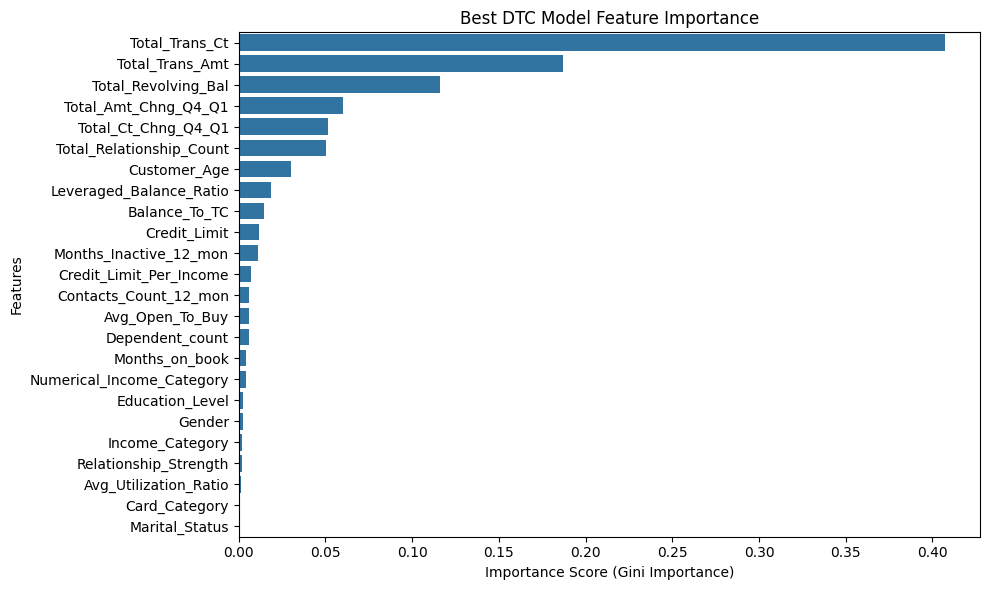

In [ ]:
importances = tuned_DTC.feature_importances_

dtc_data = remove_outliers(data, 20)

dtc_data = reduce_data(dtc_data, 50)

dtc_data = dtc_data.drop(['level_0', 'index', 'CLIENTNUM'], axis = 1)

training_data, test_data = split_data(dtc_data)

feature_importance_df = pd.DataFrame({
    'Feature': training_data.columns.drop('Attrition_Flag'),
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Best DTC Model Feature Importance')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Test Old Models with Outlier Correction

In [359]:
from ISLP.models import ModelSpec as MS
from functools import partial
from ISLP.models import Stepwise, sklearn_selected, sklearn_selection_path
import statsmodels.api as sm

In [360]:
qauntitative = set(data.describe().columns)
categorical = set(data.columns) - qauntitative

cat_counts = {}

for var in categorical:
    cat_counts[var] = [[cat for cat in data[var].unique()], [i for i in range(len(data[var].unique()))]]

In [361]:
for key, val in cat_counts.items():
    data[key].replace(val[0], val[1], inplace = True)

In [362]:
data.dtypes

CLIENTNUM                      int64
Attrition_Flag                 int64
Customer_Age                   int64
Gender                         int64
Dependent_count                int64
Education_Level                int64
Marital_Status                 int64
Income_Category                int64
Card_Category                  int64
Months_on_book                 int64
Total_Relationship_Count       int64
Months_Inactive_12_mon         int64
Contacts_Count_12_mon          int64
Credit_Limit                 float64
Total_Revolving_Bal            int64
Avg_Open_To_Buy              float64
Total_Amt_Chng_Q4_Q1         float64
Total_Trans_Amt                int64
Total_Trans_Ct                 int64
Total_Ct_Chng_Q4_Q1          float64
Avg_Utilization_Ratio        float64
Balance_To_TC                float64
Numerical_Income_Category    float64
Credit_Limit_Per_Income      float64
Leveraged_Balance_Ratio      float64
Relationship_Strength          int64
dtype: object

In [363]:
design = MS(data.columns.drop(['Attrition_Flag', 'CLIENTNUM'])).fit(data)
Y = np.array(data['Attrition_Flag'])
X = design.transform(data) 
sigma2 = sm.OLS(Y,X).fit().scale
sigma2

np.float64(0.08169199637610454)

In [364]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic is used because sklearn maximizes scores."
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n

In [365]:
neg_Cp = partial(nCp, sigma2)

In [366]:
strategy = Stepwise.first_peak(design,
                                direction='both',
                                max_terms=len(design.terms))

In [367]:
Cp = sklearn_selected(sm.OLS,
                            strategy,
                            scoring=neg_Cp)
Cp.fit(data, Y)
Cp.selected_state_

('Balance_To_TC',
 'Card_Category',
 'Contacts_Count_12_mon',
 'Credit_Limit_Per_Income',
 'Dependent_count',
 'Education_Level',
 'Gender',
 'Leveraged_Balance_Ratio',
 'Marital_Status',
 'Months_Inactive_12_mon',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Ct_Chng_Q4_Q1',
 'Total_Relationship_Count',
 'Total_Revolving_Bal',
 'Total_Trans_Amt',
 'Total_Trans_Ct')

In [371]:
columns_to_keep = set(list(Cp.selected_state_) + ['Attrition_Flag'])

columns = set(data.columns)

old_model_data = remove_outliers(data, 25)

selected_data = old_model_data.drop(list(columns-columns_to_keep), axis = 1)



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.130666
         Iterations 9
Number of Attrited Predictions: 296
Number of Existing Customer Predictions: 510
Percent Attrited Predictions: 36.72456575682382
Percent Existing Customer Predictions: 63.27543424317618

Accuracy: 93.30%

Recall: 0.9033333333333333

Precision: 0.9155405405405406

F1-Score: 0.91


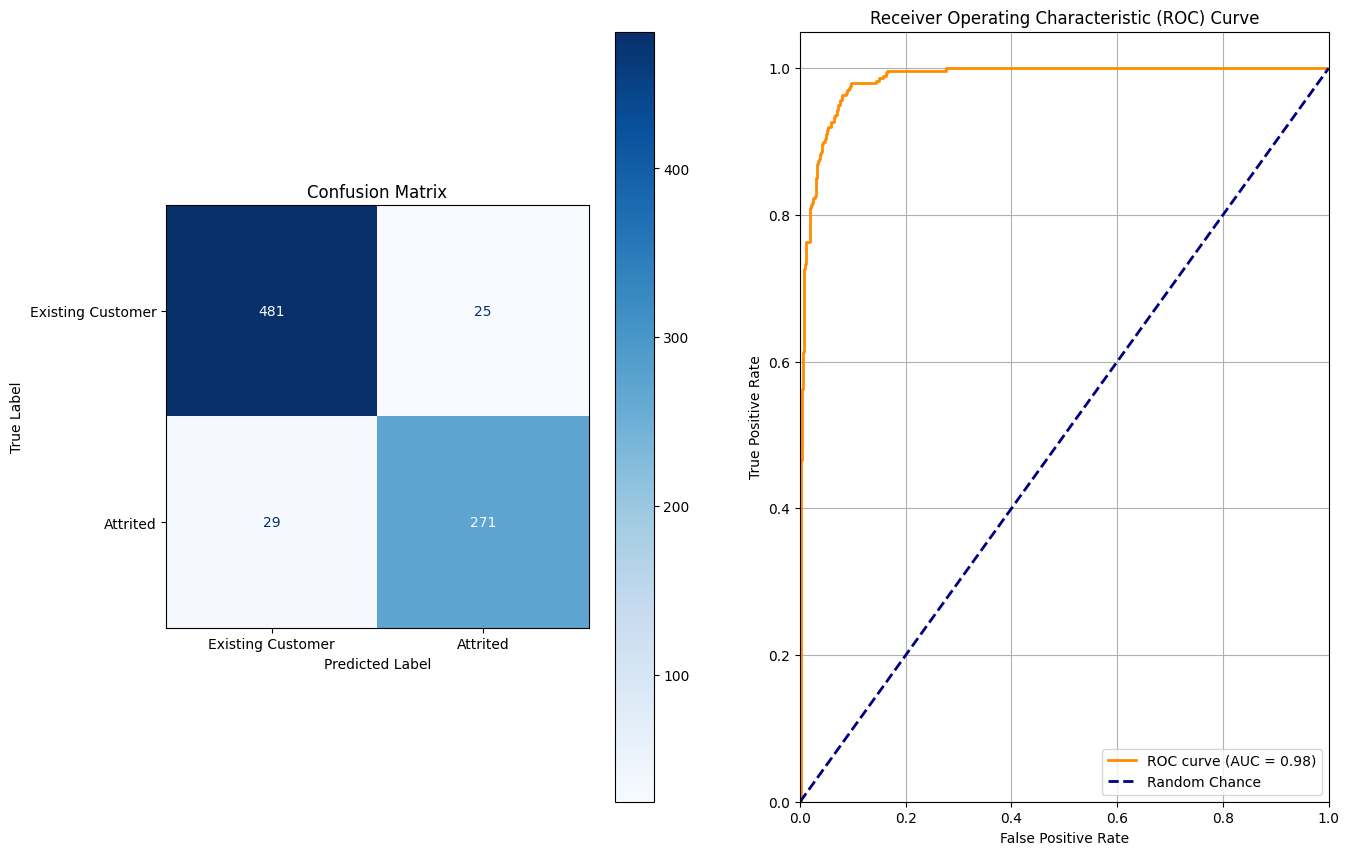



QDA RESULTS: 
Number of Attrited Predictions: 319
Number of Existing Customer Predictions: 487
Percent Attrited Predictions: 39.57816377171216
Percent Existing Customer Predictions: 60.42183622828784

Accuracy: 92.43%

Recall: 0.93

Precision: 0.8746081504702194

F1-Score: 0.90


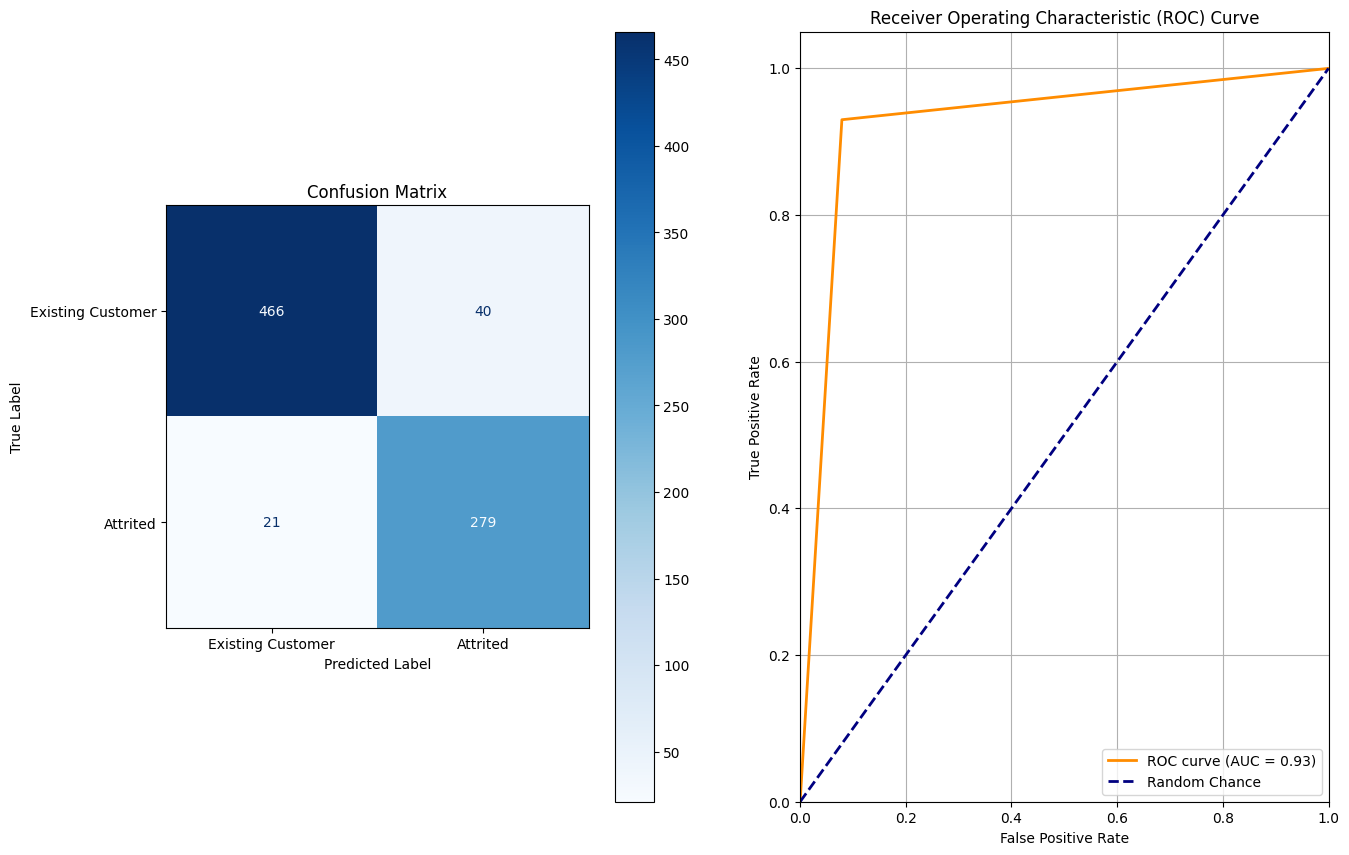



KNN RESULTS: 
Number of neighbors selected: 10
Number of Attrited Predictions: 296
Number of Existing Customer Predictions: 510
Percent Attrited Predictions: 36.72456575682382
Percent Existing Customer Predictions: 63.27543424317618

Accuracy: 97.27%

Recall: 0.9566666666666667

Precision: 0.9695945945945946

F1-Score: 0.96


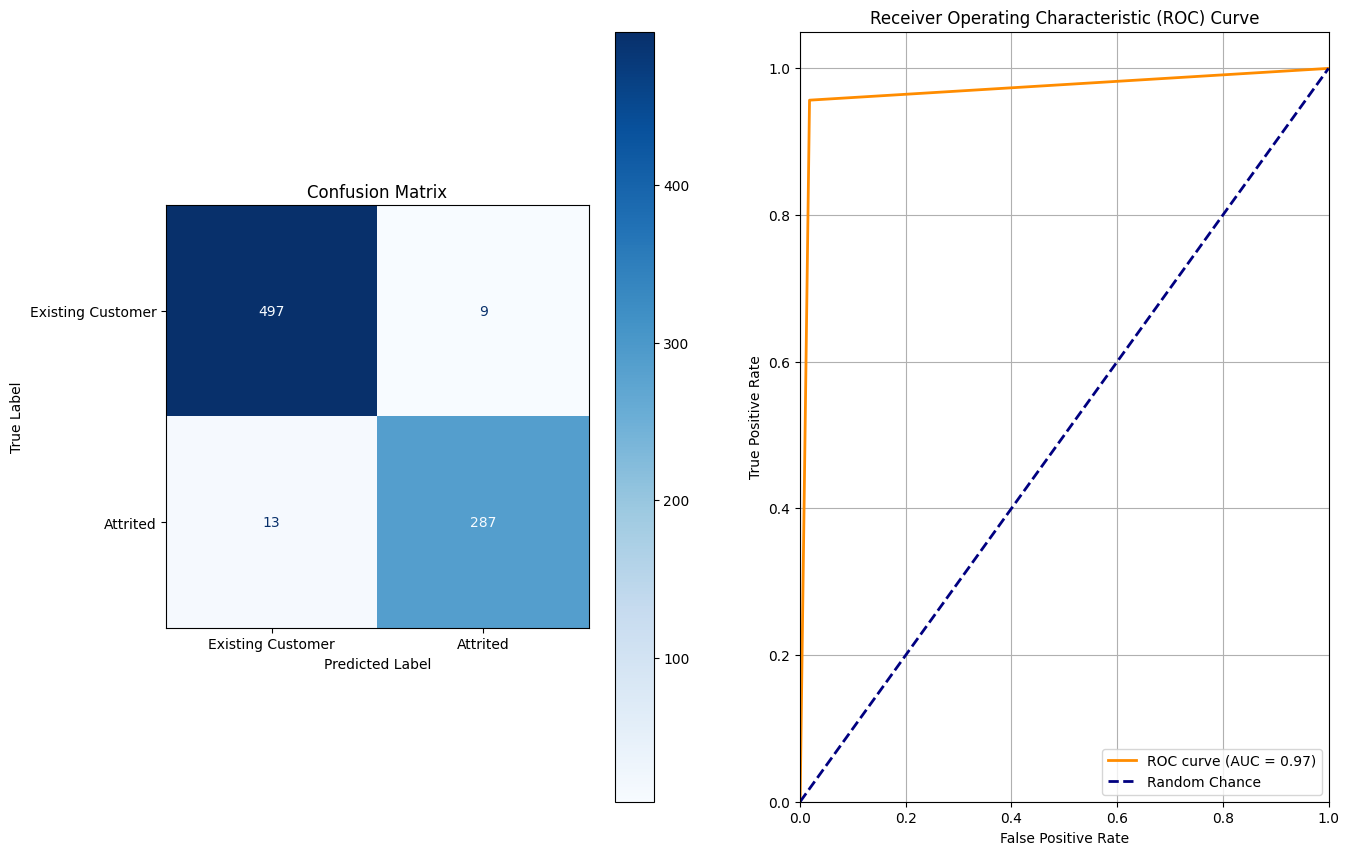

In [375]:
reduced_data = reduce_data(selected_data, 70)

training_data, eval_data = split_data(reduced_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model] = model_results[model]+[test_model.accuracy,test_model.recall,test_model.precision,test_model.f1_score]

summary_table['Selected_Models_75_Reduction'] = model_results